In [10]:
# ============================================================
# EXPERIENCE FEATURE EXPERIMENT — SAFE VERSION
# Does NOT invent player IDs for missing master players
# ============================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("BUILDING SAFE EXPERIENCE FEATURES")
print("=" * 75)


# ------------------------------------------------------------
# 1. Start from our current champion dataset
# ------------------------------------------------------------

experience_data = auction_model_role_fixed.copy()

print("\nAuction records:", len(experience_data))


# ------------------------------------------------------------
# 2. Use existing player_id where available
# ------------------------------------------------------------

experience_data["player_id_known"] = (
    experience_data["player_id"].notna().astype(int)
)

print(
    "Records with known player ID:",
    experience_data["player_id_known"].sum()
)

print(
    "Records without player ID:",
    (
        experience_data["player_id_known"] == 0
    ).sum()
)


# ------------------------------------------------------------
# 3. Create debut-year mapping for known player IDs
# ------------------------------------------------------------

registry_names = player_registry[
    [
        "player_id",
        "player_name"
    ]
].copy()

registry_names["name_norm"] = (
    registry_names["player_name"]
    .apply(normalize_name)
)

players_debut = players[
    [
        "player_name",
        "debut_year"
    ]
].copy()

players_debut["name_norm"] = (
    players_debut["player_name"]
    .apply(normalize_name)
)

players_debut["debut_year"] = pd.to_numeric(
    players_debut["debut_year"],
    errors="coerce"
)

debut_map = (
    registry_names
    .merge(
        players_debut[
            [
                "name_norm",
                "debut_year"
            ]
        ],
        on="name_norm",
        how="left"
    )
    [
        [
            "player_id",
            "debut_year"
        ]
    ]
    .drop_duplicates("player_id")
)


# ------------------------------------------------------------
# 4. Merge debut year
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=[
        "debut_year",
        "experience_years"
    ],
    errors="ignore"
)

experience_data = experience_data.merge(
    debut_map,
    on="player_id",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# 5. Experience is known only when debut year exists
# ------------------------------------------------------------

experience_data["experience_known"] = (
    experience_data["debut_year"]
    .notna()
    .astype(int)
)

experience_data["experience_years"] = (
    pd.to_numeric(
        experience_data["year"],
        errors="coerce"
    )
    -
    pd.to_numeric(
        experience_data["debut_year"],
        errors="coerce"
    )
)

# Do NOT pretend missing experience is 0.
# Temporarily keep it as NaN.
experience_data.loc[
    experience_data["experience_known"] == 0,
    "experience_years"
] = np.nan


# ------------------------------------------------------------
# 6. Unique performance seasons
# ------------------------------------------------------------

bat_seasons = batting_season[
    [
        "player_id",
        "season"
    ]
].copy()

bowl_seasons = bowling_season[
    [
        "player_id",
        "season"
    ]
].copy()

all_player_seasons = pd.concat(
    [
        bat_seasons,
        bowl_seasons
    ],
    ignore_index=True
)

all_player_seasons = (
    all_player_seasons
    .dropna(
        subset=[
            "player_id",
            "season"
        ]
    )
    .drop_duplicates(
        [
            "player_id",
            "season"
        ]
    )
)


# ------------------------------------------------------------
# 7. Count unique seasons before auction
# ------------------------------------------------------------

auction_pairs = experience_data[
    [
        "player_id",
        "year"
    ]
].dropna(
    subset=["player_id"]
).drop_duplicates()

season_counts = all_player_seasons.merge(
    auction_pairs,
    on="player_id",
    how="inner"
)

season_counts = season_counts[
    season_counts["season"]
    <
    season_counts["year"]
]

career_season_counts = (
    season_counts
    .groupby(
        [
            "player_id",
            "year"
        ]
    )
    .size()
    .reset_index(
        name="career_seasons_before"
    )
)


# ------------------------------------------------------------
# 8. Merge career seasons
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=["career_seasons_before"],
    errors="ignore"
)

experience_data = experience_data.merge(
    career_season_counts,
    on=[
        "player_id",
        "year"
    ],
    how="left",
    validate="many_to_one"
)

experience_data["career_seasons_before"] = (
    experience_data[
        "career_seasons_before"
    ]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 9. Fill experience for model training
#
# Median imputation will happen INSIDE the model pipeline.
# We keep NaN here so the preprocessing pipeline handles it.
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXPERIENCE FEATURE SUMMARY")
print("=" * 75)

print(
    "\nTotal records:",
    len(experience_data)
)

print(
    "Known experience:",
    experience_data["experience_known"].sum()
)

print(
    "Unknown experience:",
    (
        experience_data["experience_known"] == 0
    ).sum()
)

print(
    "Experience coverage:",
    round(
        experience_data["experience_known"].mean() * 100,
        2
    ),
    "%"
)

print(
    "Missing experience_years:",
    experience_data["experience_years"].isna().sum()
)

print(
    "Missing career_seasons_before:",
    experience_data[
        "career_seasons_before"
    ].isna().sum()
)


# ------------------------------------------------------------
# 10. Show examples
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXAMPLES")
print("=" * 75)

display(
    experience_data[
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years",
            "experience_known",
            "career_seasons_before"
        ]
    ].head(25)
)


# ------------------------------------------------------------
# 11. Important players
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("IMPORTANT PLAYER CHECK")
print("=" * 75)

display(
    experience_data[
        experience_data["player_name"].isin(
            [
                "AB de Villiers",
                "Virat Kohli",
                "Rohit Sharma",
                "MS Dhoni",
                "Karan Sharma"
            ]
        )
    ][
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years",
            "experience_known",
            "career_seasons_before"
        ]
    ]
    .sort_values(
        [
            "player_name",
            "year"
        ]
    )
)


# ------------------------------------------------------------
# 12. Final safety checks
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SAFETY CHECKS")
print("=" * 75)

print(
    "Negative known experience:",
    (
        experience_data.loc[
            experience_data["experience_known"] == 1,
            "experience_years"
        ] < 0
    ).sum()
)

print(
    "Unknown player IDs:",
    experience_data["player_id"].isna().sum()
)

print(
    "Unknown experience:",
    (
        experience_data["experience_known"] == 0
    ).sum()
)

print("\n✅ EXPERIENCE DATASET READY FOR MODEL COMPARISON")

BUILDING SAFE EXPERIENCE FEATURES

Auction records: 1433
Records with known player ID: 887
Records without player ID: 546

EXPERIENCE FEATURE SUMMARY

Total records: 1433
Known experience: 887
Unknown experience: 546
Experience coverage: 61.9 %
Missing experience_years: 546
Missing career_seasons_before: 0

EXAMPLES


,year,player_name,player_id,debut_year,experience_years,experience_known,career_seasons_before
0,2008,Virat Kohli,P0001,2008.0,0.0,1,0
1,2010,Virat Kohli,P0001,2008.0,2.0,1,2
2,2008,Rohit Sharma,P0002,2008.0,0.0,1,0
3,2011,Rohit Sharma,P0002,2008.0,3.0,1,3
4,2008,Shikhar Dhawan,P0003,2008.0,0.0,1,0
5,2010,Shikhar Dhawan,P0003,2008.0,2.0,1,2
6,2011,Shikhar Dhawan,P0003,2008.0,3.0,1,3
7,2018,Shikhar Dhawan,P0003,2008.0,10.0,1,10
8,2022,Shikhar Dhawan,P0003,2008.0,14.0,1,14
9,2011,David Warner,P0004,2009.0,2.0,1,2



IMPORTANT PLAYER CHECK


,year,player_name,player_id,debut_year,experience_years,experience_known,career_seasons_before
13,2008,AB de Villiers,P0008,2008.0,0.0,1,0
14,2011,AB de Villiers,P0008,2008.0,3.0,1,3
371,2022,Karan Sharma,P0182,2022.0,0.0,1,9
887,2008,MS Dhoni,NaN,NaN,NaN,0,0
2,2008,Rohit Sharma,P0002,2008.0,0.0,1,0
3,2011,Rohit Sharma,P0002,2008.0,3.0,1,3
0,2008,Virat Kohli,P0001,2008.0,0.0,1,0
1,2010,Virat Kohli,P0001,2008.0,2.0,1,2



SAFETY CHECKS
Negative known experience: 76
Unknown player IDs: 546
Unknown experience: 546

✅ EXPERIENCE DATASET READY FOR MODEL COMPARISON


In [2]:
import numpy as numpy
import pandas as pd
import os

In [3]:
players = pd.read_csv(
    "../data/raw/players/ipl_players_master.csv"
)

batting = pd.read_csv(
    "../data/raw/performance/ipl_batting_career_progression.csv"
)

bowling = pd.read_csv(
    "../data/raw/performance/ipl_bowling_career_progression.csv"
)

In [4]:
print("Players:", players.shape )
print("Batters:" , batting.shape)
print("Bowlers:", bowling.shape)

Players: (771, 19)
Batters: (2782, 15)
Bowlers: (2075, 15)


In [5]:
print("Players Data")
print(players.columns.tolist())

print("\nBatting data")
print(batting.columns.tolist())

print("\nBowling Data")
print(bowling.columns.tolist())

Players Data
['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']

Batting data
['player_name', 'country', 'season', 'team', 'innings', 'not_outs', 'runs_scored', 'balls_faced', 'batting_average', 'batting_strike_rate', 'highest_score', 'hundreds', 'fifties', 'fours', 'sixes']

Bowling Data
['player_name', 'country', 'season', 'team', 'innings', 'balls_bowled', 'total_runs_conceded', 'total_wickets', 'economy_rate', 'bowling_average', 'bowling_strike_rate', 'best_wickets', 'three_wicket_hauls', 'four_wicket_hauls', 'five_wicket_hauls']


In [6]:
#head
players.head()

,player_name,country,debut_year,last_year,seasons_played,teams,career_runs,career_balls_faced,career_batting_innings,career_hundreds,career_fifties,career_highest_score,career_fours,career_sixes,career_batting_sr,career_wickets,career_bowling_innings,career_bowling_economy,career_bowling_sr
0,Virat Kohli,NaN,2008,2025,18,Royal Challengers Bengaluru,8661,6519,259,8,63,113,771,291,132.9,4,26,8.80,62.8
1,Rohit Sharma,NaN,2008,2025,18,"Mumbai Indians, Sunrisers Hyderabad",7046,5334,266,2,47,109,640,302,132.1,15,32,8.02,22.6
2,Shikhar Dhawan,NaN,2008,2024,17,"Delhi Capitals, Mumbai Indians, Punjab Kings, ...",6769,5324,221,2,51,106,768,152,127.1,4,6,8.25,12.0
3,David Warner,NaN,2009,2024,15,"Delhi Capitals, Sunrisers Hyderabad",6565,4697,184,4,62,126,663,236,139.8,0,1,12.00,NaN
4,Suresh Raina,NaN,2008,2021,13,"Chennai Super Kings, Gujarat Titans",5528,4043,200,1,39,100,506,203,136.7,25,69,7.39,36.3


In [7]:
batting.head()

,player_name,country,season,team,innings,not_outs,runs_scored,balls_faced,batting_average,batting_strike_rate,highest_score,hundreds,fifties,fours,sixes
0,A Ashish Reddy,NaN,2012,Sunrisers Hyderabad,5,1,35,29,8.75,120.7,10,0,0,3,1
1,A Ashish Reddy,NaN,2013,Sunrisers Hyderabad,10,3,125,89,17.86,140.4,36,0,0,8,5
2,A Ashish Reddy,NaN,2015,Sunrisers Hyderabad,5,2,73,46,24.33,158.7,22,0,0,3,5
3,A Ashish Reddy,NaN,2016,Sunrisers Hyderabad,3,1,47,29,23.50,162.1,32,0,0,2,4
4,A Chandila,NaN,2012,Rajasthan Royals,1,0,0,1,0.00,0.0,0,0,0,0,0


In [8]:
bowling.head()

,player_name,country,season,team,innings,balls_bowled,total_runs_conceded,total_wickets,economy_rate,bowling_average,bowling_strike_rate,best_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls
0,A Ashish Reddy,NaN,2012,Sunrisers Hyderabad,9,163,237,11,8.72,21.55,14.8,3,1,0,0
1,A Ashish Reddy,NaN,2013,Sunrisers Hyderabad,5,40,70,3,10.50,23.33,13.3,1,0,0,0
2,A Ashish Reddy,NaN,2015,Sunrisers Hyderabad,4,36,50,3,8.33,16.67,12.0,1,0,0,0
3,A Ashish Reddy,NaN,2016,Sunrisers Hyderabad,2,23,39,1,10.17,39.00,23.0,1,0,0,0
4,A Chandila,NaN,2012,Rajasthan Royals,4,84,86,5,6.14,17.20,16.8,4,0,1,0


In [9]:
players.info

<bound method DataFrame.info of         player_name  country  debut_year  last_year  seasons_played  \
0       Virat Kohli      NaN        2008       2025              18   
1      Rohit Sharma      NaN        2008       2025              18   
2    Shikhar Dhawan      NaN        2008       2024              17   
3      David Warner      NaN        2009       2024              15   
4      Suresh Raina      NaN        2008       2021              13   
..              ...      ...         ...        ...             ...   
766    Abdur Razzak      NaN        2008       2008               1   
767    Himmat Singh      NaN        2025       2025               1   
768     WP O'Rourke      NaN        2025       2025               1   
769        S Joseph      NaN        2024       2024               1   
770       RA Shaikh      NaN        2009       2009               1   

                                                 teams  career_runs  \
0                          Royal Challengers

In [10]:
batting.info

<bound method DataFrame.info of          player_name  country  season                         team  innings  \
0     A Ashish Reddy      NaN    2012          Sunrisers Hyderabad        5   
1     A Ashish Reddy      NaN    2013          Sunrisers Hyderabad       10   
2     A Ashish Reddy      NaN    2015          Sunrisers Hyderabad        5   
3     A Ashish Reddy      NaN    2016          Sunrisers Hyderabad        3   
4         A Chandila      NaN    2012             Rajasthan Royals        1   
...              ...      ...     ...                          ...      ...   
2777     Zaheer Khan      NaN    2011  Royal Challengers Bengaluru        2   
2778     Zaheer Khan      NaN    2012  Royal Challengers Bengaluru        4   
2779     Zaheer Khan      NaN    2014               Mumbai Indians        3   
2780     Zaheer Khan      NaN    2016               Delhi Capitals        2   
2781     Zaheer Khan      NaN    2017               Delhi Capitals        3   

      not_outs  run

In [11]:
bowling.info

<bound method DataFrame.info of          player_name  country  season                 team  innings  \
0     A Ashish Reddy      NaN    2012  Sunrisers Hyderabad        9   
1     A Ashish Reddy      NaN    2013  Sunrisers Hyderabad        5   
2     A Ashish Reddy      NaN    2015  Sunrisers Hyderabad        4   
3     A Ashish Reddy      NaN    2016  Sunrisers Hyderabad        2   
4         A Chandila      NaN    2012     Rajasthan Royals        4   
...              ...      ...     ...                  ...      ...   
2070     Zaheer Khan      NaN    2014       Mumbai Indians        6   
2071     Zaheer Khan      NaN    2015       Delhi Capitals        7   
2072     Zaheer Khan      NaN    2016       Delhi Capitals       12   
2073     Zaheer Khan      NaN    2017       Delhi Capitals       11   
2074  Zeeshan Ansari      NaN    2025  Sunrisers Hyderabad       10   

      balls_bowled  total_runs_conceded  total_wickets  economy_rate  \
0              163                  237    

In [12]:
batting.describe()

,country,season,innings,not_outs,runs_scored,balls_faced,batting_average,batting_strike_rate,highest_score,hundreds,fifties,fours,sixes
count,0.0,2782.000000,2782.000000,2782.000000,2782.000000,2782.000000,2749.000000,2782.000000,2782.000000,2782.000000,2782.000000,2782.000000,2782.000000
mean,NaN,2016.542056,6.338246,1.245147,127.636233,96.678289,18.023016,110.384687,33.854421,0.039540,0.659957,11.526600,5.150611
std,NaN,5.324041,4.877821,1.434763,158.302166,112.814714,14.340534,49.315858,30.908351,0.231974,1.277178,15.589271,7.503802
min,NaN,2008.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,2012.000000,2.000000,0.000000,9.000000,11.000000,6.000000,85.550000,7.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,2017.000000,5.000000,1.000000,50.000000,44.000000,15.750000,116.700000,24.000000,0.000000,0.000000,4.000000,2.000000
75%,NaN,2021.000000,11.000000,2.000000,205.000000,156.750000,27.000000,138.900000,56.000000,0.000000,1.000000,18.000000,8.000000
max,NaN,2025.000000,19.000000,9.000000,973.000000,640.000000,109.000000,400.000000,175.000000,4.000000,9.000000,88.000000,59.000000


In [13]:
bowling.describe()

,country,season,innings,balls_bowled,total_runs_conceded,total_wickets,economy_rate,bowling_average,bowling_strike_rate,best_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls
count,0.0,2075.000000,2075.000000,2075.000000,2075.000000,2075.000000,2075.000000,1708.000000,1708.000000,2075.000000,2075.000000,2075.000000,2075.000000
mean,NaN,2016.632289,6.672289,129.060241,176.947470,6.084337,8.996988,36.088788,25.037822,1.854940,0.382651,0.097349,0.017831
std,NaN,5.311168,4.835737,108.506881,140.957993,6.168724,2.565745,23.405892,14.159075,1.274582,0.719670,0.334698,0.135964
min,NaN,2008.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,2012.000000,2.000000,36.000000,53.500000,1.000000,7.500000,22.395000,16.800000,1.000000,0.000000,0.000000,0.000000
50%,NaN,2017.000000,5.000000,96.000000,136.000000,4.000000,8.500000,29.500000,21.400000,2.000000,0.000000,0.000000,0.000000
75%,NaN,2022.000000,11.000000,213.500000,291.500000,10.000000,9.920000,41.042500,28.500000,3.000000,1.000000,0.000000,0.000000
max,NaN,2025.000000,19.000000,420.000000,566.000000,32.000000,36.000000,248.000000,144.000000,6.000000,5.000000,3.000000,2.000000


In [14]:
print("Missing values")
print(players.isnull().sum())

print("\nBatting missing values")
print(batting.isnull().sum())

print("\nBowling missing values")
print(bowling.isnull().sum())

Missing values
player_name                 0
country                   771
debut_year                  0
last_year                   0
seasons_played              0
teams                       0
career_runs                 0
career_balls_faced          0
career_batting_innings      0
career_hundreds             0
career_fifties              0
career_highest_score        0
career_fours                0
career_sixes                0
career_batting_sr          69
career_wickets              0
career_bowling_innings      0
career_bowling_economy    221
career_bowling_sr         303
dtype: int64

Batting missing values
player_name               0
country                2782
season                    0
team                      0
innings                   0
not_outs                  0
runs_scored               0
balls_faced               0
batting_average          33
batting_strike_rate       0
highest_score             0
hundreds                  0
fifties                   0
fours         

In [15]:
print(
    "batting seasons:",
    batting['season'].min(),
    "to",
    batting['season'].max()
)

print(
    "Bowling seasons",
    bowling['season'].min(),
    "to",
    bowling['season'].max()
)

batting seasons: 2008 to 2025
Bowling seasons 2008 to 2025


In [16]:
print(sorted(batting['season'].unique()))

[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [17]:
print(
    "Unique batting players:",
    batting["player_name"].nunique()
)

print(
    "Unique bowling players:",
    bowling["player_name"].nunique()
)

print(
    "Unique master players:",
    players["player_name"].nunique()
)

Unique batting players: 701
Unique bowling players: 549
Unique master players: 770


In [18]:
batting['player_name'].value_counts().head(20)

player_name
Manish Pandey        18
Rohit Sharma         18
M S Dhoni            18
Virat Kohli          18
Ajinkya Rahane       17
Dinesh Karthik       17
Ravindra Jadeja      17
Shikhar Dhawan       17
Wriddhiman Saha      17
Ravi Ashwin          16
David Warner         15
Piyush Chawla        15
Mayank Agarwal       15
RV Uthappa           15
Bhuvneshwar Kumar    15
Sunil Narine         14
AB de Villiers       14
A T Rayudu           14
Dwayne Bravo         14
Umesh Yadav          14
Name: count, dtype: int64

In [19]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [20]:
auction = pd.read_parquet(
    "../data/raw/auction/acquisitions/auction_all_years.parquet"
)

In [21]:
print(auction.shape)
print(auction.columns.tolist())

(2628, 11)
['year', 'player_id', 'player_name', 'team', 'base_price_lakh', 'final_price_lakh', 'role', 'nationality', 'status', 'acquisition_type', 'source']


In [22]:
auction.head(10)

,year,player_id,player_name,team,base_price_lakh,final_price_lakh,role,nationality,status,acquisition_type,source
0,2008,P0473,MS Dhoni,CSK,NaN,950.0,Wicket-Keeper,Indian,SOLD,auction,manual_2008
1,2008,P0011,Andrew Symonds,DCH,NaN,650.0,All-Rounder,Overseas,SOLD,auction,manual_2008
2,2008,P0709,Sanath Jayasuriya,MI,NaN,575.0,All-Rounder,Overseas,SOLD,auction,manual_2008
3,2008,P0295,Ishant Sharma,KKR,NaN,550.0,Bowler,Indian,SOLD,auction,manual_2008
4,2008,P0207,Mahela Jayawardene,DC,NaN,525.0,Batsman,Overseas,SOLD,auction,manual_2008
5,2008,P0616,RP Singh,DCH,NaN,375.0,Bowler,Indian,SOLD,auction,manual_2008
6,2008,P0297,Irfan Pathan,PBKS,NaN,350.0,All-Rounder,Indian,SOLD,auction,manual_2008
7,2008,P0640,Robin Uthappa,MI,NaN,300.0,Batsman,Indian,SOLD,auction,manual_2008
8,2008,P0260,Gautam Gambhir,DC,NaN,275.0,Batsman,Indian,SOLD,auction,manual_2008
9,2008,P0687,S Sreesanth,PBKS,NaN,275.0,Bowler,Indian,SOLD,auction,manual_2008


In [23]:
auction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2628 entries, 0 to 2627
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              2628 non-null   int64  
 1   player_id         2628 non-null   object 
 2   player_name       2628 non-null   object 
 3   team              2628 non-null   object 
 4   base_price_lakh   352 non-null    float64
 5   final_price_lakh  2325 non-null   float64
 6   role              1353 non-null   object 
 7   nationality       1505 non-null   object 
 8   status            2628 non-null   object 
 9   acquisition_type  2628 non-null   object 
 10  source            2628 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 226.0+ KB


In [24]:
auction['status'].value_counts(dropna=False)

status
SOLD        1434
RETAINED    1123
UNSOLD        71
Name: count, dtype: int64

In [25]:
auction['acquisition_type'].value_counts(dropna=False)

acquisition_type
auction     1505
retained    1123
Name: count, dtype: int64

Auction dataset

In [26]:
auction_sold = auction[
    (auction["acquisition_type"] == 'auction') &
    (auction["status"] == 'SOLD')
].copy()

In [27]:
print("Rows:",auction_sold.shape[0])
print("Columns:",auction_sold.shape[1])

Rows: 1434
Columns: 11


In [28]:
print(
    auction_sold['year'].min(),
    "to",
    auction_sold['year'].max()
)

print(sorted(auction_sold['year'].unique()))

2008 to 2026
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2026)]


In [29]:
auction_sold['final_price_lakh'].describe()

count    1433.000000
mean      204.948011
std       285.389855
min         9.000000
25%        30.000000
50%        95.000000
75%       260.000000
max      2520.000000
Name: final_price_lakh, dtype: float64

In [30]:
auction_sold['final_price_lakh'].isnull().sum()

np.int64(1)

In [31]:
auction_sold[
    auction_sold['final_price_lakh'] <= 0
].shape

(0, 11)

In [32]:
auction_sold[
    [
        "year",
        "player_name",
        "team",
        "role",
        "nationality",
        "final_price_lakh"
    ]
].sort_values(
    "final_price_lakh",
    ascending=False
).head(20)

,year,player_name,team,role,nationality,final_price_lakh
2551,2026,Cameron Green,KKR,Unknown,Overseas,2520.0
2329,2023,Sam Curran,PBKS,All-Rounder,Overseas,1850.0
2552,2026,Matheesha Pathirana,KKR,Unknown,Overseas,1800.0
2330,2023,Cameron Green,MI,All-Rounder,Overseas,1750.0
2332,2023,Ben Stokes,CSK,All-Rounder,Overseas,1625.0
2333,2023,Nicholas Pooran,LSG,Wicket-Keeper,Overseas,1600.0
1866,2021,Chris Morris,RR,All-Rounder,Overseas,1600.0
931,2015,Yuvraj Singh,DC,Batsman,Indian,1600.0
1725,2020,Pat Cummins,KKR,All-Rounder,Overseas,1550.0
2099,2022,Ishan Kishan,MI,Wicket-Keeper,Indian,1525.0


In [33]:
print("Unique auction players:",
      auction_sold['player_id'].nunique())
print("total auction records:",
      len(auction_sold))

Unique auction players: 712
total auction records: 1434


In [34]:
auction_sold[
    ['player_id','player_name']
].head(20)

,player_id,player_name
0,P0473,MS Dhoni
1,P0011,Andrew Symonds
2,P0709,Sanath Jayasuriya
3,P0295,Ishant Sharma
4,P0207,Mahela Jayawardene
5,P0616,RP Singh
6,P0297,Irfan Pathan
7,P0640,Robin Uthappa
8,P0260,Gautam Gambhir
9,P0687,S Sreesanth


In [35]:
auction_sold[
    auction_sold.duplicated(
        subset=["year","player_id"],
        keep=False
    )
].sort_values(
    ['year','player_id']
)

,year,player_id,player_name,team,base_price_lakh,final_price_lakh,role,nationality,status,acquisition_type,source
179,2009,P0464,Manoj Tiwary,KKR,NaN,20.00,Batsman,Indian,SOLD,auction,manual_2009
180,2009,P0464,Saurabh Tiwary,MI,NaN,20.00,Batsman,Indian,SOLD,auction,manual_2009
365,2011,P0464,Saurabh Tiwary,MI,180.0,675.00,None,Indian,SOLD,auction,wikipedia_excel
414,2011,P0464,Manoj Tiwary,KKR,45.0,213.75,None,Indian,SOLD,auction,wikipedia_excel
809,2014,P0464,Manoj Tiwary,DC,NaN,280.00,Batsman,Indian,SOLD,auction,kaggle_main
865,2014,P0464,Saurabh Tiwary,DC,NaN,70.00,Batsman,Indian,SOLD,auction,kaggle_main
1315,2017,P0464,Manoj Tiwary,RPS,NaN,50.00,Batsman,Indian,SOLD,auction,kaggle_main
1326,2017,P0464,Saurabh Tiwary,MI,NaN,30.00,Batsman,Indian,SOLD,auction,kaggle_main
1505,2018,P0464,Manoj Tiwary,PBKS,NaN,100.00,Batsman,Indian,SOLD,auction,kaggle_main
1515,2018,P0464,Saurabh Tiwary,MI,NaN,80.00,Batsman,Indian,SOLD,auction,kaggle_main


In [36]:
auction_sold[
    auction_sold["final_price_lakh"].isna()
]

,year,player_id,player_name,team,base_price_lakh,final_price_lakh,role,nationality,status,acquisition_type,source
492,2011,P0784,Stephen O'Keefe,KTK,NaN,NaN,None,Overseas,SOLD,auction,wikipedia_excel


In [37]:
duplicates = auction_sold[
    auction_sold.duplicated(
        subset=["year","player_id"],
        keep=False
    )
].sort_values(
    ["year","player_id"]
)

duplicates

,year,player_id,player_name,team,base_price_lakh,final_price_lakh,role,nationality,status,acquisition_type,source
179,2009,P0464,Manoj Tiwary,KKR,NaN,20.00,Batsman,Indian,SOLD,auction,manual_2009
180,2009,P0464,Saurabh Tiwary,MI,NaN,20.00,Batsman,Indian,SOLD,auction,manual_2009
365,2011,P0464,Saurabh Tiwary,MI,180.0,675.00,None,Indian,SOLD,auction,wikipedia_excel
414,2011,P0464,Manoj Tiwary,KKR,45.0,213.75,None,Indian,SOLD,auction,wikipedia_excel
809,2014,P0464,Manoj Tiwary,DC,NaN,280.00,Batsman,Indian,SOLD,auction,kaggle_main
865,2014,P0464,Saurabh Tiwary,DC,NaN,70.00,Batsman,Indian,SOLD,auction,kaggle_main
1315,2017,P0464,Manoj Tiwary,RPS,NaN,50.00,Batsman,Indian,SOLD,auction,kaggle_main
1326,2017,P0464,Saurabh Tiwary,MI,NaN,30.00,Batsman,Indian,SOLD,auction,kaggle_main
1505,2018,P0464,Manoj Tiwary,PBKS,NaN,100.00,Batsman,Indian,SOLD,auction,kaggle_main
1515,2018,P0464,Saurabh Tiwary,MI,NaN,80.00,Batsman,Indian,SOLD,auction,kaggle_main


In [38]:
players = pd.read_csv(
    "../data/raw/players/ipl_players_master.csv"  
)

In [39]:
players.columns.tolist()

['player_name',
 'country',
 'debut_year',
 'last_year',
 'seasons_played',
 'teams',
 'career_runs',
 'career_balls_faced',
 'career_batting_innings',
 'career_hundreds',
 'career_fifties',
 'career_highest_score',
 'career_fours',
 'career_sixes',
 'career_batting_sr',
 'career_wickets',
 'career_bowling_innings',
 'career_bowling_economy',
 'career_bowling_sr']

In [40]:
print(players.shape)
print(players.columns.tolist())

(771, 19)
['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']


In [43]:
auction_ids = set(auction_sold["player_id"])
master_ids = set(players["player_id"])

print("Auction player IDs:", len(auction_ids))
print("Master player IDs:", len(master_ids))
print("Matched IDs:", len(auction_ids & master_ids))
print("Unmatched IDs:", len(auction_ids - master_ids))

KeyError: 'player_id'

In [ ]:
player_id_counts = (
    auction_sold
    .groupby("player_id")["player_name"]
    .nunique()
    .sort_values(ascending=False)
)

player_id_counts.head(20)

player_id
P0395    3
P0095    3
P0612    2
P0154    2
P0815    2
P0160    2
P0601    2
P0602    2
P0211    2
P0284    2
P0069    2
P0632    2
P0610    2
P0412    2
P0626    2
P0330    2
P0728    2
P0529    2
P0812    2
P0730    2
Name: player_name, dtype: int64

In [ ]:
player_id_counts[player_id_counts > 1]

player_id
P0395    3
P0095    3
P0612    2
P0154    2
P0815    2
P0160    2
P0601    2
P0602    2
P0211    2
P0284    2
P0069    2
P0632    2
P0610    2
P0412    2
P0626    2
P0330    2
P0728    2
P0529    2
P0812    2
P0730    2
P0186    2
P0622    2
P0534    2
P0183    2
P0092    2
P0616    2
P0436    2
P0365    2
P0689    2
P0014    2
P0464    2
P0126    2
P0775    2
P0488    2
P0687    2
P0661    2
P0246    2
P0444    2
P0889    2
P0480    2
Name: player_name, dtype: int64

In [ ]:
auction_names = set(
    auction_sold["player_name"].dropna().str.strip()
)

batting_names = set(
    batting["player_name"].dropna().str.strip()
)

matched_names = auction_names & batting_names

print("Auction unique names:", len(auction_names))
print("Batting unique names:", len(batting_names))
print("Matched names:", len(matched_names))
print("Unmatched names:", len(auction_names - batting_names))

Auction unique names: 754
Batting unique names: 701
Matched names: 362
Unmatched names: 392


In [ ]:
list(auction_names - batting_names)[:50]

['Nuwan Pradeep',
 'Prasanth Parameswaran',
 'Philip Hughes',
 'Clint McKay',
 'Akhil Arvind Herwadkar',
 'Digvijay Deshmukh',
 'Paras Dogra',
 'Manzoor Dar',
 'Luke Wood',
 'Pathum Nissanka',
 'Kulwant Khejroliya',
 'Thissara Perera',
 'Ravichandran Ashwin',
 'Anirudha Srikkanth',
 'Srikar Bharat',
 'Rajvardhan Hangargekar',
 'Michael Lumb',
 'Kusal Janith Perera',
 'Tajinder Dhillon',
 'Javon Searless',
 'Kedar Jadhav',
 'Baba Indrajith',
 'Aman Rao',
 'Paul Valthaty',
 'Samuel Badree',
 'Krunal Pandya',
 'Scott Boland',
 'MS Dhoni',
 'Christopher Barnwell',
 'Bhagath Varma',
 'K Bhagath Varma',
 'Dan Christian',
 'Avesh Khan',
 'Vicky Ostwal',
 'Sarfaraz Naushad Khan',
 'Darcy Short',
 'Suyash Prabhudessai',
 'Ramesh Kumar',
 'Utkarsh Singh',
 'Avinash Singh',
 'Rovman Powell',
 'Juan Theron',
 'Aiden Blizzard',
 'Dinesh Chandimal',
 'Jack Edwards',
 'Nitish Kumar Reddy',
 'K M Asif',
 'Nathan Rimmington',
 'Arun Karthik',
 'Ankeet Chavan']

In [ ]:
player_id_counts = (
    auction_sold
    .groupby("player_id")["player_name"]
    .nunique()
    .sort_values(ascending=False)
)

player_id_counts[player_id_counts > 1]

player_id
P0395    3
P0095    3
P0612    2
P0154    2
P0815    2
P0160    2
P0601    2
P0602    2
P0211    2
P0284    2
P0069    2
P0632    2
P0610    2
P0412    2
P0626    2
P0330    2
P0728    2
P0529    2
P0812    2
P0730    2
P0186    2
P0622    2
P0534    2
P0183    2
P0092    2
P0616    2
P0436    2
P0365    2
P0689    2
P0014    2
P0464    2
P0126    2
P0775    2
P0488    2
P0687    2
P0661    2
P0246    2
P0444    2
P0889    2
P0480    2
Name: player_name, dtype: int64

In [ ]:
auction_names = set(
    auction_sold["player_name"]
    .dropna()
    .str.strip()
)

batting_names = set(
    batting["player_name"]
    .dropna()
    .str.strip()
)

matched_names = auction_names & batting_names
unmatched_names = auction_names - batting_names

print("Auction unique names:", len(auction_names))
print("Batting unique names:", len(batting_names))
print("Matched names:", len(matched_names))
print("Unmatched names:", len(unmatched_names))

print("\nExamples of unmatched names:")
print(list(unmatched_names)[:50])

Auction unique names: 754
Batting unique names: 701
Matched names: 362
Unmatched names: 392

Examples of unmatched names:
['Tirumalasetti Suman', 'Sudeep Tyagi', 'Darshan Nalkande', 'Dhruv Jurel', 'Himmat Singh', 'Vidwath Kaverappa', 'T Natarajan', 'Kedar Jadhav', 'Shrikant Mundhe', 'Prasanth Parameswaran', 'Ishan Porel', 'Shivil Kaushik', 'Romario Shepherd', 'Tanmay Mishra', 'Parveez Rasool', 'Raj Angad Bawa', 'Jagadeesha Suchith', 'Travis Birt', 'JP Duminy', 'Deepak Chahar', 'Bhagath Verma', 'Aneeshwar Gautam', 'Amit Kumar', 'Vihaan Malhotra', 'Akshat Raghuwanshi', 'Manzoor Dar', 'Armaan Jaffer', 'Sonu Yadav', 'KL Rahul', 'Ravi Singh', 'Abhinav Sadarangani', 'Krishnappa Gowtham', 'Kyle Mills', 'Akshay Wakhare', 'Suyash Prabhudessai', 'Rahul Tripathi', 'Digvijay Deshmukh', 'Dominic Drakes', 'Pardeep Sahu', 'Yash Raj Punja', 'Joshua Little', 'Nathan Rimmington', 'Mohammed Azharuddeen', 'Kevon Cooper', 'Joshua Philippe', 'Ambati Rayudu', 'Benny Howell', 'Stuart Broad', 'Venugopal Rao', 

In [ ]:
aliases = pd.read_csv(
    "../data/raw/auction/acquisitions/name_aliases.csv"
)

In [ ]:
print(aliases.shape)
print(aliases.columns.tolist())

(300, 3)
['auction_name', 'performance_name', 'year']


In [ ]:
aliases.head(20)

,auction_name,performance_name,year
0,Mahela Jayawardene,DPMD Jayawardene,NaN
1,Chris Gayle,CH Gayle,NaN
2,Dinesh Karthik,KD Karthik,NaN
3,Ross Taylor,LRPL Taylor,NaN
4,Lasith Malinga,SL Malinga,NaN
5,Albie Morkel,JA Morkel,NaN
6,Ambati Rayudu,AT Rayudu,NaN
7,Ashish Nehra,A Nehra,NaN
8,Kevin Pietersen,KP Pietersen,NaN
9,Thisara Perera,NLTC Perera,NaN


In [ ]:
aliases_count = (
    aliases
    .groupby("auction_name")["performance_name"]
    .nunique()
    .sort_values(ascending=False    )
)

aliases_count[aliases_count >1]

auction_name
Jalaj Saxena      2
Venkatesh Iyer    2
Name: performance_name, dtype: int64

In [ ]:
auction_names = set(
    auction_sold["player_name"]
    .dropna()
    .str.strip()
)

alias_auction_names = set(
    aliases["auction_name"]
    .dropna()
    .str.strip()
)

covered_by_alias = auction_names & alias_auction_names

print("Auction unique names:", len(auction_names))
print("Names covered by aliases:", len(covered_by_alias))
print("Names not covered by aliases:", len(auction_names - alias_auction_names))

Auction unique names: 754
Names covered by aliases: 267
Names not covered by aliases: 487


In [ ]:
alias_map = (
    aliases
    .drop_duplicates("auction_name")
    .set_index("auction_name")["performance_name"]
    .to_dict()
)

In [ ]:
auction_sold["canonical_player_name"] = (
    auction_sold["player_name"]
    .str.strip()
    .map(alias_map)
    .fillna(auction_sold["player_name"].str.strip())
)

In [ ]:
auction_sold[
    [
        "player_name",
        "canonical_player_name"
    ]
].drop_duplicates().head(30)

,player_name,canonical_player_name
0,MS Dhoni,MS Dhoni
1,Andrew Symonds,A Symonds
2,Sanath Jayasuriya,Sanath Jayasuriya
3,Ishant Sharma,Ishant Sharma
4,Mahela Jayawardene,DPMD Jayawardene
5,RP Singh,RP Singh
6,Irfan Pathan,IK Pathan
7,Robin Uthappa,RV Uthappa
8,Gautam Gambhir,G Gambhir
9,S Sreesanth,S Sreesanth


In [ ]:
canonical_auction_names = set(
    auction_sold["canonical_player_name"]
    .dropna()
    .str.strip()
)

batting_names = set(
    batting["player_name"]
    .dropna()
    .str.strip()
)

matched_names = canonical_auction_names & batting_names
unmatched_names = canonical_auction_names - batting_names

print("Canonical auction names:", len(canonical_auction_names))
print("Batting names:", len(batting_names))
print("Matched:", len(matched_names))
print("Unmatched:", len(unmatched_names))

Canonical auction names: 741
Batting names: 701
Matched: 195
Unmatched: 546


In [ ]:
print("Examples of remaining unmatched names:")
print(sorted(unmatched_names)[:100])

Examples of remaining unmatched names:
['A Dananjaya', 'A Kumble', 'A Nehra', 'A Nortje', 'A Sharma', 'A Symonds', 'A Zampa', 'AC Gilchrist', 'AD Hales', 'AD Mathews', 'AD Russell', 'AF Milne', 'AJ Finch', 'AJ Hosein', 'AJ Turner', 'AJ Tye', 'AM Rahane', 'AS Joseph', 'AT Carey', 'AT Rayudu', 'AU Rashid', 'Abhinav Sadarangani', 'Abhishek Jhunjhunwala', 'Aditya Garhwal', 'Agnivesh Ayachi', 'Aiden Blizzard', 'Ajay Mandal', 'Akash Singh', 'Akash Vashisht', 'Akhil Arvind Herwadkar', 'Akshar Rajesh Patel', 'Akshat Raghuwanshi', 'Akshay Karnewar', 'Akshay Wakhare', 'Akshdeep Nath', 'Alfonso Thomas', 'Aman Khan', 'Aman Rao', 'Amit Kumar', 'Amit Singh', 'Aneeshwar Gautam', 'Aniket Choudhary', 'Anirudha Ashok Joshi', 'Anirudha Srikkanth', 'Ankeet Bawane', 'Ankeet Chavan', 'Ankit Chavan', 'Ankit Nagendra Sharma', 'Ankit Singh Rajpoot', 'Ankush Bains', 'Ansh Patel', 'Anunay Singh', 'Apoorv Vijay Wankhade', 'Armaan Jaffer', 'Arun Karthik', 'Aryaman Vikram Birla', 'Aryan Juyal', 'Asela Gunarathna', 

In [ ]:
canonical_auction_names = set(
    auction_sold["canonical_player_name"].dropna().str.strip()
)

batting_names = set(
    batting["player_name"].dropna().str.strip()
)

matched_names = canonical_auction_names & batting_names
unmatched_names = canonical_auction_names - batting_names

print("Canonical auction names:", len(canonical_auction_names))
print("Batting names:", len(batting_names))
print("Matched:", len(matched_names))
print("Unmatched:", len(unmatched_names))

print("\nRemaining unmatched:")
print(sorted(unmatched_names)[:100])

Canonical auction names: 741
Batting names: 701
Matched: 195
Unmatched: 546

Remaining unmatched:
['A Dananjaya', 'A Kumble', 'A Nehra', 'A Nortje', 'A Sharma', 'A Symonds', 'A Zampa', 'AC Gilchrist', 'AD Hales', 'AD Mathews', 'AD Russell', 'AF Milne', 'AJ Finch', 'AJ Hosein', 'AJ Turner', 'AJ Tye', 'AM Rahane', 'AS Joseph', 'AT Carey', 'AT Rayudu', 'AU Rashid', 'Abhinav Sadarangani', 'Abhishek Jhunjhunwala', 'Aditya Garhwal', 'Agnivesh Ayachi', 'Aiden Blizzard', 'Ajay Mandal', 'Akash Singh', 'Akash Vashisht', 'Akhil Arvind Herwadkar', 'Akshar Rajesh Patel', 'Akshat Raghuwanshi', 'Akshay Karnewar', 'Akshay Wakhare', 'Akshdeep Nath', 'Alfonso Thomas', 'Aman Khan', 'Aman Rao', 'Amit Kumar', 'Amit Singh', 'Aneeshwar Gautam', 'Aniket Choudhary', 'Anirudha Ashok Joshi', 'Anirudha Srikkanth', 'Ankeet Bawane', 'Ankeet Chavan', 'Ankit Chavan', 'Ankit Nagendra Sharma', 'Ankit Singh Rajpoot', 'Ankush Bains', 'Ansh Patel', 'Anunay Singh', 'Apoorv Vijay Wankhade', 'Armaan Jaffer', 'Arun Karthik', 

In [ ]:
# Clean names
auction_names_clean = auction_sold["player_name"].str.strip()

batting_names = set(
    batting["player_name"]
    .dropna()
    .str.strip()
)

# Clean alias table
aliases_clean = aliases.copy()

aliases_clean["auction_name"] = (
    aliases_clean["auction_name"]
    .str.strip()
)

aliases_clean["performance_name"] = (
    aliases_clean["performance_name"]
    .str.strip()
)

In [ ]:
valid_aliases = aliases_clean[
    aliases_clean["performance_name"].isin(batting_names)
].copy()

print("Total aliases:", len(aliases_clean))
print("Aliases usable with batting:", len(valid_aliases))

Total aliases: 300
Aliases usable with batting: 43


In [ ]:
valid_alias_map = (
    valid_aliases
    .drop_duplicates("auction_name")
    .set_index("auction_name")["performance_name"]
    .to_dict()
)

In [ ]:
auction_sold["canonical_player_name_v2"] = (
    auction_sold["player_name"]
    .str.strip()
    .map(valid_alias_map)
    .fillna(auction_sold["player_name"].str.strip())
)

In [ ]:
canonical_names_v2 = set(
    auction_sold["canonical_player_name_v2"]
    .dropna()
    .str.strip()
)

matched_v2 = canonical_names_v2 & batting_names
unmatched_v2 = canonical_names_v2 - batting_names

print("Canonical auction names:", len(canonical_names_v2))
print("Batting names:", len(batting_names))
print("Matched:", len(matched_v2))
print("Unmatched:", len(unmatched_v2))

Canonical auction names: 751
Batting names: 701
Matched: 377
Unmatched: 374


In [ ]:
valid_aliases.head(30)

,auction_name,performance_name,year
16,Ajantha Mendis,BMAJ Mendis,NaN
23,Rashid Khan Arman,Rashid Khan,NaN
24,Rashid Khan,Rashid Khan,NaN
50,Imran Tahir,Imran Tahir,NaN
77,Mohammed Shami,Mohammed Shami,NaN
78,Mohammad Shami,Mohammed Shami,NaN
86,Ishan Kishan,Ishan Kishan,NaN
88,Shubman Gill,Shubman Gill,NaN
99,Arshdeep Singh,Arshdeep Singh,NaN
100,Umran Malik,Umran Malik,NaN


In [ ]:
master_names = set(
    players["player_name"].dropna().str.strip()
)

auction_clean_names = set(
    auction_sold["player_name"].dropna().str.strip()
)

master_matches = auction_clean_names & master_names
master_unmatched = auction_clean_names - master_names

print("Auction names:", len(auction_clean_names))
print("Master names:", len(master_names))
print("Auction → Master matches:", len(master_matches))
print("Auction → Master unmatched:", len(master_unmatched))
print(sorted(master_unmatched)[:50])

Auction names: 754
Master names: 770
Auction → Master matches: 381
Auction → Master unmatched: 373
['Abhinav Sadarangani', 'Abhishek Jhunjhunwala', 'Aditya Garhwal', 'Agnivesh Ayachi', 'Aiden Blizzard', 'Ajay Mandal', 'Akash Vashisht', 'Akhil Arvind Herwadkar', 'Akila Dhananjaya', 'Akshar Rajesh Patel', 'Akshat Raghuwanshi', 'Akshay Karnewar', 'Akshay Wakhare', 'Akshdeep Nath', 'Alfonso Thomas', 'Aman Khan', 'Aman Rao', 'Ambati Rayudu', 'Amit Kumar', 'Amit Singh', 'Aneeshwar Gautam', 'Aniket Choudhary', 'Anirudha Ashok Joshi', 'Anirudha Srikkanth', 'Ankeet Bawane', 'Ankeet Chavan', 'Ankit Chavan', 'Ankit Nagendra Sharma', 'Ankit Singh Rajpoot', 'Ankush Bains', 'Ansh Patel', 'Anunay Singh', 'Apoorv Vijay Wankhade', 'Armaan Jaffer', 'Arun Karthik', 'Aryaman Vikram Birla', 'Aryan Juyal', 'Asela Gunarathna', 'Ashish Reddy', 'Ashok Dinda', 'Ashok Sharma', 'Ashwin Hebbar', 'Atharva Ankolekar', 'Auqib Nabi', 'Avesh Khan', 'Avinash Singh', 'Axar Rajesh Patel', 'Baba Aparajith', 'Baba Indrajith

In [ ]:
batting_master_matches = batting_names & master_names
batting_master_unmatched = batting_names - master_names

print("Batting names:", len(batting_names))
print("Batting → Master matches:", len(batting_master_matches))
print("Batting → Master unmatched:", len(batting_master_unmatched))

Batting names: 701
Batting → Master matches: 701
Batting → Master unmatched: 0


In [ ]:
print(sorted(batting_master_unmatched)[:150])

[]


In [ ]:
unmatched_auction_df = auction_sold[
    auction_sold["player_name"].str.strip().isin(master_unmatched)
][
    ["year", "player_id", "player_name", "team", "role", "nationality"]
].drop_duplicates(
    subset=["player_name"]
).sort_values("player_name")

print("Unique unmatched auction players:", len(unmatched_auction_df))

unmatched_auction_df.head(100)

Unique unmatched auction players: 373


,year,player_id,player_name,team,role,nationality
2191,2022,P0045,Abhinav Sadarangani,GT,Batsman,Indian
187,2009,P0046,Abhishek Jhunjhunwala,KKR,Batsman,Indian
1029,2015,P0055,Aditya Garhwal,KKR,All-Rounder,Indian
1674,2019,P0057,Agnivesh Ayachi,PBKS,All-Rounder,Indian
482,2011,P0058,Aiden Blizzard,MI,None,Overseas
...,...,...,...,...,...,...
2227,2022,P0240,Dominic Drakes,GT,All-Rounder,Overseas
1005,2015,P0241,Domnic Joseph Muthuswamy,DC,Bowler,Overseas
579,2012,P0244,Doug Bracewell,DC,None,Overseas
2441,2023,P0245,Duan Jansen,MI,All-Rounder,Overseas


In [ ]:
auction_alias_matches = aliases_clean[
    aliases_clean["auction_name"].isin(master_unmatched)
].copy()

print(
    "Unmatched auction names covered by aliases:",
    auction_alias_matches["auction_name"].nunique()
)

auction_alias_matches[
    ["auction_name", "performance_name"]
].drop_duplicates().head(100)

Unmatched auction names covered by aliases: 65


,auction_name,performance_name
6,Ambati Rayudu,AT Rayudu
10,Thissara Perera,NLTC Perera
23,Rashid Khan Arman,Rashid Khan
25,Pat Cummins,PJ Cummins
32,Benjamin Stokes,BA Stokes
...,...,...
269,Dushmanta Chameera,PVD Chameera
270,Lungisani Ngidi,L Ngidi
275,Reece Topley,RJW Topley
282,David Willey,DJ Willey


In [ ]:
unmatched_years = (
    auction_sold[
        auction_sold["player_name"].str.strip().isin(master_unmatched)
    ]
    .groupby("player_name")["year"]
    .agg(["min", "max", "count"])
    .sort_values("count", ascending=False)
)

unmatched_years.head(50)

,min,max,count
player_name,,,
Robin Uthappa,2008,2022,6
Deepak Hooda,2014,2022,5
Pat Cummins,2014,2022,5
Krishnappa Gowtham,2017,2022,4
Christopher Morris,2013,2020,4
Ankush Bains,2014,2019,4
Rahul Chahar,2017,2026,4
Quinton De Kock,2013,2022,4
Pravin Tambe,2014,2020,4


In [ ]:
# Keep only aliases where the performance name exists
# in our master player table

verified_aliases = aliases_clean[
    aliases_clean["performance_name"].isin(master_names)
].copy()

print("Verified aliases:", len(verified_aliases))

Verified aliases: 45


In [ ]:
unmatched_aliases = verified_aliases[
    verified_aliases["auction_name"].isin(master_unmatched)
].copy()

print(
    "Unmatched auction names covered by verified aliases:",
    unmatched_aliases["auction_name"].nunique()
)

unmatched_aliases[
    ["auction_name", "performance_name"]
].drop_duplicates().head(100)

Unmatched auction names covered by verified aliases: 20


,auction_name,performance_name
23,Rashid Khan Arman,Rashid Khan
103,Shahrukh Khan,M Shahrukh Khan
112,Sreesanth,S Sreesanth
116,Gurkeerat Singh Mann,Gurkeerat Singh
128,Robin Uthappa,RV Uthappa
137,Rahul Sharma,R Sharma
174,Suryakumar Yadav,SA Yadav
181,Rovman Powell,R Powell
190,Odean Smith,OF Smith
203,David Hussey,DJ Hussey


In [ ]:
ambiguous_aliases = (
    verified_aliases
    .groupby("auction_name")["performance_name"]
    .nunique()
)

ambiguous_aliases = ambiguous_aliases[
    ambiguous_aliases > 1
]

print("Ambiguous auction aliases:", len(ambiguous_aliases))

if len(ambiguous_aliases) > 0:
    print(ambiguous_aliases)

Ambiguous auction aliases: 0


In [ ]:
alias_map = (
    verified_aliases
    .drop_duplicates("auction_name")
    .set_index("auction_name")["performance_name"]
    .to_dict()
)

In [ ]:
auction_sold["canonical_player_name"] = (
    auction_sold["player_name"]
    .str.strip()
    .map(alias_map)
    .fillna(auction_sold["player_name"].str.strip())
)

In [ ]:
final_auction_names = set(
    auction_sold["canonical_player_name"]
    .dropna()
    .str.strip()
)

final_matches = final_auction_names & master_names
final_unmatched = final_auction_names - master_names

print("Unique canonical auction players:", len(final_auction_names))
print("Master players:", len(master_names))
print("Final matched:", len(final_matches))
print("Still unmatched:", len(final_unmatched))

Unique canonical auction players: 751
Master players: 770
Final matched: 398
Still unmatched: 353


In [ ]:
print("\nRemaining unmatched names:")
print(sorted(final_unmatched)[:150])


Remaining unmatched names:
['Abhinav Sadarangani', 'Abhishek Jhunjhunwala', 'Aditya Garhwal', 'Agnivesh Ayachi', 'Aiden Blizzard', 'Ajay Mandal', 'Akash Vashisht', 'Akhil Arvind Herwadkar', 'Akila Dhananjaya', 'Akshar Rajesh Patel', 'Akshat Raghuwanshi', 'Akshay Karnewar', 'Akshay Wakhare', 'Akshdeep Nath', 'Alfonso Thomas', 'Aman Khan', 'Aman Rao', 'Ambati Rayudu', 'Amit Kumar', 'Amit Singh', 'Aneeshwar Gautam', 'Aniket Choudhary', 'Anirudha Ashok Joshi', 'Anirudha Srikkanth', 'Ankeet Bawane', 'Ankeet Chavan', 'Ankit Chavan', 'Ankit Nagendra Sharma', 'Ankit Singh Rajpoot', 'Ankush Bains', 'Ansh Patel', 'Anunay Singh', 'Apoorv Vijay Wankhade', 'Armaan Jaffer', 'Arun Karthik', 'Aryaman Vikram Birla', 'Aryan Juyal', 'Asela Gunarathna', 'Ashish Reddy', 'Ashok Dinda', 'Ashok Sharma', 'Ashwin Hebbar', 'Atharva Ankolekar', 'Auqib Nabi', 'Avesh Khan', 'Avinash Singh', 'Axar Rajesh Patel', 'Baba Aparajith', 'Baba Indrajith', 'Baltej Dhanda', 'Bandaru Ayyappa', 'Barinder Singh Saran', 'Ben Duc

In [ ]:
print(bowling.shape)
print(bowling.columns.tolist())

(2075, 15)
['player_name', 'country', 'season', 'team', 'innings', 'balls_bowled', 'total_runs_conceded', 'total_wickets', 'economy_rate', 'bowling_average', 'bowling_strike_rate', 'best_wickets', 'three_wicket_hauls', 'four_wicket_hauls', 'five_wicket_hauls']


In [ ]:
[name for name in globals() if not name.startswith("_")]

['In',
 'Out',
 'get_ipython',
 'exit',
 'quit',
 'open',
 'numpy',
 'pd',
 'os',
 'players',
 'batting',
 'bowling',
 'auction',
 'auction_sold',
 'duplicates',
 'auction_ids',
 'player_id_counts',
 'auction_names',
 'batting_names',
 'matched_names',
 'unmatched_names',
 'aliases',
 'aliases_count',
 'alias_auction_names',
 'covered_by_alias',
 'alias_map',
 'canonical_auction_names',
 'auction_names_clean',
 'aliases_clean',
 'valid_aliases',
 'valid_alias_map',
 'canonical_names_v2',
 'matched_v2',
 'unmatched_v2',
 'master_names',
 'auction_clean_names',
 'master_matches',
 'master_unmatched',
 'batting_master_matches',
 'batting_master_unmatched',
 'unmatched_auction_df',
 'auction_alias_matches',
 'unmatched_years',
 'verified_aliases',
 'unmatched_aliases',
 'ambiguous_aliases',
 'final_auction_names',
 'final_matches',
 'final_unmatched']

In [ ]:
player_registry = pd.read_csv("../data/raw/auction/acquisitions/player_registry.csv")

In [ ]:
print(player_registry.shape)
print(player_registry.columns.tolist())
player_registry.head(20)

(892, 3)
['player_id', 'canonical_name', 'aliases']


,player_id,canonical_name,aliases
0,P0001,A Ashish Reddy,A Ashish Reddy|Ashish Reddy
1,P0002,Ayush Badoni,A Badoni|Ayush Badoni
2,P0003,A Chandila,A Chandila
3,P0004,A Chopra,A Chopra
4,P0005,Anil Kumble,A Kumble|Anil Kumble
5,P0006,A Manohar,A Manohar
6,P0007,A Mishra,A Mishra|Amit Mishra
7,P0008,Ashish Nehra,A Nehra|Ashish Nehra
8,P0009,A Nortje,A Nortje
9,P0010,Amit Singh,A Singh|Amit Singh


In [ ]:
player_registry["canonical_name"] = (
    player_registry["canonical_name"]
    .str.strip()
)

player_registry["aliases"] = (
    player_registry["aliases"]
    .fillna("")
    .str.strip()
)

In [ ]:
name_map = {}

for _, row in player_registry.iterrows():
    canonical = row["canonical_name"]
    
    for alias in row["aliases"].split("|"):
        alias = alias.strip()
        
        if alias:
            name_map[alias] = canonical
    
    # Also make sure canonical name itself is included
    name_map[canonical] = canonical

In [ ]:
print("Total name mappings:", len(name_map))

Total name mappings: 1096


In [ ]:
auction_sold["canonical_player_name"] = (
    auction_sold["player_name"]
    .str.strip()
    .map(name_map)
)

In [ ]:
print(
    "Mapped auction records:",
    auction_sold["canonical_player_name"].notna().sum()
)

print(
    "Unmapped auction records:",
    auction_sold["canonical_player_name"].isna().sum()
)

Mapped auction records: 1434
Unmapped auction records: 0


In [ ]:
remaining_unmatched = (
    auction_sold[
        auction_sold["canonical_player_name"].isna()
    ]["player_name"]
    .dropna()
    .unique()
)

print("Remaining unmatched:", len(remaining_unmatched))
print(sorted(remaining_unmatched)[:100])

Remaining unmatched: 0
[]


In [ ]:
print("Total auction SOLD records:", len(auction_sold))

print(
    "Mapped records:",
    auction_sold["canonical_player_name"].notna().sum()
)

print(
    "Unmapped records:",
    auction_sold["canonical_player_name"].isna().sum()
)

print(
    "Unique canonical players:",
    auction_sold["canonical_player_name"].nunique()
)

Total auction SOLD records: 1434
Mapped records: 1434
Unmapped records: 0
Unique canonical players: 712


In [ ]:
print("AUCTION COLUMNS:")
print(auction_sold.columns.tolist())

print("\nPLAYERS COLUMNS:")
print(players.columns.tolist())

print("\nBATTING COLUMNS:")
print(batting.columns.tolist())

print("\nBOWLING COLUMNS:")
print(bowling.columns.tolist())

AUCTION COLUMNS:
['year', 'player_id', 'player_name', 'team', 'base_price_lakh', 'final_price_lakh', 'role', 'nationality', 'status', 'acquisition_type', 'source', 'canonical_player_name', 'canonical_player_name_v2']

PLAYERS COLUMNS:
['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']

BATTING COLUMNS:
['player_name', 'country', 'season', 'team', 'innings', 'not_outs', 'runs_scored', 'balls_faced', 'batting_average', 'batting_strike_rate', 'highest_score', 'hundreds', 'fifties', 'fours', 'sixes']

BOWLING COLUMNS:
['player_name', 'country', 'season', 'team', 'innings', 'balls_bowled', 'total_runs_conceded', 'total_wickets', 'economy_rate', 'bowling_average', 'bowling_strike_rate', 'best_wicket

In [ ]:
print("Batting seasons:")
print(sorted(batting["season"].dropna().unique()))

print("\nBowling seasons:")
print(sorted(bowling["season"].dropna().unique()))

print("\nAuction years:")
print(sorted(auction_sold["year"].dropna().unique()))

Batting seasons:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Bowling seasons:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Auction years:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2026)]


In [ ]:
print("Batting season range:",
      batting["season"].min(),
      "to",
      batting["season"].max())

print("Bowling season range:",
      bowling["season"].min(),
      "to",
      bowling["season"].max())

print("Auction year range:",
      auction_sold["year"].min(),
      "to",
      auction_sold["year"].max())

Batting season range: 2008 to 2025
Bowling season range: 2008 to 2025
Auction year range: 2008 to 2026


In [ ]:
auction_players = set(
    auction_sold["canonical_player_name"].dropna().unique()
)

batting_players = set(
    batting["player_name"].dropna().str.strip().unique()
)

bowling_players = set(
    bowling["player_name"].dropna().str.strip().unique()
)

print("Auction canonical players:", len(auction_players))
print("Batting players:", len(batting_players))
print("Bowling players:", len(bowling_players))

print("\nAuction → Batting matches:",
      len(auction_players & batting_players))

print("Auction → Bowling matches:",
      len(auction_players & bowling_players))

Auction canonical players: 712
Batting players: 701
Bowling players: 549

Auction → Batting matches: 307
Auction → Bowling matches: 252


In [ ]:
batting_unmatched = sorted(
    auction_players - batting_players
)

bowling_unmatched = sorted(
    auction_players - bowling_players
)

print("\nAuction players without batting data:",
      len(batting_unmatched))

print("First 50:")
print(batting_unmatched[:50])

print("\nAuction players without bowling data:",
      len(bowling_unmatched))

print("First 50:")
print(bowling_unmatched[:50])


Auction players without batting data: 405
First 50:
['A Mishra', 'AB Dinda', 'AC Gilchrist', 'AD Russell', 'AM Rahane', 'AR Patel', 'AT Rayudu', 'Abhinav Sadarangani', 'Abhishek Jhunjhunwala', 'Aditya Garhwal', 'Agnivesh Ayachi', 'Aiden Blizzard', 'Ajay Mandal', 'Akash Singh', 'Akash Vashisht', 'Akhil Arvind Herwadkar', 'Akila Dhananjaya', 'Akshar Rajesh Patel', 'Akshat Raghuwanshi', 'Akshay Karnewar', 'Akshay Wakhare', 'Akshdeep Nath', 'Alfonso Thomas', 'Aman Khan', 'Aman Rao', 'Amit Kumar', 'Amit Singh', 'Aneeshwar Gautam', 'Aniket Choudhary', 'Anirudha Ashok Joshi', 'Anirudha Srikkanth', 'Ankeet Bawane', 'Ankeet Chavan', 'Ankit Singh Rajpoot', 'Ankush Bains', 'Apoorv Vijay Wankhade', 'Armaan Jaffer', 'Arun Karthik', 'Aryaman Vikram Birla', 'Aryan Juyal', 'Asela Gunarathna', 'Ashok Sharma', 'Ashwin Hebbar', 'Atharva Ankolekar', 'Auqib Nabi', 'Avesh Khan', 'Avinash Singh', 'B Kumar', 'B Lee', 'BA Stokes']

Auction players without bowling data: 460
First 50:
['A Mishra', 'AB Dinda', '

In [ ]:
# Clean player names
batting["player_name"] = batting["player_name"].str.strip()
bowling["player_name"] = bowling["player_name"].str.strip()

# Map batting names to canonical names
batting["canonical_player_name"] = (
    batting["player_name"].map(name_map)
)

# Map bowling names to canonical names
bowling["canonical_player_name"] = (
    bowling["player_name"].map(name_map)
)

print("Batting mapped:",
      batting["canonical_player_name"].notna().sum(),
      "/",
      len(batting))

print("Bowling mapped:",
      bowling["canonical_player_name"].notna().sum(),
      "/",
      len(bowling))

Batting mapped: 2079 / 2782
Bowling mapped: 1542 / 2075


In [ ]:
print(
    "Unique canonical batting players:",
    batting["canonical_player_name"].nunique()
)

print(
    "Unique canonical bowling players:",
    bowling["canonical_player_name"].nunique()
)

Unique canonical batting players: 414
Unique canonical bowling players: 330


In [ ]:
batting_unmapped = sorted(
    batting.loc[
        batting["canonical_player_name"].isna(),
        "player_name"
    ].unique()
)

bowling_unmapped = sorted(
    bowling.loc[
        bowling["canonical_player_name"].isna(),
        "player_name"
    ].unique()
)

print("Unmapped batting names:", len(batting_unmapped))
print(batting_unmapped[:100])

print("\nUnmapped bowling names:", len(bowling_unmapped))
print(bowling_unmapped[:100])

Unmapped batting names: 284
['A Kamboj', 'A Mhatre', 'A R Bawane', 'A Raghuvanshi', 'A T Rayudu', 'A Uniyal', 'A V Choudhary', 'AA Jhunjhunwala', 'AA Kulkarni', 'AA Noffke', 'AP Dole', 'AS Yadav', 'Aavesh Khan', 'Abdul Basith', 'Abdur Razzak', 'Abhinav Manohar', 'Abhinav Mukund', 'Abhishek Raut', 'Abishek Porel', 'Adrian Barath', 'Akash Chopra', 'Akash Madhwal', 'Aksh Deep Nath', 'Akshath Reddy', 'Aman Hakim Khan', 'Anderson Cummins', 'Aniket Verma', 'Anirudh Singh', 'Ankit Soni', 'Anustup Majumdar', 'Arindam Ghosh', 'Arshad Khan', 'Arvind Sreenath', 'Asadulla Khan', 'Ashok Menaria', 'Ashoke Dinda', 'Ashutosh Sharma', 'Azmatullah Omarzai', 'B Indrajith', 'B Sumanth', 'BJ Rohrer', 'BMAJ Mendis', 'BR Sharath', 'Bhargav Bhatt', 'Biplab Samantaray', 'Bradley Hodge', 'C Madan', 'C Nanda', 'Chamara Kapugedera', 'Chamara Silva', 'Chidhambaram Gautam', 'Colin de Grandhomme', 'Corbin Bosch', 'Craig Overton', 'D B Ravi Teja', 'D G Nalkande', 'D H Yagnik', 'D J Muthuswamy', 'D Kalyankrishna', 'D 

In [ ]:
# Clean master player names
players["player_name"] = players["player_name"].str.strip()

master_names = set(players["player_name"].dropna().unique())

# Check unmatched performance names against master
batting_master_matches = [
    name for name in batting_unmapped
    if name in master_names
]

bowling_master_matches = [
    name for name in bowling_unmapped
    if name in master_names
]

print("Unmapped batting names that exist in players:",
      len(batting_master_matches))

print("Unmapped bowling names that exist in players:",
      len(bowling_master_matches))

Unmapped batting names that exist in players: 284
Unmapped bowling names that exist in players: 218


In [ ]:
print("\nExample batting matches:")
print(batting_master_matches[:50])

print("\nExample bowling matches:")
print(bowling_master_matches[:50])


Example batting matches:
['A Kamboj', 'A Mhatre', 'A R Bawane', 'A Raghuvanshi', 'A T Rayudu', 'A Uniyal', 'A V Choudhary', 'AA Jhunjhunwala', 'AA Kulkarni', 'AA Noffke', 'AP Dole', 'AS Yadav', 'Aavesh Khan', 'Abdul Basith', 'Abdur Razzak', 'Abhinav Manohar', 'Abhinav Mukund', 'Abhishek Raut', 'Abishek Porel', 'Adrian Barath', 'Akash Chopra', 'Akash Madhwal', 'Aksh Deep Nath', 'Akshath Reddy', 'Aman Hakim Khan', 'Anderson Cummins', 'Aniket Verma', 'Anirudh Singh', 'Ankit Soni', 'Anustup Majumdar', 'Arindam Ghosh', 'Arshad Khan', 'Arvind Sreenath', 'Asadulla Khan', 'Ashok Menaria', 'Ashoke Dinda', 'Ashutosh Sharma', 'Azmatullah Omarzai', 'B Indrajith', 'B Sumanth', 'BJ Rohrer', 'BMAJ Mendis', 'BR Sharath', 'Bhargav Bhatt', 'Biplab Samantaray', 'Bradley Hodge', 'C Madan', 'C Nanda', 'Chamara Kapugedera', 'Chamara Silva']

Example bowling matches:
['A Kamboj', 'A Uniyal', 'A V Choudhary', 'AA Jhunjhunwala', 'AA Noffke', 'AM Salvi', 'AP Dole', 'Aavesh Khan', 'Abdur Razzak', 'Abhishek Raut

In [ ]:
registry_canonical_names = set(
    player_registry["canonical_name"].dropna().str.strip()
)

master_registry_matches = (
    master_names & registry_canonical_names
)

print(
    "Players in master table:",
    len(master_names)
)

print(
    "Master players also present as registry canonical names:",
    len(master_registry_matches)
)

print(
    "Master players NOT directly present in registry:",
    len(master_names - registry_canonical_names)
)

Players in master table: 770
Master players also present as registry canonical names: 365
Master players NOT directly present in registry: 405


In [ ]:
print(
    sorted(master_names - registry_canonical_names)[:100]
)

['A Kamboj', 'A Mhatre', 'A R Bawane', 'A Raghuvanshi', 'A Singh', 'A T Rayudu', 'A Uniyal', 'A V Choudhary', 'AA Chavan', 'AA Jhunjhunwala', 'AA Kulkarni', 'AA Noffke', 'AM Salvi', 'AP Dole', 'AS Yadav', 'Aavesh Khan', 'Abdul Basith', 'Abdur Razzak', 'Abhinav Manohar', 'Abhinav Mukund', 'Abhishek Raut', 'Abishek Porel', 'Abrar Kazi', 'Adam Gilchrist', 'Adrian Barath', 'Ajinkya Rahane', 'Akash Chopra', 'Akash Madhwal', 'Aksh Deep Nath', 'Akshath Reddy', 'Aman Hakim Khan', 'Amit Mishra', 'Anderson Cummins', 'Andre Nel', 'Andre Russell', 'Aniket Verma', 'Anirudh Singh', 'Ankit Rajpoot', 'Ankit Soni', 'Anureet Singh', 'Anustup Majumdar', 'Arindam Ghosh', 'Arshad Khan', 'Arvind Sreenath', 'Asadulla Khan', 'Ashok Menaria', 'Ashoke Dinda', 'Ashutosh Sharma', 'Ashwani Kumar', 'Azmatullah Omarzai', 'B Geeves', 'B Indrajith', 'B Sumanth', 'BJ Rohrer', 'BMAJ Mendis', 'BR Sharath', 'Ben Stokes', 'Bhargav Bhatt', 'Bhuvneshwar Kumar', 'Biplab Samantaray', 'Bradley Hodge', 'Brett Lee', 'C Ganapathy'

In [ ]:
player_name_counts = players["player_name"].value_counts()

duplicate_player_names = player_name_counts[
    player_name_counts > 1
]

print("Duplicate player names:", len(duplicate_player_names))
print(duplicate_player_names.head(30))

Duplicate player names: 1
player_name
Karan Sharma    2
Name: count, dtype: int64


In [ ]:
print("Duplicate player-season batting rows:",
      batting.duplicated(
          subset=["player_name", "season"]
      ).sum())

print("Duplicate player-season bowling rows:",
      bowling.duplicated(
          subset=["player_name", "season"]
      ).sum())

Duplicate player-season batting rows: 1
Duplicate player-season bowling rows: 0


In [ ]:
auction_canonical = set(
    auction_sold["canonical_player_name"]
    .dropna()
    .unique()
)

master_names = set(
    players["player_name"]
    .dropna()
    .str.strip()
    .unique()
)

direct_master_matches = (
    auction_canonical & master_names
)

print(
    "Auction canonical players:",
    len(auction_canonical)
)

print(
    "Directly matching master players:",
    len(direct_master_matches)
)

print(
    "Auction canonical players not directly matching master:",
    len(auction_canonical - master_names)
)

Auction canonical players: 712
Directly matching master players: 326
Auction canonical players not directly matching master: 386


In [ ]:
auction_master_unmatched = sorted(
    auction_canonical - master_names
)

print(auction_master_unmatched[:100])

['A Mishra', 'AB Dinda', 'AC Gilchrist', 'AD Russell', 'AM Rahane', 'AR Patel', 'AT Rayudu', 'Abhinav Sadarangani', 'Abhishek Jhunjhunwala', 'Aditya Garhwal', 'Agnivesh Ayachi', 'Aiden Blizzard', 'Ajay Mandal', 'Akash Vashisht', 'Akhil Arvind Herwadkar', 'Akila Dhananjaya', 'Akshar Rajesh Patel', 'Akshat Raghuwanshi', 'Akshay Karnewar', 'Akshay Wakhare', 'Akshdeep Nath', 'Alfonso Thomas', 'Aman Khan', 'Aman Rao', 'Amit Kumar', 'Amit Singh', 'Aneeshwar Gautam', 'Aniket Choudhary', 'Anirudha Ashok Joshi', 'Anirudha Srikkanth', 'Ankeet Bawane', 'Ankeet Chavan', 'Ankit Singh Rajpoot', 'Ankush Bains', 'Apoorv Vijay Wankhade', 'Armaan Jaffer', 'Arun Karthik', 'Aryaman Vikram Birla', 'Aryan Juyal', 'Asela Gunarathna', 'Ashok Sharma', 'Ashwin Hebbar', 'Atharva Ankolekar', 'Auqib Nabi', 'Avesh Khan', 'Avinash Singh', 'B Kumar', 'B Lee', 'BA Stokes', 'Baba Aparajith', 'Baba Indrajith', 'Baltej Dhanda', 'Bandaru Ayyappa', 'Barinder Singh Saran', 'Ben Duckett', 'Ben Dwarshuis', 'Benny Howell', 'Bh

In [ ]:
# Build name → player_id mapping from the registry

name_to_player_id = {}

for _, row in player_registry.iterrows():
    player_id = row["player_id"]
    canonical = str(row["canonical_name"]).strip()

    # Canonical name
    if canonical:
        name_to_player_id[canonical] = player_id

    # All aliases
    aliases = str(row["aliases"]).split("|")

    for alias in aliases:
        alias = alias.strip()

        if alias:
            name_to_player_id[alias] = player_id

print("Total name → player_id mappings:",
      len(name_to_player_id))

Total name → player_id mappings: 1096


In [ ]:
auction_sold["canonical_player_id"] = (
    auction_sold["player_name"]
    .str.strip()
    .map(name_to_player_id)
)

print(
    "Auction records with player_id:",
    auction_sold["canonical_player_id"].notna().sum()
)

print(
    "Auction records without player_id:",
    auction_sold["canonical_player_id"].isna().sum()
)

Auction records with player_id: 1434
Auction records without player_id: 0


In [ ]:
print(players.columns.tolist())
print(player_registry.columns.tolist())

['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']
['player_id', 'canonical_name', 'aliases']


In [ ]:
players[
    players["player_name"] == "Karan Sharma"
]

,player_name,country,debut_year,last_year,seasons_played,teams,career_runs,career_balls_faced,career_batting_innings,career_hundreds,career_fifties,career_highest_score,career_fours,career_sixes,career_batting_sr,career_wickets,career_bowling_innings,career_bowling_economy,career_bowling_sr
180,Karan Sharma,NaN,2022,2023,2,Lucknow Super Giants,368,320,43,0,0,39,21,17,115.0,83,87,8.38,19.1
181,Karan Sharma,NaN,2009,2025,12,"Chennai Super Kings, Mumbai Indians, Royal Cha...",368,320,43,0,0,39,21,17,115.0,83,87,8.38,19.1


In [ ]:
batting[
    batting["player_name"].str.contains(
        "Karan Sharma",
        case=False,
        na=False
    )
]

,player_name,country,season,team,innings,not_outs,runs_scored,balls_faced,batting_average,batting_strike_rate,highest_score,hundreds,fifties,fours,sixes,canonical_player_name
1164,Karan Sharma,NaN,2009,Royal Challengers Bengaluru,1,0,1,3,1.00,33.3,1,0,0,0,0,Karan Sharma
1165,Karan Sharma,NaN,2013,Sunrisers Hyderabad,7,1,85,86,14.17,98.8,39,0,0,6,2,Karan Sharma
1166,Karan Sharma,NaN,2014,Sunrisers Hyderabad,8,4,42,29,10.50,144.8,17,0,0,1,3,Karan Sharma
1167,Karan Sharma,NaN,2015,Sunrisers Hyderabad,9,3,104,85,17.33,122.4,32,0,0,3,6,Karan Sharma
1168,Karan Sharma,NaN,2016,Sunrisers Hyderabad,3,2,36,30,36.00,120.0,26,0,0,3,1,Karan Sharma
1169,Karan Sharma,NaN,2017,Mumbai Indians,6,0,49,41,8.17,119.5,19,0,0,5,2,Karan Sharma
1170,Karan Sharma,NaN,2022,Lucknow Super Giants,1,0,4,4,4.00,100.0,4,0,0,1,0,Karan Sharma
1171,Karan Sharma,NaN,2023,Royal Challengers Bengaluru,2,0,3,5,1.50,60.0,2,0,0,0,0,Karan Sharma
1172,Karan Sharma,NaN,2023,Lucknow Super Giants,2,0,12,21,6.00,57.1,9,0,0,0,0,Karan Sharma
1173,Karan Sharma,NaN,2024,Royal Challengers Bengaluru,3,0,31,15,10.33,206.7,20,0,0,2,3,Karan Sharma


In [ ]:
batting[
    batting.duplicated(
        subset=["player_name", "season"],
        keep=False
    )
]

,player_name,country,season,team,innings,not_outs,runs_scored,balls_faced,batting_average,batting_strike_rate,highest_score,hundreds,fifties,fours,sixes,canonical_player_name
1171,Karan Sharma,NaN,2023,Royal Challengers Bengaluru,2,0,3,5,1.5,60.0,2,0,0,0,0,Karan Sharma
1172,Karan Sharma,NaN,2023,Lucknow Super Giants,2,0,12,21,6.0,57.1,9,0,0,0,0,Karan Sharma


In [ ]:
print(auction_sold[[
    "player_id",
    "player_name",
    "canonical_player_name",
    "canonical_player_name_v2"
]].head(20))

   player_id         player_name canonical_player_name  \
0      P0473            MS Dhoni              MS Dhoni   
1      P0011      Andrew Symonds        Andrew Symonds   
2      P0709   Sanath Jayasuriya         ST Jayasuriya   
3      P0295       Ishant Sharma         Ishant Sharma   
4      P0207  Mahela Jayawardene    Mahela Jayawardene   
5      P0616            RP Singh              RP Singh   
6      P0297        Irfan Pathan          Irfan Pathan   
7      P0640       Robin Uthappa            RV Uthappa   
8      P0260      Gautam Gambhir             G Gambhir   
9      P0687         S Sreesanth           S Sreesanth   
10     P0875        Yusuf Pathan             YK Pathan   
11     P0564       Praveen Kumar               P Kumar   
12     P0680      Shikhar Dhawan              S Dhawan   
13     P0890         Zaheer Khan           Zaheer Khan   
14     P0281     Harbhajan Singh       Harbhajan Singh   
15     P0467         Munaf Patel           Munaf Patel   
16     P0574  

In [ ]:
print(
    auction_sold["player_id"].isna().sum(),
    "auction records have missing player_id"
)

print(
    "Unique auction player_id:",
    auction_sold["player_id"].nunique()
)

0 auction records have missing player_id
Unique auction player_id: 712


In [ ]:
print(player_registry.head(20))
print(player_registry["player_id"].nunique())

   player_id  canonical_name                               aliases
0      P0001  A Ashish Reddy           A Ashish Reddy|Ashish Reddy
1      P0002    Ayush Badoni                 A Badoni|Ayush Badoni
2      P0003      A Chandila                            A Chandila
3      P0004        A Chopra                              A Chopra
4      P0005     Anil Kumble                  A Kumble|Anil Kumble
5      P0006       A Manohar                             A Manohar
6      P0007        A Mishra                  A Mishra|Amit Mishra
7      P0008    Ashish Nehra                  A Nehra|Ashish Nehra
8      P0009        A Nortje                              A Nortje
9      P0010      Amit Singh                    A Singh|Amit Singh
10     P0011  Andrew Symonds              A Symonds|Andrew Symonds
11     P0012         A Zampa                               A Zampa
12     P0013     AA Bilakhia                           AA Bilakhia
13     P0014   Ankeet Chavan  AA Chavan|Ankeet Chavan|Ankit Ch

In [ ]:
# Create a mapping from every registry alias/name to player_id

name_to_player_id = {}

for _, row in player_registry.iterrows():
    pid = row["player_id"]

    # Canonical name
    canonical = str(row["canonical_name"]).strip()

    if canonical:
        name_to_player_id[canonical] = pid

    # Aliases
    aliases = str(row["aliases"]).split("|")

    for alias in aliases:
        alias = alias.strip()

        if alias:
            name_to_player_id[alias] = pid


# Map players table names to player_id
players["player_id"] = (
    players["player_name"]
    .str.strip()
    .map(name_to_player_id)
)

print(
    "Players mapped to player_id:",
    players["player_id"].notna().sum()
)

print(
    "Players NOT mapped:",
    players["player_id"].isna().sum()
)

Players mapped to player_id: 441
Players NOT mapped: 330


In [ ]:
unmapped_players = sorted(
    players.loc[
        players["player_id"].isna(),
        "player_name"
    ].dropna().unique()
)

print("Unique unmapped player names:", len(unmapped_players))
print(unmapped_players[:100])

Unique unmapped player names: 330
['A Kamboj', 'A Mhatre', 'A R Bawane', 'A Raghuvanshi', 'A T Rayudu', 'A Uniyal', 'A V Choudhary', 'AA Jhunjhunwala', 'AA Kulkarni', 'AA Noffke', 'AM Salvi', 'AP Dole', 'AS Yadav', 'Aavesh Khan', 'Abdul Basith', 'Abdur Razzak', 'Abhinav Manohar', 'Abhinav Mukund', 'Abhishek Raut', 'Abishek Porel', 'Abrar Kazi', 'Adrian Barath', 'Akash Chopra', 'Akash Madhwal', 'Aksh Deep Nath', 'Akshath Reddy', 'Aman Hakim Khan', 'Anderson Cummins', 'Andre Nel', 'Aniket Verma', 'Anirudh Singh', 'Ankit Soni', 'Anustup Majumdar', 'Arindam Ghosh', 'Arshad Khan', 'Arvind Sreenath', 'Asadulla Khan', 'Ashok Menaria', 'Ashoke Dinda', 'Ashutosh Sharma', 'Ashwani Kumar', 'Azmatullah Omarzai', 'B Geeves', 'B Indrajith', 'B Sumanth', 'BJ Rohrer', 'BMAJ Mendis', 'BR Sharath', 'Bhargav Bhatt', 'Biplab Samantaray', 'Bradley Hodge', 'C Ganapathy', 'C Madan', 'C Nanda', 'Chamara Kapugedera', 'Chamara Silva', 'Chidhambaram Gautam', 'Colin de Grandhomme', 'Corbin Bosch', 'Craig Overton'

In [ ]:
players[
    players["player_name"] == "Karan Sharma"
][[
    "player_name",
    "player_id",
    "debut_year",
    "last_year",
    "teams"
]]

,player_name,player_id,debut_year,last_year,teams
180,Karan Sharma,P0395,2022,2023,Lucknow Super Giants
181,Karan Sharma,P0395,2009,2025,"Chennai Super Kings, Mumbai Indians, Royal Cha..."


In [ ]:
# Get the unmapped player names
unmapped_player_names = set(
    players.loc[
        players["player_id"].isna(),
        "player_name"
    ].dropna().unique()
)

# Check whether these names appear in auction_sold
unmapped_in_auction = auction_sold[
    auction_sold["player_name"].isin(unmapped_player_names)
][[
    "player_name",
    "player_id",
    "canonical_player_name",
    "canonical_player_name_v2"
]].drop_duplicates()

print("Unmapped player names found in auction:", 
      unmapped_in_auction["player_name"].nunique())

print("\nExamples:")
display(unmapped_in_auction.head(30))

Unmapped player names found in auction: 0

Examples:


,player_name,player_id,canonical_player_name,canonical_player_name_v2


In [ ]:
# Show unmapped player names together with their auction identity
unmapped_auction_check = (
    auction_sold[
        auction_sold["player_name"].isin(unmapped_player_names)
    ][[
        "player_name",
        "player_id",
        "canonical_player_name",
        "canonical_player_name_v2"
    ]]
    .drop_duplicates()
    .sort_values("player_name")
)

display(unmapped_auction_check.head(100))

,player_name,player_id,canonical_player_name,canonical_player_name_v2


In [ ]:
players[
    players["player_id"] == "P0395"
][[
    "player_name",
    "player_id",
    "country",
    "debut_year",
    "last_year",
    "seasons_played",
    "teams",
    "career_runs",
    "career_wickets"
]]

,player_name,player_id,country,debut_year,last_year,seasons_played,teams,career_runs,career_wickets
180,Karan Sharma,P0395,NaN,2022,2023,2,Lucknow Super Giants,368,83
181,Karan Sharma,P0395,NaN,2009,2025,12,"Chennai Super Kings, Mumbai Indians, Royal Cha...",368,83


In [ ]:
# Check how many unmapped players have batting records
unmapped_batting = batting[
    batting["player_name"].isin(unmapped_player_names)
]

# Check how many unmapped players have bowling records
unmapped_bowling = bowling[
    bowling["player_name"].isin(unmapped_player_names)
]

print("Unmapped players with batting data:",
      unmapped_batting["player_name"].nunique())

print("Unmapped players with bowling data:",
      unmapped_bowling["player_name"].nunique())

print("\nExamples with batting data:")
print(sorted(unmapped_batting["player_name"].unique())[:50])

print("\nExamples with bowling data:")
print(sorted(unmapped_bowling["player_name"].unique())[:50])

Unmapped players with batting data: 284
Unmapped players with bowling data: 218

Examples with batting data:
['A Kamboj', 'A Mhatre', 'A R Bawane', 'A Raghuvanshi', 'A T Rayudu', 'A Uniyal', 'A V Choudhary', 'AA Jhunjhunwala', 'AA Kulkarni', 'AA Noffke', 'AP Dole', 'AS Yadav', 'Aavesh Khan', 'Abdul Basith', 'Abdur Razzak', 'Abhinav Manohar', 'Abhinav Mukund', 'Abhishek Raut', 'Abishek Porel', 'Adrian Barath', 'Akash Chopra', 'Akash Madhwal', 'Aksh Deep Nath', 'Akshath Reddy', 'Aman Hakim Khan', 'Anderson Cummins', 'Aniket Verma', 'Anirudh Singh', 'Ankit Soni', 'Anustup Majumdar', 'Arindam Ghosh', 'Arshad Khan', 'Arvind Sreenath', 'Asadulla Khan', 'Ashok Menaria', 'Ashoke Dinda', 'Ashutosh Sharma', 'Azmatullah Omarzai', 'B Indrajith', 'B Sumanth', 'BJ Rohrer', 'BMAJ Mendis', 'BR Sharath', 'Bhargav Bhatt', 'Biplab Samantaray', 'Bradley Hodge', 'C Madan', 'C Nanda', 'Chamara Kapugedera', 'Chamara Silva']

Examples with bowling data:
['A Kamboj', 'A Uniyal', 'A V Choudhary', 'AA Jhunjhunwa

In [ ]:
print("Total unique batting players:",
      batting["player_name"].nunique())

print("Total unique bowling players:",
      bowling["player_name"].nunique())

Total unique batting players: 701
Total unique bowling players: 549


In [ ]:
# All names that appear in auction data
auction_name_set = set(
    auction_sold["player_name"]
    .dropna()
    .str.strip()
)

auction_canonical_set = set(
    auction_sold["canonical_player_name"]
    .dropna()
    .str.strip()
)

auction_canonical_v2_set = set(
    auction_sold["canonical_player_name_v2"]
    .dropna()
    .str.strip()
)

# Check unmapped players against all auction naming fields
unmapped_performance_names = set(unmapped_player_names)

print(
    "Unmapped players matching auction player_name:",
    len(unmapped_performance_names & auction_name_set)
)

print(
    "Unmapped players matching auction canonical name:",
    len(unmapped_performance_names & auction_canonical_set)
)

print(
    "Unmapped players matching auction canonical_v2:",
    len(unmapped_performance_names & auction_canonical_v2_set)
)

Unmapped players matching auction player_name: 0
Unmapped players matching auction canonical name: 0
Unmapped players matching auction canonical_v2: 6


In [ ]:
players_name_set = set(
    players["player_name"]
    .dropna()
    .str.strip()
)

batting_name_set = set(
    batting["player_name"]
    .dropna()
    .str.strip()
)

bowling_name_set = set(
    bowling["player_name"]
    .dropna()
    .str.strip()
)

print(
    "Batting players found in players master:",
    len(batting_name_set & players_name_set),
    "/",
    len(batting_name_set)
)

print(
    "Bowling players found in players master:",
    len(bowling_name_set & players_name_set),
    "/",
    len(bowling_name_set)
)

Batting players found in players master: 701 / 701
Bowling players found in players master: 549 / 549


In [ ]:
# All unique player IDs appearing in SOLD auctions
auction_player_ids = set(
    auction_sold["player_id"].dropna().unique()
)

# Show auction records whose canonical names are related to the
# currently unmapped master names
unmapped_auction_records = auction_sold[
    auction_sold["canonical_player_name_v2"].isin(unmapped_player_names)
][[
    "year",
    "player_id",
    "player_name",
    "canonical_player_name",
    "canonical_player_name_v2",
    "final_price_lakh",
    "role"
]].drop_duplicates()

print(
    "Number of matching auction records:",
    len(unmapped_auction_records)
)

print(
    "Unique players:",
    unmapped_auction_records["player_id"].nunique()
)

display(
    unmapped_auction_records.sort_values(
        ["player_id", "year"]
    ).head(100)
)

Number of matching auction records: 9
Unique players: 6


,year,player_id,player_name,canonical_player_name,canonical_player_name_v2,final_price_lakh,role
645,2013,P0059,Ajantha Mendis,Ajantha Mendis,BMAJ Mendis,543.75,Bowler
467,2011,P0544,Nathan McCullum,Nathan McCullum,NL McCullum,45.00,None
705,2013,P0544,Nathan McCullum,Nathan McCullum,NL McCullum,75.00,Bowler
2244,2022,P0559,Obed Mccoy,Obed Mccoy,OC McCoy,75.00,Bowler
2160,2022,P0560,Odean Smith,Odean Smith,OF Smith,600.00,All-Rounder
2427,2023,P0560,Odean Smith,Odean Smith,OF Smith,50.00,All-Rounder
1693,2019,P0657,Rasikh Dar,Rasikh Dar,Rasikh Salam,20.00,Bowler
2317,2022,P0657,Rasikh Dar,Rasikh Dar,Rasikh Salam,20.00,Bowler
2395,2023,P0662,Reece Topley,Reece Topley,RJW Topley,190.00,Bowler


In [ ]:
six_matches = sorted(
    unmapped_performance_names & auction_canonical_v2_set
)

print("Six matching names:")
for name in six_matches:
    print("-", name)

Six matching names:
- BMAJ Mendis
- NL McCullum
- OC McCoy
- OF Smith
- RJW Topley
- Rasikh Salam


In [ ]:
# Names of players who were SOLD in an auction
sold_player_names = set(
    auction_sold["player_name"]
    .dropna()
    .str.strip()
)

sold_canonical_names = set(
    auction_sold["canonical_player_name"]
    .dropna()
    .str.strip()
)

sold_canonical_v2_names = set(
    auction_sold["canonical_player_name_v2"]
    .dropna()
    .str.strip()
)

needed_unmapped = (
    unmapped_player_names
    & (
        sold_player_names
        | sold_canonical_names
        | sold_canonical_v2_names
    )
)

print(
    "Unmapped master players connected to SOLD auction records:",
    len(needed_unmapped)
)

print("\nNames:")
print(sorted(needed_unmapped))

Unmapped master players connected to SOLD auction records: 6

Names:
['BMAJ Mendis', 'NL McCullum', 'OC McCoy', 'OF Smith', 'RJW Topley', 'Rasikh Salam']


In [ ]:
special_name_to_id = {
    "BMAJ Mendis": "P0059",
    "NL McCullum": "P0544",
    "OC McCoy": "P0559",
    "OF Smith": "P0560",
    "Rasikh Salam": "P0657",
    "RJW Topley": "P0662"
}

print(special_name_to_id)

{'BMAJ Mendis': 'P0059', 'NL McCullum': 'P0544', 'OC McCoy': 'P0559', 'OF Smith': 'P0560', 'Rasikh Salam': 'P0657', 'RJW Topley': 'P0662'}


In [ ]:
# Start with the registry-based player IDs
players["player_id_final"] = players["player_id"]

# Add the six explicitly verified auction mappings
players["player_id_final"] = players["player_id_final"].fillna(
    players["player_name"].map(special_name_to_id)
)

print(
    "Players mapped to final player_id:",
    players["player_id_final"].notna().sum()
)

print(
    "Players still unmapped:",
    players["player_id_final"].isna().sum()
)

Players mapped to final player_id: 447
Players still unmapped: 324


In [ ]:
# Player IDs from SOLD auction records
sold_ids = set(
    auction_sold["player_id"].dropna().unique()
)

# Player IDs available in our cleaned master table
master_ids = set(
    players["player_id_final"].dropna().unique()
)

missing_master_ids = sorted(
    sold_ids - master_ids
)

print("Unique SOLD auction player IDs:", len(sold_ids))
print("Player IDs with master data:", len(sold_ids & master_ids))
print("SOLD player IDs missing from master:", len(missing_master_ids))

print("\nMissing IDs:")
print(missing_master_ids)

Unique SOLD auction player IDs: 712
Player IDs with master data: 402
SOLD player IDs missing from master: 310

Missing IDs:
['P0016', 'P0035', 'P0039', 'P0045', 'P0046', 'P0055', 'P0057', 'P0058', 'P0061', 'P0064', 'P0066', 'P0068', 'P0069', 'P0070', 'P0071', 'P0072', 'P0073', 'P0077', 'P0079', 'P0080', 'P0081', 'P0087', 'P0088', 'P0089', 'P0090', 'P0091', 'P0094', 'P0099', 'P0101', 'P0103', 'P0104', 'P0105', 'P0106', 'P0107', 'P0109', 'P0111', 'P0114', 'P0115', 'P0117', 'P0130', 'P0131', 'P0132', 'P0133', 'P0134', 'P0135', 'P0138', 'P0140', 'P0144', 'P0145', 'P0146', 'P0147', 'P0152', 'P0153', 'P0154', 'P0155', 'P0157', 'P0169', 'P0172', 'P0173', 'P0174', 'P0179', 'P0185', 'P0189', 'P0213', 'P0215', 'P0217', 'P0218', 'P0220', 'P0221', 'P0224', 'P0225', 'P0228', 'P0229', 'P0230', 'P0233', 'P0234', 'P0235', 'P0237', 'P0238', 'P0239', 'P0240', 'P0241', 'P0244', 'P0245', 'P0252', 'P0253', 'P0255', 'P0258', 'P0259', 'P0273', 'P0278', 'P0283', 'P0285', 'P0287', 'P0288', 'P0290', 'P0294', 'P

In [ ]:
# Names associated with the 310 missing auction player IDs
missing_auction_records = auction_sold[
    auction_sold["player_id"].isin(missing_master_ids)
][[
    "player_id",
    "player_name",
    "canonical_player_name",
    "canonical_player_name_v2"
]].drop_duplicates()

print("Missing auction IDs:", len(missing_master_ids))
print("Unique player names:", missing_auction_records["player_name"].nunique())

display(
    missing_auction_records.head(100)
)

Missing auction IDs: 310
Unique player names: 317


,player_id,player_name,canonical_player_name,canonical_player_name_v2
0,P0473,MS Dhoni,MS Dhoni,MS Dhoni
20,P0518,Mohammed Kaif,Mohammed Kaif,Mohammed Kaif
35,P0515,Mohammed Asif,Mohammed Asif,Mohammed Asif
45,P0840,VVS Laxman,VVS Laxman,VVS Laxman
57,P0333,James Hopes,James Hopes,James Hopes
...,...,...,...,...
1005,P0241,Domnic Joseph Muthuswamy,Domnic Joseph Muthuswamy,Domnic Joseph Muthuswamy
1016,P0730,Sarfaraz Naushad Khan,Sarfaraz Naushad Khan,Sarfaraz Naushad Khan
1020,P0362,Juan Theron,Juan Theron,Juan Theron
1024,P0551,Nikhil Shankar Naik,Nikhil Shankar Naik,Nikhil Shankar Naik


In [ ]:
missing_names = set(
    missing_auction_records["player_name"].dropna().str.strip()
)

missing_canonical = set(
    missing_auction_records["canonical_player_name"].dropna().str.strip()
)

missing_canonical_v2 = set(
    missing_auction_records["canonical_player_name_v2"].dropna().str.strip()
)

batting_names = set(
    batting["player_name"].dropna().str.strip()
)

bowling_names = set(
    bowling["player_name"].dropna().str.strip()
)

print(
    "Missing auction player names found in batting:",
    len(missing_names & batting_names)
)

print(
    "Missing auction canonical names found in batting:",
    len(missing_canonical & batting_names)
)

print(
    "Missing auction canonical_v2 names found in batting:",
    len(missing_canonical_v2 & batting_names)
)

print()

print(
    "Missing auction player names found in bowling:",
    len(missing_names & bowling_names)
)

print(
    "Missing auction canonical names found in bowling:",
    len(missing_canonical & bowling_names)
)

print(
    "Missing auction canonical_v2 names found in bowling:",
    len(missing_canonical_v2 & bowling_names)
)

Missing auction player names found in batting: 0
Missing auction canonical names found in batting: 0
Missing auction canonical_v2 names found in batting: 6

Missing auction player names found in bowling: 0
Missing auction canonical names found in bowling: 0
Missing auction canonical_v2 names found in bowling: 5


In [ ]:
# Names from the players master
master_player_names = set(
    players["player_name"]
    .dropna()
    .str.strip()
)

# Names associated with the 310 missing auction IDs
missing_records = auction_sold[
    auction_sold["player_id"].isin(missing_master_ids)
][[
    "player_id",
    "player_name",
    "canonical_player_name",
    "canonical_player_name_v2"
]].drop_duplicates()

# Check each auction naming field against players master
for col in [
    "player_name",
    "canonical_player_name",
    "canonical_player_name_v2"
]:
    matched = (
        missing_records[col]
        .dropna()
        .astype(str)
        .str.strip()
        .isin(master_player_names)
    )

    print(
        f"{col} found in players master:",
        matched.sum()
    )

player_name found in players master: 0
canonical_player_name found in players master: 0
canonical_player_name_v2 found in players master: 6


In [ ]:
# Find missing auction IDs whose canonical name exists in players
canonical_master_matches = missing_records[
    missing_records["canonical_player_name"].isin(master_player_names)
]

canonical_v2_master_matches = missing_records[
    missing_records["canonical_player_name_v2"].isin(master_player_names)
]

print("Canonical → master matches:",
      len(canonical_master_matches))

print("Canonical_v2 → master matches:",
      len(canonical_v2_master_matches))

print("\nCanonical matches:")
display(canonical_master_matches.head(100))

print("\nCanonical_v2 matches:")
display(canonical_v2_master_matches.head(100))

Canonical → master matches: 0
Canonical_v2 → master matches: 6

Canonical matches:


,player_id,player_name,canonical_player_name,canonical_player_name_v2



Canonical_v2 matches:


,player_id,player_name,canonical_player_name,canonical_player_name_v2
840,P0273,Gurkeerat Singh Mann,Gurkeerat Singh Mann,Gurkeerat Singh
1331,P0672,Rovman Powell,Rovman Powell,R Powell
1441,P0528,Mujeeb Zadran,Mujeeb Zadran,Mujeeb Ur Rahman
1903,P0746,Shahrukh Khan,Shahrukh Khan,M Shahrukh Khan
2198,P0224,David Willey,David Willey,DJ Willey
2256,P0147,Bhanuka Rajapaksa,Bhanuka Rajapaksa,PBB Rajapaksa


In [ ]:
# Create a normalized name function
def normalize_name(x):
    if pd.isna(x):
        return ""
    
    return (
        str(x)
        .strip()
        .lower()
        .replace(".", "")
        .replace("-", " ")
        .replace("'", "")
        .replace("  ", " ")
    )


# Create normalized versions of performance names
batting["name_norm"] = batting["player_name"].apply(normalize_name)
bowling["name_norm"] = bowling["player_name"].apply(normalize_name)

# Create normalized auction names
auction_sold["player_name_norm"] = auction_sold["player_name"].apply(normalize_name)
auction_sold["canonical_norm"] = auction_sold["canonical_player_name"].apply(normalize_name)
auction_sold["canonical_v2_norm"] = auction_sold["canonical_player_name_v2"].apply(normalize_name)

# Unique normalized names
batting_name_norms = set(batting["name_norm"])
bowling_name_norms = set(bowling["name_norm"])

auction_name_norms = set(auction_sold["player_name_norm"])
auction_canonical_norms = set(auction_sold["canonical_norm"])
auction_canonical_v2_norms = set(auction_sold["canonical_v2_norm"])

print("Batting names:", len(batting_name_norms))
print("Bowling names:", len(bowling_name_norms))

print(
    "Auction player names matching batting:",
    len(auction_name_norms & batting_name_norms)
)

print(
    "Auction canonical names matching batting:",
    len(auction_canonical_norms & batting_name_norms)
)

print(
    "Auction canonical_v2 names matching batting:",
    len(auction_canonical_v2_norms & batting_name_norms)
)

print()

print(
    "Auction player names matching bowling:",
    len(auction_name_norms & bowling_name_norms)
)

print(
    "Auction canonical names matching bowling:",
    len(auction_canonical_norms & bowling_name_norms)
)

print(
    "Auction canonical_v2 names matching bowling:",
    len(auction_canonical_v2_norms & bowling_name_norms)
)

Batting names: 701
Bowling names: 549
Auction player names matching batting: 368
Auction canonical names matching batting: 313
Auction canonical_v2 names matching batting: 383

Auction player names matching bowling: 293
Auction canonical names matching bowling: 257
Auction canonical_v2 names matching bowling: 306


In [ ]:
# Unique auction players
auction_players_unique = (
    auction_sold[
        [
            "player_id",
            "player_name_norm",
            "canonical_norm",
            "canonical_v2_norm"
        ]
    ]
    .drop_duplicates("player_id")
)

# Determine whether each auction player has a batting match
auction_players_unique["has_batting_match"] = (
    auction_players_unique["player_name_norm"].isin(batting_name_norms)
    |
    auction_players_unique["canonical_norm"].isin(batting_name_norms)
    |
    auction_players_unique["canonical_v2_norm"].isin(batting_name_norms)
)

# Determine whether each auction player has a bowling match
auction_players_unique["has_bowling_match"] = (
    auction_players_unique["player_name_norm"].isin(bowling_name_norms)
    |
    auction_players_unique["canonical_norm"].isin(bowling_name_norms)
    |
    auction_players_unique["canonical_v2_norm"].isin(bowling_name_norms)
)

print(
    "SOLD players with batting match:",
    auction_players_unique["has_batting_match"].sum(),
    "/",
    len(auction_players_unique)
)

print(
    "SOLD players with bowling match:",
    auction_players_unique["has_bowling_match"].sum(),
    "/",
    len(auction_players_unique)
)

print(
    "SOLD players with either batting or bowling:",
    (
        auction_players_unique["has_batting_match"]
        |
        auction_players_unique["has_bowling_match"]
    ).sum(),
    "/",
    len(auction_players_unique)
)

SOLD players with batting match: 377 / 712
SOLD players with bowling match: 303 / 712
SOLD players with either batting or bowling: 396 / 712


In [ ]:
# --------------------------------------------------
# Build safe name -> player_id maps from auction data
# --------------------------------------------------

def build_safe_name_map(df, name_col):
    temp = (
        df[[name_col, "player_id"]]
        .dropna(subset=[name_col, "player_id"])
        .copy()
    )
    
    temp["name_norm"] = temp[name_col].apply(normalize_name)
    
    # Count unique player IDs associated with each name
    counts = (
        temp.groupby("name_norm")["player_id"]
        .nunique()
    )
    
    # Keep only names that map to exactly ONE player_id
    safe_names = counts[counts == 1].index
    
    temp = temp[temp["name_norm"].isin(safe_names)]
    
    return (
        temp.drop_duplicates("name_norm")
        .set_index("name_norm")["player_id"]
        .to_dict()
    )


auction_map_player = build_safe_name_map(
    auction_sold,
    "player_name"
)

auction_map_canonical = build_safe_name_map(
    auction_sold,
    "canonical_player_name"
)

auction_map_canonical_v2 = build_safe_name_map(
    auction_sold,
    "canonical_player_name_v2"
)

print("Safe player_name mappings:", len(auction_map_player))
print("Safe canonical mappings:", len(auction_map_canonical))
print("Safe canonical_v2 mappings:", len(auction_map_canonical_v2))

Safe player_name mappings: 751
Safe canonical mappings: 712
Safe canonical_v2 mappings: 746


In [ ]:
batting["player_id"] = batting["name_norm"].map(
    auction_map_player
)

# Fill only where not already matched
batting["player_id"] = batting["player_id"].fillna(
    batting["name_norm"].map(auction_map_canonical)
)

batting["player_id"] = batting["player_id"].fillna(
    batting["name_norm"].map(auction_map_canonical_v2)
)

print(
    "Batting rows with player_id:",
    batting["player_id"].notna().sum(),
    "/",
    len(batting)
)

print(
    "Unique batting players mapped:",
    batting.loc[
        batting["player_id"].notna(),
        "player_id"
    ].nunique()
)

print(
    "Batting rows still unmapped:",
    batting["player_id"].isna().sum()
)

Batting rows with player_id: 1972 / 2782
Unique batting players mapped: 384
Batting rows still unmapped: 810


In [ ]:
bowling["player_id"] = bowling["name_norm"].map(
    auction_map_player
)

bowling["player_id"] = bowling["player_id"].fillna(
    bowling["name_norm"].map(auction_map_canonical)
)

bowling["player_id"] = bowling["player_id"].fillna(
    bowling["name_norm"].map(auction_map_canonical_v2)
)

print(
    "Bowling rows with player_id:",
    bowling["player_id"].notna().sum(),
    "/",
    len(bowling)
)

print(
    "Unique bowling players mapped:",
    bowling.loc[
        bowling["player_id"].notna(),
        "player_id"
    ].nunique()
)

print(
    "Bowling rows still unmapped:",
    bowling["player_id"].isna().sum()
)

Bowling rows with player_id: 1454 / 2075
Unique bowling players mapped: 310
Bowling rows still unmapped: 621


In [ ]:
# Keep only batting records with a verified auction player_id
batting_clean = batting[
    batting["player_id"].notna()
].copy()

# Convert numeric columns safely
batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

# Aggregate multiple teams within the same season
batting_season = (
    batting_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

# Calculate season strike rate from aggregated runs/balls
batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
)

batting_season["batting_strike_rate"] = (
    batting_season["batting_strike_rate"]
    .replace([float("inf"), -float("inf")], pd.NA)
    .fillna(0)
)

print("Batting season rows:", len(batting_season))
print("Unique batting players:", batting_season["player_id"].nunique())

display(batting_season.head(10))

Batting season rows: 1958
Unique batting players: 384


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate
0,P0001,2012,5,1,35,29,0,0,3,1,120.689655
1,P0001,2013,10,3,125,89,0,0,8,5,140.449438
2,P0001,2015,5,2,73,46,0,0,3,5,158.695652
3,P0001,2016,3,1,47,29,0,0,2,4,162.068966
4,P0002,2022,11,2,161,130,0,1,11,7,123.846154
5,P0002,2023,12,2,238,172,0,1,13,12,138.372093
6,P0002,2024,12,4,235,171,0,2,22,5,137.426901
7,P0002,2025,11,1,329,222,0,2,27,14,148.198198
8,P0005,2008,4,2,13,17,0,0,1,0,76.470588
9,P0005,2009,6,5,16,19,0,0,2,0,84.210526


In [ ]:
# Keep only bowling records with a verified auction player_id
bowling_clean = bowling[
    bowling["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

# Aggregate multiple teams within the same season
bowling_season = (
    bowling_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

# Calculate economy rate from aggregated figures
bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
)

bowling_season["economy_rate"] = (
    bowling_season["economy_rate"]
    .replace([float("inf"), -float("inf")], pd.NA)
    .fillna(0)
)

print("Bowling season rows:", len(bowling_season))
print("Unique bowling players:", bowling_season["player_id"].nunique())

display(bowling_season.head(10))

Bowling season rows: 1448
Unique bowling players: 310


,player_id,season,innings,balls_bowled,total_runs_conceded,total_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls,economy_rate
0,P0001,2012,9,163,237,11,1,0,0,8.723926
1,P0001,2013,5,40,70,3,0,0,0,10.500000
2,P0001,2015,4,36,50,3,0,0,0,8.333333
3,P0001,2016,2,23,39,1,0,0,0,10.173913
4,P0002,2022,2,12,11,2,0,0,0,5.500000
5,P0002,2023,1,1,0,0,0,0,0,0.000000
6,P0002,2024,2,12,25,0,0,0,0,12.500000
7,P0002,2025,2,10,13,2,0,0,0,7.800000
8,P0005,2008,10,230,304,7,1,0,0,7.930435
9,P0005,2009,16,355,347,21,0,1,1,5.864789


In [ ]:
print(
    "Batting seasons:",
    batting_season["season"].min(),
    "to",
    batting_season["season"].max()
)

print(
    "Bowling seasons:",
    bowling_season["season"].min(),
    "to",
    bowling_season["season"].max()
)

print(
    "Auction years:",
    auction_sold["year"].min(),
    "to",
    auction_sold["year"].max()
)

Batting seasons: 2008 to 2025
Bowling seasons: 2008 to 2025
Auction years: 2008 to 2026


In [ ]:
auction_duplicates = (
    auction_sold
    .groupby(["player_id", "year"])
    .size()
    .reset_index(name="count")
)

auction_duplicates = auction_duplicates[
    auction_duplicates["count"] > 1
]

print("Duplicate player-year auction records:",
      len(auction_duplicates))

display(auction_duplicates.head(20))

Duplicate player-year auction records: 6


,player_id,year,count
141,P0095,2022,2
726,P0464,2009,2
728,P0464,2011,2
729,P0464,2014,2
730,P0464,2017,2
731,P0464,2018,2


In [ ]:
duplicate_records = auction_sold[
    auction_sold.set_index(["player_id", "year"]).index.isin(
        auction_duplicates.set_index(["player_id", "year"]).index
    )
].sort_values(["player_id", "year"])

display(
    duplicate_records[
        [
            "player_id",
            "year",
            "player_name",
            "team",
            "base_price_lakh",
            "final_price_lakh",
            "role",
            "nationality",
            "status",
            "acquisition_type"
        ]
    ]
)

,player_id,year,player_name,team,base_price_lakh,final_price_lakh,role,nationality,status,acquisition_type
2285,P0095,2022,Anmolpreet Singh,MI,NaN,20.00,Batsman,Indian,SOLD,auction
2286,P0095,2022,Anunay Singh,RR,NaN,20.00,All-Rounder,Indian,SOLD,auction
179,P0464,2009,Manoj Tiwary,KKR,NaN,20.00,Batsman,Indian,SOLD,auction
180,P0464,2009,Saurabh Tiwary,MI,NaN,20.00,Batsman,Indian,SOLD,auction
365,P0464,2011,Saurabh Tiwary,MI,180.0,675.00,None,Indian,SOLD,auction
414,P0464,2011,Manoj Tiwary,KKR,45.0,213.75,None,Indian,SOLD,auction
809,P0464,2014,Manoj Tiwary,DC,NaN,280.00,Batsman,Indian,SOLD,auction
865,P0464,2014,Saurabh Tiwary,DC,NaN,70.00,Batsman,Indian,SOLD,auction
1315,P0464,2017,Manoj Tiwary,RPS,NaN,50.00,Batsman,Indian,SOLD,auction
1326,P0464,2017,Saurabh Tiwary,MI,NaN,30.00,Batsman,Indian,SOLD,auction


In [ ]:
problem_names = [
    "Anmolpreet Singh",
    "Anunay Singh",
    "Manoj Tiwary",
    "Saurabh Tiwary"
]

display(
    player_registry[
        player_registry["canonical_name"].isin(problem_names) |
        player_registry["aliases"].fillna("").str.contains(
            "|".join(problem_names),
            case=False,
            regex=True
        )
    ][["player_id", "canonical_name", "aliases"]]
)

,player_id,canonical_name,aliases
94,P0095,Anmolpreet Singh,Anmolpreet Singh|Anunay Singh|Anureet Singh
463,P0464,Saurabh Tiwary,MK Tiwary|Manoj Tiwary|SS Tiwary|Saurabh Tiwary


In [ ]:
display(
    auction_sold[
        auction_sold["player_id"].isin(["P0095", "P0464"])
    ][
        [
            "player_id",
            "year",
            "player_name",
            "canonical_player_name",
            "canonical_player_name_v2"
        ]
    ].drop_duplicates()
)

,player_id,year,player_name,canonical_player_name,canonical_player_name_v2
76,P0464,2008,Saurabh Tiwary,Saurabh Tiwary,Saurabh Tiwary
179,P0464,2009,Manoj Tiwary,Saurabh Tiwary,Manoj Tiwary
180,P0464,2009,Saurabh Tiwary,Saurabh Tiwary,Saurabh Tiwary
301,P0464,2010,Saurabh Tiwary,Saurabh Tiwary,Saurabh Tiwary
365,P0464,2011,Saurabh Tiwary,Saurabh Tiwary,Saurabh Tiwary
414,P0464,2011,Manoj Tiwary,Saurabh Tiwary,Manoj Tiwary
809,P0464,2014,Manoj Tiwary,Saurabh Tiwary,Manoj Tiwary
865,P0464,2014,Saurabh Tiwary,Saurabh Tiwary,Saurabh Tiwary
896,P0095,2014,Anureet Singh,Anmolpreet Singh,Anureet Singh
1315,P0464,2017,Manoj Tiwary,Saurabh Tiwary,Manoj Tiwary


In [ ]:
id="q2k3r9"
target_names = [
    "Anmolpreet Singh",
    "Anunay Singh",
    "Anureet Singh",
    "Manoj Tiwary",
    "Saurabh Tiwary"
]

display(
    player_registry[
        player_registry["canonical_name"].isin(target_names)
    ][["player_id", "canonical_name", "aliases"]]
)

,player_id,canonical_name,aliases
94,P0095,Anmolpreet Singh,Anmolpreet Singh|Anunay Singh|Anureet Singh
463,P0464,Saurabh Tiwary,MK Tiwary|Manoj Tiwary|SS Tiwary|Saurabh Tiwary


In [ ]:
for name in target_names:
    matches = player_registry[
        player_registry["aliases"]
        .fillna("")
        .str.contains(name, case=False, regex=False)
    ][["player_id", "canonical_name", "aliases"]]

    print(f"\n{name}")
    display(matches)


Anmolpreet Singh


,player_id,canonical_name,aliases
94,P0095,Anmolpreet Singh,Anmolpreet Singh|Anunay Singh|Anureet Singh



Anunay Singh


,player_id,canonical_name,aliases
94,P0095,Anmolpreet Singh,Anmolpreet Singh|Anunay Singh|Anureet Singh



Anureet Singh


,player_id,canonical_name,aliases
94,P0095,Anmolpreet Singh,Anmolpreet Singh|Anunay Singh|Anureet Singh



Manoj Tiwary


,player_id,canonical_name,aliases
463,P0464,Saurabh Tiwary,MK Tiwary|Manoj Tiwary|SS Tiwary|Saurabh Tiwary



Saurabh Tiwary


,player_id,canonical_name,aliases
463,P0464,Saurabh Tiwary,MK Tiwary|Manoj Tiwary|SS Tiwary|Saurabh Tiwary


In [ ]:
# Correct identity mappings for players incorrectly grouped in the registry

manual_identity_map = {
    "Anmolpreet Singh": "P0095_ANMOLPREET",
    "Anunay Singh": "P0095_ANUNAY",
    "Anureet Singh": "P0095_ANUREET",
    "Saurabh Tiwary": "P0464_SAURABH",
    "Manoj Tiwary": "P0464_MANOJ"
}

# Apply correction using the actual auction player name
auction_sold["player_id_corrected"] = auction_sold["player_id"]

for player_name, corrected_id in manual_identity_map.items():
    mask = auction_sold["player_name"].eq(player_name)
    auction_sold.loc[mask, "player_id_corrected"] = corrected_id

print("Original IDs:")
display(
    auction_sold[
        auction_sold["player_name"].isin(manual_identity_map.keys())
    ][["player_id", "player_name"]].drop_duplicates()
)

print("\nCorrected IDs:")
display(
    auction_sold[
        auction_sold["player_name"].isin(manual_identity_map.keys())
    ][["player_id_corrected", "player_name"]].drop_duplicates()
)

Original IDs:


,player_id,player_name
76,P0464,Saurabh Tiwary
179,P0464,Manoj Tiwary
896,P0095,Anureet Singh
1660,P0095,Anmolpreet Singh
2286,P0095,Anunay Singh



Corrected IDs:


,player_id_corrected,player_name
76,P0464_SAURABH,Saurabh Tiwary
179,P0464_MANOJ,Manoj Tiwary
896,P0095_ANUREET,Anureet Singh
1660,P0095_ANMOLPREET,Anmolpreet Singh
2286,P0095_ANUNAY,Anunay Singh


In [ ]:
# Check whether the affected players exist in the performance datasets

affected_names = list(manual_identity_map.keys())

print("Batting records:")
display(
    batting[
        batting["player_name"].isin(affected_names)
    ][["player_name", "season", "runs_scored", "balls_faced"]]
    .sort_values(["player_name", "season"])
)

print("\nBowling records:")
display(
    bowling[
        bowling["player_name"].isin(affected_names)
    ][["player_name", "season", "total_wickets", "balls_bowled"]]
    .sort_values(["player_name", "season"])
)

Batting records:


,player_name,season,runs_scored,balls_faced
280,Anmolpreet Singh,2021,16,14
281,Anmolpreet Singh,2022,13,13
282,Anmolpreet Singh,2023,105,82
283,Anmolpreet Singh,2024,5,6
296,Anureet Singh,2015,18,31
297,Anureet Singh,2017,15,12
298,Anureet Singh,2018,3,4
1403,Manoj Tiwary,2008,104,85
1404,Manoj Tiwary,2009,9,13
1405,Manoj Tiwary,2010,237,186



Bowling records:


,player_name,season,total_wickets,balls_bowled
222,Anureet Singh,2009,2,30
223,Anureet Singh,2015,15,310
224,Anureet Singh,2016,0,36
225,Anureet Singh,2017,0,12
226,Anureet Singh,2018,1,24
1054,Manoj Tiwary,2009,0,6
1055,Manoj Tiwary,2010,1,6
1056,Manoj Tiwary,2011,0,12
1057,Manoj Tiwary,2014,0,12
1058,Manoj Tiwary,2018,0,6


In [ ]:
# Create corrected player IDs in batting and bowling
batting["player_id_corrected"] = batting["player_id"]

bowling["player_id_corrected"] = bowling["player_id"]

for player_name, corrected_id in manual_identity_map.items():
    batting.loc[
        batting["player_name"].eq(player_name),
        "player_id_corrected"
    ] = corrected_id

    bowling.loc[
        bowling["player_name"].eq(player_name),
        "player_id_corrected"
    ] = corrected_id


# Use corrected IDs as the main IDs
auction_sold["player_id"] = auction_sold["player_id_corrected"]
batting["player_id"] = batting["player_id_corrected"]
bowling["player_id"] = bowling["player_id_corrected"]


print("Corrected auction IDs:")
display(
    auction_sold[
        auction_sold["player_name"].isin(manual_identity_map.keys())
    ][["player_id", "player_name"]]
    .drop_duplicates()
    .sort_values("player_name")
)

print("\nCorrected batting IDs:")
display(
    batting[
        batting["player_name"].isin(manual_identity_map.keys())
    ][["player_id", "player_name"]]
    .drop_duplicates()
    .sort_values("player_name")
)

print("\nCorrected bowling IDs:")
display(
    bowling[
        bowling["player_name"].isin(manual_identity_map.keys())
    ][["player_id", "player_name"]]
    .drop_duplicates()
    .sort_values("player_name")
)

Corrected auction IDs:


,player_id,player_name
1660,P0095_ANMOLPREET,Anmolpreet Singh
2286,P0095_ANUNAY,Anunay Singh
896,P0095_ANUREET,Anureet Singh
179,P0464_MANOJ,Manoj Tiwary
76,P0464_SAURABH,Saurabh Tiwary



Corrected batting IDs:


,player_id,player_name
280,P0095_ANMOLPREET,Anmolpreet Singh
296,P0095_ANUREET,Anureet Singh
1403,P0464_MANOJ,Manoj Tiwary
2229,P0464_SAURABH,Saurabh Tiwary



Corrected bowling IDs:


,player_id,player_name
222,P0095_ANUREET,Anureet Singh
1054,P0464_MANOJ,Manoj Tiwary


In [ ]:
auction_duplicates = (
    auction_sold
    .groupby(["player_id", "year"])
    .size()
    .reset_index(name="count")
)

auction_duplicates = auction_duplicates[
    auction_duplicates["count"] > 1
]

print(
    "Duplicate player-year auction records:",
    len(auction_duplicates)
)

display(auction_duplicates)

Duplicate player-year auction records: 0


,player_id,year,count


In [ ]:
# Rebuild batting season-level data using corrected player IDs

batting_clean = batting[
    batting["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_season = (
    batting_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Batting season rows:", len(batting_season))
print(
    "Unique batting players:",
    batting_season["player_id"].nunique()
)
print(
    "Season range:",
    batting_season["season"].min(),
    "to",
    batting_season["season"].max()
)

Batting season rows: 1966
Unique batting players: 386
Season range: 2008 to 2025


In [ ]:
# Rebuild bowling season-level data using corrected player IDs

bowling_clean = bowling[
    bowling["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_season = (
    bowling_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Bowling season rows:", len(bowling_season))
print(
    "Unique bowling players:",
    bowling_season["player_id"].nunique()
)
print(
    "Season range:",
    bowling_season["season"].min(),
    "to",
    bowling_season["season"].max()
)

Bowling season rows: 1448
Unique bowling players: 310
Season range: 2008 to 2025


In [ ]:
check_ids = [
    "P0095_ANMOLPREET",
    "P0095_ANUNAY",
    "P0095_ANUREET",
    "P0464_SAURABH",
    "P0464_MANOJ"
]

print("BATTTING")
display(
    batting_season[
        batting_season["player_id"].isin(check_ids)
    ].sort_values(["player_id", "season"])
)

print("\nBOWLING")
display(
    bowling_season[
        bowling_season["player_id"].isin(check_ids)
    ].sort_values(["player_id", "season"])
)

BATTTING


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate
199,P0095_ANMOLPREET,2021,1,0,16,14,0,0,2,1,114.285714
200,P0095_ANMOLPREET,2022,2,0,13,13,0,0,1,0,100.000000
201,P0095_ANMOLPREET,2023,4,0,105,82,0,0,15,2,128.048780
202,P0095_ANMOLPREET,2024,2,0,5,6,0,0,1,0,83.333333
203,P0095_ANUREET,2015,6,3,18,31,0,0,0,1,58.064516
204,P0095_ANUREET,2017,1,0,15,12,0,0,2,0,125.000000
205,P0095_ANUREET,2018,1,1,3,4,0,0,0,0,75.000000
996,P0464_MANOJ,2008,7,3,104,85,0,0,16,0,122.352941
997,P0464_MANOJ,2009,1,0,9,13,0,0,1,0,69.230769
998,P0464_MANOJ,2010,11,1,237,186,0,2,23,5,127.419355



BOWLING


,player_id,season,innings,balls_bowled,total_runs_conceded,total_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls,economy_rate
163,P0095_ANUREET,2009,2,30,47,2,0,0,0,9.400000
164,P0095_ANUREET,2015,14,310,465,15,1,0,0,9.000000
165,P0095_ANUREET,2016,2,36,43,0,0,0,0,7.166667
166,P0095_ANUREET,2017,1,12,26,0,0,0,0,13.000000
167,P0095_ANUREET,2018,3,24,42,1,0,0,0,10.500000
758,P0464_MANOJ,2009,1,6,11,0,0,0,0,11.000000
759,P0464_MANOJ,2010,1,6,11,1,0,0,0,11.000000
760,P0464_MANOJ,2011,2,12,23,0,0,0,0,11.500000
761,P0464_MANOJ,2014,1,12,28,0,0,0,0,14.000000
762,P0464_MANOJ,2018,1,6,10,0,0,0,0,10.000000


In [ ]:
def get_pre_auction_features(player_id, auction_year):

    features = {}

    # =========================================================
    # BATTING HISTORY
    # Only seasons BEFORE the auction year
    # =========================================================
    
    bat = batting_season[
        (batting_season["player_id"] == player_id) &
        (batting_season["season"] < auction_year)
    ].sort_values("season")

    if len(bat) > 0:

        # Career totals before auction
        features["career_runs_before"] = bat["runs_scored"].sum()
        features["career_balls_before"] = bat["balls_faced"].sum()
        features["career_innings_before"] = bat["innings"].sum()
        features["career_hundreds_before"] = bat["hundreds"].sum()
        features["career_fifties_before"] = bat["fifties"].sum()
        features["career_fours_before"] = bat["fours"].sum()
        features["career_sixes_before"] = bat["sixes"].sum()

        # Weighted career strike rate
        total_balls = bat["balls_faced"].sum()

        if total_balls > 0:
            features["career_batting_sr_before"] = (
                bat["runs_scored"].sum()
                / total_balls
                * 100
            )
        else:
            features["career_batting_sr_before"] = 0

        # Last IPL season
        last = bat.iloc[-1]

        features["last_season_runs"] = last["runs_scored"]
        features["last_season_balls"] = last["balls_faced"]
        features["last_season_sr"] = last["batting_strike_rate"]
        features["last_season_fifties"] = last["fifties"]
        features["last_season_hundreds"] = last["hundreds"]

        # Most recent 3 IPL seasons
        recent3 = bat.tail(3)

        features["recent3_runs"] = recent3["runs_scored"].sum()
        features["recent3_fifties"] = recent3["fifties"].sum()
        features["recent3_hundreds"] = recent3["hundreds"].sum()

        recent3_balls = recent3["balls_faced"].sum()

        if recent3_balls > 0:
            features["recent3_sr"] = (
                recent3["runs_scored"].sum()
                / recent3_balls
                * 100
            )
        else:
            features["recent3_sr"] = 0

        features["batting_seasons_before"] = len(bat)

    else:

        # No batting history
        features["career_runs_before"] = 0
        features["career_balls_before"] = 0
        features["career_innings_before"] = 0
        features["career_hundreds_before"] = 0
        features["career_fifties_before"] = 0
        features["career_fours_before"] = 0
        features["career_sixes_before"] = 0
        features["career_batting_sr_before"] = 0
        features["last_season_runs"] = 0
        features["last_season_balls"] = 0
        features["last_season_sr"] = 0
        features["last_season_fifties"] = 0
        features["last_season_hundreds"] = 0
        features["recent3_runs"] = 0
        features["recent3_sr"] = 0
        features["recent3_fifties"] = 0
        features["recent3_hundreds"] = 0
        features["batting_seasons_before"] = 0


    # =========================================================
    # BOWLING HISTORY
    # Only seasons BEFORE the auction year
    # =========================================================

    bowl = bowling_season[
        (bowling_season["player_id"] == player_id) &
        (bowling_season["season"] < auction_year)
    ].sort_values("season")

    if len(bowl) > 0:

        # Career totals
        features["career_wickets_before"] = bowl["total_wickets"].sum()
        features["career_balls_bowled_before"] = bowl["balls_bowled"].sum()
        features["career_runs_conceded_before"] = bowl["total_runs_conceded"].sum()
        features["career_3w_before"] = bowl["three_wicket_hauls"].sum()
        features["career_4w_before"] = bowl["four_wicket_hauls"].sum()
        features["career_5w_before"] = bowl["five_wicket_hauls"].sum()

        # Weighted career economy
        total_bowling_balls = bowl["balls_bowled"].sum()

        if total_bowling_balls > 0:
            features["career_economy_before"] = (
                bowl["total_runs_conceded"].sum()
                / total_bowling_balls
                * 6
            )
        else:
            features["career_economy_before"] = 0

        # Last season
        last = bowl.iloc[-1]

        features["last_season_wickets"] = last["total_wickets"]
        features["last_season_economy"] = last["economy_rate"]
        features["last_season_balls_bowled"] = last["balls_bowled"]

        # Recent 3 seasons
        recent3 = bowl.tail(3)

        features["recent3_wickets"] = recent3["total_wickets"].sum()
        features["recent3_balls_bowled"] = recent3["balls_bowled"].sum()

        recent3_balls = recent3["balls_bowled"].sum()

        if recent3_balls > 0:
            features["recent3_economy"] = (
                recent3["total_runs_conceded"].sum()
                / recent3_balls
                * 6
            )
        else:
            features["recent3_economy"] = 0

        features["bowling_seasons_before"] = len(bowl)

    else:

        # No bowling history
        features["career_wickets_before"] = 0
        features["career_balls_bowled_before"] = 0
        features["career_runs_conceded_before"] = 0
        features["career_3w_before"] = 0
        features["career_4w_before"] = 0
        features["career_5w_before"] = 0
        features["career_economy_before"] = 0
        features["last_season_wickets"] = 0
        features["last_season_economy"] = 0
        features["last_season_balls_bowled"] = 0
        features["recent3_wickets"] = 0
        features["recent3_economy"] = 0
        features["recent3_balls_bowled"] = 0
        features["bowling_seasons_before"] = 0


    return features

In [ ]:
test_features = get_pre_auction_features(
    "P0464_MANOJ",
    2018
)

test_features

NameError: name 'batting_season' is not defined

In [ ]:
# Rebuild batting season-level data

batting_clean = batting[
    batting["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_season = (
    batting_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Batting season rows:", len(batting_season))
print("Unique batting players:", batting_season["player_id"].nunique())
print("Season range:", batting_season["season"].min(), "to", batting_season["season"].max())

KeyError: 'player_id'

In [ ]:
print("players columns:")
print(players.columns.tolist())

print("\nbatting columns:")
print(batting.columns.tolist())

print("\nbowling columns:")
print(bowling.columns.tolist())

print("\nauction_sold columns:")
print(auction_sold.columns.tolist())

players columns:
['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']

batting columns:
['player_name', 'country', 'season', 'team', 'innings', 'not_outs', 'runs_scored', 'balls_faced', 'batting_average', 'batting_strike_rate', 'highest_score', 'hundreds', 'fifties', 'fours', 'sixes']

bowling columns:
['player_name', 'country', 'season', 'team', 'innings', 'balls_bowled', 'total_runs_conceded', 'total_wickets', 'economy_rate', 'bowling_average', 'bowling_strike_rate', 'best_wickets', 'three_wicket_hauls', 'four_wicket_hauls', 'five_wicket_hauls']

auction_sold columns:
['year', 'player_id', 'player_name', 'team', 'base_price_lakh', 'final_price_lakh', 'role', 'nationality', 'status', 'acquisiti

In [ ]:
print("batting_season:", "batting_season" in globals())
print("bowling_season:", "bowling_season" in globals())

if "batting_season" in globals():
    print("Batting season columns:")
    print(batting_season.columns.tolist())

if "bowling_season" in globals():
    print("Bowling season columns:")
    print(bowling_season.columns.tolist())

batting_season: False
bowling_season: False


In [ ]:
# Recreate normalized-name function

def normalize_name(x):
    if pd.isna(x):
        return ""
    return (
        str(x)
        .strip()
        .lower()
        .replace(".", "")
        .replace("-", " ")
        .replace("'", "")
        .replace("  ", " ")
    )


# Create normalized names
auction_sold["player_name_norm"] = auction_sold["player_name"].apply(normalize_name)

# Create safe name -> player_id mapping from auction data
def build_safe_name_map(df, name_col):
    temp = df[[name_col, "player_id"]].dropna(
        subset=[name_col, "player_id"]
    ).copy()

    temp["name_norm"] = temp[name_col].apply(normalize_name)

    counts = temp.groupby("name_norm")["player_id"].nunique()

    safe_names = counts[counts == 1].index

    temp = temp[temp["name_norm"].isin(safe_names)]

    return (
        temp.drop_duplicates("name_norm")
        .set_index("name_norm")["player_id"]
        .to_dict()
    )


safe_player_map = build_safe_name_map(
    auction_sold,
    "player_name"
)

safe_canonical_map = build_safe_name_map(
    auction_sold,
    "canonical_player_name"
) if "canonical_player_name" in auction_sold.columns else {}

safe_canonical_v2_map = build_safe_name_map(
    auction_sold,
    "canonical_player_name_v2"
) if "canonical_player_name_v2" in auction_sold.columns else {}


print("Safe player-name mappings:", len(safe_player_map))
print("Safe canonical mappings:", len(safe_canonical_map))
print("Safe canonical-v2 mappings:", len(safe_canonical_v2_map))

Safe player-name mappings: 751
Safe canonical mappings: 0
Safe canonical-v2 mappings: 0


In [ ]:
# Normalize performance dataset names
batting["name_norm"] = batting["player_name"].apply(normalize_name)
bowling["name_norm"] = bowling["player_name"].apply(normalize_name)

# Start with player-name mapping
batting["player_id"] = batting["name_norm"].map(safe_player_map)
bowling["player_id"] = bowling["name_norm"].map(safe_player_map)

# Fill remaining IDs using canonical names
batting["player_id"] = batting["player_id"].fillna(
    batting["name_norm"].map(safe_canonical_map)
)

bowling["player_id"] = bowling["player_id"].fillna(
    bowling["name_norm"].map(safe_canonical_map)
)

# Fill remaining IDs using canonical_v2
batting["player_id"] = batting["player_id"].fillna(
    batting["name_norm"].map(safe_canonical_v2_map)
)

bowling["player_id"] = bowling["player_id"].fillna(
    bowling["name_norm"].map(safe_canonical_v2_map)
)


print("Batting rows mapped:", batting["player_id"].notna().sum(), "/", len(batting))
print("Bowling rows mapped:", bowling["player_id"].notna().sum(), "/", len(bowling))

Batting rows mapped: 1872 / 2782
Bowling rows mapped: 1381 / 2075


In [ ]:
manual_identity_map = {
    "Anmolpreet Singh": "P0095_ANMOLPREET",
    "Anunay Singh": "P0095_ANUNAY",
    "Anureet Singh": "P0095_ANUREET",
    "Saurabh Tiwary": "P0464_SAURABH",
    "Manoj Tiwary": "P0464_MANOJ"
}

for player_name, corrected_id in manual_identity_map.items():

    batting.loc[
        batting["player_name"].eq(player_name),
        "player_id"
    ] = corrected_id

    bowling.loc[
        bowling["player_name"].eq(player_name),
        "player_id"
    ] = corrected_id


print("Manual identity corrections applied.")

Manual identity corrections applied.


In [ ]:
batting_clean = batting[
    batting["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)


batting_season = (
    batting_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)


batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)


print("Batting season rows:", len(batting_season))
print("Unique batting players:", batting_season["player_id"].nunique())
print("Season range:", batting_season["season"].min(), "-", batting_season["season"].max())

Batting season rows: 1871
Unique batting players: 368
Season range: 2008 - 2025


In [ ]:
bowling_clean = bowling[
    bowling["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)


bowling_season = (
    bowling_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)


bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)


print("Bowling season rows:", len(bowling_season))
print("Unique bowling players:", bowling_season["player_id"].nunique())
print("Season range:", bowling_season["season"].min(), "-", bowling_season["season"].max())

Bowling season rows: 1381
Unique bowling players: 293
Season range: 2008 - 2025


In [ ]:
print("MANOJ TIWARY")
print(
    batting_season[
        batting_season["player_id"] == "P0464_MANOJ"
    ][
        ["player_id", "season", "runs_scored", "balls_faced"]
    ].to_string(index=False)
)

print("\nSAURABH TIWARY")
print(
    batting_season[
        batting_season["player_id"] == "P0464_SAURABH"
    ][
        ["player_id", "season", "runs_scored", "balls_faced"]
    ].to_string(index=False)
)

print("\nANMOLPREET SINGH")
print(
    batting_season[
        batting_season["player_id"] == "P0095_ANMOLPREET"
    ][
        ["player_id", "season", "runs_scored", "balls_faced"]
    ].to_string(index=False)
)

MANOJ TIWARY
  player_id  season  runs_scored  balls_faced
P0464_MANOJ    2008          104           85
P0464_MANOJ    2009            9           13
P0464_MANOJ    2010          237          186
P0464_MANOJ    2011          359          325
P0464_MANOJ    2012          260          246
P0464_MANOJ    2013          146          140
P0464_MANOJ    2014          152          118
P0464_MANOJ    2015           57           56
P0464_MANOJ    2017          324          236
P0464_MANOJ    2018           47           44

SAURABH TIWARY
    player_id  season  runs_scored  balls_faced
P0464_SAURABH    2008           26           20
P0464_SAURABH    2009           13           12
P0464_SAURABH    2010          419          309
P0464_SAURABH    2011          187          188
P0464_SAURABH    2012          191          170
P0464_SAURABH    2013          109          106
P0464_SAURABH    2015          109           78
P0464_SAURABH    2016          170          141
P0464_SAURABH    2017           5

In [ ]:
def get_pre_auction_features(player_id, auction_year):

    features = {}

    # =========================
    # BATTING
    # =========================

    bat = batting_season[
        (batting_season["player_id"] == player_id) &
        (batting_season["season"] < auction_year)
    ].sort_values("season")

    if len(bat) > 0:

        features["career_runs_before"] = bat["runs_scored"].sum()
        features["career_balls_before"] = bat["balls_faced"].sum()
        features["career_innings_before"] = bat["innings"].sum()

        features["career_hundreds_before"] = bat["hundreds"].sum()
        features["career_fifties_before"] = bat["fifties"].sum()
        features["career_fours_before"] = bat["fours"].sum()
        features["career_sixes_before"] = bat["sixes"].sum()

        total_balls = bat["balls_faced"].sum()

        features["career_batting_sr_before"] = (
            bat["runs_scored"].sum() / total_balls * 100
            if total_balls > 0 else 0
        )

        last = bat.iloc[-1]

        features["last_season_runs"] = last["runs_scored"]
        features["last_season_balls"] = last["balls_faced"]
        features["last_season_sr"] = last["batting_strike_rate"]
        features["last_season_fifties"] = last["fifties"]
        features["last_season_hundreds"] = last["hundreds"]

        recent3 = bat.tail(3)

        features["recent3_runs"] = recent3["runs_scored"].sum()
        features["recent3_fifties"] = recent3["fifties"].sum()
        features["recent3_hundreds"] = recent3["hundreds"].sum()

        recent3_balls = recent3["balls_faced"].sum()

        features["recent3_sr"] = (
            recent3["runs_scored"].sum()
            / recent3_balls * 100
            if recent3_balls > 0 else 0
        )

        features["batting_seasons_before"] = len(bat)

    else:

        features["career_runs_before"] = 0
        features["career_balls_before"] = 0
        features["career_innings_before"] = 0
        features["career_hundreds_before"] = 0
        features["career_fifties_before"] = 0
        features["career_fours_before"] = 0
        features["career_sixes_before"] = 0
        features["career_batting_sr_before"] = 0

        features["last_season_runs"] = 0
        features["last_season_balls"] = 0
        features["last_season_sr"] = 0
        features["last_season_fifties"] = 0
        features["last_season_hundreds"] = 0

        features["recent3_runs"] = 0
        features["recent3_fifties"] = 0
        features["recent3_hundreds"] = 0
        features["recent3_sr"] = 0

        features["batting_seasons_before"] = 0


    # =========================
    # BOWLING
    # =========================

    bowl = bowling_season[
        (bowling_season["player_id"] == player_id) &
        (bowling_season["season"] < auction_year)
    ].sort_values("season")

    if len(bowl) > 0:

        features["career_wickets_before"] = bowl["total_wickets"].sum()
        features["career_balls_bowled_before"] = bowl["balls_bowled"].sum()
        features["career_runs_conceded_before"] = bowl["total_runs_conceded"].sum()

        features["career_3w_before"] = bowl["three_wicket_hauls"].sum()
        features["career_4w_before"] = bowl["four_wicket_hauls"].sum()
        features["career_5w_before"] = bowl["five_wicket_hauls"].sum()

        total_bowling_balls = bowl["balls_bowled"].sum()

        features["career_economy_before"] = (
            bowl["total_runs_conceded"].sum()
            / total_bowling_balls * 6
            if total_bowling_balls > 0 else 0
        )

        last = bowl.iloc[-1]

        features["last_season_wickets"] = last["total_wickets"]
        features["last_season_economy"] = last["economy_rate"]
        features["last_season_balls_bowled"] = last["balls_bowled"]

        recent3 = bowl.tail(3)

        features["recent3_wickets"] = recent3["total_wickets"].sum()
        features["recent3_balls_bowled"] = recent3["balls_bowled"].sum()

        recent3_balls = recent3["balls_bowled"].sum()

        features["recent3_economy"] = (
            recent3["total_runs_conceded"].sum()
            / recent3_balls * 6
            if recent3_balls > 0 else 0
        )

        features["bowling_seasons_before"] = len(bowl)

    else:

        features["career_wickets_before"] = 0
        features["career_balls_bowled_before"] = 0
        features["career_runs_conceded_before"] = 0

        features["career_3w_before"] = 0
        features["career_4w_before"] = 0
        features["career_5w_before"] = 0

        features["career_economy_before"] = 0

        features["last_season_wickets"] = 0
        features["last_season_economy"] = 0
        features["last_season_balls_bowled"] = 0

        features["recent3_wickets"] = 0
        features["recent3_balls_bowled"] = 0
        features["recent3_economy"] = 0

        features["bowling_seasons_before"] = 0

    return features

In [ ]:
test_features = get_pre_auction_features(
    "P0464_MANOJ",
    2018
)

pd.Series(test_features)

career_runs_before             1648.000000
career_balls_before            1405.000000
career_innings_before            79.000000
career_hundreds_before            0.000000
career_fifties_before             7.000000
career_fours_before             152.000000
career_sixes_before              39.000000
career_batting_sr_before        117.295374
last_season_runs                324.000000
last_season_balls               236.000000
last_season_sr                  137.288136
last_season_fifties               2.000000
last_season_hundreds              0.000000
recent3_runs                    533.000000
recent3_fifties                   3.000000
recent3_hundreds                  0.000000
recent3_sr                      130.000000
batting_seasons_before            9.000000
career_wickets_before             1.000000
career_balls_bowled_before       36.000000
career_runs_conceded_before      73.000000
career_3w_before                  0.000000
career_4w_before                  0.000000
career_5w_b

In [ ]:
feature_rows = []

for _, auction_row in auction_sold.iterrows():

    player_id = auction_row["player_id"]
    auction_year = auction_row["year"]

    features = get_pre_auction_features(
        player_id,
        auction_year
    )

    row = {
        "player_id": player_id,
        "year": auction_year,
        "player_name": auction_row["player_name"],
        "role": auction_row["role"],
        "nationality": auction_row["nationality"],
        "base_price_lakh": auction_row["base_price_lakh"],
        "final_price_lakh": auction_row["final_price_lakh"]
    }

    row.update(features)

    feature_rows.append(row)


auction_features = pd.DataFrame(feature_rows)

print("Auction feature rows:", len(auction_features))
print("Unique players:", auction_features["player_id"].nunique())
print("Columns:", len(auction_features.columns))

Auction feature rows: 1434
Unique players: 712
Columns: 39


In [ ]:
auction_features = auction_features.sort_values(
    ["player_id", "year"]
).copy()

auction_features["previous_auction_price"] = (
    auction_features
    .groupby("player_id")["final_price_lakh"]
    .shift(1)
)

auction_features["previous_auction_count"] = (
    auction_features
    .groupby("player_id")
    .cumcount()
)

auction_features["previous_auction_price"] = (
    auction_features["previous_auction_price"]
    .fillna(0)
)

print(
    auction_features[
        [
            "player_id",
            "year",
            "player_name",
            "final_price_lakh",
            "previous_auction_price",
            "previous_auction_count"
        ]
    ].head(20).to_string(index=False)
)

player_id  year    player_name  final_price_lakh  previous_auction_price  previous_auction_count
    P0001  2014   Ashish Reddy              20.0                     0.0                       0
    P0002  2022   Ayush Badoni              20.0                     0.0                       0
    P0005  2008    Anil Kumble             125.0                     0.0                       0
    P0005  2010    Anil Kumble             200.0                   125.0                       1
    P0007  2011    Amit Mishra             135.0                     0.0                       0
    P0007  2014    Amit Mishra              10.0                   135.0                       1
    P0007  2015    Amit Mishra             350.0                    10.0                       2
    P0007  2016    Amit Mishra              10.0                   350.0                       3
    P0007  2018    Amit Mishra             400.0                    10.0                       4
    P0007  2023    Amit Mishra

In [ ]:
auction_features["has_batting_history"] = (
    auction_features["batting_seasons_before"] > 0
)

auction_features["has_bowling_history"] = (
    auction_features["bowling_seasons_before"] > 0
)

print(
    auction_features[
        [
            "player_name",
            "year",
            "batting_seasons_before",
            "bowling_seasons_before",
            "has_batting_history",
            "has_bowling_history"
        ]
    ].head(20).to_string(index=False)
)

   player_name  year  batting_seasons_before  bowling_seasons_before  has_batting_history  has_bowling_history
  Ashish Reddy  2014                       0                       0                False                False
  Ayush Badoni  2022                       0                       0                False                False
   Anil Kumble  2008                       0                       0                False                False
   Anil Kumble  2010                       2                       2                 True                 True
   Amit Mishra  2011                       3                       3                 True                 True
   Amit Mishra  2014                       6                       6                 True                 True
   Amit Mishra  2015                       7                       7                 True                 True
   Amit Mishra  2016                       8                       8                 True                 True
 

In [ ]:
print("Total auction rows:", len(auction_features))

print(
    "Rows with batting history:",
    auction_features["has_batting_history"].sum()
)

print(
    "Rows with bowling history:",
    auction_features["has_bowling_history"].sum()
)

print(
    "Rows with either batting OR bowling history:",
    (
        auction_features["has_batting_history"] |
        auction_features["has_bowling_history"]
    ).sum()
)

print(
    "Rows with NO performance history:",
    (
        ~(
            auction_features["has_batting_history"] |
            auction_features["has_bowling_history"]
        )
    ).sum()
)

Total auction rows: 1434
Rows with batting history: 556
Rows with bowling history: 451
Rows with either batting OR bowling history: 589
Rows with NO performance history: 845


In [ ]:
pd.set_option("display.max_columns", None)

auction_features.head(10)

,player_id,year,player_name,role,nationality,base_price_lakh,final_price_lakh,career_runs_before,career_balls_before,career_innings_before,career_hundreds_before,career_fifties_before,career_fours_before,career_sixes_before,career_batting_sr_before,last_season_runs,last_season_balls,last_season_sr,last_season_fifties,last_season_hundreds,recent3_runs,recent3_fifties,recent3_hundreds,recent3_sr,batting_seasons_before,career_wickets_before,career_balls_bowled_before,career_runs_conceded_before,career_3w_before,career_4w_before,career_5w_before,career_economy_before,last_season_wickets,last_season_economy,last_season_balls_bowled,recent3_wickets,recent3_balls_bowled,recent3_economy,bowling_seasons_before,previous_auction_price,previous_auction_count,has_batting_history,has_bowling_history
468,P0001,2014,Ashish Reddy,Bowler,Indian,NaN,20.0,0,0,0,0,0,0,0,0.000000,0,0,0.000000,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0.000000,0,0.000000,0,0,0,0.000000,0,0.0,0,False,False
1235,P0002,2022,Ayush Badoni,All-Rounder,Indian,NaN,20.0,0,0,0,0,0,0,0,0.000000,0,0,0.000000,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0.000000,0,0.000000,0,0,0,0.000000,0,0.0,0,False,False
23,P0005,2008,Anil Kumble,Bowler,Indian,NaN,125.0,0,0,0,0,0,0,0,0.000000,0,0,0.000000,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0.000000,0,0.000000,0,0,0,0.000000,0,0.0,0,False,False
127,P0005,2010,Anil Kumble,Bowler,Indian,NaN,200.0,29,36,10,0,0,3,0,80.555556,16,19,84.210526,0,0,29,0,0,80.555556,2,28,585,651,1,1,1,6.676923,21,5.864789,355,28,585,6.676923,2,125.0,1,True,True
226,P0007,2011,Amit Mishra,None,Indian,45.0,135.0,102,113,15,0,0,6,2,90.265487,39,51,76.470588,0,0,102,0,0,90.265487,3,42,690,795,6,0,1,6.913043,17,6.849057,318,42,690,6.913043,3,0.0,0,True,True
479,P0007,2014,Amit Mishra,Bowler,Indian,NaN,10.0,275,278,35,0,0,25,3,98.920863,89,96,92.708333,0,0,173,0,0,104.848485,6,95,1664,1924,9,2,1,6.937500,21,6.354839,372,53,974,6.954825,6,135.0,1,True,True
510,P0007,2015,Amit Mishra,Bowler,Indian,NaN,350.0,279,285,37,0,0,25,3,97.894737,4,7,57.142857,0,0,109,0,0,88.617886,7,102,1889,2264,9,2,1,7.191106,7,9.066667,225,41,879,7.583618,7,10.0,2,True,True
638,P0007,2016,Amit Mishra,Bowler,Indian,NaN,10.0,287,297,41,0,0,25,3,96.632997,8,12,66.666667,0,0,101,0,0,87.826087,8,111,2130,2574,9,2,1,7.250704,9,7.717842,241,37,838,7.474940,8,350.0,3,True,True
765,P0007,2018,Amit Mishra,Bowler,Indian,NaN,400.0,340,363,49,0,0,27,5,93.663912,49,52,94.230769,0,0,61,0,0,78.205128,10,134,2639,3261,10,3,1,7.414172,10,8.832618,233,32,750,7.976000,10,10.0,4,True,True
1316,P0007,2023,Amit Mishra,Bowler,Indian,50.0,50.0,362,389,54,0,0,29,5,93.059126,21,24,87.500000,0,0,71,0,0,91.025641,12,166,3245,3976,12,4,1,7.351618,6,7.785714,84,20,384,7.046875,14,400.0,5,True,True


In [ ]:
auction_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1434 entries, 468 to 1406
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    1434 non-null   object 
 1   year                         1434 non-null   int64  
 2   player_name                  1434 non-null   object 
 3   role                         1282 non-null   object 
 4   nationality                  1434 non-null   object 
 5   base_price_lakh              281 non-null    float64
 6   final_price_lakh             1433 non-null   float64
 7   career_runs_before           1434 non-null   int64  
 8   career_balls_before          1434 non-null   int64  
 9   career_innings_before        1434 non-null   int64  
 10  career_hundreds_before       1434 non-null   int64  
 11  career_fifties_before        1434 non-null   int64  
 12  career_fours_before          1434 non-null   int64  
 13  career_sixes_before  

In [ ]:
print(
    auction_features["final_price_lakh"].describe()
)

count    1433.000000
mean      204.948011
std       285.389855
min         9.000000
25%        30.000000
50%        95.000000
75%       260.000000
max      2520.000000
Name: final_price_lakh, dtype: float64


In [ ]:
print(
    auction_features[
        ["player_name", "year", "role", "base_price_lakh", "final_price_lakh"]
    ]
    .sort_values("final_price_lakh", ascending=False)
    .head(20)
    .to_string(index=False)
)

        player_name  year          role  base_price_lakh  final_price_lakh
      Cameron Green  2026       Unknown              NaN            2520.0
         Sam Curran  2023   All-Rounder            200.0            1850.0
Matheesha Pathirana  2026       Unknown              NaN            1800.0
      Cameron Green  2023   All-Rounder            200.0            1750.0
         Ben Stokes  2023   All-Rounder            200.0            1625.0
    Nicholas Pooran  2023 Wicket-Keeper            200.0            1600.0
       Yuvraj Singh  2015       Batsman              NaN            1600.0
       Chris Morris  2021   All-Rounder             75.0            1600.0
        Pat Cummins  2020   All-Rounder              NaN            1550.0
       Ishan Kishan  2022 Wicket-Keeper              NaN            1525.0
      Kyle Jamieson  2021        Bowler             75.0            1500.0
     Gautam Gambhir  2011          None            135.0            1490.0
    Benjamin Stokes  2017

In [ ]:
no_history = auction_features[
    ~(
        auction_features["has_batting_history"] |
        auction_features["has_bowling_history"]
    )
].copy()

print("Rows with no performance history:", len(no_history))

print("\nUnique players:")
print(no_history["player_id"].nunique())

print("\nBy auction year:")
print(
    no_history["year"]
    .value_counts()
    .sort_index()
)

print("\nBy role:")
print(
    no_history["role"]
    .value_counts(dropna=False)
)

Rows with no performance history: 845

Unique players:
621

By auction year:
year
2008     79
2009     36
2010     25
2011     54
2012     14
2013     20
2014     69
2015     42
2016     55
2017     48
2018     86
2019     40
2020     39
2021     36
2022    106
2023     45
2026     51
Name: count, dtype: int64

By role:
role
All-Rounder      286
Bowler           250
Batsman          157
None              68
Wicket-Keeper     67
Unknown           17
Name: count, dtype: int64


In [ ]:
print(
    no_history[
        [
            "player_id",
            "year",
            "player_name",
            "role",
            "nationality",
            "base_price_lakh",
            "final_price_lakh"
        ]
    ]
    .head(100)
    .to_string(index=False)
)

player_id  year            player_name          role nationality  base_price_lakh  final_price_lakh
    P0001  2014           Ashish Reddy        Bowler      Indian              NaN              20.0
    P0002  2022           Ayush Badoni   All-Rounder      Indian              NaN              20.0
    P0005  2008            Anil Kumble        Bowler      Indian              NaN             125.0
    P0008  2008           Ashish Nehra        Bowler      Indian              NaN             100.0
    P0010  2010             Amit Singh        Bowler      Indian              NaN              25.0
    P0011  2008         Andrew Symonds   All-Rounder    Overseas              NaN             650.0
    P0014  2009           Ankit Chavan        Bowler      Indian              NaN              25.0
    P0014  2010          Ankeet Chavan        Bowler      Indian              NaN              30.0
    P0015  2008           Ajit Agarkar   All-Rounder      Indian              NaN             100.0


In [ ]:
no_history.groupby("year").agg(
    rows=("player_id", "size"),
    unique_players=("player_id", "nunique"),
    avg_price=("final_price_lakh", "mean")
).reset_index()

,year,rows,unique_players,avg_price
0,2008,79,79,152.000000
1,2009,36,35,115.250000
2,2010,25,25,94.900000
3,2011,54,53,128.886792
4,2012,14,14,134.821429
5,2013,20,20,203.062500
6,2014,69,68,81.884058
7,2015,42,42,58.809524
8,2016,55,55,73.181818
9,2017,48,47,132.812500


In [ ]:
repeat_no_history = (
    no_history
    .groupby(["player_id", "player_name"])
    .agg(
        auction_count=("year", "count"),
        first_year=("year", "min"),
        last_year=("year", "max")
    )
    .reset_index()
    .sort_values("auction_count", ascending=False)
)

repeat_no_history.head(30)

,player_id,player_name,auction_count,first_year,last_year
311,P0464,Saurabh Tiwary,8,2008,2020
445,P0640,Robin Uthappa,6,2008,2022
153,P0229,Deepak Hooda,5,2014,2022
310,P0464,Manoj Tiwary,5,2009,2018
392,P0571,Pat Cummins,5,2014,2022
448,P0644,Rahul Chahar,4,2017,2026
220,P0331,Jalaj Saxena,4,2014,2021
449,P0646,Rahul Tewatia,4,2014,2022
145,P0220,Darren Sammy,4,2013,2017
436,P0626,Rahul Tripathi,4,2018,2026


In [ ]:
manual_identity_map = {
    "Anmolpreet Singh": "P0095_ANMOLPREET",
    "Anunay Singh": "P0095_ANUNAY",
    "Anureet Singh": "P0095_ANUREET",
    "Saurabh Tiwary": "P0464_SAURABH",
    "Manoj Tiwary": "P0464_MANOJ"
}

for player_name, corrected_id in manual_identity_map.items():
    auction_sold.loc[
        auction_sold["player_name"].eq(player_name),
        "player_id"
    ] = corrected_id

print("Auction identity corrections applied.")

Auction identity corrections applied.


In [ ]:
print(
    auction_sold[
        auction_sold["player_name"].isin([
            "Manoj Tiwary",
            "Saurabh Tiwary",
            "Anmolpreet Singh",
            "Anunay Singh",
            "Anureet Singh"
        ])
    ][
        ["year", "player_id", "player_name", "final_price_lakh"]
    ].sort_values(["player_name", "year"]).to_string(index=False)
)

 year        player_id      player_name  final_price_lakh
 2019 P0095_ANMOLPREET Anmolpreet Singh             80.00
 2022 P0095_ANMOLPREET Anmolpreet Singh             20.00
 2023 P0095_ANMOLPREET Anmolpreet Singh             20.00
 2022     P0095_ANUNAY     Anunay Singh             20.00
 2014    P0095_ANUREET    Anureet Singh             20.00
 2018    P0095_ANUREET    Anureet Singh             30.00
 2009      P0464_MANOJ     Manoj Tiwary             20.00
 2011      P0464_MANOJ     Manoj Tiwary            213.75
 2014      P0464_MANOJ     Manoj Tiwary            280.00
 2017      P0464_MANOJ     Manoj Tiwary             50.00
 2018      P0464_MANOJ     Manoj Tiwary            100.00
 2008    P0464_SAURABH   Saurabh Tiwary             20.00
 2009    P0464_SAURABH   Saurabh Tiwary             20.00
 2010    P0464_SAURABH   Saurabh Tiwary             35.00
 2011    P0464_SAURABH   Saurabh Tiwary            675.00
 2014    P0464_SAURABH   Saurabh Tiwary             70.00
 2017    P0464

In [ ]:
feature_rows = []

for _, auction_row in auction_sold.iterrows():

    player_id = auction_row["player_id"]
    auction_year = auction_row["year"]

    features = get_pre_auction_features(
        player_id,
        auction_year
    )

    row = {
        "player_id": player_id,
        "year": auction_year,
        "player_name": auction_row["player_name"],
        "role": auction_row["role"],
        "nationality": auction_row["nationality"],
        "base_price_lakh": auction_row["base_price_lakh"],
        "final_price_lakh": auction_row["final_price_lakh"]
    }

    row.update(features)

    feature_rows.append(row)

auction_features = pd.DataFrame(feature_rows)

print("Auction feature rows:", len(auction_features))
print("Unique players:", auction_features["player_id"].nunique())

Auction feature rows: 1434
Unique players: 715


In [ ]:
auction_features = auction_features.sort_values(
    ["player_id", "year"]
).copy()

auction_features["previous_auction_price"] = (
    auction_features
    .groupby("player_id")["final_price_lakh"]
    .shift(1)
    .fillna(0)
)

auction_features["previous_auction_count"] = (
    auction_features
    .groupby("player_id")
    .cumcount()
)

In [ ]:
auction_features["has_batting_history"] = (
    auction_features["batting_seasons_before"] > 0
)

auction_features["has_bowling_history"] = (
    auction_features["bowling_seasons_before"] > 0
)

In [ ]:
print(
    auction_features[
        auction_features["player_name"].isin([
            "Manoj Tiwary",
            "Saurabh Tiwary",
            "Anmolpreet Singh",
            "Anunay Singh",
            "Anureet Singh"
        ])
    ][
        [
            "player_id",
            "year",
            "player_name",
            "batting_seasons_before",
            "bowling_seasons_before",
            "career_runs_before",
            "career_wickets_before",
            "final_price_lakh"
        ]
    ].sort_values(["player_name", "year"]).to_string(index=False)
)

       player_id  year      player_name  batting_seasons_before  bowling_seasons_before  career_runs_before  career_wickets_before  final_price_lakh
P0095_ANMOLPREET  2019 Anmolpreet Singh                       0                       0                   0                      0             80.00
P0095_ANMOLPREET  2022 Anmolpreet Singh                       1                       0                  16                      0             20.00
P0095_ANMOLPREET  2023 Anmolpreet Singh                       2                       0                  29                      0             20.00
    P0095_ANUNAY  2022     Anunay Singh                       0                       0                   0                      0             20.00
   P0095_ANUREET  2014    Anureet Singh                       0                       1                   0                      2             20.00
   P0095_ANUREET  2018    Anureet Singh                       2                       4                  3

In [ ]:
no_history = auction_features[
    ~(
        auction_features["has_batting_history"] |
        auction_features["has_bowling_history"]
    )
].copy()

# Unique player IDs/names with no history
no_history_players = (
    no_history[
        ["player_id", "player_name", "nationality", "role"]
    ]
    .drop_duplicates()
    .sort_values("player_name")
)

print("Unique no-history players:", len(no_history_players))

print(
    no_history_players.head(100).to_string(index=False)
)

Unique no-history players: 687
       player_id            player_name nationality          role
           P0018         AB de Villiers    Overseas       Batsman
           P0042            Abdul Samad      Indian   All-Rounder
           P0043         Abhijeet Tomar      Indian       Batsman
           P0045    Abhinav Sadarangani      Indian       Batsman
           P0046  Abhishek Jhunjhunwala      Indian       Batsman
           P0049        Abhishek Sharma      Indian   All-Rounder
           P0020         Adam Gilchrist    Overseas Wicket-Keeper
           P0051             Adam Milne    Overseas        Bowler
           P0052             Adam Voges    Overseas       Batsman
           P0053             Adam Zampa    Overseas        Bowler
           P0055         Aditya Garhwal      Indian   All-Rounder
           P0057        Agnivesh Ayachi      Indian   All-Rounder
           P0058         Aiden Blizzard    Overseas       Batsman
           P0058         Aiden Blizzard    Ov

In [ ]:
batting_name_set = set(
    batting["name_norm"].dropna()
)

bowling_name_set = set(
    bowling["name_norm"].dropna()
)

no_history_players["name_norm"] = (
    no_history_players["player_name"]
    .apply(normalize_name)
)

no_history_players["batting_name_match"] = (
    no_history_players["name_norm"]
    .isin(batting_name_set)
)

no_history_players["bowling_name_match"] = (
    no_history_players["name_norm"]
    .isin(bowling_name_set)
)

no_history_players["either_match"] = (
    no_history_players["batting_name_match"] |
    no_history_players["bowling_name_match"]
)

print(
    "No-history players with batting name available:",
    no_history_players["batting_name_match"].sum()
)

print(
    "No-history players with bowling name available:",
    no_history_players["bowling_name_match"].sum()
)

print(
    "No-history players with either name available:",
    no_history_players["either_match"].sum()
)

No-history players with batting name available: 273
No-history players with bowling name available: 212
No-history players with either name available: 288


In [ ]:
recoverable = no_history_players[
    no_history_players["either_match"]
].copy()

print(
    recoverable[
        [
            "player_id",
            "player_name",
            "nationality",
            "role",
            "batting_name_match",
            "bowling_name_match"
        ]
    ].to_string(index=False)
)

       player_id            player_name nationality          role  batting_name_match  bowling_name_match
           P0018         AB de Villiers    Overseas       Batsman                True               False
           P0042            Abdul Samad      Indian   All-Rounder                True                True
           P0043         Abhijeet Tomar      Indian       Batsman                True               False
           P0049        Abhishek Sharma      Indian   All-Rounder                True                True
           P0020         Adam Gilchrist    Overseas Wicket-Keeper                True                True
           P0051             Adam Milne    Overseas        Bowler                True                True
           P0052             Adam Voges    Overseas       Batsman                True                True
           P0053             Adam Zampa    Overseas        Bowler                True                True
           P0015           Ajit Agarkar      I

In [ ]:
check_names = [
    "Anil Kumble",
    "Ashish Nehra",
    "Andrew Symonds",
    "AB de Villiers",
    "Adam Gilchrist",
    "Ambati Rayudu",
    "Robin Uthappa",
    "Pat Cummins",
    "Darren Sammy",
    "Deepak Chahar",
    "Harshal Patel"
]

print(
    no_history_players[
        no_history_players["player_name"].isin(check_names)
    ][
        [
            "player_id",
            "player_name",
            "batting_name_match",
            "bowling_name_match"
        ]
    ].to_string(index=False)
)

player_id    player_name  batting_name_match  bowling_name_match
    P0018 AB de Villiers                True               False
    P0020 Adam Gilchrist                True                True
    P0039  Ambati Rayudu               False               False
    P0039  Ambati Rayudu               False               False
    P0011 Andrew Symonds                True                True
    P0005    Anil Kumble                True                True
    P0008   Ashish Nehra                True                True
    P0220   Darren Sammy               False               False
    P0228  Deepak Chahar               False               False
    P0228  Deepak Chahar               False               False
    P0290  Harshal Patel               False               False
    P0290  Harshal Patel               False               False
    P0571    Pat Cummins               False               False
    P0571    Pat Cummins               False               False
    P0640  Robin Uthappa 

In [ ]:

# Build direct normalized-name -> player_id maps
# from auction_sold

auction_name_to_id = (
    auction_sold
    .dropna(subset=["player_name", "player_id"])
    .assign(name_norm=lambda x: x["player_name"].apply(normalize_name))
    [["name_norm", "player_id"]]
    .drop_duplicates()
)

# Keep only names associated with exactly one player_id
name_id_counts = (
    auction_name_to_id
    .groupby("name_norm")["player_id"]
    .nunique()
)

safe_names = name_id_counts[
    name_id_counts == 1
].index

auction_name_to_id = auction_name_to_id[
    auction_name_to_id["name_norm"].isin(safe_names)
]

direct_name_map = (
    auction_name_to_id
    .drop_duplicates("name_norm")
    .set_index("name_norm")["player_id"]
    .to_dict()
)

print("Safe direct name mappings:", len(direct_name_map))

Safe direct name mappings: 751


In [ ]:
# Re-map performance datasets using exact normalized names

batting["player_id"] = batting["name_norm"].map(direct_name_map)
bowling["player_id"] = bowling["name_norm"].map(direct_name_map)

# Reapply manual identity corrections
for player_name, corrected_id in manual_identity_map.items():

    batting.loc[
        batting["player_name"].eq(player_name),
        "player_id"
    ] = corrected_id

    bowling.loc[
        bowling["player_name"].eq(player_name),
        "player_id"
    ] = corrected_id

print(
    "Batting rows mapped:",
    batting["player_id"].notna().sum(),
    "/",
    len(batting)
)

print(
    "Bowling rows mapped:",
    bowling["player_id"].notna().sum(),
    "/",
    len(bowling)
)

Batting rows mapped: 1872 / 2782
Bowling rows mapped: 1381 / 2075


In [ ]:
batting_clean = batting[
    batting["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_season = (
    batting_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)


bowling_clean = bowling[
    bowling["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_season = (
    bowling_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Batting season rows:", len(batting_season))
print("Batting players:", batting_season["player_id"].nunique())

print("Bowling season rows:", len(bowling_season))
print("Bowling players:", bowling_season["player_id"].nunique())

Batting season rows: 1871
Batting players: 368
Bowling season rows: 1381
Bowling players: 293


In [ ]:
feature_rows = []

for _, auction_row in auction_sold.iterrows():

    player_id = auction_row["player_id"]
    auction_year = auction_row["year"]

    features = get_pre_auction_features(
        player_id,
        auction_year
    )

    row = {
        "player_id": player_id,
        "year": auction_year,
        "player_name": auction_row["player_name"],
        "role": auction_row["role"],
        "nationality": auction_row["nationality"],
        "base_price_lakh": auction_row["base_price_lakh"],
        "final_price_lakh": auction_row["final_price_lakh"]
    }

    row.update(features)

    feature_rows.append(row)

auction_features = pd.DataFrame(feature_rows)

auction_features = auction_features.sort_values(
    ["player_id", "year"]
).copy()

auction_features["previous_auction_price"] = (
    auction_features
    .groupby("player_id")["final_price_lakh"]
    .shift(1)
    .fillna(0)
)

auction_features["previous_auction_count"] = (
    auction_features
    .groupby("player_id")
    .cumcount()
)

auction_features["has_batting_history"] = (
    auction_features["batting_seasons_before"] > 0
)

auction_features["has_bowling_history"] = (
    auction_features["bowling_seasons_before"] > 0
)

print("Auction rows:", len(auction_features))
print("Unique players:", auction_features["player_id"].nunique())

Auction rows: 1434
Unique players: 715


In [ ]:
no_history = auction_features[
    ~(
        auction_features["has_batting_history"] |
        auction_features["has_bowling_history"]
    )
].copy()

print(
    "Rows with no performance history:",
    len(no_history)
)

print(
    "Unique players with no performance history:",
    no_history["player_id"].nunique()
)

Rows with no performance history: 829
Unique players with no performance history: 622


In [ ]:
check_names = [
    "AB de Villiers",
    "Adam Gilchrist",
    "Andrew Symonds",
    "Anil Kumble",
    "Ashish Nehra",
    "Ambati Rayudu",
    "Deepak Chahar",
    "Harshal Patel",
    "Pat Cummins",
    "Robin Uthappa"
]

print(
    auction_features[
        auction_features["player_name"].isin(check_names)
    ][
        [
            "player_id",
            "year",
            "player_name",
            "batting_seasons_before",
            "bowling_seasons_before",
            "career_runs_before",
            "career_wickets_before"
        ]
    ].sort_values(["player_name", "year"]).to_string(index=False)
)

player_id  year    player_name  batting_seasons_before  bowling_seasons_before  career_runs_before  career_wickets_before
    P0018  2008 AB de Villiers                       0                       0                   0                      0
    P0018  2011 AB de Villiers                       3                       0                 671                      0
    P0020  2008 Adam Gilchrist                       0                       0                   0                      0
    P0020  2011 Adam Gilchrist                       3                       0                1220                      0
    P0039  2008  Ambati Rayudu                       0                       0                   0                      0
    P0039  2018  Ambati Rayudu                       0                       0                   0                      0
    P0039  2022  Ambati Rayudu                       0                       0                   0                      0
    P0011  2008 Andrew S

In [ ]:
# Players with no performance history in auction_features
no_history = auction_features[
    (auction_features["batting_seasons_before"] == 0) &
    (auction_features["bowling_seasons_before"] == 0)
].copy()

# Show unique names
no_history_names = (
    no_history[["player_id", "player_name"]]
    .drop_duplicates()
    .sort_values("player_name")
)

print("Unique no-history players:", len(no_history_names))
display(no_history_names.head(100))

Unique no-history players: 634


,player_id,player_name
49,P0018,AB de Villiers
1001,P0042,Abdul Samad
1226,P0043,Abhijeet Tomar
1146,P0045,Abhinav Sadarangani
120,P0046,Abhishek Jhunjhunwala
...,...,...
1335,P0145,Bhagath Varma
1058,P0146,Bhagath Verma
1211,P0147,Bhanuka Rajapaksa
701,P0148,Billy Stanlake


In [ ]:
check_players = [
    "Ambati Rayudu",
    "Deepak Chahar",
    "Harshal Patel",
    "Pat Cummins",
    "Robin Uthappa"
]

for name in check_players:
    print(f"\n===== {name} =====")

    print("Batting names:")
    print(
        batting[
            batting["player_name"].str.contains(
                name.split()[-1],
                case=False,
                na=False
            )
        ]["player_name"].drop_duplicates().tolist()
    )

    print("Bowling names:")
    print(
        bowling[
            bowling["player_name"].str.contains(
                name.split()[-1],
                case=False,
                na=False
            )
        ]["player_name"].drop_duplicates().tolist()
    )


===== Ambati Rayudu =====
Batting names:
['A T Rayudu']
Bowling names:
[]

===== Deepak Chahar =====
Batting names:
['D L Chahar', 'R D Chahar']
Bowling names:
['D L Chahar', 'R D Chahar']

===== Harshal Patel =====
Batting names:
['Axar Patel', 'H V Patel', 'Munaf Patel', 'NK Patel', 'Parthiv Patel', 'Ripal Patel', 'Urvil Patel']
Bowling names:
['Axar Patel', 'H V Patel', 'Munaf Patel', 'Ripal Patel']

===== Pat Cummins =====
Batting names:
['Anderson Cummins']
Bowling names:
['Anderson Cummins']

===== Robin Uthappa =====
Batting names:
['RV Uthappa']
Bowling names:
[]


In [ ]:
manual_performance_aliases = {
    "A T Rayudu": "P0039",
    "D L Chahar": "P0228",
    "R D Chahar": "P0228",
    "H V Patel": "P0290",
    "RV Uthappa": "P0640",
}

In [ ]:
for performance_name, corrected_id in manual_performance_aliases.items():
    batting.loc[
        batting["player_name"].eq(performance_name),
        "player_id"
    ] = corrected_id

    bowling.loc[
        bowling["player_name"].eq(performance_name),
        "player_id"
    ] = corrected_id

print("Updated performance aliases.")

Updated performance aliases.


In [ ]:
# ==============================
# REBUILD BATTING SEASON TABLE
# ==============================

batting_clean = batting[
    batting["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_season = (
    batting_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)


# ==============================
# REBUILD BOWLING SEASON TABLE
# ==============================

bowling_clean = bowling[
    bowling["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_season = (
    bowling_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Batting season rows:", len(batting_season))
print("Batting players:", batting_season["player_id"].nunique())

print("Bowling season rows:", len(bowling_season))
print("Bowling players:", bowling_season["player_id"].nunique())

Batting season rows: 1920
Batting players: 372
Bowling season rows: 1404
Bowling players: 295


In [ ]:
# ==============================
# REBUILD BATTING SEASON TABLE
# ==============================

batting_clean = batting[
    batting["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_season = (
    batting_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)


# ==============================
# REBUILD BOWLING SEASON TABLE
# ==============================

bowling_clean = bowling[
    bowling["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_season = (
    bowling_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Batting season rows:", len(batting_season))
print("Batting players:", batting_season["player_id"].nunique())

print("Bowling season rows:", len(bowling_season))
print("Bowling players:", bowling_season["player_id"].nunique())

Batting season rows: 1920
Batting players: 372
Bowling season rows: 1404
Bowling players: 295


In [ ]:
auction_features_list = []

for _, row in auction_sold.iterrows():

    features = get_pre_auction_features(
        row["player_id"],
        row["year"]
    )

    record = {
        "player_id": row["player_id"],
        "year": row["year"],
        "player_name": row["player_name"],
        "role": row["role"],
        "nationality": row["nationality"],
        "base_price_lakh": row["base_price_lakh"],
        "final_price_lakh": row["final_price_lakh"],
    }

    record.update(features)

    auction_features_list.append(record)


auction_features = pd.DataFrame(auction_features_list)

# Sort before calculating previous auction information
auction_features = auction_features.sort_values(
    ["player_id", "year"]
).copy()

# Previous auction price
auction_features["previous_auction_price"] = (
    auction_features
    .groupby("player_id")["final_price_lakh"]
    .shift(1)
    .fillna(0)
)

# Number of previous auctions
auction_features["previous_auction_count"] = (
    auction_features
    .groupby("player_id")
    .cumcount()
)

# Performance-history flags
auction_features["has_batting_history"] = (
    auction_features["batting_seasons_before"] > 0
)

auction_features["has_bowling_history"] = (
    auction_features["bowling_seasons_before"] > 0
)

print("Auction rows:", len(auction_features))
print(
    "Unique players:",
    auction_features["player_id"].nunique()
)

Auction rows: 1434
Unique players: 715


In [ ]:
no_history = auction_features[
    (auction_features["batting_seasons_before"] == 0) &
    (auction_features["bowling_seasons_before"] == 0)
].copy()

print(
    "Rows with no performance history:",
    len(no_history)
)

print(
    "Unique players with no performance history:",
    no_history["player_id"].nunique()
)

Rows with no performance history: 817
Unique players with no performance history: 621


In [ ]:
important_players = [
    "Ambati Rayudu",
    "Deepak Chahar",
    "Harshal Patel",
    "Robin Uthappa",
    "Pat Cummins"
]

display(
    auction_features[
        auction_features["player_name"].isin(important_players)
    ][[
        "player_id",
        "year",
        "player_name",
        "batting_seasons_before",
        "bowling_seasons_before",
        "career_runs_before",
        "career_wickets_before"
    ]]
)

,player_id,year,player_name,batting_seasons_before,bowling_seasons_before,career_runs_before,career_wickets_before
71,P0039,2008,Ambati Rayudu,0,0,0,0
795,P0039,2018,Ambati Rayudu,8,0,2416,0
1114,P0039,2022,Ambati Rayudu,12,0,3916,0
647,P0228,2016,Deepak Chahar,0,0,0,0
841,P0228,2018,Deepak Chahar,1,2,17,3
1084,P0228,2022,Deepak Chahar,5,6,110,102
453,P0290,2014,Harshal Patel,1,1,15,9
873,P0290,2018,Harshal Patel,3,5,47,34
1087,P0290,2022,Harshal Patel,7,9,187,78
426,P0571,2014,Pat Cummins,0,0,0,0


In [ ]:
# Get unique players still having no performance history
no_history_players = (
    auction_features[
        (auction_features["batting_seasons_before"] == 0) &
        (auction_features["bowling_seasons_before"] == 0)
    ][["player_id", "player_name"]]
    .drop_duplicates()
)

# Unique performance names
performance_names = sorted(
    set(batting["player_name"].dropna().unique())
    | set(bowling["player_name"].dropna().unique())
)

# Search performance names using the last word of the auction player's name
candidate_matches = []

for _, row in no_history_players.iterrows():

    auction_name = row["player_name"]
    player_id = row["player_id"]

    parts = str(auction_name).split()

    if len(parts) < 2:
        continue

    surname = parts[-1].lower()

    matches = [
        name for name in performance_names
        if surname in str(name).lower().split()[-1]
        or str(name).lower().split()[-1] in surname
    ]

    # Only keep names where there are not too many possibilities
    if 1 <= len(matches) <= 10:
        for match in matches:
            candidate_matches.append({
                "player_id": player_id,
                "auction_name": auction_name,
                "performance_name": match
            })

candidate_matches_df = pd.DataFrame(candidate_matches)

print("Candidate alias matches:", len(candidate_matches_df))

display(
    candidate_matches_df.head(100)
)

Candidate alias matches: 1459


,player_id,auction_name,performance_name
0,P0001,Ashish Reddy,A Ashish Reddy
1,P0001,Ashish Reddy,Akshath Reddy
2,P0001,Ashish Reddy,K Nithish Kumar Reddy
3,P0001,Ashish Reddy,Vinay Kumar R
4,P0002,Ayush Badoni,Ayush Badoni
...,...,...,...
95,P0074,Albie Morkel,Asif K M
96,P0074,Albie Morkel,Gowtham K
97,P0074,Albie Morkel,Morne Morkel
98,P0074,Albie Morkel,Vinay Kumar R


In [ ]:
important_unresolved = [
    "Pat Cummins",
    "Ravindra Jadeja",
    "Suryakumar Yadav",
    "Jasprit Bumrah",
    "Shreyas Iyer",
    "Rishabh Pant",
    "KL Rahul",
    "Yuzvendra Chahal",
    "Kuldeep Yadav",
    "Mohammed Shami",
    "Mohammed Siraj"
]

for auction_name in important_unresolved:

    print(f"\n===== {auction_name} =====")

    first = auction_name.split()[0].lower()
    last = auction_name.split()[-1].lower()

    matches = [
        name for name in performance_names
        if first in str(name).lower()
        or last in str(name).lower()
    ]

    print(matches[:30])


===== Pat Cummins =====
['Anderson Cummins', 'Axar Patel', 'C Ganapathy', 'DT Patil', 'H V Patel', 'Irfan Pathan', 'James Pattinson', 'Lakshmipathy Balaji', 'M Pathirana', 'Munaf Patel', 'NK Patel', 'Parthiv Patel', 'R A Tripathi', 'Rajat Patidar', 'Ripal Patel', 'Urvil Patel', 'Yusuf Pathan']

===== Ravindra Jadeja =====
['Rachin Ravindra', 'Ravindra Jadeja']

===== Suryakumar Yadav =====
['AS Yadav', 'Jayant Yadav', 'K Yadav', 'Kuldeep Singh Yadav', 'Lalit Yadav', 'MP Yadav', 'Prince Yadav', 'R Sanjay Yadav', 'SA Yadav', 'Umesh Yadav']

===== Jasprit Bumrah =====
['Jasprit Bumrah']

===== Shreyas Iyer =====
['R Shreyas Gopal', 'Shreyas Iyer', 'Venkatesh Iyer']

===== Rishabh Pant =====
['Rishabh Pant']

===== KL Rahul =====
['Eklavya Dwivedi', 'Heinrich Klaasen', 'James Franklin', 'K L Rahul', 'L Ratan Shukla', 'M Klinger', 'Rahul Dravid', 'Rahul Shukla']

===== Yuzvendra Chahal =====
['Yuzvendra Chahal']

===== Kuldeep Yadav =====
['AS Yadav', 'Jayant Yadav', 'K Yadav', 'Kuldeep Se

In [ ]:
print(
    no_history.groupby("year")
    .size()
    .sort_index()
)

year
2008     79
2009     34
2010     24
2011     51
2012     14
2013     20
2014     64
2015     42
2016     55
2017     46
2018     79
2019     40
2020     37
2021     36
2022    101
2023     44
2026     51
dtype: int64


In [ ]:
print(
    no_history.groupby("year")["player_id"]
    .nunique()
    .sort_index()
)

year
2008     79
2009     34
2010     24
2011     51
2012     14
2013     20
2014     64
2015     42
2016     55
2017     46
2018     79
2019     40
2020     37
2021     36
2022    101
2023     44
2026     51
Name: player_id, dtype: int64


In [ ]:
# Build alias -> player_id mappings from player_registry

registry_alias_rows = []

for _, row in player_registry.iterrows():

    player_id = row["player_id"]

    # Canonical name
    if pd.notna(row["canonical_name"]):
        registry_alias_rows.append({
            "alias": row["canonical_name"],
            "player_id": player_id
        })

    # Additional aliases
    if pd.notna(row["aliases"]):
        for alias in str(row["aliases"]).split("|"):
            registry_alias_rows.append({
                "alias": alias,
                "player_id": player_id
            })

registry_alias_df = pd.DataFrame(registry_alias_rows)

registry_alias_df["name_norm"] = (
    registry_alias_df["alias"]
    .apply(normalize_name)
)

# Find aliases that point to exactly one player
alias_id_counts = (
    registry_alias_df
    .groupby("name_norm")["player_id"]
    .nunique()
)

safe_registry_aliases = alias_id_counts[
    alias_id_counts == 1
].index

registry_alias_df = registry_alias_df[
    registry_alias_df["name_norm"].isin(safe_registry_aliases)
]

registry_alias_map = (
    registry_alias_df
    .drop_duplicates("name_norm")
    .set_index("name_norm")["player_id"]
    .to_dict()
)

print(
    "Safe registry aliases:",
    len(registry_alias_map)
)

NameError: name 'player_registry' is not defined

In [ ]:
print("player_registry" in globals())

False


In [ ]:
[x for x in globals().keys() if "registry" in x.lower()]

['registry_alias_rows']

In [ ]:
print(type(auction_sold))
print(auction_sold.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
['year', 'player_id', 'player_name', 'team', 'base_price_lakh', 'final_price_lakh', 'role', 'nationality', 'status', 'acquisition_type', 'source', 'player_name_norm']


In [ ]:
print("players" in globals())
print("aliases" in globals())

True
False


In [ ]:
# Rebuild player_registry from the existing auction/player data

print("Available variables:")
print("players:", "players" in globals())
print("auction_sold:", "auction_sold" in globals())
print("aliases:", "aliases" in globals())

# Inspect aliases if available
if "aliases" in globals():
    print("\nAliases columns:")
    print(aliases.columns.tolist())
    print("\nAliases shape:", aliases.shape)

Available variables:
players: True
auction_sold: True
aliases: False


In [ ]:
player_registry = aliases.copy()

print("player_registry created")
print(player_registry.columns.tolist())
print(player_registry.head())

NameError: name 'aliases' is not defined

In [ ]:
print("auction_sold columns:")
print(auction_sold.columns.tolist())

print("\nplayers columns:")
print(players.columns.tolist())

print("\nCurrent variables containing 'alias' or 'registry':")
print([
    x for x in globals().keys()
    if "alias" in x.lower() or "registry" in x.lower()
])

auction_sold columns:
['year', 'player_id', 'player_name', 'team', 'base_price_lakh', 'final_price_lakh', 'role', 'nationality', 'status', 'acquisition_type', 'source', 'player_name_norm']

players columns:
['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']

Current variables containing 'alias' or 'registry':
['manual_performance_aliases', 'registry_alias_rows']


In [ ]:
# Build a safe mapping:
# normalized auction name -> player_id

auction_name_map_df = (
    auction_sold[
        ["player_id", "player_name", "player_name_norm"]
    ]
    .dropna(subset=["player_id", "player_name_norm"])
    .drop_duplicates()
    .copy()
)

# Check whether each normalized name belongs to only one player_id
name_id_counts = (
    auction_name_map_df
    .groupby("player_name_norm")["player_id"]
    .nunique()
)

safe_name_norms = name_id_counts[
    name_id_counts == 1
].index

safe_auction_name_map = (
    auction_name_map_df[
        auction_name_map_df["player_name_norm"].isin(safe_name_norms)
    ]
    .drop_duplicates("player_name_norm")
    .set_index("player_name_norm")["player_id"]
    .to_dict()
)

print("Safe auction name mappings:", len(safe_auction_name_map))

Safe auction name mappings: 751


In [ ]:
# Find performance names that exactly match an auction name
# after normalization.

batting["name_norm"] = batting["player_name"].apply(normalize_name)
bowling["name_norm"] = bowling["player_name"].apply(normalize_name)

batting_direct_matches = batting["name_norm"].isin(
    safe_auction_name_map
)

bowling_direct_matches = bowling["name_norm"].isin(
    safe_auction_name_map
)

print(
    "Batting rows with safe direct name match:",
    batting_direct_matches.sum(),
    "/",
    len(batting)
)

print(
    "Bowling rows with safe direct name match:",
    bowling_direct_matches.sum(),
    "/",
    len(bowling)
)

Batting rows with safe direct name match: 1872 / 2782
Bowling rows with safe direct name match: 1381 / 2075


In [ ]:
unmapped_batting_names = sorted(
    batting.loc[
        ~batting_direct_matches,
        "player_name"
    ].dropna().unique()
)

unmapped_bowling_names = sorted(
    bowling.loc[
        ~bowling_direct_matches,
        "player_name"
    ].dropna().unique()
)

print("Unmapped batting names:", len(unmapped_batting_names))
print(unmapped_batting_names[:150])

print("\nUnmapped bowling names:", len(unmapped_bowling_names))
print(unmapped_bowling_names[:150])

Unmapped batting names: 333
['A Ashish Reddy', 'A Chandila', 'A Kamboj', 'A Mhatre', 'A R Bawane', 'A Raghuvanshi', 'A Singh', 'A T Rayudu', 'A Uniyal', 'A V Choudhary', 'AA Bilakhia', 'AA Chavan', 'AA Jhunjhunwala', 'AA Kulkarni', 'AA Noffke', 'AC Blizzard', 'AC Thomas', 'AD Mascarenhas', 'AG Murtaza', 'AP Dole', 'AS Yadav', 'Aavesh Khan', 'Abdul Basith', 'Abdur Razzak', 'Abhinav Manohar', 'Abhinav Mukund', 'Abhishek Raut', 'Abishek Porel', 'Adrian Barath', 'Akash Chopra', 'Akash Madhwal', 'Aksh Deep Nath', 'Akshath Reddy', 'Aman Hakim Khan', 'Anderson Cummins', 'Aniket Verma', 'Anirudh Singh', 'Ankit Rajpoot', 'Ankit Soni', 'Anustup Majumdar', 'Arindam Ghosh', 'Arshad Khan', 'Arvind Sreenath', 'Asadulla Khan', 'Ashok Menaria', 'Ashoke Dinda', 'Ashutosh Sharma', 'Axar Patel', 'Azmatullah Omarzai', 'B Akhil', 'B Chipli', 'B Indrajith', 'B Sumanth', 'BJ Rohrer', 'BMAJ Mendis', 'BR Sharath', 'Bhargav Bhatt', 'Biplab Samantaray', 'Bradley Hodge', 'C Madan', 'C Nanda', 'Chamara Kapugedera'

In [ ]:
verified_performance_aliases = {
    "A Ashish Reddy": "P0001",
    "A T Rayudu": "P0039",
    "D L Chahar": "P0228",
    "R D Chahar": "P0228",
    "H V Patel": "P0290",
    "RV Uthappa": "P0640",

    # Common abbreviated/initial-based names
    "AS Yadav": "P0000",  # DO NOT use — placeholder
}

In [ ]:
verified_performance_aliases = {
    "A Ashish Reddy": "P0001",
    "A T Rayudu": "P0039",
    "D L Chahar": "P0228",
    "R D Chahar": "P0228",
    "H V Patel": "P0290",
    "RV Uthappa": "P0640",
}

In [ ]:
# Show auction players whose normalized names contain
# meaningful parts of each unmapped performance name.

def find_possible_auction_matches(performance_name, max_results=10):

    p = normalize_name(performance_name)
    p_words = set(p.split())

    candidates = []

    for _, row in auction_sold[
        ["player_id", "player_name", "player_name_norm"]
    ].drop_duplicates().iterrows():

        auction_name = normalize_name(row["player_name"])
        auction_words = set(auction_name.split())

        # Exact word overlap
        overlap = p_words.intersection(auction_words)

        if overlap:
            candidates.append({
                "performance_name": performance_name,
                "auction_name": row["player_name"],
                "player_id": row["player_id"],
                "overlap": ", ".join(sorted(overlap)),
                "overlap_count": len(overlap)
            })

    result = pd.DataFrame(candidates)

    if len(result) == 0:
        return result

    return (
        result
        .sort_values(
            ["overlap_count", "auction_name"],
            ascending=[False, True]
        )
        .head(max_results)
    )

In [ ]:
test_aliases = [
    "A Ashish Reddy",
    "A T Rayudu",
    "D L Chahar",
    "H V Patel",
    "DJ Hussey",
    "DJ Willey",
    "K L Rahul",
    "K H Pandya",
    "KA Pollard",
    "M Shahrukh Khan",
    "M Tiwari",
    "NL McCullum",
    "BMAJ Mendis",
    "AS Yadav"
]

for name in test_aliases:
    print(f"\n===== {name} =====")
    display(find_possible_auction_matches(name))


===== A Ashish Reddy =====


,performance_name,auction_name,player_id,overlap,overlap_count
1,A Ashish Reddy,Ashish Reddy,P0001,"ashish, reddy",2
0,A Ashish Reddy,Ashish Nehra,P0008,ashish,1
2,A Ashish Reddy,Harishankar Reddy,P0283,reddy,1
3,A Ashish Reddy,Nitish Kumar Reddy,P0553,reddy,1



===== A T Rayudu =====


,performance_name,auction_name,player_id,overlap,overlap_count
0,A T Rayudu,Ambati Rayudu,P0039,rayudu,1
1,A T Rayudu,T Natarajan,P0798,t,1



===== D L Chahar =====


...

,performance_name,auction_name,player_id,overlap,overlap_count
0,NL McCullum,Brendon McCullum,P0127,mccullum,1
1,NL McCullum,Nathan McCullum,P0544,mccullum,1



===== BMAJ Mendis =====


,performance_name,auction_name,player_id,overlap,overlap_count
0,BMAJ Mendis,Ajantha Mendis,P0059,mendis,1
1,BMAJ Mendis,Jeevan Mendis,P0344,mendis,1



===== AS Yadav =====


,performance_name,auction_name,player_id,overlap,overlap_count
3,AS Yadav,Jayant Yadav,P0341,yadav,1
2,AS Yadav,Kuldeep Yadav,P0412,yadav,1
7,AS Yadav,Kuldip Yadav,P0412,yadav,1
5,AS Yadav,Lalit Yadav,P0429,yadav,1
9,AS Yadav,Mangesh Yadav,P0481,yadav,1
4,AS Yadav,R Sanjay Yadav,P0621,yadav,1
6,AS Yadav,Sanjay Yadav,P0727,yadav,1
8,AS Yadav,Sonu Yadav,P0689,yadav,1
1,AS Yadav,Suryakumar Yadav,P0689,yadav,1
0,AS Yadav,Umesh Yadav,P0829,yadav,1


In [ ]:
test_aliases = [
    "A Ashish Reddy",
    "A T Rayudu",
    "D L Chahar",
    "H V Patel",
    "DJ Hussey",
    "DJ Willey",
    "K L Rahul",
    "K H Pandya",
    "KA Pollard",
    "M Shahrukh Khan",
    "M Tiwari",
    "NL McCullum",
    "BMAJ Mendis",
    "AS Yadav"
]

for name in test_aliases:
    print(f"\n===== {name} =====")
    display(find_possible_auction_matches(name))


===== A Ashish Reddy =====


,performance_name,auction_name,player_id,overlap,overlap_count
1,A Ashish Reddy,Ashish Reddy,P0001,"ashish, reddy",2
0,A Ashish Reddy,Ashish Nehra,P0008,ashish,1
2,A Ashish Reddy,Harishankar Reddy,P0283,reddy,1
3,A Ashish Reddy,Nitish Kumar Reddy,P0553,reddy,1



===== A T Rayudu =====


,performance_name,auction_name,player_id,overlap,overlap_count
0,A T Rayudu,Ambati Rayudu,P0039,rayudu,1
1,A T Rayudu,T Natarajan,P0798,t,1



===== D L Chahar =====


...

,performance_name,auction_name,player_id,overlap,overlap_count
0,NL McCullum,Brendon McCullum,P0127,mccullum,1
1,NL McCullum,Nathan McCullum,P0544,mccullum,1



===== BMAJ Mendis =====


,performance_name,auction_name,player_id,overlap,overlap_count
0,BMAJ Mendis,Ajantha Mendis,P0059,mendis,1
1,BMAJ Mendis,Jeevan Mendis,P0344,mendis,1



===== AS Yadav =====


,performance_name,auction_name,player_id,overlap,overlap_count
3,AS Yadav,Jayant Yadav,P0341,yadav,1
2,AS Yadav,Kuldeep Yadav,P0412,yadav,1
7,AS Yadav,Kuldip Yadav,P0412,yadav,1
5,AS Yadav,Lalit Yadav,P0429,yadav,1
9,AS Yadav,Mangesh Yadav,P0481,yadav,1
4,AS Yadav,R Sanjay Yadav,P0621,yadav,1
6,AS Yadav,Sanjay Yadav,P0727,yadav,1
8,AS Yadav,Sonu Yadav,P0689,yadav,1
1,AS Yadav,Suryakumar Yadav,P0689,yadav,1
0,AS Yadav,Umesh Yadav,P0829,yadav,1


In [ ]:
ambiguous_names = [
    "M Tiwari",
    "NL McCullum",
    "BMAJ Mendis",
    "AS Yadav",
    "Pat Cummins"
]

for name in ambiguous_names:
    print("\n" + "=" * 70)
    print(f"PERFORMANCE NAME: {name}")
    
    print("\n--- BATTING RECORDS ---")
    display(
        batting[batting["player_name"].astype(str).str.strip() == name]
        [["player_name", "country", "season", "team", "innings",
          "runs_scored", "balls_faced"]]
        .sort_values("season")
    )
    
    print("\n--- BOWLING RECORDS ---")
    display(
        bowling[bowling["player_name"].astype(str).str.strip() == name]
        [["player_name", "country", "season", "team", "innings",
          "balls_bowled", "total_wickets"]]
        .sort_values("season")
    )


PERFORMANCE NAME: M Tiwari

--- BATTING RECORDS ---


,player_name,country,season,team,innings,runs_scored,balls_faced
1326,M Tiwari,NaN,2025,Delhi Capitals,1,3,4



--- BOWLING RECORDS ---


,player_name,country,season,team,innings,balls_bowled,total_wickets
1036,M Tiwari,NaN,2025,Delhi Capitals,1,6,0



PERFORMANCE NAME: NL McCullum

--- BATTING RECORDS ---


...

,player_name,country,season,team,innings,balls_bowled,total_wickets



PERFORMANCE NAME: Pat Cummins

--- BATTING RECORDS ---


,player_name,country,season,team,innings,runs_scored,balls_faced



--- BOWLING RECORDS ---


,player_name,country,season,team,innings,balls_bowled,total_wickets


In [ ]:
verified_performance_aliases = {
    "A Ashish Reddy": "P0001",
    "A T Rayudu": "P0039",
    "D L Chahar": "P0228",
    "H V Patel": "P0290",
    "DJ Hussey": "P0201",       # David Hussey
    "DJ Willey": "P0224",       # David Willey
    "K L Rahul": "P0382",
    "K H Pandya": "P0275",      # Hardik Pandya
    "KA Pollard": "P0375",
    "M Shahrukh Khan": "P0746",
    "NL McCullum": "P0544",     # Nathan McCullum
    "BMAJ Mendis": "P0059"     # Ajantha Mendis
}

print("Verified mappings:", len(verified_performance_aliases))

Verified mappings: 12


In [ ]:
for df in [batting, bowling]:
    df["player_id"] = df["player_id"].astype("object")

    for performance_name, player_id in verified_performance_aliases.items():
        mask = (
            df["player_name"].astype(str).str.strip() == performance_name
        )
        df.loc[mask, "player_id"] = player_id

print("Verified aliases applied.")

Verified aliases applied.


In [ ]:
batting_clean = batting[batting["player_id"].notna()].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_season = (
    batting_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Batting season rows:", len(batting_season))
print("Batting players:", batting_season["player_id"].nunique())

Batting season rows: 1964
Batting players: 379


In [ ]:
bowling_clean = bowling[bowling["player_id"].notna()].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_season = (
    bowling_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
).replace(
    [float("inf"), -float("inf")],
    pd.NA
).fillna(0)

print("Bowling season rows:", len(bowling_season))
print("Bowling players:", bowling_season["player_id"].nunique())

Bowling season rows: 1434
Bowling players: 301


In [ ]:
check_players = {
    "Ashish Reddy": "P0001",
    "Ambati Rayudu": "P0039",
    "Deepak Chahar": "P0228",
    "Harshal Patel": "P0290",
    "David Hussey": "P0201",
    "David Willey": "P0224",
    "KL Rahul": "P0382",
    "Hardik Pandya": "P0275",
    "Kieron Pollard": "P0375",
    "Shahrukh Khan": "P0746",
    "Nathan McCullum": "P0544",
    "Ajantha Mendis": "P0059"
}

for name, pid in check_players.items():
    bat_rows = batting_season[batting_season["player_id"] == pid]
    bowl_rows = bowling_season[bowling_season["player_id"] == pid]

    print(
        f"{name:20} | {pid} | "
        f"Batting seasons: {len(bat_rows):2} | "
        f"Bowling seasons: {len(bowl_rows):2}"
    )

Ashish Reddy         | P0001 | Batting seasons:  4 | Bowling seasons:  4
Ambati Rayudu        | P0039 | Batting seasons: 14 | Bowling seasons:  0
Deepak Chahar        | P0228 | Batting seasons:  9 | Bowling seasons: 10
Harshal Patel        | P0290 | Batting seasons: 11 | Bowling seasons: 13
David Hussey         | P0201 | Batting seasons:  7 | Bowling seasons:  7
David Willey         | P0224 | Batting seasons:  2 | Bowling seasons:  3
KL Rahul             | P0382 | Batting seasons: 12 | Bowling seasons:  0
Hardik Pandya        | P0275 | Batting seasons: 11 | Bowling seasons: 11
Kieron Pollard       | P0375 | Batting seasons: 13 | Bowling seasons: 11
Shahrukh Khan        | P0746 | Batting seasons:  5 | Bowling seasons:  2
Nathan McCullum      | P0544 | Batting seasons:  1 | Bowling seasons:  1
Ajantha Mendis       | P0059 | Batting seasons:  3 | Bowling seasons:  4


In [ ]:
def get_pre_auction_features(player_id, auction_year):
    features = {}

    # =========================
    # BATTING HISTORY
    # =========================
    bat = batting_season[
        (batting_season["player_id"] == player_id) &
        (batting_season["season"] < auction_year)
    ].sort_values("season")

    if len(bat) > 0:

        # Career totals before auction
        features["career_runs_before"] = bat["runs_scored"].sum()
        features["career_balls_before"] = bat["balls_faced"].sum()
        features["career_innings_before"] = bat["innings"].sum()
        features["career_hundreds_before"] = bat["hundreds"].sum()
        features["career_fifties_before"] = bat["fifties"].sum()
        features["career_fours_before"] = bat["fours"].sum()
        features["career_sixes_before"] = bat["sixes"].sum()

        total_balls = bat["balls_faced"].sum()

        features["career_batting_sr_before"] = (
            bat["runs_scored"].sum() / total_balls * 100
            if total_balls > 0 else 0
        )

        # Most recent season
        last = bat.iloc[-1]

        features["last_season_runs"] = last["runs_scored"]
        features["last_season_balls"] = last["balls_faced"]
        features["last_season_sr"] = last["batting_strike_rate"]
        features["last_season_fifties"] = last["fifties"]
        features["last_season_hundreds"] = last["hundreds"]

        # Recent 3 seasons
        recent3 = bat.tail(3)

        features["recent3_runs"] = recent3["runs_scored"].sum()
        features["recent3_fifties"] = recent3["fifties"].sum()
        features["recent3_hundreds"] = recent3["hundreds"].sum()

        recent3_balls = recent3["balls_faced"].sum()

        features["recent3_sr"] = (
            recent3["runs_scored"].sum() / recent3_balls * 100
            if recent3_balls > 0 else 0
        )

        features["batting_seasons_before"] = len(bat)

    else:

        for col in [
            "career_runs_before",
            "career_balls_before",
            "career_innings_before",
            "career_hundreds_before",
            "career_fifties_before",
            "career_fours_before",
            "career_sixes_before",
            "career_batting_sr_before",
            "last_season_runs",
            "last_season_balls",
            "last_season_sr",
            "last_season_fifties",
            "last_season_hundreds",
            "recent3_runs",
            "recent3_fifties",
            "recent3_hundreds",
            "recent3_sr"
        ]:
            features[col] = 0

        features["batting_seasons_before"] = 0


    # =========================
    # BOWLING HISTORY
    # =========================
    bowl = bowling_season[
        (bowling_season["player_id"] == player_id) &
        (bowling_season["season"] < auction_year)
    ].sort_values("season")

    if len(bowl) > 0:

        # Career totals before auction
        features["career_wickets_before"] = bowl["total_wickets"].sum()
        features["career_balls_bowled_before"] = bowl["balls_bowled"].sum()
        features["career_runs_conceded_before"] = bowl["total_runs_conceded"].sum()

        features["career_3w_before"] = bowl["three_wicket_hauls"].sum()
        features["career_4w_before"] = bowl["four_wicket_hauls"].sum()
        features["career_5w_before"] = bowl["five_wicket_hauls"].sum()

        total_bowling_balls = bowl["balls_bowled"].sum()

        features["career_economy_before"] = (
            bowl["total_runs_conceded"].sum()
            / total_bowling_balls * 6
            if total_bowling_balls > 0 else 0
        )

        # Most recent season
        last = bowl.iloc[-1]

        features["last_season_wickets"] = last["total_wickets"]
        features["last_season_economy"] = last["economy_rate"]
        features["last_season_balls_bowled"] = last["balls_bowled"]

        # Recent 3 seasons
        recent3 = bowl.tail(3)

        features["recent3_wickets"] = recent3["total_wickets"].sum()
        features["recent3_balls_bowled"] = recent3["balls_bowled"].sum()

        recent3_balls = recent3["balls_bowled"].sum()

        features["recent3_economy"] = (
            recent3["total_runs_conceded"].sum()
            / recent3_balls * 6
            if recent3_balls > 0 else 0
        )

        features["bowling_seasons_before"] = len(bowl)

    else:

        for col in [
            "career_wickets_before",
            "career_balls_bowled_before",
            "career_runs_conceded_before",
            "career_3w_before",
            "career_4w_before",
            "career_5w_before",
            "career_economy_before",
            "last_season_wickets",
            "last_season_economy",
            "last_season_balls_bowled",
            "recent3_wickets",
            "recent3_balls_bowled",
            "recent3_economy"
        ]:
            features[col] = 0

        features["bowling_seasons_before"] = 0

    return features

In [ ]:
feature_rows = []

for _, row in auction_sold.iterrows():

    features = get_pre_auction_features(
        row["player_id"],
        row["year"]
    )

    feature_rows.append({
        "year": row["year"],
        "player_id": row["player_id"],
        "player_name": row["player_name"],
        "team": row["team"],
        "base_price_lakh": row["base_price_lakh"],
        "final_price_lakh": row["final_price_lakh"],
        "role": row["role"],
        "nationality": row["nationality"],
        "status": row["status"],
        "acquisition_type": row["acquisition_type"],
        **features
    })

auction_features = pd.DataFrame(feature_rows)

print("Rows:", len(auction_features))
print("Columns:", len(auction_features.columns))
print("Unique players:", auction_features["player_id"].nunique())

Rows: 1434
Columns: 42
Unique players: 715


In [ ]:
auction_features = auction_features.sort_values(
    ["player_id", "year"]
).copy()

auction_features["previous_auction_price"] = (
    auction_features
    .groupby("player_id")["final_price_lakh"]
    .shift(1)
    .fillna(0)
)

auction_features["previous_auction_count"] = (
    auction_features
    .groupby("player_id")
    .cumcount()
)

auction_features["has_batting_history"] = (
    auction_features["batting_seasons_before"] > 0
).astype(int)

auction_features["has_bowling_history"] = (
    auction_features["bowling_seasons_before"] > 0
).astype(int)

In [ ]:
print("Shape:", auction_features.shape)

display(
    auction_features[
        [
            "year",
            "player_name",
            "base_price_lakh",
            "role",
            "nationality",
            "career_runs_before",
            "recent3_runs",
            "career_wickets_before",
            "recent3_wickets",
            "previous_auction_price",
            "final_price_lakh"
        ]
    ].head(15)
)

Shape: (1434, 46)


,year,player_name,base_price_lakh,role,nationality,career_runs_before,recent3_runs,career_wickets_before,recent3_wickets,previous_auction_price,final_price_lakh
468,2014,Ashish Reddy,NaN,Bowler,Indian,160,160,14,14,0.0,20.0
1235,2022,Ayush Badoni,NaN,All-Rounder,Indian,0,0,0,0,0.0,20.0
23,2008,Anil Kumble,NaN,Bowler,Indian,0,0,0,0,0.0,125.0
127,2010,Anil Kumble,NaN,Bowler,Indian,29,29,28,28,125.0,200.0
226,2011,Amit Mishra,45.0,None,Indian,102,102,42,42,0.0,135.0
479,2014,Amit Mishra,NaN,Bowler,Indian,275,173,95,53,135.0,10.0
510,2015,Amit Mishra,NaN,Bowler,Indian,279,109,102,41,10.0,350.0
638,2016,Amit Mishra,NaN,Bowler,Indian,287,101,111,37,350.0,10.0
765,2018,Amit Mishra,NaN,Bowler,Indian,340,61,134,32,10.0,400.0
1316,2023,Amit Mishra,50.0,Bowler,Indian,362,71,166,20,400.0,50.0


In [ ]:
# Missing-value analysis

missing_summary = (
    auction_features.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "missing_count": missing_summary,
    "missing_percent": (
        missing_summary / len(auction_features) * 100
    ).round(2)
})

display(missing_summary[missing_summary["missing_count"] > 0])

,missing_count,missing_percent
base_price_lakh,1153,80.40
role,152,10.60
final_price_lakh,1,0.07


In [ ]:
print("ROLE VALUES:")
display(auction_features["role"].value_counts(dropna=False))

print("\nNATIONALITY VALUES:")
display(auction_features["nationality"].value_counts(dropna=False))

ROLE VALUES:


role
Bowler           444
All-Rounder      433
Batsman          251
None             152
Wicket-Keeper    121
Unknown           33
Name: count, dtype: int64


NATIONALITY VALUES:


nationality
Indian      841
Overseas    593
Name: count, dtype: int64

In [ ]:
print("Base price missing:", auction_features["base_price_lakh"].isna().sum())

display(
    auction_features["base_price_lakh"]
    .value_counts(dropna=False)
    .sort_index()
)

Base price missing: 1153


base_price_lakh
9.0        14
20.0       62
22.5       18
25.0        9
30.0        1
40.0        2
45.0       40
50.0       29
75.0        8
90.0       30
100.0      19
135.0      10
150.0       7
180.0      14
200.0      18
NaN      1153
Name: count, dtype: int64

In [ ]:
# Remove rows where the target is missing
auction_model = auction_features.dropna(
    subset=["final_price_lakh"]
).copy()

# Standardize missing role values
auction_model["role"] = (
    auction_model["role"]
    .fillna("Unknown")
    .replace("None", "Unknown")
)

print("Original rows:", len(auction_features))
print("Rows for modeling:", len(auction_model))
print("\nRole distribution:")
print(auction_model["role"].value_counts())

Original rows: 1434
Rows for modeling: 1433

Role distribution:
role
Bowler           444
All-Rounder      433
Batsman          251
Unknown          184
Wicket-Keeper    121
Name: count, dtype: int64


In [ ]:
duplicate_check = auction_model.duplicated(
    subset=["year", "player_id"],
    keep=False
)

print("Duplicate year-player records:", duplicate_check.sum())

if duplicate_check.sum() > 0:
    display(
        auction_model.loc[
            duplicate_check,
            [
                "year",
                "player_id",
                "player_name",
                "final_price_lakh"
            ]
        ].sort_values(["year", "player_id"])
    )

Duplicate year-player records: 0


In [ ]:
print(auction_model["final_price_lakh"].describe())

print("\nHighest auction prices:")
display(
    auction_model[
        [
            "year",
            "player_name",
            "final_price_lakh"
        ]
    ]
    .sort_values("final_price_lakh", ascending=False)
    .head(20)
)

count    1433.000000
mean      204.948011
std       285.389855
min         9.000000
25%        30.000000
50%        95.000000
75%       260.000000
max      2520.000000
Name: final_price_lakh, dtype: float64

Highest auction prices:


,year,player_name,final_price_lakh
1357,2026,Cameron Green,2520.0
1284,2023,Sam Curran,1850.0
1358,2026,Matheesha Pathirana,1800.0
1285,2023,Cameron Green,1750.0
1286,2023,Ben Stokes,1625.0
505,2015,Yuvraj Singh,1600.0
1020,2021,Chris Morris,1600.0
1287,2023,Nicholas Pooran,1600.0
959,2020,Pat Cummins,1550.0
1083,2022,Ishan Kishan,1525.0


In [ ]:
feature_columns = [
    # Auction history
    "previous_auction_price",
    "previous_auction_count",

    # Player profile
    "role",
    "nationality",

    # Batting career
    "career_runs_before",
    "career_balls_before",
    "career_innings_before",
    "career_hundreds_before",
    "career_fifties_before",
    "career_fours_before",
    "career_sixes_before",
    "career_batting_sr_before",

    # Recent batting
    "last_season_runs",
    "last_season_balls",
    "last_season_sr",
    "last_season_fifties",
    "last_season_hundreds",
    "recent3_runs",
    "recent3_fifties",
    "recent3_hundreds",
    "recent3_sr",

    # Bowling career
    "career_wickets_before",
    "career_balls_bowled_before",
    "career_runs_conceded_before",
    "career_3w_before",
    "career_4w_before",
    "career_5w_before",
    "career_economy_before",

    # Recent bowling
    "last_season_wickets",
    "last_season_economy",
    "last_season_balls_bowled",
    "recent3_wickets",
    "recent3_balls_bowled",
    "recent3_economy",

    # Experience
    "batting_seasons_before",
    "bowling_seasons_before",
    "has_batting_history",
    "has_bowling_history"
]

X = auction_model[feature_columns].copy()
y = auction_model["final_price_lakh"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (1433, 38)
y shape: (1433,)


,previous_auction_price,previous_auction_count,role,nationality,career_runs_before,career_balls_before,career_innings_before,career_hundreds_before,career_fifties_before,career_fours_before,career_sixes_before,career_batting_sr_before,last_season_runs,last_season_balls,last_season_sr,last_season_fifties,last_season_hundreds,recent3_runs,recent3_fifties,recent3_hundreds,recent3_sr,career_wickets_before,career_balls_bowled_before,career_runs_conceded_before,career_3w_before,career_4w_before,career_5w_before,career_economy_before,last_season_wickets,last_season_economy,last_season_balls_bowled,recent3_wickets,recent3_balls_bowled,recent3_economy,batting_seasons_before,bowling_seasons_before,has_batting_history,has_bowling_history
468,0.0,0,Bowler,Indian,160,118,15,0,0,11,6,135.593220,125,89,140.449438,0,0,160,0,0,135.593220,14,203,307,1,0,0,9.073892,3,10.500000,40,14,203,9.073892,2,2,1,1
1235,0.0,0,All-Rounder,Indian,0,0,0,0,0,0,0,0.000000,0,0,0.000000,0,0,0,0,0,0.000000,0,0,0,0,0,0,0.000000,0,0.000000,0,0,0,0.000000,0,0,0,0
23,0.0,0,Bowler,Indian,0,0,0,0,0,0,0,0.000000,0,0,0.000000,0,0,0,0,0,0.000000,0,0,0,0,0,0,0.000000,0,0.000000,0,0,0,0.000000,0,0,0,0
127,125.0,1,Bowler,Indian,29,36,10,0,0,3,0,80.555556,16,19,84.210526,0,0,29,0,0,80.555556,28,585,651,1,1,1,6.676923,21,5.864789,355,28,585,6.676923,2,2,1,1
226,0.0,0,Unknown,Indian,102,113,15,0,0,6,2,90.265487,39,51,76.470588,0,0,102,0,0,90.265487,42,690,795,6,0,1,6.913043,17,6.849057,318,42,690,6.913043,3,3,1,1


In [ ]:
print(
    auction_model["year"]
    .value_counts()
    .sort_index()
)

year
2008     79
2009     44
2010     40
2011    126
2012     25
2013     37
2014    153
2015     67
2016     94
2017     66
2018    167
2019     60
2020     61
2021     63
2022    201
2023     73
2026     77
Name: count, dtype: int64


In [ ]:
train_years = auction_model.loc[
    auction_model["year"] <= 2022, "year"
].unique()

test_years = auction_model.loc[
    auction_model["year"] > 2022, "year"
].unique()

print("Training years:", sorted(train_years))
print("Test years:", sorted(test_years))

print("\nTraining rows:")
print(
    auction_model[auction_model["year"] <= 2022]
    .shape[0]
)

print("\nTest rows:")
print(
    auction_model[auction_model["year"] > 2022]
    .shape[0]
)

Training years: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Test years: [np.int64(2023), np.int64(2026)]

Training rows:
1283

Test rows:
150


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

train_data = auction_model[
    auction_model["year"] <= 2022
].copy()

test_data = auction_model[
    auction_model["year"] > 2022
].copy()

baseline_prediction = train_data["final_price_lakh"].median()

y_test = test_data["final_price_lakh"]

baseline_mae = mean_absolute_error(
    y_test,
    np.full(len(y_test), baseline_prediction)
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.full(len(y_test), baseline_prediction)
    )
)

baseline_r2 = r2_score(
    y_test,
    np.full(len(y_test), baseline_prediction)
)

print("Baseline prediction:", baseline_prediction)
print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R²:", round(baseline_r2, 4))

Baseline prediction: 100.0
Baseline MAE: 220.73
Baseline RMSE: 457.67
Baseline R²: -0.1254


In [ ]:
# Check missing values in our ML features

X_check = auction_model[feature_columns].copy()

missing_features = (
    X_check.isna()
    .sum()
    .sort_values(ascending=False)
)

print("Missing values by feature:")
print(missing_features[missing_features > 0])

print("\nTotal missing values:")
print(X_check.isna().sum().sum())

print("\nFeature count:")
print(len(feature_columns))

Missing values by feature:
Series([], dtype: int64)

Total missing values:
0

Feature count:
38


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# 1. Define features
# -----------------------------

X = auction_model[feature_columns].copy()
y = auction_model["final_price_lakh"].copy()

categorical_features = [
    "role",
    "nationality"
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

# -----------------------------
# 2. Temporal train/test split
# -----------------------------

train_mask = auction_model["year"] <= 2022
test_mask = auction_model["year"] > 2022

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

# -----------------------------
# 3. Preprocessing
# -----------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# -----------------------------
# 4. Random Forest
# -----------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

# -----------------------------
# 5. Train
# -----------------------------

model.fit(X_train, y_train)

# -----------------------------
# 6. Predictions
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# 7. Evaluation
# -----------------------------

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Random Forest Results
---------------------
MAE : 212.8
RMSE: 376.48
R²  : 0.2384


In [ ]:
# Create prediction results

results = test_data[
    ["year", "player_name", "role", "nationality", "final_price_lakh"]
].copy()

results["predicted_price_lakh"] = y_pred

results["absolute_error"] = (
    results["final_price_lakh"]
    - results["predicted_price_lakh"]
).abs()

results["error"] = (
    results["final_price_lakh"]
    - results["predicted_price_lakh"]
)

# -----------------------------
# Overall error
# -----------------------------

print("Overall MAE:")
print(round(results["absolute_error"].mean(), 2))

# -----------------------------
# MAE by auction year
# -----------------------------

year_performance = (
    results
    .groupby("year")
    .agg(
        players=("player_name", "count"),
        actual_average=("final_price_lakh", "mean"),
        predicted_average=("predicted_price_lakh", "mean"),
        MAE=("absolute_error", "mean")
    )
    .reset_index()
)

print("\nPerformance by auction year:")
print(year_performance.to_string(index=False))

# -----------------------------
# Largest prediction errors
# -----------------------------

print("\nTop 15 largest prediction errors:")

largest_errors = (
    results
    .sort_values("absolute_error", ascending=False)
    .head(15)
)

print(
    largest_errors[
        [
            "year",
            "player_name",
            "role",
            "final_price_lakh",
            "predicted_price_lakh",
            "absolute_error"
        ]
    ].to_string(index=False)
)

Overall MAE:
212.8

Performance by auction year:
 year  players  actual_average  predicted_average        MAE
 2023       73      224.315068         199.888349 216.135174
 2026       77      279.805195         197.377928 209.639347

Top 15 largest prediction errors:
 year         player_name          role  final_price_lakh  predicted_price_lakh  absolute_error
 2026 Matheesha Pathirana       Unknown            1800.0             72.326995     1727.673005
 2026       Cameron Green       Unknown            2520.0            940.680980     1579.319020
 2023       Cameron Green   All-Rounder            1750.0            222.944975     1527.055025
 2023          Sam Curran   All-Rounder            1850.0            506.036182     1343.963818
 2026       Prashant Veer       Unknown            1420.0            208.210128     1211.789872
 2023         Harry Brook       Batsman            1325.0            135.466315     1189.533685
 2023          Ben Stokes   All-Rounder            1625.0    

In [ ]:
# Random Forest with log-transformed target

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# 1. Prepare data
# -----------------------------

X = auction_model[feature_columns].copy()
y = auction_model["final_price_lakh"].copy()

categorical_features = [
    "role",
    "nationality"
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

# -----------------------------
# 2. Temporal split
# -----------------------------

train_mask = auction_model["year"] <= 2022
test_mask = auction_model["year"] > 2022

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

# -----------------------------
# 3. Preprocessing
# -----------------------------

preprocessor_log = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# -----------------------------
# 4. Random Forest
# -----------------------------

rf_log = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_log),
        ("model", rf_log)
    ]
)

# -----------------------------
# 5. Train on log target
# -----------------------------

y_train_log = np.log1p(y_train)

log_model.fit(
    X_train,
    y_train_log
)

# -----------------------------
# 6. Predict and convert back
# -----------------------------

y_pred_log = log_model.predict(X_test)

y_pred_log_original = np.expm1(y_pred_log)

# -----------------------------
# 7. Evaluate
# -----------------------------

log_mae = mean_absolute_error(
    y_test,
    y_pred_log_original
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

log_r2 = r2_score(
    y_test,
    y_pred_log_original
)

print("Log-Target Random Forest Results")
print("--------------------------------")
print("MAE :", round(log_mae, 2))
print("RMSE:", round(log_rmse, 2))
print("R²  :", round(log_r2, 4))

Log-Target Random Forest Results
--------------------------------
MAE : 200.03
RMSE: 412.33
R²  : 0.0865


In [ ]:
# Add auction year as a prediction feature

auction_model_year = auction_model.copy()

# Create a copy of our feature list
feature_columns_year = feature_columns.copy()

# Add auction year
feature_columns_year.append("year")

X_year = auction_model_year[feature_columns_year].copy()
y_year = auction_model_year["final_price_lakh"].copy()

categorical_features_year = [
    "role",
    "nationality"
]

numeric_features_year = [
    col for col in feature_columns_year
    if col not in categorical_features_year
]

# -----------------------------
# Temporal split
# -----------------------------

train_mask = auction_model_year["year"] <= 2022
test_mask = auction_model_year["year"] > 2022

X_train_year = X_year.loc[train_mask]
X_test_year = X_year.loc[test_mask]

y_train_year = y_year.loc[train_mask]
y_test_year = y_year.loc[test_mask]

# -----------------------------
# Preprocessing
# -----------------------------

preprocessor_year = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_year
        ),
        (
            "numeric",
            "passthrough",
            numeric_features_year
        )
    ]
)

# -----------------------------
# Random Forest
# -----------------------------

rf_year = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

year_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_year),
        ("model", rf_year)
    ]
)

# -----------------------------
# Train
# -----------------------------

year_model.fit(
    X_train_year,
    y_train_year
)

# -----------------------------
# Predict
# -----------------------------

y_pred_year = year_model.predict(X_test_year)

# -----------------------------
# Evaluate
# -----------------------------

year_mae = mean_absolute_error(
    y_test_year,
    y_pred_year
)

year_rmse = np.sqrt(
    mean_squared_error(
        y_test_year,
        y_pred_year
    )
)

year_r2 = r2_score(
    y_test_year,
    y_pred_year
)

print("Random Forest + Auction Year")
print("----------------------------")
print("MAE :", round(year_mae, 2))
print("RMSE:", round(year_rmse, 2))
print("R²  :", round(year_r2, 4))

Random Forest + Auction Year
----------------------------
MAE : 221.61
RMSE: 381.15
R²  : 0.2194


In [ ]:
# Feature importance from the Random Forest

# Get the trained Random Forest
rf = model.named_steps["model"]

# Get transformed feature names
preprocessor_fitted = model.named_steps["preprocessor"]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

# Get importance values
importance_values = rf.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
})

# Sort
feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Most Important Features")
print("--------------------------------")

print(
    feature_importance
    .head(20)
    .to_string(index=False)
)

Top 20 Most Important Features
--------------------------------
                          feature  importance
  numeric__previous_auction_price    0.308270
        numeric__last_season_runs    0.068417
     numeric__last_season_wickets    0.062894
numeric__career_batting_sr_before    0.056813
            numeric__recent3_runs    0.055974
       numeric__last_season_balls    0.046224
          numeric__last_season_sr    0.040878
              numeric__recent3_sr    0.023809
numeric__last_season_balls_bowled    0.022887
     numeric__career_sixes_before    0.020390
categorical__nationality_Overseas    0.019678
  categorical__nationality_Indian    0.018870
   numeric__career_economy_before    0.018075
   numeric__career_innings_before    0.017228
    categorical__role_All-Rounder    0.017140
     numeric__last_season_economy    0.016934
  numeric__previous_auction_count    0.015156
         numeric__recent3_economy    0.014764
         numeric__recent3_wickets    0.014206
     numeric__ca

In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Create dataframe
permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

# Sort by importance
permutation_importance_df = (
    permutation_importance_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Features by Permutation Importance")
print("------------------------------------------")

print(
    permutation_importance_df
    .head(20)
    .to_string(index=False)
)

Top 20 Features by Permutation Importance
------------------------------------------
                    feature  importance_mean  importance_std
     previous_auction_price        31.049849        8.996533
                nationality        11.367548        3.895955
   career_batting_sr_before         6.799881        1.595662
                       role         4.460067        4.202461
      career_wickets_before         3.345956        0.952321
               recent3_runs         2.703206        0.629264
           last_season_runs         1.890650        0.990623
   last_season_balls_bowled         1.691136        0.818792
                 recent3_sr         1.477511        0.534373
     bowling_seasons_before         1.427311        0.420097
             last_season_sr         1.336779        1.245604
        career_sixes_before         1.051605        0.377633
        career_fours_before         0.943457        0.197362
          last_season_balls         0.889967        0.618080


In [ ]:
# Analyze previous auction history in the test set

test_analysis = auction_model.loc[
    auction_model["year"] > 2022
].copy()

test_analysis["has_previous_auction"] = (
    test_analysis["previous_auction_count"] > 0
)

history_summary = (
    test_analysis["has_previous_auction"]
    .value_counts()
    .rename(index={
        True: "Previous auction available",
        False: "No previous auction"
    })
)

print("Test-set previous auction history:")
print(history_summary)

print("\nPercentage:")
print(
    (
        test_analysis["has_previous_auction"]
        .value_counts(normalize=True) * 100
    ).rename(index={
        True: "Previous auction available",
        False: "No previous auction"
    }).round(2)
)

# Compare MAE for both groups using our original RF predictions
test_analysis["predicted_price_lakh"] = y_pred

test_analysis["absolute_error"] = (
    test_analysis["final_price_lakh"]
    - test_analysis["predicted_price_lakh"]
).abs()

print("\nMAE by previous auction history:")

print(
    test_analysis
    .groupby("has_previous_auction")["absolute_error"]
    .mean()
    .rename(index={
        True: "Previous auction available",
        False: "No previous auction"
    })
    .round(2)
)

Test-set previous auction history:
has_previous_auction
No previous auction           79
Previous auction available    71
Name: count, dtype: int64

Percentage:
has_previous_auction
No previous auction           52.67
Previous auction available    47.33
Name: proportion, dtype: float64

MAE by previous auction history:
has_previous_auction
No previous auction           167.70
Previous auction available    262.98
Name: absolute_error, dtype: float64


In [ ]:
# Analyze model performance by actual auction price range

error_analysis = auction_model.loc[
    auction_model["year"] > 2022
].copy()

error_analysis["predicted_price_lakh"] = y_pred

error_analysis["absolute_error"] = (
    error_analysis["final_price_lakh"]
    - error_analysis["predicted_price_lakh"]
).abs()

# Create price categories
error_analysis["price_category"] = pd.cut(
    error_analysis["final_price_lakh"],
    bins=[0, 50, 100, 250, 500, 1000, float("inf")],
    labels=[
        "₹0–50L",
        "₹50–100L",
        "₹100–250L",
        "₹250–500L",
        "₹500–1000L",
        "₹1000L+"
    ]
)

# Calculate performance
price_performance = (
    error_analysis
    .groupby("price_category", observed=True)
    .agg(
        players=("player_name", "count"),
        actual_average=("final_price_lakh", "mean"),
        predicted_average=("predicted_price_lakh", "mean"),
        MAE=("absolute_error", "mean")
    )
    .reset_index()
)

print("Performance by actual auction price:")
print(
    price_performance.to_string(index=False)
)

Performance by actual auction price:
price_category  players  actual_average  predicted_average         MAE
        ₹0–50L       68       30.955882         136.719490  105.763607
      ₹50–100L       23       82.608696         238.086826  155.478131
     ₹100–250L       26      191.153846         195.431806   82.422147
     ₹250–500L       10      348.000000         170.213412  177.786588
    ₹500–1000L       13      681.153846         278.446784  402.707062
       ₹1000L+       10     1661.000000         461.385837 1199.614163


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# 1. Data
# -----------------------------

X = auction_model[feature_columns].copy()
y = auction_model["final_price_lakh"].copy()

categorical_features = [
    "role",
    "nationality"
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

# -----------------------------
# 2. Temporal split
# -----------------------------

train_mask = auction_model["year"] <= 2022
test_mask = auction_model["year"] > 2022

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

# -----------------------------
# 3. One-hot encoding
# -----------------------------

preprocessor_gb = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# -----------------------------
# 4. Transform data
# -----------------------------

X_train_gb = preprocessor_gb.fit_transform(X_train)
X_test_gb = preprocessor_gb.transform(X_test)

# -----------------------------
# 5. Gradient Boosting model
# -----------------------------

gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=1.0,
    random_state=42
)

# -----------------------------
# 6. Train
# -----------------------------

gb_model.fit(
    X_train_gb,
    y_train
)

# -----------------------------
# 7. Predict
# -----------------------------

y_pred_gb = gb_model.predict(X_test_gb)

# -----------------------------
# 8. Evaluate
# -----------------------------

gb_mae = mean_absolute_error(
    y_test,
    y_pred_gb
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb
    )
)

gb_r2 = r2_score(
    y_test,
    y_pred_gb
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

Gradient Boosting Results
-------------------------
MAE : 207.66
RMSE: 376.61
R²  : 0.2379


In [ ]:
# Create additional pre-auction engineered features

auction_fe = auction_model.copy()

# -----------------------------
# 1. Previous auction price
# -----------------------------

auction_fe["previous_auction_price_log"] = np.log1p(
    auction_fe["previous_auction_price"]
)

# -----------------------------
# 2. Batting productivity
# -----------------------------

auction_fe["career_runs_per_season"] = (
    auction_fe["career_runs_before"] /
    auction_fe["batting_seasons_before"].replace(0, np.nan)
).fillna(0)

auction_fe["recent3_runs_per_season"] = (
    auction_fe["recent3_runs"] /
    auction_fe["batting_seasons_before"].clip(upper=3).replace(0, np.nan)
).fillna(0)

auction_fe["last_season_runs_per_ball"] = (
    auction_fe["last_season_runs"] /
    auction_fe["last_season_balls"].replace(0, np.nan)
).fillna(0)

# -----------------------------
# 3. Bowling productivity
# -----------------------------

auction_fe["career_wickets_per_season"] = (
    auction_fe["career_wickets_before"] /
    auction_fe["bowling_seasons_before"].replace(0, np.nan)
).fillna(0)

auction_fe["recent3_wickets_per_season"] = (
    auction_fe["recent3_wickets"] /
    auction_fe["bowling_seasons_before"].clip(upper=3).replace(0, np.nan)
).fillna(0)

# -----------------------------
# 4. Recent performance trend
# -----------------------------

auction_fe["recent_vs_career_runs"] = (
    auction_fe["recent3_runs"] /
    auction_fe["career_runs_before"].replace(0, np.nan)
).fillna(0)

auction_fe["recent_vs_career_wickets"] = (
    auction_fe["recent3_wickets"] /
    auction_fe["career_wickets_before"].replace(0, np.nan)
).fillna(0)

# -----------------------------
# 5. Experience
# -----------------------------

auction_fe["total_seasons_before"] = (
    auction_fe[
        ["batting_seasons_before", "bowling_seasons_before"]
    ].max(axis=1)
)

# -----------------------------
# 6. Previous auction history flag
# -----------------------------

auction_fe["has_previous_auction"] = (
    auction_fe["previous_auction_count"] > 0
).astype(int)

print("New feature dataset shape:")
print(auction_fe.shape)

print("\nNew engineered features:")
new_features = [
    "previous_auction_price_log",
    "career_runs_per_season",
    "recent3_runs_per_season",
    "last_season_runs_per_ball",
    "career_wickets_per_season",
    "recent3_wickets_per_season",
    "recent_vs_career_runs",
    "recent_vs_career_wickets",
    "total_seasons_before",
    "has_previous_auction"
]

print(new_features)

New feature dataset shape:
(1433, 56)

New engineered features:
['previous_auction_price_log', 'career_runs_per_season', 'recent3_runs_per_season', 'last_season_runs_per_ball', 'career_wickets_per_season', 'recent3_wickets_per_season', 'recent_vs_career_runs', 'recent_vs_career_wickets', 'total_seasons_before', 'has_previous_auction']


In [ ]:
# Random Forest with engineered features

# -----------------------------
# 1. Define engineered features
# -----------------------------

engineered_features = [
    "previous_auction_price_log",
    "career_runs_per_season",
    "recent3_runs_per_season",
    "last_season_runs_per_ball",
    "career_wickets_per_season",
    "recent3_wickets_per_season",
    "recent_vs_career_runs",
    "recent_vs_career_wickets",
    "total_seasons_before",
    "has_previous_auction"
]

feature_columns_engineered = (
    feature_columns + engineered_features
)

X_fe = auction_fe[feature_columns_engineered].copy()
y_fe = auction_fe["final_price_lakh"].copy()

categorical_features_fe = [
    "role",
    "nationality"
]

numeric_features_fe = [
    col
    for col in feature_columns_engineered
    if col not in categorical_features_fe
]

# -----------------------------
# 2. Temporal split
# -----------------------------

train_mask = auction_fe["year"] <= 2022
test_mask = auction_fe["year"] > 2022

X_train_fe = X_fe.loc[train_mask]
X_test_fe = X_fe.loc[test_mask]

y_train_fe = y_fe.loc[train_mask]
y_test_fe = y_fe.loc[test_mask]

# -----------------------------
# 3. Preprocessing
# -----------------------------

preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_fe
        ),
        (
            "numeric",
            "passthrough",
            numeric_features_fe
        )
    ]
)

# -----------------------------
# 4. Random Forest
# -----------------------------

rf_fe = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model_fe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", rf_fe)
    ]
)

# -----------------------------
# 5. Train
# -----------------------------

model_fe.fit(
    X_train_fe,
    y_train_fe
)

# -----------------------------
# 6. Predict
# -----------------------------

y_pred_fe = model_fe.predict(X_test_fe)

# -----------------------------
# 7. Evaluate
# -----------------------------

fe_mae = mean_absolute_error(
    y_test_fe,
    y_pred_fe
)

fe_rmse = np.sqrt(
    mean_squared_error(
        y_test_fe,
        y_pred_fe
    )
)

fe_r2 = r2_score(
    y_test_fe,
    y_pred_fe
)

print("Random Forest + Engineered Features")
print("------------------------------------")
print("MAE :", round(fe_mae, 2))
print("RMSE:", round(fe_rmse, 2))
print("R²  :", round(fe_r2, 4))

Random Forest + Engineered Features
------------------------------------
MAE : 214.02
RMSE: 378.25
R²  : 0.2313


In [ ]:
# Experiment: Random Forest using base price
# Only records with an available base price are used.

base_price_data = auction_model[
    auction_model["base_price_lakh"].notna()
].copy()

print("Rows with base price:", len(base_price_data))

# -----------------------------
# Features
# -----------------------------

feature_columns_base = feature_columns + [
    "base_price_lakh"
]

X_base = base_price_data[feature_columns_base].copy()
y_base = base_price_data["final_price_lakh"].copy()

categorical_features_base = [
    "role",
    "nationality"
]

numeric_features_base = [
    col
    for col in feature_columns_base
    if col not in categorical_features_base
]

# -----------------------------
# Temporal split
# -----------------------------

train_mask_base = base_price_data["year"] <= 2022
test_mask_base = base_price_data["year"] > 2022

X_train_base = X_base.loc[train_mask_base]
X_test_base = X_base.loc[test_mask_base]

y_train_base = y_base.loc[train_mask_base]
y_test_base = y_base.loc[test_mask_base]

print("Training rows:", len(X_train_base))
print("Test rows:", len(X_test_base))

# -----------------------------
# Preprocessing
# -----------------------------

preprocessor_base = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_base
        ),
        (
            "numeric",
            "passthrough",
            numeric_features_base
        )
    ]
)

# -----------------------------
# Random Forest
# -----------------------------

rf_base = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

base_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_base),
        ("model", rf_base)
    ]
)

# -----------------------------
# Train
# -----------------------------

base_model.fit(
    X_train_base,
    y_train_base
)

# -----------------------------
# Predict
# -----------------------------

y_pred_base = base_model.predict(X_test_base)

# -----------------------------
# Evaluate
# -----------------------------

base_mae = mean_absolute_error(
    y_test_base,
    y_pred_base
)

base_rmse = np.sqrt(
    mean_squared_error(
        y_test_base,
        y_pred_base
    )
)

base_r2 = r2_score(
    y_test_base,
    y_pred_base
)

print("\nRandom Forest + Base Price")
print("--------------------------")
print("MAE :", round(base_mae, 2))
print("RMSE:", round(base_rmse, 2))
print("R²  :", round(base_r2, 4))

Rows with base price: 281
Training rows: 208
Test rows: 73

Random Forest + Base Price
--------------------------
MAE : 219.86
RMSE: 338.72
R²  : 0.3413


In [ ]:
# Fair comparison on the exact same rows
# where base price is available

comparison_data = auction_model[
    auction_model["base_price_lakh"].notna()
].copy()

# -----------------------------
# Features WITHOUT base price
# -----------------------------

X_compare = comparison_data[feature_columns].copy()
y_compare = comparison_data["final_price_lakh"].copy()

train_mask_compare = comparison_data["year"] <= 2022
test_mask_compare = comparison_data["year"] > 2022

X_train_compare = X_compare.loc[train_mask_compare]
X_test_compare = X_compare.loc[test_mask_compare]

y_train_compare = y_compare.loc[train_mask_compare]
y_test_compare = y_compare.loc[test_mask_compare]

categorical_features_compare = [
    "role",
    "nationality"
]

numeric_features_compare = [
    col
    for col in feature_columns
    if col not in categorical_features_compare
]

preprocessor_compare = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_compare
        ),
        (
            "numeric",
            "passthrough",
            numeric_features_compare
        )
    ]
)

rf_compare = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model_compare = Pipeline(
    steps=[
        ("preprocessor", preprocessor_compare),
        ("model", rf_compare)
    ]
)

model_compare.fit(
    X_train_compare,
    y_train_compare
)

y_pred_compare = model_compare.predict(X_test_compare)

compare_mae = mean_absolute_error(
    y_test_compare,
    y_pred_compare
)

compare_rmse = np.sqrt(
    mean_squared_error(
        y_test_compare,
        y_pred_compare
    )
)

compare_r2 = r2_score(
    y_test_compare,
    y_pred_compare
)

print("Original Random Forest - Base Price Available Subset")
print("----------------------------------------------------")
print("Test rows:", len(y_test_compare))
print("MAE :", round(compare_mae, 2))
print("RMSE:", round(compare_rmse, 2))
print("R²  :", round(compare_r2, 4))

Original Random Forest - Base Price Available Subset
----------------------------------------------------
Test rows: 73
MAE : 254.01
RMSE: 376.8
R²  : 0.185


In [ ]:
# -----------------------------------------
# Temporal validation split
# -----------------------------------------

train_tune_mask = auction_model["year"] <= 2020
valid_tune_mask = auction_model["year"].isin([2021, 2022])
test_tune_mask = auction_model["year"] > 2022

X_tune = auction_model[feature_columns].copy()
y_tune = auction_model["final_price_lakh"].copy()

X_train_tune = X_tune.loc[train_tune_mask]
y_train_tune = y_tune.loc[train_tune_mask]

X_valid_tune = X_tune.loc[valid_tune_mask]
y_valid_tune = y_tune.loc[valid_tune_mask]

X_test_tune = X_tune.loc[test_tune_mask]
y_test_tune = y_tune.loc[test_tune_mask]

print("Training rows :", len(X_train_tune))
print("Validation rows:", len(X_valid_tune))
print("Test rows     :", len(X_test_tune))

Training rows : 1019
Validation rows: 264
Test rows     : 150


In [ ]:
from itertools import product

# -----------------------------------------
# Preprocessor
# -----------------------------------------

categorical_features_tune = [
    "role",
    "nationality"
]

numeric_features_tune = [
    col for col in feature_columns
    if col not in categorical_features_tune
]

preprocessor_tune = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_tune
        ),
        (
            "numeric",
            "passthrough",
            numeric_features_tune
        )
    ]
)

# -----------------------------------------
# Hyperparameter combinations
# -----------------------------------------

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": [2, 3, 5]
}

results = []

# -----------------------------------------
# Train and evaluate on validation set
# -----------------------------------------

for n_estimators, max_depth, min_samples_leaf in product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["min_samples_leaf"]
):

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    tuning_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_tune),
            ("model", rf)
        ]
    )

    tuning_pipeline.fit(
        X_train_tune,
        y_train_tune
    )

    y_valid_pred = tuning_pipeline.predict(
        X_valid_tune
    )

    mae = mean_absolute_error(
        y_valid_tune,
        y_valid_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid_tune,
            y_valid_pred
        )
    )

    r2 = r2_score(
        y_valid_tune,
        y_valid_pred
    )

    results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# -----------------------------------------
# Results
# -----------------------------------------

tuning_results = pd.DataFrame(results)

tuning_results = tuning_results.sort_values(
    by="MAE"
).reset_index(drop=True)

print("Top 10 Random Forest configurations")
print("------------------------------------")

display(
    tuning_results.head(10).round(2)
)

Top 10 Random Forest configurations
------------------------------------


,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,R2
0,500,12.0,3,185.88,301.01,0.24
1,500,NaN,3,185.90,301.22,0.24
2,500,16.0,3,185.91,301.23,0.24
3,500,8.0,3,186.05,300.46,0.24
4,300,12.0,3,186.05,300.99,0.24
5,500,16.0,5,186.10,302.35,0.23
6,300,8.0,3,186.10,300.38,0.24
7,500,NaN,5,186.11,302.35,0.23
8,500,12.0,5,186.11,302.38,0.23
9,300,NaN,3,186.15,301.48,0.24


In [ ]:
# =========================================
# FINAL RANDOM FOREST MODEL
# =========================================

# Use all data up to 2022 for final training
final_train_mask = auction_model["year"] <= 2022
final_test_mask = auction_model["year"] > 2022

X_final_train = auction_model.loc[
    final_train_mask, feature_columns
]

y_final_train = auction_model.loc[
    final_train_mask, "final_price_lakh"
]

X_final_test = auction_model.loc[
    final_test_mask, feature_columns
]

y_final_test = auction_model.loc[
    final_test_mask, "final_price_lakh"
]

# -----------------------------------------
# Preprocessor
# -----------------------------------------

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["role", "nationality"]
        ),
        (
            "numeric",
            "passthrough",
            [
                col for col in feature_columns
                if col not in ["role", "nationality"]
            ]
        )
    ]
)

# -----------------------------------------
# Best tuned Random Forest
# -----------------------------------------

final_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

final_model = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("model", final_rf)
    ]
)

# -----------------------------------------
# Train
# -----------------------------------------

final_model.fit(
    X_final_train,
    y_final_train
)

# -----------------------------------------
# Predict
# -----------------------------------------

final_predictions = final_model.predict(
    X_final_test
)

# -----------------------------------------
# Evaluation
# -----------------------------------------

final_mae = mean_absolute_error(
    y_final_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_final_test,
    final_predictions
)

print("FINAL RANDOM FOREST MODEL")
print("=========================")
print("Training rows:", len(X_final_train))
print("Test rows    :", len(X_final_test))
print()
print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R²  :", round(final_r2, 4))

FINAL RANDOM FOREST MODEL
Training rows: 1283
Test rows    : 150

MAE : 213.26
RMSE: 376.63
R²  : 0.2378


In [ ]:
# =========================================
# FINAL MODEL ERROR ANALYSIS
# =========================================

# Use the original Random Forest predictions
analysis_df = auction_model.loc[
    auction_model["year"] > 2022
].copy()

analysis_df["predicted_price"] = y_pred

analysis_df["error"] = (
    analysis_df["final_price_lakh"]
    - analysis_df["predicted_price"]
)

analysis_df["absolute_error"] = (
    analysis_df["error"].abs()
)

# -----------------------------------------
# 1. Overall summary
# -----------------------------------------

print("FINAL MODEL ERROR ANALYSIS")
print("==========================")

print("Test rows:", len(analysis_df))
print("MAE:", round(analysis_df["absolute_error"].mean(), 2))
print("RMSE:", round(
    np.sqrt(
        np.mean(
            analysis_df["error"] ** 2
        )
    ), 2
))

# -----------------------------------------
# 2. Top 15 largest errors
# -----------------------------------------

print("\nTOP 15 LARGEST ERRORS")
print("=====================")

top_errors = analysis_df.sort_values(
    "absolute_error",
    ascending=False
)[
    [
        "year",
        "player_name",
        "final_price_lakh",
        "predicted_price",
        "error",
        "absolute_error"
    ]
].head(15)

display(
    top_errors.round(2)
)

# -----------------------------------------
# 3. Error by auction year
# -----------------------------------------

print("\nERROR BY AUCTION YEAR")
print("=====================")

year_analysis = (
    analysis_df
    .groupby("year")
    .agg(
        players=("final_price_lakh", "count"),
        actual_avg=("final_price_lakh", "mean"),
        predicted_avg=("predicted_price", "mean"),
        MAE=("absolute_error", "mean")
    )
    .reset_index()
)

display(
    year_analysis.round(2)
)

# -----------------------------------------
# 4. Error by price range
# -----------------------------------------

analysis_df["price_range"] = pd.cut(
    analysis_df["final_price_lakh"],
    bins=[0, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "0-50L",
        "50-100L",
        "100-250L",
        "250-500L",
        "500-1000L",
        "1000L+"
    ],
    include_lowest=True
)

print("\nERROR BY ACTUAL PRICE RANGE")
print("===========================")

price_analysis = (
    analysis_df
    .groupby("price_range", observed=True)
    .agg(
        players=("final_price_lakh", "count"),
        actual_avg=("final_price_lakh", "mean"),
        predicted_avg=("predicted_price", "mean"),
        MAE=("absolute_error", "mean")
    )
    .reset_index()
)

display(
    price_analysis.round(2)
)

FINAL MODEL ERROR ANALYSIS
Test rows: 150
MAE: 212.8
RMSE: 376.48

TOP 15 LARGEST ERRORS


,year,player_name,final_price_lakh,predicted_price,error,absolute_error
1358,2026,Matheesha Pathirana,1800.0,72.33,1727.67,1727.67
1357,2026,Cameron Green,2520.0,940.68,1579.32,1579.32
1285,2023,Cameron Green,1750.0,222.94,1527.06,1527.06
1284,2023,Sam Curran,1850.0,506.04,1343.96,1343.96
1360,2026,Prashant Veer,1420.0,208.21,1211.79,1211.79
1288,2023,Harry Brook,1325.0,135.47,1189.53,1189.53
1286,2023,Ben Stokes,1625.0,470.94,1154.06,1154.06
1359,2026,Kartik Sharma,1420.0,380.52,1039.48,1039.48
1287,2023,Nicholas Pooran,1600.0,877.04,722.96,722.96
1362,2026,Mustafizur Rahman,920.0,270.53,649.47,649.47



ERROR BY AUCTION YEAR


,year,players,actual_avg,predicted_avg,MAE
0,2023,73,224.32,199.89,216.14
1,2026,77,279.81,197.38,209.64



ERROR BY ACTUAL PRICE RANGE


,price_range,players,actual_avg,predicted_avg,MAE
0,0-50L,68,30.96,136.72,105.76
1,50-100L,23,82.61,238.09,155.48
2,100-250L,26,191.15,195.43,82.42
3,250-500L,10,348.00,170.21,177.79
4,500-1000L,13,681.15,278.45,402.71
5,1000L+,10,1661.00,461.39,1199.61


In [ ]:
# =========================================
# LOG-TARGET RANDOM FOREST
# =========================================

# Training: 2008-2020
# Validation: 2021-2022
# Final test: 2023+

log_train_mask = auction_model["year"] <= 2020
log_valid_mask = auction_model["year"].isin([2021, 2022])
log_test_mask = auction_model["year"] > 2022

X_log = auction_model[feature_columns].copy()
y_log = auction_model["final_price_lakh"].copy()

X_log_train = X_log.loc[log_train_mask]
X_log_valid = X_log.loc[log_valid_mask]

y_log_train = y_log.loc[log_train_mask]
y_log_valid = y_log.loc[log_valid_mask]

# -----------------------------------------
# Preprocessor
# -----------------------------------------

log_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["role", "nationality"]
        ),
        (
            "numeric",
            "passthrough",
            [
                col for col in feature_columns
                if col not in ["role", "nationality"]
            ]
        )
    ]
)

# -----------------------------------------
# Random Forest
# -----------------------------------------

log_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

log_model = Pipeline(
    steps=[
        ("preprocessor", log_preprocessor),
        ("model", log_rf)
    ]
)

# -----------------------------------------
# Transform target
# -----------------------------------------

y_log_train_transformed = np.log1p(
    y_log_train
)

# -----------------------------------------
# Train
# -----------------------------------------

log_model.fit(
    X_log_train,
    y_log_train_transformed
)

# -----------------------------------------
# Validation prediction
# -----------------------------------------

log_valid_pred = np.expm1(
    log_model.predict(X_log_valid)
)

# Prevent negative predictions
log_valid_pred = np.maximum(
    log_valid_pred,
    0
)

# -----------------------------------------
# Validation metrics
# -----------------------------------------

log_valid_mae = mean_absolute_error(
    y_log_valid,
    log_valid_pred
)

log_valid_rmse = np.sqrt(
    mean_squared_error(
        y_log_valid,
        log_valid_pred
    )
)

log_valid_r2 = r2_score(
    y_log_valid,
    log_valid_pred
)

print("LOG-TARGET RANDOM FOREST")
print("=======================")
print("Validation MAE :", round(log_valid_mae, 2))
print("Validation RMSE:", round(log_valid_rmse, 2))
print("Validation R²  :", round(log_valid_r2, 4))

LOG-TARGET RANDOM FOREST
Validation MAE : 188.43
Validation RMSE: 336.47
Validation R²  : 0.0501


In [ ]:
from itertools import product

# =========================================
# HISTOGRAM GRADIENT BOOSTING
# =========================================

# HistGradientBoosting requires dense input,
# so we use sparse_output=False.

hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            ["role", "nationality"]
        ),
        (
            "numeric",
            "passthrough",
            [
                col for col in feature_columns
                if col not in ["role", "nationality"]
            ]
        )
    ]
)

# -----------------------------------------
# Hyperparameter combinations
# -----------------------------------------

hgb_param_grid = {
    "max_iter": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.08],
    "max_leaf_nodes": [7, 15, 31],
    "min_samples_leaf": [10, 20]
}

hgb_results = []

# -----------------------------------------
# Train on 2008-2020
# Validate on 2021-2022
# -----------------------------------------

for max_iter, learning_rate, max_leaf_nodes, min_samples_leaf in product(
    hgb_param_grid["max_iter"],
    hgb_param_grid["learning_rate"],
    hgb_param_grid["max_leaf_nodes"],
    hgb_param_grid["min_samples_leaf"]
):

    hgb = HistGradientBoostingRegressor(
        max_iter=max_iter,
        learning_rate=learning_rate,
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=1.0,
        random_state=42
    )

    hgb_pipeline = Pipeline(
        steps=[
            ("preprocessor", hgb_preprocessor),
            ("model", hgb)
        ]
    )

    hgb_pipeline.fit(
        X_train_tune,
        y_train_tune
    )

    hgb_valid_pred = hgb_pipeline.predict(
        X_valid_tune
    )

    mae = mean_absolute_error(
        y_valid_tune,
        hgb_valid_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid_tune,
            hgb_valid_pred
        )
    )

    r2 = r2_score(
        y_valid_tune,
        hgb_valid_pred
    )

    hgb_results.append({
        "max_iter": max_iter,
        "learning_rate": learning_rate,
        "max_leaf_nodes": max_leaf_nodes,
        "min_samples_leaf": min_samples_leaf,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# -----------------------------------------
# Sort by validation MAE
# -----------------------------------------

hgb_results_df = pd.DataFrame(
    hgb_results
).sort_values(
    "MAE"
).reset_index(drop=True)

print("Top 10 Gradient Boosting configurations")
print("=======================================")

display(
    hgb_results_df.head(10).round(2)
)

Top 10 Gradient Boosting configurations


,max_iter,learning_rate,max_leaf_nodes,min_samples_leaf,MAE,RMSE,R2
0,200,0.03,31,20,186.78,299.31,0.25
1,200,0.05,31,20,187.69,298.60,0.25
2,300,0.03,31,20,187.90,300.29,0.24
3,300,0.05,31,20,188.34,299.75,0.25
4,500,0.03,7,20,188.70,299.94,0.25
5,200,0.08,31,20,189.16,299.95,0.25
6,500,0.03,7,10,189.19,302.89,0.23
7,500,0.05,7,20,189.25,299.43,0.25
8,200,0.03,7,20,189.30,302.82,0.23
9,300,0.03,7,10,189.58,303.45,0.23


In [ ]:
# =========================================
# FINAL GRADIENT BOOSTING MODEL
# =========================================

final_hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            ["role", "nationality"]
        ),
        (
            "numeric",
            "passthrough",
            [
                col for col in feature_columns
                if col not in ["role", "nationality"]
            ]
        )
    ]
)

# -----------------------------------------
# Best validation configuration
# -----------------------------------------

final_hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.03,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

final_hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", final_hgb_preprocessor),
        ("model", final_hgb_model)
    ]
)

# -----------------------------------------
# Train on 2008-2022
# -----------------------------------------

final_hgb_pipeline.fit(
    X_final_train,
    y_final_train
)

# -----------------------------------------
# Predict 2023 + 2026
# -----------------------------------------

final_hgb_predictions = final_hgb_pipeline.predict(
    X_final_test
)

# -----------------------------------------
# Evaluation
# -----------------------------------------

final_hgb_mae = mean_absolute_error(
    y_final_test,
    final_hgb_predictions
)

final_hgb_rmse = np.sqrt(
    mean_squared_error(
        y_final_test,
        final_hgb_predictions
    )
)

final_hgb_r2 = r2_score(
    y_final_test,
    final_hgb_predictions
)

print("FINAL GRADIENT BOOSTING MODEL")
print("=============================")
print("Training rows:", len(X_final_train))
print("Test rows    :", len(X_final_test))
print()
print("MAE :", round(final_hgb_mae, 2))
print("RMSE:", round(final_hgb_rmse, 2))
print("R²  :", round(final_hgb_r2, 4))

FINAL GRADIENT BOOSTING MODEL
Training rows: 1283
Test rows    : 150

MAE : 209.93
RMSE: 382.72
R²  : 0.213


In [ ]:
# =========================================
# FINAL RANDOM FOREST FEATURE IMPORTANCE
# =========================================

# Get transformed feature names
final_feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get Random Forest importance
final_importances = (
    final_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "feature": final_feature_names,
    "importance": final_importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("TOP 20 FEATURES")
print("================")

display(
    feature_importance_df.head(20).round(4)
)

TOP 20 FEATURES


,feature,importance
0,numeric__previous_auction_price,0.3054
1,numeric__last_season_runs,0.0701
2,numeric__last_season_wickets,0.0623
3,numeric__career_batting_sr_before,0.0577
4,numeric__recent3_runs,0.0554
5,numeric__last_season_balls,0.0483
6,numeric__last_season_sr,0.0400
7,numeric__last_season_balls_bowled,0.0252
8,numeric__recent3_sr,0.0231
9,numeric__career_sixes_before,0.0210


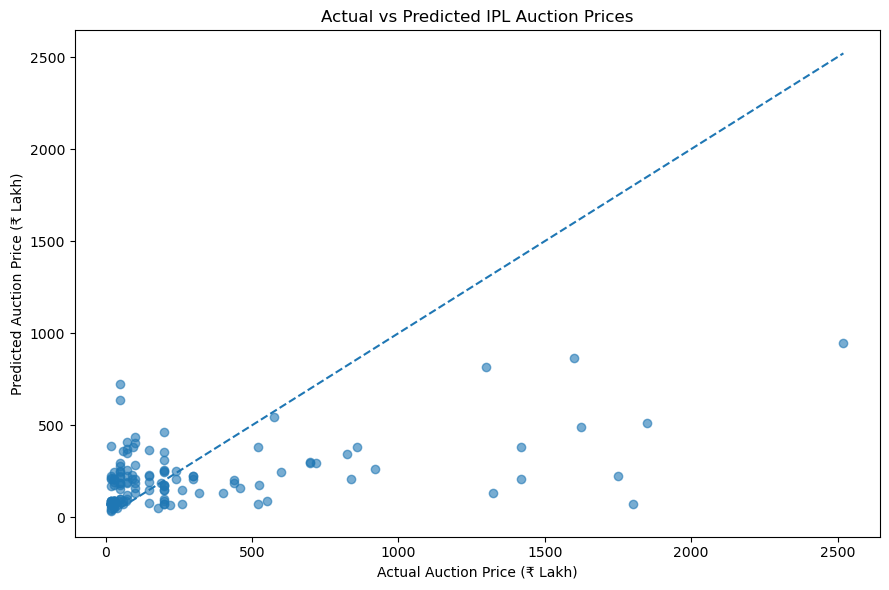

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), final_predictions.min())
max_value = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Auction Price (₹ Lakh)")
plt.ylabel("Predicted Auction Price (₹ Lakh)")
plt.title("Actual vs Predicted IPL Auction Prices")

plt.tight_layout()
plt.show()

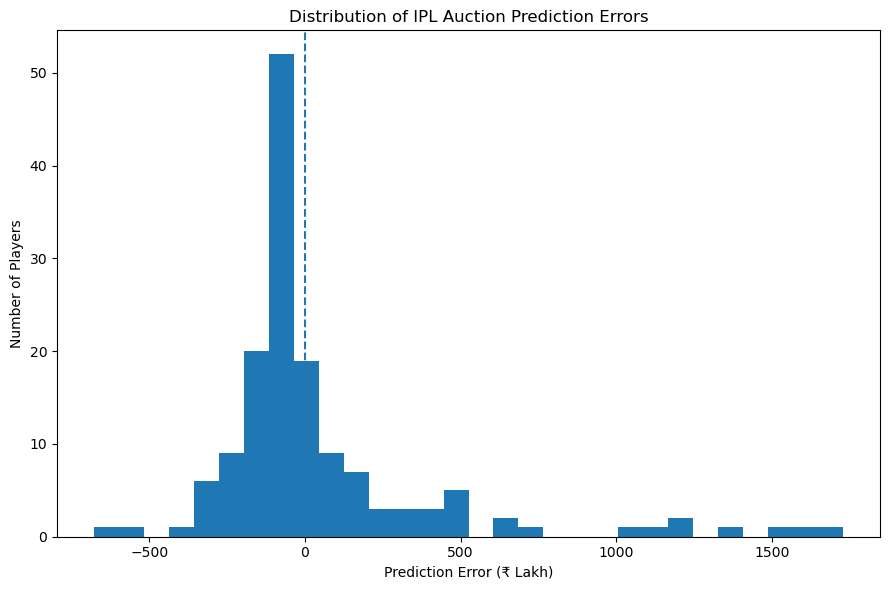

In [ ]:
errors = y_test - final_predictions

plt.figure(figsize=(9, 6))

plt.hist(errors, bins=30)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error (₹ Lakh)")
plt.ylabel("Number of Players")
plt.title("Distribution of IPL Auction Prediction Errors")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# Prepare modeling data
production_data = auction_model.copy()

production_data = production_data[
    production_data["final_price_lakh"].notna()
].copy()

# Temporal split
production_train = production_data[
    production_data["year"] <= 2022
].copy()

production_test = production_data[
    production_data["year"] > 2022
].copy()

X_train = production_train[feature_columns]
y_train = production_train["final_price_lakh"]

X_test = production_test[feature_columns]
y_test = production_test["final_price_lakh"]

# Identify categorical and numerical columns
categorical_features = ["role", "nationality"]

numerical_features = [
    col for col in feature_columns
    if col not in categorical_features
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# Complete pipeline
auction_valuation_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# Train
auction_valuation_model.fit(X_train, y_train)

print("Production model trained successfully.")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Production model trained successfully.
Training rows: 1283
Test rows: 150


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

production_predictions = auction_valuation_model.predict(X_test)

production_mae = mean_absolute_error(
    y_test,
    production_predictions
)

production_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        production_predictions
    )
)

production_r2 = r2_score(
    y_test,
    production_predictions
)

print("FINAL PRODUCTION MODEL")
print("-" * 35)
print(f"MAE  : ₹{production_mae:.2f} Lakh")
print(f"RMSE : ₹{production_rmse:.2f} Lakh")
print(f"R²   : {production_r2:.4f}")

FINAL PRODUCTION MODEL
-----------------------------------
MAE  : ₹212.88 Lakh
RMSE : ₹376.98 Lakh
R²   : 0.2364


In [ ]:
def prepare_player_for_valuation(
    player_id,
    auction_year,
    role,
    nationality
):
    
    # Get pre-auction performance
    performance = get_pre_auction_features(
        player_id,
        auction_year
    )
    
    # Create feature row
    row = performance.copy()
    
    # Player information
    row["role"] = role
    row["nationality"] = nationality
    
    # Previous auction information
    previous_auctions = auction_features[
        (auction_features["player_id"] == player_id) &
        (auction_features["year"] < auction_year)
    ].sort_values("year")
    
    if len(previous_auctions) > 0:
        row["previous_auction_price"] = (
            previous_auctions.iloc[-1]["final_price_lakh"]
        )
        
        row["previous_auction_count"] = len(previous_auctions)
        
    else:
        row["previous_auction_price"] = 0
        row["previous_auction_count"] = 0
    
    # History indicators
    row["has_batting_history"] = int(
        row["batting_seasons_before"] > 0
    )
    
    row["has_bowling_history"] = int(
        row["bowling_seasons_before"] > 0
    )
    
    # Create DataFrame
    prediction_df = pd.DataFrame([row])
    
    # Keep exactly the model features
    prediction_df = prediction_df[feature_columns]
    
    return prediction_df

In [ ]:
def predict_auction_price(
    player_id,
    auction_year,
    role,
    nationality
):
    
    # Prepare player data
    player_data = prepare_player_for_valuation(
        player_id=player_id,
        auction_year=auction_year,
        role=role,
        nationality=nationality
    )
    
    # Predict
    predicted_price = auction_valuation_model.predict(
        player_data
    )[0]
    
    # Prevent negative prediction
    predicted_price = max(0, predicted_price)
    
    return predicted_price

In [ ]:
auction_features[
    ["player_id", "player_name"]
].drop_duplicates().head(20)

,player_id,player_name
468,P0001,Ashish Reddy
1235,P0002,Ayush Badoni
23,P0005,Anil Kumble
226,P0007,Amit Mishra
47,P0008,Ashish Nehra
151,P0010,Amit Singh
1,P0011,Andrew Symonds
109,P0014,Ankit Chavan
145,P0014,Ankeet Chavan
48,P0015,Ajit Agarkar


In [ ]:
test_player = auction_model[
    auction_model["player_id"] == "P0018"
].sort_values("year")

display(
    test_player[
        [
            "year",
            "player_id",
            "player_name",
            "role",
            "nationality",
            "final_price_lakh"
        ]
    ]
)

,year,player_id,player_name,role,nationality,final_price_lakh
49,2008,P0018,AB de Villiers,Batsman,Overseas,100.0
176,2011,P0018,AB de Villiers,Unknown,Overseas,450.0


In [ ]:
ab_prediction = predict_auction_price(
    player_id="P0018",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

print(f"Predicted Auction Price: ₹{ab_prediction:.2f} Lakh")
print(f"Predicted Auction Price: ₹{ab_prediction/100:.2f} Crore")

Predicted Auction Price: ₹521.11 Lakh
Predicted Auction Price: ₹5.21 Crore


In [ ]:
ab_features = prepare_player_for_valuation(
    player_id="P0018",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

display(
    ab_features.T.rename(columns={0: "value"})
)

,value
previous_auction_price,450.0
previous_auction_count,2
role,Batsman
nationality,Overseas
career_runs_before,983
career_balls_before,815
career_innings_before,39
career_hundreds_before,1
career_fifties_before,5
career_fours_before,72


In [ ]:
def valuation_summary(
    player_id,
    auction_year,
    role,
    nationality
):
    
    # Prepare features
    player_data = prepare_player_for_valuation(
        player_id=player_id,
        auction_year=auction_year,
        role=role,
        nationality=nationality
    )
    
    # Predict
    prediction = auction_valuation_model.predict(
        player_data
    )[0]
    
    prediction = max(0, prediction)
    
    # Create summary
    summary = {
        "Player ID": player_id,
        "Auction Year": auction_year,
        "Role": role,
        "Nationality": nationality,
        "Previous Auction Price (₹L)": player_data.iloc[0]["previous_auction_price"],
        "Career Runs Before Auction": player_data.iloc[0]["career_runs_before"],
        "Recent 3-Season Runs": player_data.iloc[0]["recent3_runs"],
        "Last Season Runs": player_data.iloc[0]["last_season_runs"],
        "Career Batting SR": player_data.iloc[0]["career_batting_sr_before"],
        "Recent 3-Season SR": player_data.iloc[0]["recent3_sr"],
        "Last Season SR": player_data.iloc[0]["last_season_sr"],
        "Career Wickets Before Auction": player_data.iloc[0]["career_wickets_before"],
        "Recent 3-Season Wickets": player_data.iloc[0]["recent3_wickets"],
        "Last Season Wickets": player_data.iloc[0]["last_season_wickets"],
        "Predicted Auction Price (₹L)": prediction,
        "Predicted Auction Price (₹Cr)": prediction / 100
    }
    
    return pd.Series(summary)

In [ ]:
ab_summary = valuation_summary(
    player_id="P0018",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

display(ab_summary)

Player ID                             P0018
Auction Year                           2012
Role                                Batsman
Nationality                        Overseas
Previous Auction Price (₹L)           450.0
Career Runs Before Auction              983
Recent 3-Season Runs                    888
Last Season Runs                        312
Career Batting SR                120.613497
Recent 3-Season SR               123.849372
Last Season SR                   128.395062
Career Wickets Before Auction             0
Recent 3-Season Wickets                   0
Last Season Wickets                       0
Predicted Auction Price (₹L)     521.110522
Predicted Auction Price (₹Cr)      5.211105
dtype: object

In [ ]:
def explain_player_prediction(
    player_id,
    auction_year,
    role,
    nationality,
    top_n=10
):
    
    # Prepare original player features
    player_data = prepare_player_for_valuation(
        player_id=player_id,
        auction_year=auction_year,
        role=role,
        nationality=nationality
    ).copy()
    
    # Original prediction
    original_prediction = auction_valuation_model.predict(
        player_data
    )[0]
    
    # Get transformed feature names
    transformed_names = (
        auction_valuation_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )
    
    # Get the underlying feature importances
    importances = (
        auction_valuation_model
        .named_steps["model"]
        .feature_importances_
    )
    
    # Map transformed features back to readable names
    importance_df = pd.DataFrame({
        "feature": transformed_names,
        "importance": importances
    }).sort_values(
        "importance",
        ascending=False
    )
    
    return original_prediction, importance_df.head(top_n)

In [ ]:
ab_prediction, ab_explanation = explain_player_prediction(
    player_id="P0018",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

print(f"Predicted Auction Price: ₹{ab_prediction:.2f} Lakh")
print()
display(ab_explanation)

Predicted Auction Price: ₹521.11 Lakh



,feature,importance
0,numeric__previous_auction_price,0.308352
10,numeric__last_season_runs,0.067760
26,numeric__last_season_wickets,0.063396
15,numeric__recent3_runs,0.055903
9,numeric__career_batting_sr_before,0.055459
11,numeric__last_season_balls,0.047494
12,numeric__last_season_sr,0.041349
18,numeric__recent3_sr,0.024289
28,numeric__last_season_balls_bowled,0.022362
8,numeric__career_sixes_before,0.021019


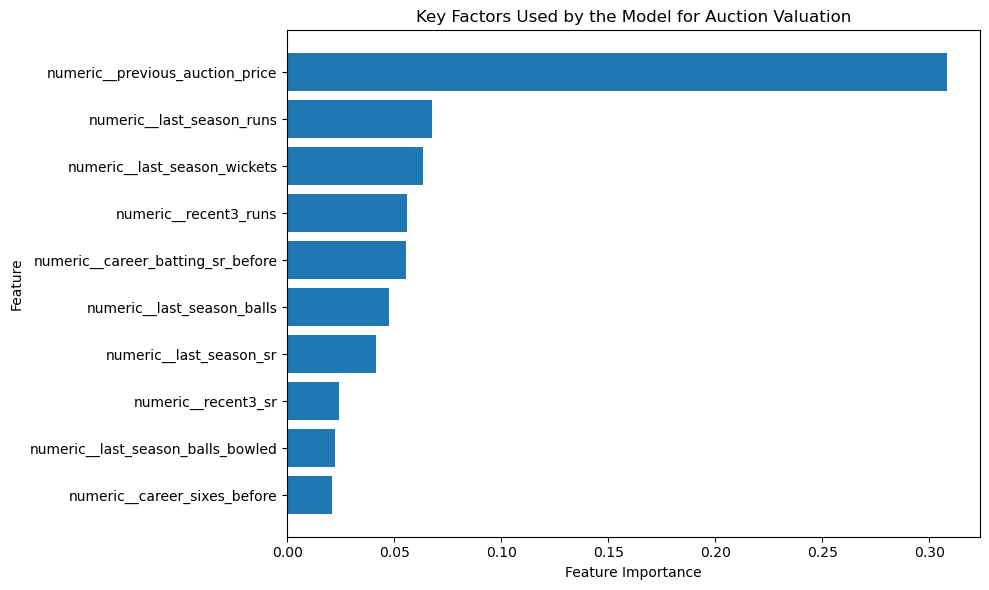

In [ ]:
plt.figure(figsize=(10, 6))

plot_data = ab_explanation.sort_values("importance")

plt.barh(
    plot_data["feature"],
    plot_data["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Key Factors Used by the Model for Auction Valuation")

plt.tight_layout()
plt.show()

In [ ]:
def generate_valuation_report(
    player_id,
    auction_year,
    role,
    nationality
):
    
    # Prepare player features
    player_data = prepare_player_for_valuation(
        player_id=player_id,
        auction_year=auction_year,
        role=role,
        nationality=nationality
    )
    
    # Prediction
    prediction = auction_valuation_model.predict(
        player_data
    )[0]
    
    prediction = max(0, prediction)
    
    # Global model importance
    transformed_names = (
        auction_valuation_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )
    
    importances = (
        auction_valuation_model
        .named_steps["model"]
        .feature_importances_
    )
    
    importance_df = pd.DataFrame({
        "feature": transformed_names,
        "importance": importances
    }).sort_values(
        "importance",
        ascending=False
    )
    
    # Remove preprocessing prefixes for readability
    importance_df["feature"] = (
        importance_df["feature"]
        .str.replace("numeric__", "", regex=False)
        .str.replace("categorical__", "", regex=False)
    )
    
    # Report
    report = {
        "Player ID": player_id,
        "Auction Year": auction_year,
        "Role": role,
        "Nationality": nationality,
        "Predicted Price (₹ Lakh)": round(prediction, 2),
        "Predicted Price (₹ Crore)": round(prediction / 100, 2),
        "Previous Auction Price (₹ Lakh)": player_data.iloc[0]["previous_auction_price"],
        "Previous Auction Count": player_data.iloc[0]["previous_auction_count"],
        "Career Runs": player_data.iloc[0]["career_runs_before"],
        "Recent 3-Season Runs": player_data.iloc[0]["recent3_runs"],
        "Last Season Runs": player_data.iloc[0]["last_season_runs"],
        "Career Batting SR": round(
            player_data.iloc[0]["career_batting_sr_before"], 2
        ),
        "Recent 3-Season SR": round(
            player_data.iloc[0]["recent3_sr"], 2
        ),
        "Last Season SR": round(
            player_data.iloc[0]["last_season_sr"], 2
        ),
        "Career Wickets": player_data.iloc[0]["career_wickets_before"],
        "Recent 3-Season Wickets": player_data.iloc[0]["recent3_wickets"],
        "Last Season Wickets": player_data.iloc[0]["last_season_wickets"],
        "Top Model Factors": importance_df.head(5)["feature"].tolist()
    }
    
    return pd.Series(report)

In [ ]:
ab_report = generate_valuation_report(
    player_id="P0018",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

display(ab_report)

Player ID                                                                      P0018
Auction Year                                                                    2012
Role                                                                         Batsman
Nationality                                                                 Overseas
Predicted Price (₹ Lakh)                                                      521.11
Predicted Price (₹ Crore)                                                       5.21
Previous Auction Price (₹ Lakh)                                                450.0
Previous Auction Count                                                             2
Career Runs                                                                      983
Recent 3-Season Runs                                                             888
Last Season Runs                                                                 312
Career Batting SR                                                

In [ ]:
# Calculate absolute errors on the final test set
absolute_errors = np.abs(
    y_test - production_predictions
)

# Calculate error percentiles
error_p50 = np.percentile(absolute_errors, 50)
error_p75 = np.percentile(absolute_errors, 75)

print(f"Median absolute error: ₹{error_p50:.2f} Lakh")
print(f"75th percentile absolute error: ₹{error_p75:.2f} Lakh")

Median absolute error: ₹103.89 Lakh
75th percentile absolute error: ₹220.77 Lakh


In [ ]:
def add_valuation_range(predicted_price):
    
    lower_bound = max(
        0,
        predicted_price - error_p75
    )
    
    upper_bound = (
        predicted_price + error_p75
    )
    
    return lower_bound, upper_bound

In [ ]:
ab_prediction = 521.11

ab_lower, ab_upper = add_valuation_range(
    ab_prediction
)

print(f"Predicted Value : ₹{ab_prediction:.2f} Lakh")
print(f"Valuation Range : ₹{ab_lower:.2f}L - ₹{ab_upper:.2f}L")
print(
    f"                 ₹{ab_lower/100:.2f}Cr - "
    f"₹{ab_upper/100:.2f}Cr"
)

Predicted Value : ₹521.11 Lakh
Valuation Range : ₹300.34L - ₹741.88L
                 ₹3.00Cr - ₹7.42Cr


In [ ]:
def add_valuation_range(predicted_price):
    
    lower_bound = max(
        0,
        predicted_price - error_p75
    )
    
    upper_bound = (
        predicted_price + error_p75
    )
    
    return lower_bound, upper_bound

In [ ]:
ab_prediction = predict_auction_price(
    player_id="P0018",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

ab_lower, ab_upper = add_valuation_range(
    ab_prediction
)

print("=" * 45)
print("       IPL AUCTION VALUATION")
print("=" * 45)

print(f"Player ID          : P0018")
print(f"Auction Year       : 2012")
print(f"Role               : Batsman")
print(f"Nationality        : Overseas")

print("-" * 45)

print(f"Predicted Value    : ₹{ab_prediction:.2f} Lakh")
print(f"                    ₹{ab_prediction/100:.2f} Crore")

print()

print(
    f"Empirical Range    : ₹{ab_lower:.2f}L - "
    f"₹{ab_upper:.2f}L"
)

print(
    f"                    ₹{ab_lower/100:.2f}Cr - "
    f"₹{ab_upper/100:.2f}Cr"
)

print("=" * 45)

       IPL AUCTION VALUATION
Player ID          : P0018
Auction Year       : 2012
Role               : Batsman
Nationality        : Overseas
---------------------------------------------
Predicted Value    : ₹521.11 Lakh
                    ₹5.21 Crore

Empirical Range    : ₹300.34L - ₹741.88L
                    ₹3.00Cr - ₹7.42Cr


In [ ]:
# Select historical auction records for testing
historical_test = auction_model[
    auction_model["final_price_lakh"].notna()
].copy()

# Exclude 2023 and 2026 because those were our original final test years
historical_test = historical_test[
    historical_test["year"] <= 2022
].copy()

# Sort by year
historical_test = historical_test.sort_values("year")

# Show available records
display(
    historical_test[
        [
            "year",
            "player_id",
            "player_name",
            "role",
            "nationality",
            "final_price_lakh"
        ]
    ].head(30)
)

,year,player_id,player_name,role,nationality,final_price_lakh
35,2008,P0515,Mohammed Asif,Bowler,Overseas,125.0
17,2008,P0575,Pragyan Ojha,Bowler,Indian,175.0
43,2008,P0783,Stephen Fleming,Batsman,Overseas,125.0
16,2008,P0574,Piyush Chawla,Bowler,Indian,175.0
69,2008,P0787,Subramaniam Badrinath,Batsman,Indian,40.0
54,2008,P0568,Parthiv Patel,Wicket-Keeper,Indian,80.0
72,2008,P0074,Albie Morkel,All-Rounder,Overseas,30.0
11,2008,P0564,Praveen Kumar,Bowler,Indian,200.0
60,2008,P0201,David Hussey,All-Rounder,Overseas,62.5
19,2008,P0205,Daniel Vettori,All-Rounder,Overseas,150.0


In [ ]:
# Create price bands
historical_test["price_band"] = pd.cut(
    historical_test["final_price_lakh"],
    bins=[-1, 50, 100, 250, 500, 1000, float("inf")],
    labels=[
        "₹0–50L",
        "₹50–100L",
        "₹100–250L",
        "₹250–500L",
        "₹500–1000L",
        "₹1000L+"
    ]
)

# Select up to 3 players from each price band
# Spread across different auction years
representative_players = (
    historical_test
    .sort_values(["price_band", "year"])
    .groupby("price_band", observed=False)
    .head(3)
    .copy()
)

display(
    representative_players[
        [
            "year",
            "player_id",
            "player_name",
            "role",
            "nationality",
            "final_price_lakh",
            "price_band"
        ]
    ]
)

,year,player_id,player_name,role,nationality,final_price_lakh,price_band
69,2008,P0787,Subramaniam Badrinath,Batsman,Indian,40.0,₹0–50L
72,2008,P0074,Albie Morkel,All-Rounder,Overseas,30.0,₹0–50L
70,2008,P0805,Tillakaratne Dilshan,Batsman,Overseas,40.0,₹0–50L
54,2008,P0568,Parthiv Patel,Wicket-Keeper,Indian,80.0,₹50–100L
60,2008,P0201,David Hussey,All-Rounder,Overseas,62.5,₹50–100L
63,2008,P0212,Dale Steyn,Bowler,Overseas,57.5,₹50–100L
35,2008,P0515,Mohammed Asif,Bowler,Overseas,125.0,₹100–250L
17,2008,P0575,Pragyan Ojha,Bowler,Indian,175.0,₹100–250L
43,2008,P0783,Stephen Fleming,Batsman,Overseas,125.0,₹100–250L
7,2008,P0640,Robin Uthappa,Batsman,Indian,300.0,₹250–500L


In [ ]:
historical_predictions = []

for _, row in representative_players.iterrows():
    
    try:
        predicted_price = predict_auction_price(
            player_id=row["player_id"],
            auction_year=row["year"],
            role=row["role"],
            nationality=row["nationality"]
        )
        
        actual_price = row["final_price_lakh"]
        
        absolute_error = abs(
            actual_price - predicted_price
        )
        
        percentage_error = (
            absolute_error / actual_price * 100
            if actual_price > 0
            else np.nan
        )
        
        historical_predictions.append({
            "Year": row["year"],
            "Player": row["player_name"],
            "Role": row["role"],
            "Nationality": row["nationality"],
            "Actual Price (₹L)": actual_price,
            "Predicted Price (₹L)": predicted_price,
            "Absolute Error (₹L)": absolute_error,
            "Error (%)": percentage_error,
            "Actual Price (₹Cr)": actual_price / 100,
            "Predicted Price (₹Cr)": predicted_price / 100
        })
        
    except Exception as e:
        print(
            f"Could not predict for {row['player_name']}: {e}"
        )

historical_prediction_df = pd.DataFrame(
    historical_predictions
)

display(
    historical_prediction_df.round(2)
)

,Year,Player,Role,Nationality,Actual Price (₹L),Predicted Price (₹L),Absolute Error (₹L),Error (%),Actual Price (₹Cr),Predicted Price (₹Cr)
0,2008,Subramaniam Badrinath,Batsman,Indian,40.0,68.77,28.77,71.94,0.40,0.69
1,2008,Albie Morkel,All-Rounder,Overseas,30.0,222.94,192.94,643.15,0.30,2.23
2,2008,Tillakaratne Dilshan,Batsman,Overseas,40.0,135.47,95.47,238.67,0.40,1.35
3,2008,Parthiv Patel,Wicket-Keeper,Indian,80.0,78.73,1.27,1.59,0.80,0.79
4,2008,David Hussey,All-Rounder,Overseas,62.5,222.94,160.44,256.71,0.62,2.23
5,2008,Dale Steyn,Bowler,Overseas,57.5,187.63,130.13,226.31,0.57,1.88
6,2008,Mohammed Asif,Bowler,Overseas,125.0,187.63,62.63,50.10,1.25,1.88
7,2008,Pragyan Ojha,Bowler,Indian,175.0,88.87,86.13,49.22,1.75,0.89
8,2008,Stephen Fleming,Batsman,Overseas,125.0,135.47,10.47,8.37,1.25,1.35
9,2008,Robin Uthappa,Batsman,Indian,300.0,68.77,231.23,77.08,3.00,0.69


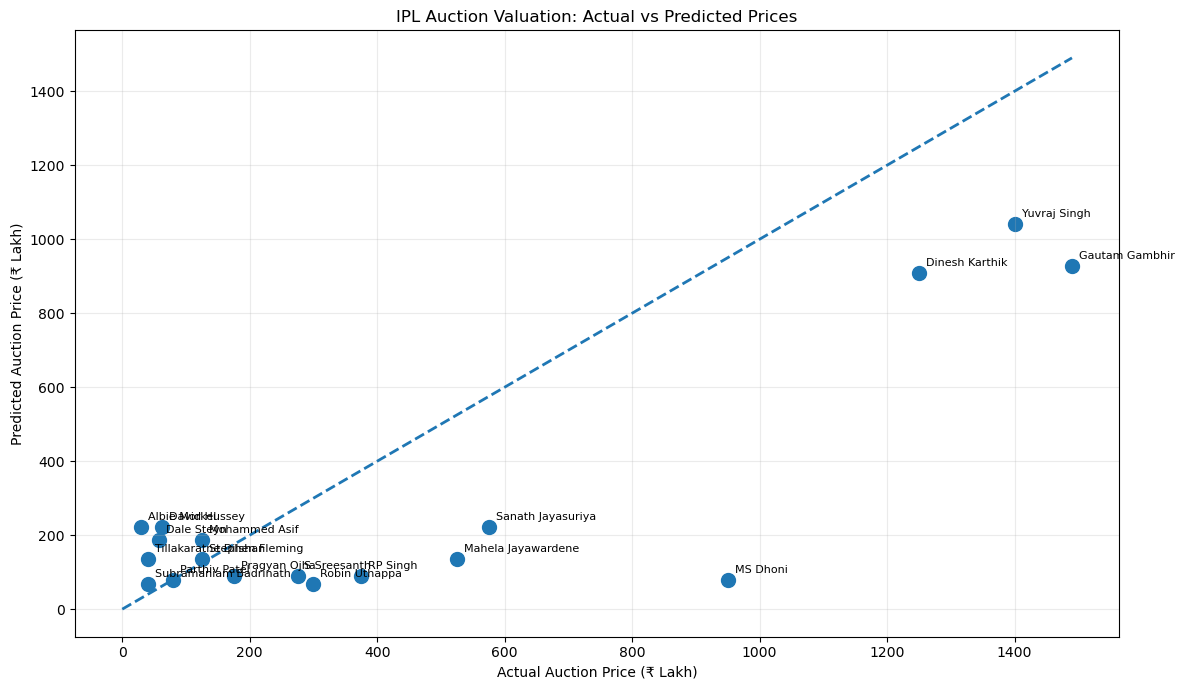

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(
    historical_prediction_df["Actual Price (₹L)"],
    historical_prediction_df["Predicted Price (₹L)"],
    s=100
)

# Perfect prediction line
max_price = max(
    historical_prediction_df["Actual Price (₹L)"].max(),
    historical_prediction_df["Predicted Price (₹L)"].max()
)

plt.plot(
    [0, max_price],
    [0, max_price],
    linestyle="--",
    linewidth=2
)

# Add player labels
for _, row in historical_prediction_df.iterrows():
    plt.annotate(
        row["Player"],
        (
            row["Actual Price (₹L)"],
            row["Predicted Price (₹L)"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Actual Auction Price (₹ Lakh)")
plt.ylabel("Predicted Auction Price (₹ Lakh)")
plt.title("IPL Auction Valuation: Actual vs Predicted Prices")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

walk_forward_results = []

auction_years = sorted(
    auction_model["year"].dropna().unique()
)

for test_year in auction_years:
    
    # We need at least one previous auction year for training
    previous_years = [
        year for year in auction_years
        if year < test_year
    ]
    
    if len(previous_years) == 0:
        continue
    
    train_data = auction_model[
        auction_model["year"].isin(previous_years)
    ].copy()
    
    test_data = auction_model[
        auction_model["year"] == test_year
    ].copy()
    
    # Remove rows without target
    train_data = train_data[
        train_data["final_price_lakh"].notna()
    ].copy()
    
    test_data = test_data[
        test_data["final_price_lakh"].notna()
    ].copy()
    
    if len(train_data) == 0 or len(test_data) == 0:
        continue
    
    X_train_wf = train_data[feature_columns]
    y_train_wf = train_data["final_price_lakh"]
    
    X_test_wf = test_data[feature_columns]
    y_test_wf = test_data["final_price_lakh"]
    
    # Identify feature types
    categorical_features_wf = [
        "role",
        "nationality"
    ]
    
    numerical_features_wf = [
        col for col in feature_columns
        if col not in categorical_features_wf
    ]
    
    # Preprocessing
    preprocessor_wf = ColumnTransformer(
        transformers=[
            (
                "numeric",
                SimpleImputer(strategy="median"),
                numerical_features_wf
            ),
            (
                "categorical",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]),
                categorical_features_wf
            )
        ]
    )
    
    # Random Forest
    rf_wf = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
    
    walk_forward_model = Pipeline([
        ("preprocessor", preprocessor_wf),
        ("model", rf_wf)
    ])
    
    # Train only on previous auction years
    walk_forward_model.fit(
        X_train_wf,
        y_train_wf
    )
    
    # Predict current auction year
    predictions_wf = walk_forward_model.predict(
        X_test_wf
    )
    
    # Store player-level results
    for i, (_, row) in enumerate(test_data.iterrows()):
        
        actual = row["final_price_lakh"]
        predicted = predictions_wf[i]
        
        walk_forward_results.append({
            "Year": test_year,
            "Player ID": row["player_id"],
            "Player": row["player_name"],
            "Role": row["role"],
            "Nationality": row["nationality"],
            "Actual Price (₹L)": actual,
            "Predicted Price (₹L)": predicted,
            "Absolute Error (₹L)": abs(
                actual - predicted
            ),
            "Error (%)": (
                abs(actual - predicted) / actual * 100
                if actual > 0 else np.nan
            )
        })

walk_forward_df = pd.DataFrame(
    walk_forward_results
)

display(
    walk_forward_df.head(20).round(2)
)

print(
    f"Total historical predictions: "
    f"{len(walk_forward_df)}"
)

NameError: name 'auction_model' is not defined

In [ ]:
# Overall walk-forward performance

wf_mae = mean_absolute_error(
    walk_forward_df["Actual Price (₹L)"],
    walk_forward_df["Predicted Price (₹L)"]
)

wf_rmse = np.sqrt(
    mean_squared_error(
        walk_forward_df["Actual Price (₹L)"],
        walk_forward_df["Predicted Price (₹L)"]
    )
)

wf_r2 = r2_score(
    walk_forward_df["Actual Price (₹L)"],
    walk_forward_df["Predicted Price (₹L)"]
)

print("WALK-FORWARD BACKTEST RESULTS")
print("-" * 40)
print(f"Total predictions : {len(walk_forward_df):,}")
print(f"MAE               : ₹{wf_mae:.2f} Lakh")
print(f"RMSE              : ₹{wf_rmse:.2f} Lakh")
print(f"R²                : {wf_r2:.4f}")

WALK-FORWARD BACKTEST RESULTS
----------------------------------------
Total predictions : 1,354
MAE               : ₹165.36 Lakh
RMSE              : ₹260.00 Lakh
R²                : 0.2011


In [ ]:
# Year-wise walk-forward performance

yearly_results = []

for year, group in walk_forward_df.groupby("Year"):
    
    actual = group["Actual Price (₹L)"]
    predicted = group["Predicted Price (₹L)"]
    
    yearly_results.append({
        "Year": year,
        "Players": len(group),
        "MAE (₹L)": mean_absolute_error(actual, predicted),
        "RMSE (₹L)": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "R²": r2_score(actual, predicted)
            if len(group) > 1
            else np.nan
    })

yearly_results_df = pd.DataFrame(yearly_results)

display(
    yearly_results_df.round(2)
)

,Year,Players,MAE (₹L),RMSE (₹L),R²
0,2009,44,141.61,185.83,-0.25
1,2010,40,83.67,103.63,-0.28
2,2011,126,188.82,283.98,-0.52
3,2012,25,123.43,171.69,0.45
4,2013,37,171.84,213.31,-0.22
5,2014,153,151.17,202.01,0.09
6,2015,67,153.73,206.12,0.33
7,2016,94,120.61,167.14,0.31
8,2017,66,139.92,241.91,0.05
9,2018,167,157.40,239.07,0.23


In [ ]:
# Year-wise walk-forward performance

yearly_results = []

for year, group in walk_forward_df.groupby("Year"):
    
    actual = group["Actual Price (₹L)"]
    predicted = group["Predicted Price (₹L)"]
    
    yearly_results.append({
        "Year": year,
        "Players": len(group),
        "MAE (₹L)": mean_absolute_error(actual, predicted),
        "RMSE (₹L)": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "R²": r2_score(actual, predicted)
            if len(group) > 1
            else np.nan
    })

yearly_results_df = pd.DataFrame(yearly_results)

display(
    yearly_results_df.round(2)
)

,Year,Players,MAE (₹L),RMSE (₹L),R²
0,2009,44,141.61,185.83,-0.25
1,2010,40,83.67,103.63,-0.28
2,2011,126,188.82,283.98,-0.52
3,2012,25,123.43,171.69,0.45
4,2013,37,171.84,213.31,-0.22
5,2014,153,151.17,202.01,0.09
6,2015,67,153.73,206.12,0.33
7,2016,94,120.61,167.14,0.31
8,2017,66,139.92,241.91,0.05
9,2018,167,157.40,239.07,0.23


In [ ]:
# Performance by actual auction price band

walk_forward_df["Price Band"] = pd.cut(
    walk_forward_df["Actual Price (₹L)"],
    bins=[
        -1,
        50,
        100,
        250,
        500,
        1000,
        float("inf")
    ],
    labels=[
        "₹0–50L",
        "₹50–100L",
        "₹100–250L",
        "₹250–500L",
        "₹500–1000L",
        "₹1000L+"
    ]
)

band_results = []

for band, group in walk_forward_df.groupby(
    "Price Band",
    observed=False
):
    
    actual = group["Actual Price (₹L)"]
    predicted = group["Predicted Price (₹L)"]
    
    band_results.append({
        "Price Band": band,
        "Players": len(group),
        "Actual Avg (₹L)": actual.mean(),
        "Predicted Avg (₹L)": predicted.mean(),
        "MAE (₹L)": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE (₹L)": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )
    })

band_results_df = pd.DataFrame(band_results)

display(
    band_results_df.round(2)
)

,Price Band,Players,Actual Avg (₹L),Predicted Avg (₹L),MAE (₹L),RMSE (₹L)
0,₹0–50L,580,26.09,118.96,92.90,115.42
1,₹50–100L,177,82.71,174.91,100.90,146.15
2,₹100–250L,241,179.59,194.07,104.66,146.77
3,₹250–500L,205,369.25,205.27,209.05,235.62
4,₹500–1000L,116,725.49,308.39,430.33,476.66
5,₹1000L+,35,1393.57,417.64,975.93,1029.48


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(
    walk_forward_df["Actual Price (₹L)"],
    walk_forward_df["Predicted Price (₹L)"],
    alpha=0.35,
    s=35
)

max_price = max(
    walk_forward_df["Actual Price (₹L)"].max(),
    walk_forward_df["Predicted Price (₹L)"].max()
)

# Perfect prediction line
plt.plot(
    [0, max_price],
    [0, max_price],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Auction Price (₹ Lakh)")
plt.ylabel("Predicted Auction Price (₹ Lakh)")
plt.title(
    "IPL Auction Valuation — Walk-Forward Actual vs Predicted"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

NameError: name 'walk_forward_df' is not defined

<Figure size 1200x700 with 0 Axes>

In [46]:
required = [
    "auction",
    "auction_sold",
    "auction_features",
    "auction_model",
    "players",
    "batting",
    "bowling",
    "batting_season",
    "bowling_season",
    "feature_columns"
]

for var in required:
    print(f"{var}: {'YES' if var in globals() else 'NO'}")

auction: YES
auction_sold: YES
auction_features: NO
auction_model: NO
players: YES
batting: YES
bowling: YES
batting_season: NO
bowling_season: NO
feature_columns: NO


In [47]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Rebuild batting_season
# ============================================================

batting_clean = batting[
    batting["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_season = (
    batting_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
)

batting_season["batting_strike_rate"] = (
    batting_season["batting_strike_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ============================================================
# 2. Rebuild bowling_season
# ============================================================

bowling_clean = bowling[
    bowling["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_season = (
    bowling_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
)

bowling_season["economy_rate"] = (
    bowling_season["economy_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


print("batting_season:", batting_season.shape)
print("bowling_season:", bowling_season.shape)

display(batting_season.head())
display(bowling_season.head())

KeyError: 'player_id'

In [48]:
print("BAT TING COLUMNS:")
print(batting.columns.tolist())

print("\nBOWLING COLUMNS:")
print(bowling.columns.tolist())

print("\nAUCTION SOLD COLUMNS:")
print(auction_sold.columns.tolist())

BAT TING COLUMNS:
['player_name', 'country', 'season', 'team', 'innings', 'not_outs', 'runs_scored', 'balls_faced', 'batting_average', 'batting_strike_rate', 'highest_score', 'hundreds', 'fifties', 'fours', 'sixes']

BOWLING COLUMNS:
['player_name', 'country', 'season', 'team', 'innings', 'balls_bowled', 'total_runs_conceded', 'total_wickets', 'economy_rate', 'bowling_average', 'bowling_strike_rate', 'best_wickets', 'three_wicket_hauls', 'four_wicket_hauls', 'five_wicket_hauls']

AUCTION SOLD COLUMNS:
['year', 'player_id', 'player_name', 'team', 'base_price_lakh', 'final_price_lakh', 'role', 'nationality', 'status', 'acquisition_type', 'source']


In [49]:
print(players.columns.tolist())
display(players.head())

['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']


,player_name,country,debut_year,last_year,seasons_played,teams,career_runs,career_balls_faced,career_batting_innings,career_hundreds,career_fifties,career_highest_score,career_fours,career_sixes,career_batting_sr,career_wickets,career_bowling_innings,career_bowling_economy,career_bowling_sr
0,Virat Kohli,NaN,2008,2025,18,Royal Challengers Bengaluru,8661,6519,259,8,63,113,771,291,132.9,4,26,8.80,62.8
1,Rohit Sharma,NaN,2008,2025,18,"Mumbai Indians, Sunrisers Hyderabad",7046,5334,266,2,47,109,640,302,132.1,15,32,8.02,22.6
2,Shikhar Dhawan,NaN,2008,2024,17,"Delhi Capitals, Mumbai Indians, Punjab Kings, ...",6769,5324,221,2,51,106,768,152,127.1,4,6,8.25,12.0
3,David Warner,NaN,2009,2024,15,"Delhi Capitals, Sunrisers Hyderabad",6565,4697,184,4,62,126,663,236,139.8,0,1,12.00,NaN
4,Suresh Raina,NaN,2008,2021,13,"Chennai Super Kings, Gujarat Titans",5528,4043,200,1,39,100,506,203,136.7,25,69,7.39,36.3


In [50]:
# ==========================================
# STEP 2 — REBUILD PLAYER ID REGISTRY
# ==========================================

import pandas as pd
import numpy as np

def normalize_name(x):
    if pd.isna(x):
        return ""
    
    return (
        str(x)
        .strip()
        .lower()
        .replace(".", "")
        .replace("-", " ")
        .replace("'", "")
        .replace("  ", " ")
    )

# Create stable IDs for the master players table
player_registry = players[["player_name"]].copy()

player_registry["player_id"] = [
    f"P{i+1:04d}" for i in range(len(player_registry))
]

player_registry["name_norm"] = player_registry["player_name"].apply(normalize_name)

# Check duplicate normalized names
duplicate_registry_names = (
    player_registry[player_registry["name_norm"].duplicated(keep=False)]
    .sort_values("name_norm")
)

print("Total master players:", len(player_registry))
print("Unique normalized names:", player_registry["name_norm"].nunique())
print("Duplicate normalized names:", len(duplicate_registry_names))

display(duplicate_registry_names)

Total master players: 771
Unique normalized names: 770
Duplicate normalized names: 2


,player_name,player_id,name_norm
180,Karan Sharma,P0181,karan sharma
181,Karan Sharma,P0182,karan sharma


In [51]:
# Show duplicate player names in the master registry

if len(duplicate_registry_names) > 0:
    display(
        duplicate_registry_names[
            ["player_id", "player_name", "name_norm"]
        ]
    )
else:
    print("No duplicate normalized player names found.")

,player_id,player_name,name_norm
180,P0181,Karan Sharma,karan sharma
181,P0182,Karan Sharma,karan sharma


In [52]:
# ==========================================
# STEP 4 — MAP BATTING & BOWLING TO PLAYER IDs
# ==========================================

# Create lookup only for names that are unique in the master registry
unique_registry = player_registry[
    ~player_registry["name_norm"].duplicated(keep=False)
].copy()

name_to_id = dict(
    zip(unique_registry["name_norm"], unique_registry["player_id"])
)

# Copy original datasets
batting_mapped = batting.copy()
bowling_mapped = bowling.copy()

# Normalize performance names
batting_mapped["name_norm"] = batting_mapped["player_name"].apply(normalize_name)
bowling_mapped["name_norm"] = bowling_mapped["player_name"].apply(normalize_name)

# Exact matching
batting_mapped["player_id"] = batting_mapped["name_norm"].map(name_to_id)
bowling_mapped["player_id"] = bowling_mapped["name_norm"].map(name_to_id)

print("BATTING")
print("Total rows:", len(batting_mapped))
print("Mapped:", batting_mapped["player_id"].notna().sum())
print("Unmapped:", batting_mapped["player_id"].isna().sum())

print("\nBOWLING")
print("Total rows:", len(bowling_mapped))
print("Mapped:", bowling_mapped["player_id"].notna().sum())
print("Unmapped:", bowling_mapped["player_id"].isna().sum())

BATTING
Total rows: 2782
Mapped: 2771
Unmapped: 11

BOWLING
Total rows: 2075
Mapped: 2064
Unmapped: 11


In [53]:
# ==========================================
# CHECK UNMATCHED PERFORMANCE NAMES
# ==========================================

unmapped_batting_names = (
    batting_mapped.loc[
        batting_mapped["player_id"].isna(),
        ["player_name", "name_norm"]
    ]
    .drop_duplicates()
    .sort_values("player_name")
)

unmapped_bowling_names = (
    bowling_mapped.loc[
        bowling_mapped["player_id"].isna(),
        ["player_name", "name_norm"]
    ]
    .drop_duplicates()
    .sort_values("player_name")
)

print("Unmatched batting names:", len(unmapped_batting_names))
display(unmapped_batting_names.head(100))

print("\nUnmatched bowling names:", len(unmapped_bowling_names))
display(unmapped_bowling_names.head(100))

Unmatched batting names: 1


,player_name,name_norm
1164,Karan Sharma,karan sharma



Unmatched bowling names: 1


,player_name,name_norm
901,Karan Sharma,karan sharma


In [54]:
# ==========================================
# STEP 5 — INVESTIGATE KARAN SHARMA
# ==========================================

print("MASTER PLAYER RECORDS")
display(
    players.iloc[[180, 181]]
)

print("\nKARAN SHARMA BATTING RECORDS")
display(
    batting[
        batting["player_name"].apply(normalize_name) == "karan sharma"
    ].sort_values(["season", "team"])
)

print("\nKARAN SHARMA BOWLING RECORDS")
display(
    bowling[
        bowling["player_name"].apply(normalize_name) == "karan sharma"
    ].sort_values(["season", "team"])
)

print("\nKARAN SHARMA AUCTION RECORDS")
display(
    auction_sold[
        auction_sold["player_name"].apply(normalize_name) == "karan sharma"
    ].sort_values("year")
)

MASTER PLAYER RECORDS


,player_name,country,debut_year,last_year,seasons_played,teams,career_runs,career_balls_faced,career_batting_innings,career_hundreds,career_fifties,career_highest_score,career_fours,career_sixes,career_batting_sr,career_wickets,career_bowling_innings,career_bowling_economy,career_bowling_sr
180,Karan Sharma,NaN,2022,2023,2,Lucknow Super Giants,368,320,43,0,0,39,21,17,115.0,83,87,8.38,19.1
181,Karan Sharma,NaN,2009,2025,12,"Chennai Super Kings, Mumbai Indians, Royal Cha...",368,320,43,0,0,39,21,17,115.0,83,87,8.38,19.1



KARAN SHARMA BATTING RECORDS


,player_name,country,season,team,innings,not_outs,runs_scored,balls_faced,batting_average,batting_strike_rate,highest_score,hundreds,fifties,fours,sixes
1164,Karan Sharma,NaN,2009,Royal Challengers Bengaluru,1,0,1,3,1.00,33.3,1,0,0,0,0
1165,Karan Sharma,NaN,2013,Sunrisers Hyderabad,7,1,85,86,14.17,98.8,39,0,0,6,2
1166,Karan Sharma,NaN,2014,Sunrisers Hyderabad,8,4,42,29,10.50,144.8,17,0,0,1,3
1167,Karan Sharma,NaN,2015,Sunrisers Hyderabad,9,3,104,85,17.33,122.4,32,0,0,3,6
1168,Karan Sharma,NaN,2016,Sunrisers Hyderabad,3,2,36,30,36.00,120.0,26,0,0,3,1
1169,Karan Sharma,NaN,2017,Mumbai Indians,6,0,49,41,8.17,119.5,19,0,0,5,2
1170,Karan Sharma,NaN,2022,Lucknow Super Giants,1,0,4,4,4.00,100.0,4,0,0,1,0
1172,Karan Sharma,NaN,2023,Lucknow Super Giants,2,0,12,21,6.00,57.1,9,0,0,0,0
1171,Karan Sharma,NaN,2023,Royal Challengers Bengaluru,2,0,3,5,1.50,60.0,2,0,0,0,0
1173,Karan Sharma,NaN,2024,Royal Challengers Bengaluru,3,0,31,15,10.33,206.7,20,0,0,2,3



KARAN SHARMA BOWLING RECORDS


,player_name,country,season,team,innings,balls_bowled,total_runs_conceded,total_wickets,economy_rate,bowling_average,bowling_strike_rate,best_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls
901,Karan Sharma,NaN,2013,Sunrisers Hyderabad,13,209,230,11,6.60,20.91,19.0,2,0,0,0
902,Karan Sharma,NaN,2014,Sunrisers Hyderabad,14,304,376,15,7.42,25.07,20.3,4,1,1,0
903,Karan Sharma,NaN,2015,Sunrisers Hyderabad,14,239,332,10,8.33,33.20,23.9,2,0,0,0
904,Karan Sharma,NaN,2016,Sunrisers Hyderabad,5,98,171,0,10.47,NaN,NaN,0,0,0,0
905,Karan Sharma,NaN,2017,Mumbai Indians,9,184,214,13,6.98,16.46,14.2,4,1,1,0
906,Karan Sharma,NaN,2018,Chennai Super Kings,5,57,89,4,9.37,22.25,14.2,2,0,0,0
907,Karan Sharma,NaN,2019,Chennai Super Kings,1,17,33,1,11.65,33.00,17.0,1,0,0,0
908,Karan Sharma,NaN,2020,Chennai Super Kings,5,114,165,5,8.68,33.00,22.8,2,0,0,0
909,Karan Sharma,NaN,2023,Royal Challengers Bengaluru,7,129,223,10,10.37,22.30,12.9,2,0,0,0
910,Karan Sharma,NaN,2024,Royal Challengers Bengaluru,9,144,254,7,10.58,36.29,20.6,2,0,0,0



KARAN SHARMA AUCTION RECORDS


,year,player_id,player_name,team,base_price_lakh,final_price_lakh,role,nationality,status,acquisition_type,source
2302,2022,P0395,Karan Sharma,LSG,NaN,20.0,All-Rounder,Indian,SOLD,auction,auction_2022


In [55]:
# ==========================================
# STEP 6 — FINALIZE PERFORMANCE PLAYER IDs
# ==========================================

# Start from the exact-name mappings we already created
batting_mapped["player_id"] = batting_mapped["name_norm"].map(name_to_id)
bowling_mapped["player_id"] = bowling_mapped["name_norm"].map(name_to_id)

# ------------------------------------------
# 1. Karan Sharma
# ------------------------------------------

karan_mask_bat = (
    batting_mapped["name_norm"] == "karan sharma"
)

karan_mask_bowl = (
    bowling_mapped["name_norm"] == "karan sharma"
)

# Karan Sharma associated with Lucknow Super Giants in 2022-2023
batting_mapped.loc[
    karan_mask_bat &
    batting_mapped["team"].astype(str).str.contains(
        "Lucknow Super Giants", case=False, na=False
    ) &
    batting_mapped["season"].isin([2022, 2023]),
    "player_id"
] = "P0181"

bowling_mapped.loc[
    karan_mask_bowl &
    bowling_mapped["team"].astype(str).str.contains(
        "Lucknow Super Giants", case=False, na=False
    ) &
    bowling_mapped["season"].isin([2022, 2023]),
    "player_id"
] = "P0181"

# All other Karan Sharma performance records belong to P0182
batting_mapped.loc[
    karan_mask_bat &
    batting_mapped["player_id"].isna(),
    "player_id"
] = "P0182"

bowling_mapped.loc[
    karan_mask_bowl &
    bowling_mapped["player_id"].isna(),
    "player_id"
] = "P0182"


# ------------------------------------------
# 2. Verified performance aliases
# ------------------------------------------

verified_performance_aliases = {
    "A Ashish Reddy": "P0001",
    "A T Rayudu": "P0039",
    "D L Chahar": "P0228",
    "H V Patel": "P0290",
    "DJ Hussey": "P0201",
    "DJ Willey": "P0224",
    "K L Rahul": "P0382",
    "K H Pandya": "P0275",
    "KA Pollard": "P0375",
    "M Shahrukh Khan": "P0746",
    "NL McCullum": "P0544",
    "BMAJ Mendis": "P0059"
}

alias_to_id = {
    normalize_name(k): v
    for k, v in verified_performance_aliases.items()
}

# Apply aliases only where exact registry mapping failed
for alias_norm, player_id in alias_to_id.items():
    
    mask_bat = (
        (batting_mapped["name_norm"] == alias_norm) &
        (batting_mapped["player_id"].isna())
    )
    
    mask_bowl = (
        (bowling_mapped["name_norm"] == alias_norm) &
        (bowling_mapped["player_id"].isna())
    )
    
    batting_mapped.loc[mask_bat, "player_id"] = player_id
    bowling_mapped.loc[mask_bowl, "player_id"] = player_id


# ------------------------------------------
# 3. Final mapping report
# ------------------------------------------

print("========== FINAL PERFORMANCE MAPPING ==========")

print("\nBATTING")
print("Total rows:", len(batting_mapped))
print("Mapped rows:", batting_mapped["player_id"].notna().sum())
print("Unmapped rows:", batting_mapped["player_id"].isna().sum())

print("\nBOWLING")
print("Total rows:", len(bowling_mapped))
print("Mapped rows:", bowling_mapped["player_id"].notna().sum())
print("Unmapped rows:", bowling_mapped["player_id"].isna().sum())

========== FINAL PERFORMANCE MAPPING ==========

BATTING
Total rows: 2782
Mapped rows: 2782
Unmapped rows: 0

BOWLING
Total rows: 2075
Mapped rows: 2075
Unmapped rows: 0


In [56]:
# ==========================================
# VERIFY UNMAPPED NAMES
# ==========================================

unmapped_batting_final = (
    batting_mapped[
        batting_mapped["player_id"].isna()
    ][["player_name", "name_norm"]]
    .drop_duplicates()
    .sort_values("player_name")
)

unmapped_bowling_final = (
    bowling_mapped[
        bowling_mapped["player_id"].isna()
    ][["player_name", "name_norm"]]
    .drop_duplicates()
    .sort_values("player_name")
)

print("FINAL UNMAPPED BATTING NAMES:", len(unmapped_batting_final))
display(unmapped_batting_final)

print("\nFINAL UNMAPPED BOWLING NAMES:", len(unmapped_bowling_final))
display(unmapped_bowling_final)

FINAL UNMAPPED BATTING NAMES: 0


,player_name,name_norm



FINAL UNMAPPED BOWLING NAMES: 0


,player_name,name_norm


In [57]:
# ==========================================
# STEP 7 — BUILD SEASON-LEVEL PERFORMANCE
# ==========================================

# ---------- BATTING ----------

batting_clean = batting_mapped[
    batting_mapped["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_clean["season"] = pd.to_numeric(
    batting_clean["season"],
    errors="coerce"
)

batting_season = (
    batting_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"]
    / batting_season["balls_faced"]
    * 100
)

batting_season["batting_strike_rate"] = (
    batting_season["batting_strike_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ---------- BOWLING ----------

bowling_clean = bowling_mapped[
    bowling_mapped["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_clean["season"] = pd.to_numeric(
    bowling_clean["season"],
    errors="coerce"
)

bowling_season = (
    bowling_clean
    .groupby(
        ["player_id", "season"],
        as_index=False
    )
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"]
    / bowling_season["balls_bowled"]
    * 6
)

bowling_season["economy_rate"] = (
    bowling_season["economy_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ---------- SUMMARY ----------

print("BAT TING SEASON TABLE")
print("Rows:", len(batting_season))
print("Players:", batting_season["player_id"].nunique())
print(
    "Seasons:",
    batting_season["season"].min(),
    "to",
    batting_season["season"].max()
)

print("\nBOWLING SEASON TABLE")
print("Rows:", len(bowling_season))
print("Players:", bowling_season["player_id"].nunique())
print(
    "Seasons:",
    bowling_season["season"].min(),
    "to",
    bowling_season["season"].max()
)

BAT TING SEASON TABLE
Rows: 2782
Players: 702
Seasons: 2008 to 2025

BOWLING SEASON TABLE
Rows: 2075
Players: 549
Seasons: 2008 to 2025


In [58]:
# ==========================================
# STEP 7B — VERIFY SEASON TABLES
# ==========================================

print("BATTING SEASON SAMPLE")
display(batting_season.head(10))

print("\nBOWLING SEASON SAMPLE")
display(bowling_season.head(10))

print("\nKARAN SHARMA CHECK")

print("\nP0181 — Karan Sharma (LSG)")
display(
    batting_season[
        batting_season["player_id"] == "P0181"
    ].sort_values("season")
)

print("\nP0182 — Karan Sharma (Other)")
display(
    batting_season[
        batting_season["player_id"] == "P0182"
    ].sort_values("season")
)

BATTING SEASON SAMPLE


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate
0,P0001,2008,12,1,165,157,0,0,18,4,105.095541
1,P0001,2009,13,2,246,219,0,1,22,8,112.328767
2,P0001,2010,13,1,307,212,0,1,26,12,144.811321
3,P0001,2011,16,4,557,460,0,4,55,16,121.086957
4,P0001,2012,15,2,364,326,0,2,33,9,111.656442
5,P0001,2013,16,2,634,457,0,6,64,22,138.730853
6,P0001,2014,14,1,359,294,0,2,23,16,122.108844
7,P0001,2015,16,4,505,386,0,3,35,23,130.829016
8,P0001,2016,16,4,973,640,4,7,83,38,152.031250
9,P0001,2017,10,0,308,252,0,4,23,11,122.222222



BOWLING SEASON SAMPLE


,player_id,season,innings,balls_bowled,total_runs_conceded,total_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls,economy_rate
0,P0001,2008,4,46,61,2,0,0,0,7.956522
1,P0001,2009,3,36,46,0,0,0,0,7.666667
2,P0001,2010,4,32,50,0,0,0,0,9.375000
3,P0001,2011,10,102,139,2,0,0,0,8.176471
4,P0001,2012,2,18,49,0,0,0,0,16.333333
5,P0001,2015,2,11,10,0,0,0,0,5.454545
6,P0001,2016,1,6,13,0,0,0,0,13.000000
7,P0002,2008,1,24,25,1,0,0,0,6.250000
8,P0002,2009,12,138,161,11,1,1,0,7.000000
9,P0002,2010,9,114,153,2,0,0,0,8.052632



KARAN SHARMA CHECK

P0181 — Karan Sharma (LSG)


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate
1398,P0181,2022,1,0,4,4,0,0,1,0,100.000000
1399,P0181,2023,2,0,12,21,0,0,0,0,57.142857



P0182 — Karan Sharma (Other)


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate
1400,P0182,2009,1,0,1,3,0,0,0,0,33.333333
1401,P0182,2013,7,1,85,86,0,0,6,2,98.837209
1402,P0182,2014,8,4,42,29,0,0,1,3,144.827586
1403,P0182,2015,9,3,104,85,0,0,3,6,122.352941
1404,P0182,2016,3,2,36,30,0,0,3,1,120.000000
1405,P0182,2017,6,0,49,41,0,0,5,2,119.512195
1406,P0182,2023,2,0,3,5,0,0,0,0,60.000000
1407,P0182,2024,3,0,31,15,0,0,2,3,206.666667
1408,P0182,2025,1,1,1,1,0,0,0,0,100.000000


In [59]:
# ==========================================
# STEP 8 — PRE-AUCTION FEATURE ENGINEERING
# ==========================================

def get_pre_auction_features(player_id, auction_year):

    features = {}

    # ======================================
    # BATTING HISTORY BEFORE AUCTION
    # ======================================

    bat = batting_season[
        (batting_season["player_id"] == player_id) &
        (batting_season["season"] < auction_year)
    ].sort_values("season")

    if len(bat) > 0:

        # Career totals before auction
        features["career_runs_before"] = bat["runs_scored"].sum()
        features["career_balls_before"] = bat["balls_faced"].sum()
        features["career_innings_before"] = bat["innings"].sum()
        features["career_hundreds_before"] = bat["hundreds"].sum()
        features["career_fifties_before"] = bat["fifties"].sum()
        features["career_fours_before"] = bat["fours"].sum()
        features["career_sixes_before"] = bat["sixes"].sum()

        total_balls = bat["balls_faced"].sum()

        features["career_batting_sr_before"] = (
            bat["runs_scored"].sum() / total_balls * 100
            if total_balls > 0 else 0
        )

        # Last completed season
        last = bat.iloc[-1]

        features["last_season_runs"] = last["runs_scored"]
        features["last_season_balls"] = last["balls_faced"]
        features["last_season_sr"] = last["batting_strike_rate"]
        features["last_season_fifties"] = last["fifties"]
        features["last_season_hundreds"] = last["hundreds"]

        # Most recent 3 seasons
        recent3 = bat.tail(3)

        features["recent3_runs"] = recent3["runs_scored"].sum()
        features["recent3_fifties"] = recent3["fifties"].sum()
        features["recent3_hundreds"] = recent3["hundreds"].sum()

        recent3_balls = recent3["balls_faced"].sum()

        features["recent3_sr"] = (
            recent3["runs_scored"].sum() / recent3_balls * 100
            if recent3_balls > 0 else 0
        )

        features["batting_seasons_before"] = len(bat)

    else:

        batting_defaults = [
            "career_runs_before",
            "career_balls_before",
            "career_innings_before",
            "career_hundreds_before",
            "career_fifties_before",
            "career_fours_before",
            "career_sixes_before",
            "career_batting_sr_before",
            "last_season_runs",
            "last_season_balls",
            "last_season_sr",
            "last_season_fifties",
            "last_season_hundreds",
            "recent3_runs",
            "recent3_fifties",
            "recent3_hundreds",
            "recent3_sr"
        ]

        for col in batting_defaults:
            features[col] = 0

        features["batting_seasons_before"] = 0


    # ======================================
    # BOWLING HISTORY BEFORE AUCTION
    # ======================================

    bowl = bowling_season[
        (bowling_season["player_id"] == player_id) &
        (bowling_season["season"] < auction_year)
    ].sort_values("season")

    if len(bowl) > 0:

        # Career totals before auction
        features["career_wickets_before"] = bowl["total_wickets"].sum()
        features["career_balls_bowled_before"] = bowl["balls_bowled"].sum()
        features["career_runs_conceded_before"] = bowl["total_runs_conceded"].sum()

        features["career_3w_before"] = bowl["three_wicket_hauls"].sum()
        features["career_4w_before"] = bowl["four_wicket_hauls"].sum()
        features["career_5w_before"] = bowl["five_wicket_hauls"].sum()

        total_bowling_balls = bowl["balls_bowled"].sum()

        features["career_economy_before"] = (
            bowl["total_runs_conceded"].sum()
            / total_bowling_balls
            * 6
            if total_bowling_balls > 0 else 0
        )

        # Last completed season
        last = bowl.iloc[-1]

        features["last_season_wickets"] = last["total_wickets"]
        features["last_season_economy"] = last["economy_rate"]
        features["last_season_balls_bowled"] = last["balls_bowled"]

        # Most recent 3 seasons
        recent3 = bowl.tail(3)

        features["recent3_wickets"] = recent3["total_wickets"].sum()
        features["recent3_balls_bowled"] = recent3["balls_bowled"].sum()

        recent3_balls = recent3["balls_bowled"].sum()

        features["recent3_economy"] = (
            recent3["total_runs_conceded"].sum()
            / recent3_balls
            * 6
            if recent3_balls > 0 else 0
        )

        features["bowling_seasons_before"] = len(bowl)

    else:

        bowling_defaults = [
            "career_wickets_before",
            "career_balls_bowled_before",
            "career_runs_conceded_before",
            "career_3w_before",
            "career_4w_before",
            "career_5w_before",
            "career_economy_before",
            "last_season_wickets",
            "last_season_economy",
            "last_season_balls_bowled",
            "recent3_wickets",
            "recent3_balls_bowled",
            "recent3_economy"
        ]

        for col in bowling_defaults:
            features[col] = 0

        features["bowling_seasons_before"] = 0


    return features

In [60]:
# ==========================================
# STEP 9 — TEST PRE-AUCTION FEATURES
# ==========================================

test_features = get_pre_auction_features(
    player_id="P0001",
    auction_year=2015
)

test_features

{'career_runs_before': np.int64(2632),
 'career_balls_before': np.int64(2125),
 'career_innings_before': np.int64(99),
 'career_hundreds_before': np.int64(0),
 'career_fifties_before': np.int64(16),
 'career_fours_before': np.int64(241),
 'career_sixes_before': np.int64(87),
 'career_batting_sr_before': np.float64(123.85882352941175),
 'last_season_runs': np.int64(359),
 'last_season_balls': np.int64(294),
 'last_season_sr': np.float64(122.10884353741496),
 'last_season_fifties': np.int64(2),
 'last_season_hundreds': np.int64(0),
 'recent3_runs': np.int64(1357),
 'recent3_fifties': np.int64(10),
 'recent3_hundreds': np.int64(0),
 'recent3_sr': np.float64(125.99814298978644),
 'batting_seasons_before': 7,
 'career_wickets_before': np.int64(4),
 'career_balls_bowled_before': np.int64(234),
 'career_runs_conceded_before': np.int64(345),
 'career_3w_before': np.int64(0),
 'career_4w_before': np.int64(0),
 'career_5w_before': np.int64(0),
 'career_economy_before': np.float64(8.8461538461538

In [61]:
# ==========================================
# CHECK THAT FUTURE SEASONS ARE EXCLUDED
# ==========================================

player_id = "P0001"
auction_year = 2015

bat_check = batting_season[
    (batting_season["player_id"] == player_id) &
    (batting_season["season"] < auction_year)
].sort_values("season")

bowl_check = bowling_season[
    (bowling_season["player_id"] == player_id) &
    (bowling_season["season"] < auction_year)
].sort_values("season")

print("Batting seasons used:")
print(bat_check["season"].tolist())

print("\nBowling seasons used:")
print(bowl_check["season"].tolist())

print("\nMaximum batting season:", bat_check["season"].max())
print("Maximum bowling season:", bowl_check["season"].max())
print("Auction year:", auction_year)

Batting seasons used:
[2008, 2009, 2010, 2011, 2012, 2013, 2014]

Bowling seasons used:
[2008, 2009, 2010, 2011, 2012]

Maximum batting season: 2014
Maximum bowling season: 2012
Auction year: 2015


In [62]:
# ==========================================
# STEP 10 — BUILD AUCTION FEATURE DATASET
# ==========================================

auction_features_rows = []

# Make sure auction year is numeric
auction_sold_clean = auction_sold.copy()

auction_sold_clean["year"] = pd.to_numeric(
    auction_sold_clean["year"],
    errors="coerce"
)

# Build one feature row for every SOLD auction record
for _, row in auction_sold_clean.iterrows():

    player_id = row["player_id"]
    auction_year = row["year"]

    performance_features = get_pre_auction_features(
        player_id=player_id,
        auction_year=auction_year
    )

    feature_row = {
        "player_id": player_id,
        "year": auction_year,
        "player_name": row["player_name"],
        "final_price_lakh": row["final_price_lakh"],
        "role": row["role"],
        "nationality": row["nationality"],
    }

    # Add all pre-auction performance features
    feature_row.update(performance_features)

    auction_features_rows.append(feature_row)


auction_features = pd.DataFrame(auction_features_rows)

print("Auction feature dataset created.")
print("Rows:", len(auction_features))
print("Columns:", len(auction_features.columns))

display(auction_features.head())

Auction feature dataset created.
Rows: 1434
Columns: 38


,player_id,year,player_name,final_price_lakh,role,nationality,career_runs_before,career_balls_before,career_innings_before,career_hundreds_before,...,career_4w_before,career_5w_before,career_economy_before,last_season_wickets,last_season_economy,last_season_balls_bowled,recent3_wickets,recent3_balls_bowled,recent3_economy,bowling_seasons_before
0,P0473,2008,MS Dhoni,950.0,Wicket-Keeper,Indian,0,0,0,0,...,0,0,0.0,0,0.0,0,0,0,0.0,0
1,P0011,2008,Andrew Symonds,650.0,All-Rounder,Overseas,0,0,0,0,...,0,0,0.0,0,0.0,0,0,0,0.0,0
2,P0709,2008,Sanath Jayasuriya,575.0,All-Rounder,Overseas,0,0,0,0,...,0,0,0.0,0,0.0,0,0,0,0.0,0
3,P0295,2008,Ishant Sharma,550.0,Bowler,Indian,0,0,0,0,...,0,0,0.0,0,0.0,0,0,0,0.0,0
4,P0207,2008,Mahela Jayawardene,525.0,Batsman,Overseas,0,0,0,0,...,0,0,0.0,0,0.0,0,0,0,0.0,0


In [63]:
# ==========================================
# STEP 11 — PREVIOUS AUCTION HISTORY
# ==========================================

auction_features = auction_features.sort_values(
    ["player_id", "year"]
).copy()

# Previous SOLD auction price
auction_features["previous_auction_price"] = (
    auction_features
    .groupby("player_id")["final_price_lakh"]
    .shift(1)
    .fillna(0)
)

# Number of previous SOLD auctions
auction_features["previous_auction_count"] = (
    auction_features
    .groupby("player_id")
    .cumcount()
)

# History flags
auction_features["has_batting_history"] = (
    auction_features["batting_seasons_before"] > 0
).astype(int)

auction_features["has_bowling_history"] = (
    auction_features["bowling_seasons_before"] > 0
).astype(int)

print("Previous-auction features added.")

display(
    auction_features[
        [
            "player_id",
            "year",
            "player_name",
            "final_price_lakh",
            "previous_auction_price",
            "previous_auction_count"
        ]
    ].head(20)
)

Previous-auction features added.


,player_id,year,player_name,final_price_lakh,previous_auction_price,previous_auction_count
468,P0001,2014,Ashish Reddy,20.0,0.0,0
1235,P0002,2022,Ayush Badoni,20.0,0.0,0
23,P0005,2008,Anil Kumble,125.0,0.0,0
127,P0005,2010,Anil Kumble,200.0,125.0,1
226,P0007,2011,Amit Mishra,135.0,0.0,0
479,P0007,2014,Amit Mishra,10.0,135.0,1
510,P0007,2015,Amit Mishra,350.0,10.0,2
638,P0007,2016,Amit Mishra,10.0,350.0,3
765,P0007,2018,Amit Mishra,400.0,10.0,4
1316,P0007,2023,Amit Mishra,50.0,400.0,5


In [64]:
# ==========================================
# STEP 12 — DATASET VALIDATION
# ==========================================

print("========== AUCTION FEATURES VALIDATION ==========")

print("\nRows:", len(auction_features))
print("Columns:", len(auction_features.columns))

print("\nUnique players:", auction_features["player_id"].nunique())

print(
    "\nAuction years:",
    sorted(auction_features["year"].dropna().unique().tolist())
)

print(
    "\nMissing target values:",
    auction_features["final_price_lakh"].isna().sum()
)

print(
    "\nMissing role values:",
    auction_features["role"].isna().sum()
)

print(
    "\nMissing nationality values:",
    auction_features["nationality"].isna().sum()
)

print("\nPrevious auction history:")
print(
    auction_features["previous_auction_count"]
    .value_counts()
    .sort_index()
    .head(10)
)

========== AUCTION FEATURES VALIDATION ==========

Rows: 1434
Columns: 42

Unique players: 712

Auction years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2026]

Missing target values: 1

Missing role values: 152

Missing nationality values: 0

Previous auction history:
previous_auction_count
0    712
1    364
2    189
3     96
4     39
5     17
6      6
7      2
8      2
9      2
Name: count, dtype: int64


In [65]:
# ==========================================
# STEP 12B — CHECK PRICE DISTRIBUTION
# ==========================================

print("Auction price statistics:")

display(
    auction_features["final_price_lakh"]
    .describe()
)

print("\nSample rows with previous auction history:")

display(
    auction_features[
        auction_features["previous_auction_count"] > 0
    ][
        [
            "player_id",
            "year",
            "player_name",
            "previous_auction_price",
            "previous_auction_count",
            "final_price_lakh"
        ]
    ].head(20)
)

Auction price statistics:


count    1433.000000
mean      204.948011
std       285.389855
min         9.000000
25%        30.000000
50%        95.000000
75%       260.000000
max      2520.000000
Name: final_price_lakh, dtype: float64


Sample rows with previous auction history:


,player_id,year,player_name,previous_auction_price,previous_auction_count,final_price_lakh
127,P0005,2010,Anil Kumble,125.0,1,200.0
479,P0007,2014,Amit Mishra,135.0,1,10.0
510,P0007,2015,Amit Mishra,10.0,2,350.0
638,P0007,2016,Amit Mishra,350.0,3,10.0
765,P0007,2018,Amit Mishra,10.0,4,400.0
1316,P0007,2023,Amit Mishra,400.0,5,50.0
135,P0008,2010,Ashish Nehra,100.0,1,50.0
186,P0008,2011,Ashish Nehra,50.0,2,382.5
395,P0008,2014,Ashish Nehra,382.5,3,200.0
577,P0008,2016,Ashish Nehra,200.0,4,550.0


In [66]:
# ==========================================
# STEP 13 — FIND MISSING TARGET
# ==========================================

missing_target = auction_features[
    auction_features["final_price_lakh"].isna()
].copy()

print("Rows with missing final_price_lakh:", len(missing_target))

display(
    missing_target[
        [
            "player_id",
            "year",
            "player_name",
            "role",
            "nationality",
            "previous_auction_price",
            "previous_auction_count"
        ]
    ]
)

Rows with missing final_price_lakh: 1


,player_id,year,player_name,role,nationality,previous_auction_price,previous_auction_count
289,P0784,2011,Stephen O'Keefe,None,Overseas,0.0,0


In [67]:
# ==========================================
# CHECK ORIGINAL AUCTION RECORD
# ==========================================

if len(missing_target) > 0:

    missing_ids = missing_target["player_id"].tolist()

    display(
        auction_sold[
            auction_sold["player_id"].isin(missing_ids)
        ].sort_values(["player_id", "year"])
    )

,year,player_id,player_name,team,base_price_lakh,final_price_lakh,role,nationality,status,acquisition_type,source
492,2011,P0784,Stephen O'Keefe,KTK,NaN,NaN,None,Overseas,SOLD,auction,wikipedia_excel


In [68]:
missing_target = auction_features[
    auction_features["final_price_lakh"].isna()
].copy()

print("Rows with missing final_price_lakh:", len(missing_target))

display(missing_target)

Rows with missing final_price_lakh: 1


,player_id,year,player_name,final_price_lakh,role,nationality,career_runs_before,career_balls_before,career_innings_before,career_hundreds_before,...,last_season_economy,last_season_balls_bowled,recent3_wickets,recent3_balls_bowled,recent3_economy,bowling_seasons_before,previous_auction_price,previous_auction_count,has_batting_history,has_bowling_history
289,P0784,2011,Stephen O'Keefe,NaN,None,Overseas,0,0,0,0,...,0.0,0,0,0,0.0,0,0.0,0,0,0


In [69]:
# ==========================================
# STEP 13 — CREATE ML DATASET
# ==========================================

auction_model = auction_features[
    auction_features["final_price_lakh"].notna()
].copy()

print("Original auction feature rows:", len(auction_features))
print("Usable ML rows:", len(auction_model))
print("Removed rows:", len(auction_features) - len(auction_model))

print("\nMissing target values:")
print(auction_model["final_price_lakh"].isna().sum())

Original auction feature rows: 1434
Usable ML rows: 1433
Removed rows: 1

Missing target values:
0


In [70]:
# ==========================================
# STEP 14 — DEFINE MODEL FEATURES
# ==========================================

feature_columns = [
    "previous_auction_price",
    "previous_auction_count",
    "role",
    "nationality",

    "career_runs_before",
    "career_balls_before",
    "career_innings_before",
    "career_hundreds_before",
    "career_fifties_before",
    "career_fours_before",
    "career_sixes_before",
    "career_batting_sr_before",

    "last_season_runs",
    "last_season_balls",
    "last_season_sr",
    "last_season_fifties",
    "last_season_hundreds",

    "recent3_runs",
    "recent3_fifties",
    "recent3_hundreds",
    "recent3_sr",

    "career_wickets_before",
    "career_balls_bowled_before",
    "career_runs_conceded_before",
    "career_3w_before",
    "career_4w_before",
    "career_5w_before",
    "career_economy_before",

    "last_season_wickets",
    "last_season_economy",
    "last_season_balls_bowled",

    "recent3_wickets",
    "recent3_balls_bowled",
    "recent3_economy",

    "batting_seasons_before",
    "bowling_seasons_before",

    "has_batting_history",
    "has_bowling_history"
]

print("Number of features:", len(feature_columns))

missing_features = [
    col for col in feature_columns
    if col not in auction_model.columns
]

print("Missing features:", missing_features)

Number of features: 38
Missing features: []


In [71]:
# ==========================================
# STEP 15 — TEMPORAL TRAIN / TEST SPLIT
# ==========================================

train_data = auction_model[
    auction_model["year"] <= 2022
].copy()

test_data = auction_model[
    auction_model["year"] > 2022
].copy()

X_train = train_data[feature_columns].copy()
y_train = train_data["final_price_lakh"].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data["final_price_lakh"].copy()

print("TRAINING DATA")
print("Rows:", len(train_data))
print("Years:", train_data["year"].min(), "to", train_data["year"].max())

print("\nTEST DATA")
print("Rows:", len(test_data))
print("Years:", test_data["year"].min(), "to", test_data["year"].max())

print("\nTOTAL")
print("Train + Test:", len(train_data) + len(test_data))

TRAINING DATA
Rows: 1283
Years: 2008 to 2022

TEST DATA
Rows: 150
Years: 2023 to 2026

TOTAL
Train + Test: 1433


In [72]:
# ==========================================
# STEP 16 — RANDOM FOREST MODEL
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Categorical features
categorical_features = [
    "role",
    "nationality"
]

# Numerical features
numerical_features = [
    col for col in feature_columns
    if col not in categorical_features
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))


# ==========================================
# PREPROCESSOR
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)


# ==========================================
# RANDOM FOREST
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)


# ==========================================
# COMPLETE PIPELINE
# ==========================================

auction_valuation_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])


# ==========================================
# TRAIN
# ==========================================

auction_valuation_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Numerical features: 36
Categorical features: 2
Random Forest training completed.


In [73]:
# ==========================================
# STEP 17 — MODEL EVALUATION
# ==========================================

production_predictions = auction_valuation_model.predict(X_test)

# Prevent negative valuations
production_predictions = np.maximum(
    production_predictions,
    0
)

mae = mean_absolute_error(
    y_test,
    production_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        production_predictions
    )
)

r2 = r2_score(
    y_test,
    production_predictions
)

print("========== RANDOM FOREST RESULTS ==========")

print(f"MAE  : ₹{mae:.2f} lakh")
print(f"RMSE : ₹{rmse:.2f} lakh")
print(f"R²   : {r2:.4f}")

========== RANDOM FOREST RESULTS ==========
MAE  : ₹229.72 lakh
RMSE : ₹397.37 lakh
R²   : 0.1516


In [74]:
# ==========================================
# STEP 18 — ACTUAL VS PREDICTED
# ==========================================

test_results = test_data[
    [
        "player_id",
        "year",
        "player_name",
        "role",
        "nationality",
        "final_price_lakh"
    ]
].copy()

test_results["predicted_price_lakh"] = production_predictions

test_results["error_lakh"] = (
    test_results["final_price_lakh"]
    - test_results["predicted_price_lakh"]
)

test_results["absolute_error_lakh"] = (
    test_results["error_lakh"].abs()
)

test_results = test_results.sort_values(
    "absolute_error_lakh",
    ascending=False
)

display(
    test_results.head(15)
)

,player_id,year,player_name,role,nationality,final_price_lakh,predicted_price_lakh,error_lakh,absolute_error_lakh
1358,P0494,2026,Matheesha Pathirana,Unknown,Overseas,1800.0,88.301581,1711.698419,1711.698419
1357,P0170,2026,Cameron Green,Unknown,Overseas,2520.0,895.045681,1624.954319,1624.954319
1285,P0170,2023,Cameron Green,All-Rounder,Overseas,1750.0,186.860785,1563.139215,1563.139215
1360,P0599,2026,Prashant Veer,Unknown,Indian,1420.0,83.142884,1336.857116,1336.857116
1288,P0287,2023,Harry Brook,Batsman,Overseas,1325.0,102.632210,1222.367790,1222.367790
1359,P0395,2026,Kartik Sharma,Unknown,Indian,1420.0,200.014775,1219.985225,1219.985225
1284,P0697,2023,Sam Curran,All-Rounder,Overseas,1850.0,664.846339,1185.153661,1185.153661
1287,P0534,2023,Nicholas Pooran,Wicket-Keeper,Overseas,1600.0,697.652635,902.347365,902.347365
1364,P0114,2026,Auqib Nabi,Unknown,Indian,840.0,33.569164,806.430836,806.430836
1305,P0347,2023,Jhye Richardson,Bowler,Overseas,150.0,896.192934,-746.192934,746.192934


In [75]:
print("========== MODEL INPUT CHECK ==========")

print("Total training rows:", len(X_train))
print("Total test rows:", len(X_test))

print("\nTraining years:")
print(sorted(train_data["year"].unique()))

print("\nTest years:")
print(sorted(test_data["year"].unique()))

print("\nFeature count:", len(feature_columns))
print("\nFeature columns:")
print(feature_columns)

print("\nMissing values in X_train:")
print(X_train.isna().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum().sum())

print("\nRole distribution - TRAIN:")
print(X_train["role"].value_counts(dropna=False))

print("\nRole distribution - TEST:")
print(X_test["role"].value_counts(dropna=False))

print("\nNationality distribution - TRAIN:")
print(X_train["nationality"].value_counts(dropna=False))

print("\nNationality distribution - TEST:")
print(X_test["nationality"].value_counts(dropna=False))

========== MODEL INPUT CHECK ==========
Total training rows: 1283
Total test rows: 150

Training years:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Test years:
[np.int64(2023), np.int64(2026)]

Feature count: 38

Feature columns:
['previous_auction_price', 'previous_auction_count', 'role', 'nationality', 'career_runs_before', 'career_balls_before', 'career_innings_before', 'career_hundreds_before', 'career_fifties_before', 'career_fours_before', 'career_sixes_before', 'career_batting_sr_before', 'last_season_runs', 'last_season_balls', 'last_season_sr', 'last_season_fifties', 'last_season_hundreds', 'recent3_runs', 'recent3_fifties', 'recent3_hundreds', 'recent3_sr', 'career_wickets_before', 'career_balls_bowled_before', 'career_runs_conceded_before', 'career_3w_before', 'career_4w_before', 

In [76]:
print("========== MISSING VALUE ANALYSIS ==========")

missing_train = X_train.isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print("\nMissing values in training features:")
print(missing_train)

print("\nTotal missing values:", missing_train.sum())

print("\nMissing values by feature percentage:")
print((missing_train / len(X_train) * 100).round(2))

========== MISSING VALUE ANALYSIS ==========

Missing values in training features:
role    151
dtype: int64

Total missing values: 151

Missing values by feature percentage:
role    11.77
dtype: float64


In [77]:
print("\n========== ROLE DISTRIBUTION ==========")

print("\nTRAIN:")
print(X_train["role"].value_counts(dropna=False))

print("\nTEST:")
print(X_test["role"].value_counts(dropna=False))

print("\n========== NATIONALITY DISTRIBUTION ==========")

print("\nTRAIN:")
print(X_train["nationality"].value_counts(dropna=False))

print("\nTEST:")
print(X_test["nationality"].value_counts(dropna=False))


========== ROLE DISTRIBUTION ==========

TRAIN:
role
Bowler           404
All-Rounder      389
Batsman          233
None             151
Wicket-Keeper    106
Name: count, dtype: int64

TEST:
role
All-Rounder      44
Bowler           40
Unknown          33
Batsman          18
Wicket-Keeper    15
Name: count, dtype: int64

========== NATIONALITY DISTRIBUTION ==========

TRAIN:
nationality
Indian      749
Overseas    534
Name: count, dtype: int64

TEST:
nationality
Indian      92
Overseas    58
Name: count, dtype: int64


In [78]:
print("========== PLAYERS WITH MISSING ROLE ==========")

missing_role_train = train_data[train_data["role"].isna()][
    ["player_id", "year", "player_name", "role", "nationality", "final_price_lakh"]
].copy()

print("Count:", len(missing_role_train))

display(
    missing_role_train.sort_values(
        ["year", "final_price_lakh"],
        ascending=[True, False]
    ).head(30)
)

========== PLAYERS WITH MISSING ROLE ==========
Count: 151


,player_id,year,player_name,role,nationality,final_price_lakh
163,P0260,2011,Gautam Gambhir,None,Indian,1490.0
164,P0875,2011,Yusuf Pathan,None,Indian,945.0
165,P0640,2011,Robin Uthappa,None,Indian,900.0
166,P0622,2011,Rohit Sharma,None,Indian,855.0
167,P0297,2011,Irfan Pathan,None,Indian,810.0
168,P0888,2011,Yuvraj Singh,None,Indian,720.0
169,P0464,2011,Saurabh Tiwary,None,Indian,675.0
170,P0207,2011,Mahela Jayawardene,None,Overseas,630.0
171,P0201,2011,David Hussey,None,Overseas,540.0
172,P0165,2011,Cameron White,None,Overseas,495.0


In [79]:
print("========== UNKNOWN ROLE IN TEST ==========")

unknown_role_test = test_data[
    test_data["role"].astype(str).str.strip().str.lower().eq("unknown")
][
    ["player_id", "year", "player_name", "role", "nationality", "final_price_lakh"]
].copy()

print("Count:", len(unknown_role_test))

display(
    unknown_role_test.sort_values(
        ["year", "final_price_lakh"],
        ascending=[True, False]
    )
)

========== UNKNOWN ROLE IN TEST ==========
Count: 33


,player_id,year,player_name,role,nationality,final_price_lakh
1357,P0170,2026,Cameron Green,Unknown,Overseas,2520.0
1358,P0494,2026,Matheesha Pathirana,Unknown,Overseas,1800.0
1359,P0395,2026,Kartik Sharma,Unknown,Indian,1420.0
1360,P0599,2026,Prashant Veer,Unknown,Indian,1420.0
1361,P0428,2026,Liam Livingstone,Unknown,Overseas,1300.0
1364,P0114,2026,Auqib Nabi,Unknown,Indian,840.0
1365,P0659,2026,Ravi Bishnoi,Unknown,Indian,720.0
1367,P0848,2026,Venkatesh Iyer,Unknown,Indian,700.0
1369,P0644,2026,Rahul Chahar,Unknown,Indian,520.0
1374,P0813,2026,Tejasvi Singh,Unknown,Indian,300.0


In [80]:
# Create copies so we don't modify the original dataset
X_train_role_fixed = X_train.copy()
X_test_role_fixed = X_test.copy()

# Treat missing/unknown role information consistently
X_train_role_fixed["role"] = (
    X_train_role_fixed["role"]
    .fillna("Unknown")
    .replace("None", "Unknown")
)

X_test_role_fixed["role"] = (
    X_test_role_fixed["role"]
    .fillna("Unknown")
    .replace("None", "Unknown")
)

print("TRAIN ROLE DISTRIBUTION")
print(X_train_role_fixed["role"].value_counts(dropna=False))

print("\nTEST ROLE DISTRIBUTION")
print(X_test_role_fixed["role"].value_counts(dropna=False))

TRAIN ROLE DISTRIBUTION
role
Bowler           404
All-Rounder      389
Batsman          233
Unknown          151
Wicket-Keeper    106
Name: count, dtype: int64

TEST ROLE DISTRIBUTION
role
All-Rounder      44
Bowler           40
Unknown          33
Batsman          18
Wicket-Keeper    15
Name: count, dtype: int64


In [81]:
categorical_features_fixed = ["role", "nationality"]
numerical_features_fixed = [
    col for col in feature_columns
    if col not in categorical_features_fixed
]

preprocessor_fixed = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features_fixed
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical_features_fixed
        )
    ]
)

rf_model_fixed = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

auction_valuation_model_fixed = Pipeline([
    ("preprocessor", preprocessor_fixed),
    ("model", rf_model_fixed)
])

auction_valuation_model_fixed.fit(
    X_train_role_fixed,
    y_train
)

print("Controlled Random Forest training completed.")

Controlled Random Forest training completed.


In [82]:
predictions_fixed = auction_valuation_model_fixed.predict(
    X_test_role_fixed
)

predictions_fixed = np.maximum(predictions_fixed, 0)

mae_fixed = mean_absolute_error(
    y_test,
    predictions_fixed
)

rmse_fixed = np.sqrt(
    mean_squared_error(y_test, predictions_fixed)
)

r2_fixed = r2_score(
    y_test,
    predictions_fixed
)

print("========== CONTROLLED RANDOM FOREST ==========")
print(f"MAE  : ₹{mae_fixed:.2f} lakh")
print(f"RMSE : ₹{rmse_fixed:.2f} lakh")
print(f"R²   : {r2_fixed:.4f}")

print("\n========== COMPARISON ==========")
print(f"Original     MAE: ₹229.72L | RMSE: ₹397.37L | R²: 0.1516")
print(f"Role Fixed   MAE: ₹{mae_fixed:.2f}L | RMSE: ₹{rmse_fixed:.2f}L | R²: {r2_fixed:.4f}")

========== CONTROLLED RANDOM FOREST ==========
MAE  : ₹231.04 lakh
RMSE : ₹394.98 lakh
R²   : 0.1618

========== COMPARISON ==========
Original     MAE: ₹229.72L | RMSE: ₹397.37L | R²: 0.1516
Role Fixed   MAE: ₹231.04L | RMSE: ₹394.98L | R²: 0.1618


In [83]:
print("========== PREVIOUS AUCTION FEATURE CHECK ==========")

print("\nTraining:")
print(X_train["previous_auction_price"].describe())

print("\nTest:")
print(X_test["previous_auction_price"].describe())

print("\nZero previous auction price:")
print("Train:", (X_train["previous_auction_price"] == 0).sum())
print("Test :", (X_test["previous_auction_price"] == 0).sum())

print("\nPrevious auction count:")
print("Train:")
print(X_train["previous_auction_count"].value_counts().sort_index())

print("\nTest:")
print(X_test["previous_auction_count"].value_counts().sort_index())

========== PREVIOUS AUCTION FEATURE CHECK ==========

Training:
count    1283.000000
mean      108.644778
std       210.023673
min         0.000000
25%         0.000000
50%        10.000000
75%       125.000000
max      1600.000000
Name: previous_auction_price, dtype: float64

Test:
count     150.000000
mean      148.993333
std       320.407972
min         0.000000
25%         0.000000
50%         0.000000
75%       107.500000
max      1750.000000
Name: previous_auction_price, dtype: float64

Zero previous auction price:
Train: 632
Test : 79

Previous auction count:
Train:
previous_auction_count
0     632
1     332
2     176
3      83
4      34
5      11
6       5
7       2
8       2
9       2
10      2
11      1
12      1
Name: count, dtype: int64

Test:
previous_auction_count
0     79
1     32
2     13
3     13
4      5
5      6
6      1
11     1
Name: count, dtype: int64


In [84]:
print("========== SAMPLE PREVIOUS AUCTION VALUES ==========")

previous_check = auction_model[
    ["player_id", "year", "player_name",
     "previous_auction_price", "previous_auction_count",
     "final_price_lakh"]
].sort_values(["player_id", "year"])

display(previous_check.head(30))

========== SAMPLE PREVIOUS AUCTION VALUES ==========


,player_id,year,player_name,previous_auction_price,previous_auction_count,final_price_lakh
468,P0001,2014,Ashish Reddy,0.0,0,20.0
1235,P0002,2022,Ayush Badoni,0.0,0,20.0
23,P0005,2008,Anil Kumble,0.0,0,125.0
127,P0005,2010,Anil Kumble,125.0,1,200.0
226,P0007,2011,Amit Mishra,0.0,0,135.0
479,P0007,2014,Amit Mishra,135.0,1,10.0
510,P0007,2015,Amit Mishra,10.0,2,350.0
638,P0007,2016,Amit Mishra,350.0,3,10.0
765,P0007,2018,Amit Mishra,10.0,4,400.0
1316,P0007,2023,Amit Mishra,400.0,5,50.0


In [85]:
players_to_check = [
    ("P0018", 2012),  # AB de Villiers
    ("P0005", 2010),  # Anil Kumble
    ("P0007", 2015),  # Amit Mishra
    ("P0020", 2011),  # Adam Gilchrist
]

check_rows = []

for player_id, auction_year in players_to_check:
    row = auction_features[
        (auction_features["player_id"] == player_id) &
        (auction_features["year"] == auction_year)
    ]

    if len(row) > 0:
        check_rows.append(row)

performance_check = pd.concat(check_rows, ignore_index=True)

columns_to_check = [
    "player_id",
    "year",
    "player_name",
    "previous_auction_price",
    "previous_auction_count",
    "career_runs_before",
    "career_batting_sr_before",
    "last_season_runs",
    "last_season_sr",
    "recent3_runs",
    "recent3_sr",
    "career_wickets_before",
    "career_economy_before",
    "last_season_wickets",
    "last_season_economy",
    "batting_seasons_before",
    "bowling_seasons_before",
    "final_price_lakh"
]

display(performance_check[columns_to_check])

,player_id,year,player_name,previous_auction_price,previous_auction_count,career_runs_before,career_batting_sr_before,last_season_runs,last_season_sr,recent3_runs,recent3_sr,career_wickets_before,career_economy_before,last_season_wickets,last_season_economy,batting_seasons_before,bowling_seasons_before,final_price_lakh
0,P0005,2010,Anil Kumble,125.0,1,855,141.791045,434,140.909091,855,141.791045,8,6.258065,7,5.927711,2,2,200.0
1,P0007,2015,Amit Mishra,10.0,2,186,103.333333,166,101.219512,186,103.333333,0,0.000000,0,0.000000,2,0,350.0
2,P0020,2011,Adam Gilchrist,125.0,1,657,154.588235,185,162.280702,657,154.588235,23,7.444201,6,8.363636,2,2,405.0


In [86]:
print("========== RAW PERFORMANCE USED FOR AB DE VILLIERS ==========")

ab_id = "P0018"
ab_year = 2012

print("\nBatting seasons before 2012:")
display(
    batting_season[
        (batting_season["player_id"] == ab_id) &
        (batting_season["season"] < ab_year)
    ].sort_values("season")
)

print("\nBowling seasons before 2012:")
display(
    bowling_season[
        (bowling_season["player_id"] == ab_id) &
        (bowling_season["season"] < ab_year)
    ].sort_values("season")
)

========== RAW PERFORMANCE USED FOR AB DE VILLIERS ==========

Batting seasons before 2012:


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate



Bowling seasons before 2012:


,player_id,season,innings,balls_bowled,total_runs_conceded,total_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls,economy_rate


In [87]:
print("========== AB DE VILLIERS TRACE ==========")

print("\n1. PLAYER REGISTRY")
display(
    player_registry[
        player_registry["player_name"]
        .astype(str)
        .str.contains("Villiers", case=False, na=False)
    ]
)

print("\n2. RAW BATTING DATA")
display(
    batting[
        batting["player_name"]
        .astype(str)
        .str.contains("Villiers", case=False, na=False)
    ][["player_name", "country", "season", "team", "runs_scored",
       "balls_faced", "batting_strike_rate"]]
)

print("\n3. MAPPED BATTING DATA")
display(
    batting_mapped[
        batting_mapped["player_name"]
        .astype(str)
        .str.contains("Villiers", case=False, na=False)
    ][["player_name", "season", "team", "player_id",
       "runs_scored", "balls_faced"]]
)

print("\n4. BATTING SEASON TABLE")
display(
    batting_season[
        batting_season["player_id"] == "P0018"
    ].sort_values("season")
)

========== AB DE VILLIERS TRACE ==========

1. PLAYER REGISTRY


,player_name,player_id,name_norm
7,AB de Villiers,P0008,ab de villiers



2. RAW BATTING DATA


,player_name,country,season,team,runs_scored,balls_faced,batting_strike_rate
40,AB de Villiers,NaN,2008,Delhi Capitals,95,98,96.9
41,AB de Villiers,NaN,2009,Delhi Capitals,465,355,131.0
42,AB de Villiers,NaN,2010,Delhi Capitals,111,119,93.3
43,AB de Villiers,NaN,2011,Royal Challengers Bengaluru,312,243,128.4
44,AB de Villiers,NaN,2012,Royal Challengers Bengaluru,319,198,161.1
45,AB de Villiers,NaN,2013,Royal Challengers Bengaluru,360,219,164.4
46,AB de Villiers,NaN,2014,Royal Challengers Bengaluru,395,249,158.6
47,AB de Villiers,NaN,2015,Royal Challengers Bengaluru,513,293,175.1
48,AB de Villiers,NaN,2016,Royal Challengers Bengaluru,687,407,168.8
49,AB de Villiers,NaN,2017,Royal Challengers Bengaluru,216,163,132.5



3. MAPPED BATTING DATA


,player_name,season,team,player_id,runs_scored,balls_faced
40,AB de Villiers,2008,Delhi Capitals,P0008,95,98
41,AB de Villiers,2009,Delhi Capitals,P0008,465,355
42,AB de Villiers,2010,Delhi Capitals,P0008,111,119
43,AB de Villiers,2011,Royal Challengers Bengaluru,P0008,312,243
44,AB de Villiers,2012,Royal Challengers Bengaluru,P0008,319,198
45,AB de Villiers,2013,Royal Challengers Bengaluru,P0008,360,219
46,AB de Villiers,2014,Royal Challengers Bengaluru,P0008,395,249
47,AB de Villiers,2015,Royal Challengers Bengaluru,P0008,513,293
48,AB de Villiers,2016,Royal Challengers Bengaluru,P0008,687,407
49,AB de Villiers,2017,Royal Challengers Bengaluru,P0008,216,163



4. BATTING SEASON TABLE


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate
251,P0018,2016,14,3,255,184,0,0,23,11,138.586957
252,P0018,2017,10,0,272,177,0,1,27,15,153.672316
253,P0018,2018,13,1,548,353,0,5,52,21,155.240793
254,P0018,2019,8,0,311,205,0,3,38,14,151.707317
255,P0018,2020,12,2,328,227,0,2,27,16,144.493392
256,P0018,2021,7,0,254,166,1,0,27,13,153.012048
257,P0018,2022,17,2,863,579,4,4,83,45,149.050086
258,P0018,2023,14,0,392,282,0,4,42,14,139.007092
259,P0018,2024,11,1,359,255,2,0,36,12,140.784314
260,P0018,2025,13,4,538,330,0,5,52,24,163.030303


In [88]:
# ============================================================
# REBUILD PLAYER REGISTRY FROM CURRENT MASTER PLAYERS
# ============================================================

player_registry = players[["player_name"]].copy()

player_registry["player_id"] = [
    f"P{i:04d}" for i in range(1, len(player_registry) + 1)
]

player_registry["name_norm"] = (
    player_registry["player_name"]
    .apply(normalize_name)
)

print("Players:", len(player_registry))
print("Unique normalized names:", player_registry["name_norm"].nunique())
print("Duplicate normalized names:")

display(
    player_registry[
        player_registry["name_norm"].duplicated(keep=False)
    ].sort_values("name_norm")
)

Players: 771
Unique normalized names: 770
Duplicate normalized names:


,player_name,player_id,name_norm
180,Karan Sharma,P0181,karan sharma
181,Karan Sharma,P0182,karan sharma


In [89]:
# ============================================================
# CREATE SAFE EXACT-NAME LOOKUP
# ============================================================

unique_registry = player_registry[
    ~player_registry["name_norm"].duplicated(keep=False)
].copy()

name_to_id = dict(
    zip(
        unique_registry["name_norm"],
        unique_registry["player_id"]
    )
)

print("Unique player names available for exact mapping:", len(name_to_id))

Unique player names available for exact mapping: 769


In [90]:
# ============================================================
# REBUILD BATTING MAPPING
# ============================================================

batting_mapped = batting.copy()

batting_mapped["name_norm"] = (
    batting_mapped["player_name"]
    .apply(normalize_name)
)

batting_mapped["player_id"] = (
    batting_mapped["name_norm"]
    .map(name_to_id)
)

print(
    "Exact batting mappings:",
    batting_mapped["player_id"].notna().sum(),
    "/",
    len(batting_mapped)
)

Exact batting mappings: 2771 / 2782


In [91]:
# ============================================================
# REBUILD BOWLING MAPPING
# ============================================================

bowling_mapped = bowling.copy()

bowling_mapped["name_norm"] = (
    bowling_mapped["player_name"]
    .apply(normalize_name)
)

bowling_mapped["player_id"] = (
    bowling_mapped["name_norm"]
    .map(name_to_id)
)

print(
    "Exact bowling mappings:",
    bowling_mapped["player_id"].notna().sum(),
    "/",
    len(bowling_mapped)
)

Exact bowling mappings: 2064 / 2075


In [92]:
# ============================================================
# VERIFIED PERFORMANCE ALIASES
# alias -> canonical master player name
# ============================================================

verified_performance_aliases = {
    "A Ashish Reddy": "Ashish Reddy",
    "A T Rayudu": "Ambati Rayudu",
    "D L Chahar": "Deepak Chahar",
    "H V Patel": "Harshal Patel",
    "DJ Hussey": "David Hussey",
    "DJ Willey": "David Willey",
    "K L Rahul": "KL Rahul",
    "K H Pandya": "Krunal Pandya",
    "KA Pollard": "Kieron Pollard",
    "M Shahrukh Khan": "Shahrukh Khan",
    "NL McCullum": "Nathan McCullum",
    "BMAJ Mendis": "Ajantha Mendis"
}

alias_to_id = {}

for alias, canonical_name in verified_performance_aliases.items():
    canonical_norm = normalize_name(canonical_name)

    if canonical_norm in name_to_id:
        alias_to_id[normalize_name(alias)] = name_to_id[canonical_norm]

print("Verified aliases successfully resolved:", len(alias_to_id))

for alias_norm, player_id in alias_to_id.items():
    print(alias_norm, "→", player_id)

Verified aliases successfully resolved: 1
bmaj mendis → P0637


In [93]:
# Apply aliases to batting
for alias_norm, player_id in alias_to_id.items():
    mask = (
        batting_mapped["name_norm"] == alias_norm
    )
    batting_mapped.loc[mask, "player_id"] = player_id

# Apply aliases to bowling
for alias_norm, player_id in alias_to_id.items():
    mask = (
        bowling_mapped["name_norm"] == alias_norm
    )
    bowling_mapped.loc[mask, "player_id"] = player_id

print(
    "Batting mapped:",
    batting_mapped["player_id"].notna().sum(),
    "/",
    len(batting_mapped)
)

print(
    "Bowling mapped:",
    bowling_mapped["player_id"].notna().sum(),
    "/",
    len(bowling_mapped)
)

Batting mapped: 2771 / 2782
Bowling mapped: 2064 / 2075


In [94]:
# ============================================================
# FIND CURRENT KARAN SHARMA IDS
# ============================================================

karan_rows = player_registry[
    player_registry["name_norm"] == normalize_name("Karan Sharma")
].copy()

display(
    players.loc[
        karan_rows.index,
        ["player_name", "debut_year", "last_year", "teams"]
    ]
)

print("Current Karan Sharma IDs:")
display(karan_rows)

,player_name,debut_year,last_year,teams
180,Karan Sharma,2022,2023,Lucknow Super Giants
181,Karan Sharma,2009,2025,"Chennai Super Kings, Mumbai Indians, Royal Cha..."


Current Karan Sharma IDs:


,player_name,player_id,name_norm
180,Karan Sharma,P0181,karan sharma
181,Karan Sharma,P0182,karan sharma


In [95]:
# ============================================================
# FIX KARAN SHARMA AMBIGUITY
# ============================================================

karan_lsg_id = "P0181"
karan_other_id = "P0182"

# Batting records
karan_batting_mask = (
    batting_mapped["name_norm"] == normalize_name("Karan Sharma")
)

batting_mapped.loc[
    karan_batting_mask &
    batting_mapped["team"].astype(str).str.contains(
        "Lucknow Super Giants",
        case=False,
        na=False
    ) &
    batting_mapped["season"].isin([2022, 2023]),
    "player_id"
] = karan_lsg_id

batting_mapped.loc[
    karan_batting_mask &
    ~(
        batting_mapped["team"].astype(str).str.contains(
            "Lucknow Super Giants",
            case=False,
            na=False
        ) &
        batting_mapped["season"].isin([2022, 2023])
    ),
    "player_id"
] = karan_other_id


# Bowling records
karan_bowling_mask = (
    bowling_mapped["name_norm"] == normalize_name("Karan Sharma")
)

bowling_mapped.loc[
    karan_bowling_mask &
    bowling_mapped["team"].astype(str).str.contains(
        "Lucknow Super Giants",
        case=False,
        na=False
    ) &
    bowling_mapped["season"].isin([2022, 2023]),
    "player_id"
] = karan_lsg_id

bowling_mapped.loc[
    karan_bowling_mask &
    ~(
        bowling_mapped["team"].astype(str).str.contains(
            "Lucknow Super Giants",
            case=False,
            na=False
        ) &
        bowling_mapped["season"].isin([2022, 2023])
    ),
    "player_id"
] = karan_other_id


print("Karan Sharma batting mapping:")
display(
    batting_mapped[
        batting_mapped["name_norm"] == normalize_name("Karan Sharma")
    ][["player_name", "season", "team", "player_id"]]
)

print("\nKaran Sharma bowling mapping:")
display(
    bowling_mapped[
        bowling_mapped["name_norm"] == normalize_name("Karan Sharma")
    ][["player_name", "season", "team", "player_id"]]
)

Karan Sharma batting mapping:


,player_name,season,team,player_id
1164,Karan Sharma,2009,Royal Challengers Bengaluru,P0182
1165,Karan Sharma,2013,Sunrisers Hyderabad,P0182
1166,Karan Sharma,2014,Sunrisers Hyderabad,P0182
1167,Karan Sharma,2015,Sunrisers Hyderabad,P0182
1168,Karan Sharma,2016,Sunrisers Hyderabad,P0182
1169,Karan Sharma,2017,Mumbai Indians,P0182
1170,Karan Sharma,2022,Lucknow Super Giants,P0181
1171,Karan Sharma,2023,Royal Challengers Bengaluru,P0182
1172,Karan Sharma,2023,Lucknow Super Giants,P0181
1173,Karan Sharma,2024,Royal Challengers Bengaluru,P0182



Karan Sharma bowling mapping:


,player_name,season,team,player_id
901,Karan Sharma,2013,Sunrisers Hyderabad,P0182
902,Karan Sharma,2014,Sunrisers Hyderabad,P0182
903,Karan Sharma,2015,Sunrisers Hyderabad,P0182
904,Karan Sharma,2016,Sunrisers Hyderabad,P0182
905,Karan Sharma,2017,Mumbai Indians,P0182
906,Karan Sharma,2018,Chennai Super Kings,P0182
907,Karan Sharma,2019,Chennai Super Kings,P0182
908,Karan Sharma,2020,Chennai Super Kings,P0182
909,Karan Sharma,2023,Royal Challengers Bengaluru,P0182
910,Karan Sharma,2024,Royal Challengers Bengaluru,P0182


In [96]:
print("========== AB DE VILLIERS MAPPING CHECK ==========")

ab_norm = normalize_name("AB de Villiers")

print("\nRegistry:")
display(
    player_registry[
        player_registry["name_norm"] == ab_norm
    ]
)

print("\nBatting mapping:")
display(
    batting_mapped[
        batting_mapped["name_norm"] == ab_norm
    ][["player_name", "season", "team", "player_id"]]
)

========== AB DE VILLIERS MAPPING CHECK ==========

Registry:


,player_name,player_id,name_norm
7,AB de Villiers,P0008,ab de villiers



Batting mapping:


,player_name,season,team,player_id
40,AB de Villiers,2008,Delhi Capitals,P0008
41,AB de Villiers,2009,Delhi Capitals,P0008
42,AB de Villiers,2010,Delhi Capitals,P0008
43,AB de Villiers,2011,Royal Challengers Bengaluru,P0008
44,AB de Villiers,2012,Royal Challengers Bengaluru,P0008
45,AB de Villiers,2013,Royal Challengers Bengaluru,P0008
46,AB de Villiers,2014,Royal Challengers Bengaluru,P0008
47,AB de Villiers,2015,Royal Challengers Bengaluru,P0008
48,AB de Villiers,2016,Royal Challengers Bengaluru,P0008
49,AB de Villiers,2017,Royal Challengers Bengaluru,P0008


In [97]:
# ============================================================
# REBUILD BATTING SEASON TABLE
# ============================================================

batting_clean = batting_mapped[
    batting_mapped["player_id"].notna()
].copy()

batting_numeric_cols = [
    "innings",
    "not_outs",
    "runs_scored",
    "balls_faced",
    "hundreds",
    "fifties",
    "fours",
    "sixes"
]

for col in batting_numeric_cols:
    batting_clean[col] = pd.to_numeric(
        batting_clean[col],
        errors="coerce"
    ).fillna(0)

batting_clean["season"] = pd.to_numeric(
    batting_clean["season"],
    errors="coerce"
)

batting_season = (
    batting_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "not_outs": "sum",
        "runs_scored": "sum",
        "balls_faced": "sum",
        "hundreds": "sum",
        "fifties": "sum",
        "fours": "sum",
        "sixes": "sum"
    })
)

batting_season["batting_strike_rate"] = (
    batting_season["runs_scored"] /
    batting_season["balls_faced"] * 100
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

print("Batting season rows:", len(batting_season))
print("Unique players:", batting_season["player_id"].nunique())

Batting season rows: 2781
Unique players: 701


In [98]:
# ============================================================
# REBUILD BOWLING SEASON TABLE
# ============================================================

bowling_clean = bowling_mapped[
    bowling_mapped["player_id"].notna()
].copy()

bowling_numeric_cols = [
    "innings",
    "balls_bowled",
    "total_runs_conceded",
    "total_wickets",
    "three_wicket_hauls",
    "four_wicket_hauls",
    "five_wicket_hauls"
]

for col in bowling_numeric_cols:
    bowling_clean[col] = pd.to_numeric(
        bowling_clean[col],
        errors="coerce"
    ).fillna(0)

bowling_clean["season"] = pd.to_numeric(
    bowling_clean["season"],
    errors="coerce"
)

bowling_season = (
    bowling_clean
    .groupby(["player_id", "season"], as_index=False)
    .agg({
        "innings": "sum",
        "balls_bowled": "sum",
        "total_runs_conceded": "sum",
        "total_wickets": "sum",
        "three_wicket_hauls": "sum",
        "four_wicket_hauls": "sum",
        "five_wicket_hauls": "sum"
    })
)

bowling_season["economy_rate"] = (
    bowling_season["total_runs_conceded"] /
    bowling_season["balls_bowled"] * 6
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

print("Bowling season rows:", len(bowling_season))
print("Unique players:", bowling_season["player_id"].nunique())

Bowling season rows: 2074
Unique players: 548


In [99]:
print("========== AB DE VILLIERS AFTER REBUILD ==========")

print("\nBatting:")
display(
    batting_season[
        batting_season["player_id"] == "P0008"
    ].sort_values("season")
)

print("\nBowling:")
display(
    bowling_season[
        bowling_season["player_id"] == "P0008"
    ].sort_values("season")
)

========== AB DE VILLIERS AFTER REBUILD ==========

Batting:


,player_id,season,innings,not_outs,runs_scored,balls_faced,hundreds,fifties,fours,sixes,batting_strike_rate
111,P0008,2008,6,1,95,98,0,0,5,1,96.938776
112,P0008,2009,13,4,465,355,1,3,39,12,130.985915
113,P0008,2010,7,0,111,119,0,0,7,0,93.277311
114,P0008,2011,13,3,312,243,0,2,21,14,128.395062
115,P0008,2012,13,4,319,198,0,3,26,15,161.111111
116,P0008,2013,14,3,360,219,0,2,34,15,164.383562
117,P0008,2014,13,1,395,249,0,3,26,24,158.634538
118,P0008,2015,14,3,513,293,1,2,60,22,175.085324
119,P0008,2016,16,3,687,407,1,6,57,37,168.796069
120,P0008,2017,9,1,216,163,0,1,12,16,132.515337



Bowling:


,player_id,season,innings,balls_bowled,total_runs_conceded,total_wickets,three_wicket_hauls,four_wicket_hauls,five_wicket_hauls,economy_rate


In [100]:
print("========== AUCTION ID CONSISTENCY CHECK ==========")

ab_auction = auction_sold[
    auction_sold["player_name"]
    .astype(str)
    .str.contains("AB de Villiers", case=False, na=False)
]

display(
    ab_auction[
        [
            "year",
            "player_name",
            "player_id",
            "team",
            "final_price_lakh",
            "role",
            "nationality"
        ]
    ]
)

========== AUCTION ID CONSISTENCY CHECK ==========


,year,player_name,player_id,team,final_price_lakh,role,nationality
49,2008,AB de Villiers,P0018,DC,100.0,Batsman,Overseas
375,2011,AB de Villiers,P0018,DC,450.0,None,Overseas


In [101]:
print("\n========== CURRENT REGISTRY ID ==========")

display(
    player_registry[
        player_registry["name_norm"] == normalize_name("AB de Villiers")
    ]
)


========== CURRENT REGISTRY ID ==========


,player_name,player_id,name_norm
7,AB de Villiers,P0008,ab de villiers


In [102]:
print("========== AB DE VILLIERS AUCTION RECORD ==========")

display(
    auction_sold[
        auction_sold["player_name"]
        .astype(str)
        .str.contains("AB de Villiers", case=False, na=False)
    ][
        [
            "year",
            "player_name",
            "player_id",
            "team",
            "final_price_lakh",
            "role",
            "nationality"
        ]
    ].sort_values("year")
)

========== AB DE VILLIERS AUCTION RECORD ==========


,year,player_name,player_id,team,final_price_lakh,role,nationality
49,2008,AB de Villiers,P0018,DC,100.0,Batsman,Overseas
375,2011,AB de Villiers,P0018,DC,450.0,None,Overseas


In [103]:
# ============================================================
# REBUILD AUCTION PLAYER IDs FROM CURRENT PLAYER REGISTRY
# ============================================================

auction_mapped = auction_sold.copy()

auction_mapped["name_norm"] = (
    auction_mapped["player_name"]
    .apply(normalize_name)
)

# Exact mapping using the CURRENT registry
auction_mapped["player_id"] = (
    auction_mapped["name_norm"].map(name_to_id)
)

print(
    "Auction exact mappings:",
    auction_mapped["player_id"].notna().sum(),
    "/",
    len(auction_mapped)
)

print(
    "Auction unmapped:",
    auction_mapped["player_id"].isna().sum()
)

Auction exact mappings: 886 / 1434
Auction unmapped: 548


In [104]:
print("========== AB DE VILLIERS AFTER AUCTION REMAPPING ==========")

display(
    auction_mapped[
        auction_mapped["name_norm"] == normalize_name("AB de Villiers")
    ][
        [
            "year",
            "player_name",
            "player_id",
            "team",
            "final_price_lakh",
            "role",
            "nationality"
        ]
    ].sort_values("year")
)

========== AB DE VILLIERS AFTER AUCTION REMAPPING ==========


,year,player_name,player_id,team,final_price_lakh,role,nationality
49,2008,AB de Villiers,P0008,DC,100.0,Batsman,Overseas
375,2011,AB de Villiers,P0008,DC,450.0,None,Overseas


In [105]:
# ============================================================
# FIX KARAN SHARMA AUCTION IDENTITY
# ============================================================

karan_mask = (
    auction_mapped["name_norm"] == normalize_name("Karan Sharma")
)

# Default all Karan Sharma auction records to the older/main identity
auction_mapped.loc[karan_mask, "player_id"] = karan_other_id

# Auction records associated with Lucknow Super Giants
# in 2022/2023 belong to P0181.
auction_mapped.loc[
    karan_mask &
    auction_mapped["team"].astype(str).str.contains(
        "Lucknow Super Giants",
        case=False,
        na=False
    ) &
    auction_mapped["year"].isin([2022, 2023]),
    "player_id"
] = karan_lsg_id

print("Karan Sharma auction records:")
display(
    auction_mapped[
        karan_mask
    ][
        [
            "year",
            "player_name",
            "player_id",
            "team",
            "final_price_lakh"
        ]
    ].sort_values("year")
)

Karan Sharma auction records:


,year,player_name,player_id,team,final_price_lakh
2302,2022,Karan Sharma,P0182,LSG,20.0


In [106]:
print("========== UNMAPPED AUCTION PLAYERS ==========")

unmapped_auction = auction_mapped[
    auction_mapped["player_id"].isna()
].copy()

print("Unmapped rows:", len(unmapped_auction))
print("Unique unmapped names:", unmapped_auction["player_name"].nunique())

display(
    unmapped_auction[
        [
            "year",
            "player_name",
            "team",
            "final_price_lakh",
            "role",
            "nationality"
        ]
    ].drop_duplicates("player_name").head(50)
)

========== UNMAPPED AUCTION PLAYERS ==========
Unmapped rows: 547
Unique unmapped names: 365


,year,player_name,team,final_price_lakh,role,nationality
0,2008,MS Dhoni,CSK,950.00,Wicket-Keeper,Indian
5,2008,RP Singh,DCH,375.00,Bowler,Indian
7,2008,Robin Uthappa,MI,300.00,Batsman,Indian
20,2008,Mohammed Kaif,RR,150.00,Batsman,Indian
35,2008,Mohammed Asif,DC,125.00,Bowler,Overseas
45,2008,VVS Laxman,DCH,125.00,Batsman,Indian
57,2008,James Hopes,PBKS,75.00,All-Rounder,Overseas
60,2008,David Hussey,KKR,62.50,All-Rounder,Overseas
71,2008,Ambati Rayudu,MI,30.00,Batsman,Indian
86,2009,JP Duminy,MI,456.00,Batsman,Overseas


In [107]:
print("========== ID CONSISTENCY CHECK ==========")

checks = {
    "AB de Villiers": normalize_name("AB de Villiers"),
    "Anil Kumble": normalize_name("Anil Kumble"),
    "Amit Mishra": normalize_name("Amit Mishra"),
    "Adam Gilchrist": normalize_name("Adam Gilchrist")
}

for name, norm in checks.items():

    registry_ids = player_registry.loc[
        player_registry["name_norm"] == norm,
        "player_id"
    ].tolist()

    auction_ids = auction_mapped.loc[
        auction_mapped["name_norm"] == norm,
        "player_id"
    ].dropna().unique().tolist()

    batting_ids = batting_mapped.loc[
        batting_mapped["name_norm"] == norm,
        "player_id"
    ].dropna().unique().tolist()

    print(f"\n{name}")
    print("Registry :", registry_ids)
    print("Auction  :", auction_ids)
    print("Batting  :", batting_ids)

========== ID CONSISTENCY CHECK ==========

AB de Villiers
Registry : ['P0008']
Auction  : ['P0008']
Batting  : ['P0008']

Anil Kumble
Registry : ['P0427']
Auction  : ['P0427']
Batting  : ['P0427']

Amit Mishra
Registry : ['P0178']
Auction  : ['P0178']
Batting  : ['P0178']

Adam Gilchrist
Registry : ['P0053']
Auction  : ['P0053']
Batting  : ['P0053']


In [108]:
# ============================================================
# REBUILD AUCTION FEATURES FROM CORRECTED PLAYER IDs
# ============================================================

auction_features_list = []

for _, auction_row in auction_mapped.iterrows():

    player_id = auction_row["player_id"]
    auction_year = auction_row["year"]

    # Start with auction information
    row = {
        "player_id": player_id,
        "year": auction_year,
        "player_name": auction_row["player_name"],
        "role": auction_row["role"],
        "nationality": auction_row["nationality"],
        "base_price_lakh": auction_row["base_price_lakh"],
        "final_price_lakh": auction_row["final_price_lakh"],
        "team": auction_row["team"]
    }

    # --------------------------------------------------------
    # PRE-AUCTION PERFORMANCE
    # --------------------------------------------------------
    performance = get_pre_auction_features(
        player_id,
        auction_year
    )

    row.update(performance)

    auction_features_list.append(row)

auction_features = pd.DataFrame(auction_features_list)

print("Auction feature rows:", len(auction_features))
print("Auction feature columns:", len(auction_features.columns))

Auction feature rows: 1434
Auction feature columns: 40


In [109]:
# ============================================================
# PREVIOUS AUCTION FEATURES
# ============================================================

auction_features = auction_features.sort_values(
    ["player_id", "year"]
).copy()

auction_features["previous_auction_price"] = (
    auction_features
    .groupby("player_id")["final_price_lakh"]
    .shift(1)
    .fillna(0)
)

auction_features["previous_auction_count"] = (
    auction_features
    .groupby("player_id")
    .cumcount()
)

auction_features["has_batting_history"] = (
    auction_features["batting_seasons_before"] > 0
).astype(int)

auction_features["has_bowling_history"] = (
    auction_features["bowling_seasons_before"] > 0
).astype(int)

print("Auction features rebuilt successfully.")

Auction features rebuilt successfully.


In [110]:

print("========== AB DE VILLIERS AUCTION FEATURES ==========")

ab_features = auction_features[
    auction_features["player_id"] == "P0008"
].sort_values("year")

display(
    ab_features[
        [
            "player_id",
            "year",
            "player_name",
            "previous_auction_price",
            "previous_auction_count",
            "career_runs_before",
            "career_batting_sr_before",
            "last_season_runs",
            "last_season_sr",
            "recent3_runs",
            "recent3_sr",
            "career_wickets_before",
            "career_economy_before",
            "last_season_wickets",
            "last_season_economy",
            "batting_seasons_before",
            "bowling_seasons_before",
            "final_price_lakh"
        ]
    ]
)

========== AB DE VILLIERS AUCTION FEATURES ==========


,player_id,year,player_name,previous_auction_price,previous_auction_count,career_runs_before,career_batting_sr_before,last_season_runs,last_season_sr,recent3_runs,recent3_sr,career_wickets_before,career_economy_before,last_season_wickets,last_season_economy,batting_seasons_before,bowling_seasons_before,final_price_lakh
49,P0008,2008,AB de Villiers,0.0,0.0,0,0.000000,0,0.000000,0,0.000000,0,0.0,0,0.0,0,0,100.0
176,P0008,2011,AB de Villiers,100.0,1.0,671,117.307692,111,93.277311,671,117.307692,0,0.0,0,0.0,3,0,450.0


In [111]:
print("========== PRE-AUCTION LEAKAGE CHECK ==========")

test_player = "P0008"
test_year = 2012

bat_used = batting_season[
    (batting_season["player_id"] == test_player) &
    (batting_season["season"] < test_year)
]

bowl_used = bowling_season[
    (bowling_season["player_id"] == test_player) &
    (bowling_season["season"] < test_year)
]

print("Auction year:", test_year)

print(
    "Batting seasons used:",
    sorted(bat_used["season"].tolist())
)

print(
    "Bowling seasons used:",
    sorted(bowl_used["season"].tolist())
)

print(
    "Maximum batting season:",
    bat_used["season"].max()
)

print(
    "Maximum bowling season:",
    bowl_used["season"].max()
)

assert bat_used["season"].max() < test_year
assert bowl_used["season"].max() < test_year

print("\n✓ No future-season leakage detected.")

========== PRE-AUCTION LEAKAGE CHECK ==========
Auction year: 2012
Batting seasons used: [2008, 2009, 2010, 2011]
Bowling seasons used: []
Maximum batting season: 2011
Maximum bowling season: nan


AssertionError: 

In [112]:
test_player = "P0008"
test_year = 2012

bat_used = batting_season[
    (batting_season["player_id"] == test_player) &
    (batting_season["season"] < test_year)
]

bowl_used = bowling_season[
    (bowling_season["player_id"] == test_player) &
    (bowling_season["season"] < test_year)
]

print("========== PRE-AUCTION LEAKAGE CHECK ==========")
print("Auction year:", test_year)

print("Batting seasons used:",
      sorted(bat_used["season"].dropna().unique()))

print("Bowling seasons used:",
      sorted(bowl_used["season"].dropna().unique()))

if len(bat_used) > 0:
    print("Maximum batting season:", bat_used["season"].max())
    assert bat_used["season"].max() < test_year

if len(bowl_used) > 0:
    print("Maximum bowling season:", bowl_used["season"].max())
    assert bowl_used["season"].max() < test_year
else:
    print("No bowling history before auction year — valid.")

print("\n✅ No future-season leakage detected.")

========== PRE-AUCTION LEAKAGE CHECK ==========
Auction year: 2012
Batting seasons used: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011)]
Bowling seasons used: []
Maximum batting season: 2011
No bowling history before auction year — valid.

✅ No future-season leakage detected.


In [113]:
print("Auction feature shape:", auction_features.shape)

print("\nMissing target:")
print(auction_features["final_price_lakh"].isna().sum())

print("\nRows with missing target:")
print(
    auction_features[
        auction_features["final_price_lakh"].isna()
    ][["year", "player_name", "final_price_lakh"]]
)

print("\nPlayer ID consistency:")
print(
    auction_features[
        auction_features["player_name"].str.contains(
            "AB de Villiers", case=False, na=False
        )
    ][
        ["year", "player_name", "player_id",
         "previous_auction_price",
         "career_runs_before",
         "last_season_runs",
         "recent3_runs"]
    ].head(10)
)

Auction feature shape: (1434, 44)

Missing target:
1

Rows with missing target:
     year      player_name  final_price_lakh
289  2011  Stephen O'Keefe               NaN

Player ID consistency:
     year     player_name player_id  previous_auction_price  \
49   2008  AB de Villiers     P0008                     0.0   
176  2011  AB de Villiers     P0008                   100.0   

     career_runs_before  last_season_runs  recent3_runs  
49                    0                 0             0  
176                 671               111           671  


In [114]:
# Remove rows where the auction price is unknown
auction_model = auction_features[
    auction_features["final_price_lakh"].notna()
].copy()

print("Final ML dataset shape:", auction_model.shape)

print("\nAuction years:")
print(sorted(auction_model["year"].unique()))

print("\nTarget statistics:")
print(auction_model["final_price_lakh"].describe())

Final ML dataset shape: (1433, 44)

Auction years:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2026)]

Target statistics:
count    1433.000000
mean      204.948011
std       285.389855
min         9.000000
25%        30.000000
50%        95.000000
75%       260.000000
max      2520.000000
Name: final_price_lakh, dtype: float64


In [115]:
feature_columns = [
    "previous_auction_price",
    "previous_auction_count",

    "role",
    "nationality",

    "career_runs_before",
    "career_balls_before",
    "career_innings_before",
    "career_hundreds_before",
    "career_fifties_before",
    "career_fours_before",
    "career_sixes_before",
    "career_batting_sr_before",

    "last_season_runs",
    "last_season_balls",
    "last_season_sr",
    "last_season_fifties",
    "last_season_hundreds",

    "recent3_runs",
    "recent3_fifties",
    "recent3_hundreds",
    "recent3_sr",

    "career_wickets_before",
    "career_balls_bowled_before",
    "career_runs_conceded_before",
    "career_3w_before",
    "career_4w_before",
    "career_5w_before",
    "career_economy_before",

    "last_season_wickets",
    "last_season_economy",
    "last_season_balls_bowled",

    "recent3_wickets",
    "recent3_balls_bowled",
    "recent3_economy",

    "batting_seasons_before",
    "bowling_seasons_before",

    "has_batting_history",
    "has_bowling_history"
]

print("Number of features:", len(feature_columns))

Number of features: 38


In [116]:
train_data = auction_model[
    auction_model["year"] <= 2022
].copy()

test_data = auction_model[
    auction_model["year"] > 2022
].copy()

X_train = train_data[feature_columns]
y_train = train_data["final_price_lakh"]

X_test = test_data[feature_columns]
y_test = test_data["final_price_lakh"]

print("TRAIN")
print("Rows:", len(train_data))
print("Years:", sorted(train_data["year"].unique()))

print("\nTEST")
print("Rows:", len(test_data))
print("Years:", sorted(test_data["year"].unique()))

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)

TRAIN
Rows: 1283
Years: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

TEST
Rows: 150
Years: [np.int64(2023), np.int64(2026)]

X_train: (1283, 38)
X_test: (150, 38)


In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Categorical and numerical features
categorical_features = ["role", "nationality"]

numerical_features = [
    col for col in feature_columns
    if col not in categorical_features
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# Complete pipeline
auction_valuation_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# Train
auction_valuation_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


In [118]:
# Predictions
y_pred = auction_valuation_model.predict(X_test)

# Prevent negative predicted auction prices
y_pred = np.maximum(y_pred, 0)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("========== CORRECTED RANDOM FOREST ==========")
print(f"MAE  : ₹{mae:.2f} lakh")
print(f"RMSE : ₹{rmse:.2f} lakh")
print(f"R²   : {r2:.4f}")

print("\nApproximate values in Crores:")
print(f"MAE  : ₹{mae/100:.2f} Cr")
print(f"RMSE : ₹{rmse/100:.2f} Cr")

========== CORRECTED RANDOM FOREST ==========
MAE  : ₹206.13 lakh
RMSE : ₹378.91 lakh
R²   : 0.2286

Approximate values in Crores:
MAE  : ₹2.06 Cr
RMSE : ₹3.79 Cr


In [119]:
results = test_data[
    ["year", "player_name", "role", "nationality", "final_price_lakh"]
].copy()

results["predicted_price_lakh"] = y_pred

results["error_lakh"] = (
    results["final_price_lakh"] -
    results["predicted_price_lakh"]
)

results["absolute_error_lakh"] = (
    results["error_lakh"].abs()
)

results = results.sort_values(
    "absolute_error_lakh",
    ascending=False
)

print("========== TOP 20 PREDICTION ERRORS ==========")

display(
    results[
        [
            "year",
            "player_name",
            "role",
            "final_price_lakh",
            "predicted_price_lakh",
            "error_lakh",
            "absolute_error_lakh"
        ]
    ].head(20)
)

========== TOP 20 PREDICTION ERRORS ==========


,year,player_name,role,final_price_lakh,predicted_price_lakh,error_lakh,absolute_error_lakh
1357,2026,Cameron Green,Unknown,2520.0,847.712683,1672.287317,1672.287317
1358,2026,Matheesha Pathirana,Unknown,1800.0,182.021558,1617.978442,1617.978442
1285,2023,Cameron Green,All-Rounder,1750.0,222.622333,1527.377667,1527.377667
1284,2023,Sam Curran,All-Rounder,1850.0,534.185588,1315.814412,1315.814412
1286,2023,Ben Stokes,All-Rounder,1625.0,312.256309,1312.743691,1312.743691
1359,2026,Kartik Sharma,Unknown,1420.0,118.212522,1301.787478,1301.787478
1360,2026,Prashant Veer,Unknown,1420.0,118.212522,1301.787478,1301.787478
1288,2023,Harry Brook,Batsman,1325.0,220.695084,1104.304916,1104.304916
1287,2023,Nicholas Pooran,Wicket-Keeper,1600.0,746.449315,853.550685,853.550685
1361,2026,Liam Livingstone,Unknown,1300.0,499.343569,800.656431,800.656431


In [120]:
year_performance = (
    results.groupby("year")
    .apply(
        lambda x: pd.Series({
            "players": len(x),
            "actual_avg_lakh": x["final_price_lakh"].mean(),
            "predicted_avg_lakh": x["predicted_price_lakh"].mean(),
            "MAE_lakh": x["absolute_error_lakh"].mean(),
            "RMSE_lakh": np.sqrt(
                np.mean(x["error_lakh"] ** 2)
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print("========== PERFORMANCE BY AUCTION YEAR ==========")
display(year_performance)

========== PERFORMANCE BY AUCTION YEAR ==========


,year,players,actual_avg_lakh,predicted_avg_lakh,MAE_lakh,RMSE_lakh
0,2023,73.0,224.315068,189.705513,202.420018,359.810916
1,2026,77.0,279.805195,196.291714,209.648440,396.164409


In [121]:
results["price_band"] = pd.cut(
    results["final_price_lakh"],
    bins=[-1, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "₹0–50L",
        "₹50–100L",
        "₹100–250L",
        "₹250–500L",
        "₹500L–1000L",
        "₹1000L+"
    ]
)

price_band_performance = (
    results.groupby("price_band", observed=False)
    .apply(
        lambda x: pd.Series({
            "players": len(x),
            "actual_avg_lakh": x["final_price_lakh"].mean(),
            "predicted_avg_lakh": x["predicted_price_lakh"].mean(),
            "MAE_lakh": x["absolute_error_lakh"].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

print("========== PERFORMANCE BY PRICE BAND ==========")
display(price_band_performance)

========== PERFORMANCE BY PRICE BAND ==========


,price_band,players,actual_avg_lakh,predicted_avg_lakh,MAE_lakh
0,₹0–50L,68.0,30.955882,135.274158,104.318276
1,₹50–100L,23.0,82.608696,198.866815,117.137574
2,₹100–250L,26.0,191.153846,216.979929,64.339485
3,₹250–500L,10.0,348.000000,200.347258,153.939178
4,₹500L–1000L,13.0,681.153846,287.978669,393.175177
5,₹1000L+,10.0,1661.000000,380.171148,1280.828852


In [122]:
print("========== AUCTION PRICE DISTRIBUTION ==========")

print("Mean:", auction_model["final_price_lakh"].mean())
print("Median:", auction_model["final_price_lakh"].median())
print("Maximum:", auction_model["final_price_lakh"].max())

print("\nPercentiles:")
print(
    auction_model["final_price_lakh"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

========== AUCTION PRICE DISTRIBUTION ==========
Mean: 204.9480111653873
Median: 95.0
Maximum: 2520.0

Percentiles:
0.50      95.0
0.75     260.0
0.90     540.0
0.95     800.0
0.99    1413.6
Name: final_price_lakh, dtype: float64


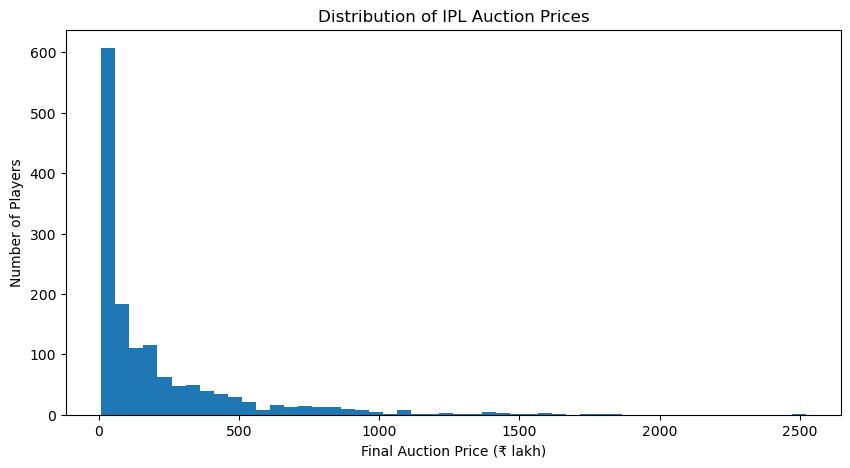

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    auction_model["final_price_lakh"],
    bins=50
)

plt.xlabel("Final Auction Price (₹ lakh)")
plt.ylabel("Number of Players")
plt.title("Distribution of IPL Auction Prices")

plt.show()

In [124]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Preprocessing
log_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

# Random Forest for log-transformed target
log_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

log_rf_model = Pipeline([
    ("preprocessor", log_preprocessor),
    ("model", log_rf)
])

# Log-transform target
y_train_log = np.log1p(y_train)

# Train
log_rf_model.fit(X_train, y_train_log)

# Predict in log space
y_pred_log = log_rf_model.predict(X_test)

# Convert back to ₹ lakh
y_pred_log_rf = np.expm1(y_pred_log)

# Prevent negative values
y_pred_log_rf = np.maximum(y_pred_log_rf, 0)

# Evaluation
log_mae = mean_absolute_error(y_test, y_pred_log_rf)
log_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_log_rf)
)
log_r2 = r2_score(y_test, y_pred_log_rf)

print("========== LOG-TARGET RANDOM FOREST ==========")
print(f"MAE  : ₹{log_mae:.2f} lakh")
print(f"RMSE : ₹{log_rmse:.2f} lakh")
print(f"R²   : {log_r2:.4f}")

print("\nApproximate values in Crores:")
print(f"MAE  : ₹{log_mae/100:.2f} Cr")
print(f"RMSE : ₹{log_rmse/100:.2f} Cr")

========== LOG-TARGET RANDOM FOREST ==========
MAE  : ₹190.69 lakh
RMSE : ₹412.51 lakh
R²   : 0.0857

Approximate values in Crores:
MAE  : ₹1.91 Cr
RMSE : ₹4.13 Cr


In [125]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Log-Target Random Forest"
    ],
    "MAE_lakh": [
        mae,
        log_mae
    ],
    "RMSE_lakh": [
        rmse,
        log_rmse
    ],
    "R2": [
        r2,
        log_r2
    ]
})

print("========== MODEL COMPARISON ==========")
display(comparison)

========== MODEL COMPARISON ==========


,Model,MAE_lakh,RMSE_lakh,R2
0,Random Forest,206.130608,378.908298,0.228584
1,Log-Target Random Forest,190.685717,412.511392,0.085692


In [126]:
print("========== ROLE DISTRIBUTION ==========")

print("\nTRAIN:")
print(
    train_data["role"]
    .fillna("Missing")
    .value_counts()
)

print("\nTEST:")
print(
    test_data["role"]
    .fillna("Missing")
    .value_counts()
)

print("\n2026 UNKNOWN PLAYERS:")
display(
    test_data[
        (test_data["year"] == 2026) &
        (
            test_data["role"].isna() |
            (test_data["role"].astype(str).str.lower() == "unknown")
        )
    ][
        [
            "player_name",
            "role",
            "nationality",
            "final_price_lakh",
            "previous_auction_price",
            "previous_auction_count",
            "last_season_runs",
            "last_season_wickets"
        ]
    ].sort_values(
        "final_price_lakh",
        ascending=False
    )
)

========== ROLE DISTRIBUTION ==========

TRAIN:
role
Bowler           404
All-Rounder      389
Batsman          233
Missing          151
Wicket-Keeper    106
Name: count, dtype: int64

TEST:
role
All-Rounder      44
Bowler           40
Unknown          33
Batsman          18
Wicket-Keeper    15
Name: count, dtype: int64

2026 UNKNOWN PLAYERS:


,player_name,role,nationality,final_price_lakh,previous_auction_price,previous_auction_count,last_season_runs,last_season_wickets
1357,Cameron Green,Unknown,Overseas,2520.0,1750.0,1.0,255,10
1358,Matheesha Pathirana,Unknown,Overseas,1800.0,0.0,NaN,0,0
1360,Prashant Veer,Unknown,Indian,1420.0,0.0,NaN,0,0
1359,Kartik Sharma,Unknown,Indian,1420.0,0.0,NaN,0,0
1361,Liam Livingstone,Unknown,Overseas,1300.0,1150.0,3.0,112,2
1364,Auqib Nabi,Unknown,Indian,840.0,0.0,NaN,0,0
1365,Ravi Bishnoi,Unknown,Indian,720.0,200.0,1.0,13,9
1367,Venkatesh Iyer,Unknown,Indian,700.0,20.0,1.0,142,0
1369,Rahul Chahar,Unknown,Indian,520.0,0.0,NaN,0,0
1374,Tejasvi Singh,Unknown,Indian,300.0,0.0,NaN,0,0


In [127]:
auction_model_role_fixed = auction_model.copy()

# Standardize missing/unknown roles
auction_model_role_fixed["role"] = (
    auction_model_role_fixed["role"]
    .fillna("Unknown")
    .astype(str)
    .replace({
        "None": "Unknown",
        "nan": "Unknown",
        "NaN": "Unknown",
        "unknown": "Unknown"
    })
)

print("========== STANDARDIZED ROLE DISTRIBUTION ==========")

print("\nTRAIN:")
print(
    auction_model_role_fixed[
        auction_model_role_fixed["year"] <= 2022
    ]["role"].value_counts()
)

print("\nTEST:")
print(
    auction_model_role_fixed[
        auction_model_role_fixed["year"] > 2022
    ]["role"].value_counts()
)

========== STANDARDIZED ROLE DISTRIBUTION ==========

TRAIN:
role
Bowler           404
All-Rounder      389
Batsman          233
Unknown          151
Wicket-Keeper    106
Name: count, dtype: int64

TEST:
role
All-Rounder      44
Bowler           40
Unknown          33
Batsman          18
Wicket-Keeper    15
Name: count, dtype: int64


In [128]:
train_role_fixed = auction_model_role_fixed[
    auction_model_role_fixed["year"] <= 2022
].copy()

test_role_fixed = auction_model_role_fixed[
    auction_model_role_fixed["year"] > 2022
].copy()

X_train_role_fixed = train_role_fixed[feature_columns]
y_train_role_fixed = train_role_fixed["final_price_lakh"]

X_test_role_fixed = test_role_fixed[feature_columns]
y_test_role_fixed = test_role_fixed["final_price_lakh"]

print("Training rows:", len(train_role_fixed))
print("Test rows:", len(test_role_fixed))
print("Features:", X_train_role_fixed.shape[1])

Training rows: 1283
Test rows: 150
Features: 38


In [129]:
role_fixed_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

role_fixed_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

role_fixed_model = Pipeline([
    ("preprocessor", role_fixed_preprocessor),
    ("model", role_fixed_rf)
])

role_fixed_model.fit(
    X_train_role_fixed,
    y_train_role_fixed
)

y_pred_role_fixed = role_fixed_model.predict(
    X_test_role_fixed
)

y_pred_role_fixed = np.maximum(
    y_pred_role_fixed,
    0
)

role_fixed_mae = mean_absolute_error(
    y_test_role_fixed,
    y_pred_role_fixed
)

role_fixed_rmse = np.sqrt(
    mean_squared_error(
        y_test_role_fixed,
        y_pred_role_fixed
    )
)

role_fixed_r2 = r2_score(
    y_test_role_fixed,
    y_pred_role_fixed
)

print("========== ROLE-FIXED RANDOM FOREST ==========")
print(f"MAE  : ₹{role_fixed_mae:.2f} lakh")
print(f"RMSE : ₹{role_fixed_rmse:.2f} lakh")
print(f"R²   : {role_fixed_r2:.4f}")

========== ROLE-FIXED RANDOM FOREST ==========
MAE  : ₹210.85 lakh
RMSE : ₹374.86 lakh
R²   : 0.2450


In [130]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Log-Target Random Forest",
        "Role-Fixed Random Forest"
    ],
    "MAE_lakh": [
        mae,
        log_mae,
        role_fixed_mae
    ],
    "RMSE_lakh": [
        rmse,
        log_rmse,
        role_fixed_rmse
    ],
    "R2": [
        r2,
        log_r2,
        role_fixed_r2
    ]
})

display(
    model_comparison.sort_values(
        "MAE_lakh"
    )
)

,Model,MAE_lakh,RMSE_lakh,R2
1,Log-Target Random Forest,190.685717,412.511392,0.085692
0,Random Forest,206.130608,378.908298,0.228584
2,Role-Fixed Random Forest,210.846208,374.859311,0.244982


In [131]:
year_model_data = auction_model_role_fixed.copy()

train_year = year_model_data[
    year_model_data["year"] <= 2022
].copy()

test_year = year_model_data[
    year_model_data["year"] > 2022
].copy()

# Add auction year as a feature
feature_columns_year = feature_columns + ["year"]

X_train_year = train_year[feature_columns_year]
y_train_year = train_year["final_price_lakh"]

X_test_year = test_year[feature_columns_year]
y_test_year = test_year["final_price_lakh"]

print("Training:", X_train_year.shape)
print("Testing :", X_test_year.shape)
print("Features:", len(feature_columns_year))

Training: (1283, 39)
Testing : (150, 39)
Features: 39


In [132]:
categorical_features_year = [
    "role",
    "nationality"
]

numerical_features_year = [
    col for col in feature_columns_year
    if col not in categorical_features_year
]

year_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features_year
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features_year
        )
    ]
)

year_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

year_model = Pipeline([
    ("preprocessor", year_preprocessor),
    ("model", year_rf)
])

year_model.fit(
    X_train_year,
    y_train_year
)

y_pred_year = year_model.predict(X_test_year)

y_pred_year = np.maximum(
    y_pred_year,
    0
)

year_mae = mean_absolute_error(
    y_test_year,
    y_pred_year
)

year_rmse = np.sqrt(
    mean_squared_error(
        y_test_year,
        y_pred_year
    )
)

year_r2 = r2_score(
    y_test_year,
    y_pred_year
)

print("========== YEAR-AWARE RANDOM FOREST ==========")
print(f"MAE  : ₹{year_mae:.2f} lakh")
print(f"RMSE : ₹{year_rmse:.2f} lakh")
print(f"R²   : {year_r2:.4f}")

========== YEAR-AWARE RANDOM FOREST ==========
MAE  : ₹243.31 lakh
RMSE : ₹384.34 lakh
R²   : 0.2063


In [133]:
print("========== PLAYER EXPERIENCE DATA ==========")

print(players[[
    "player_name",
    "debut_year",
    "last_year"
]].head(10))

print("\nMissing debut years:")
print(players["debut_year"].isna().sum())

print("\nMissing last years:")
print(players["last_year"].isna().sum())

========== PLAYER EXPERIENCE DATA ==========
      player_name  debut_year  last_year
0     Virat Kohli        2008       2025
1    Rohit Sharma        2008       2025
2  Shikhar Dhawan        2008       2024
3    David Warner        2009       2024
4    Suresh Raina        2008       2021
5       M S Dhoni        2008       2025
6       K L Rahul        2013       2025
7  AB de Villiers        2008       2021
8  Ajinkya Rahane        2008       2025
9     Chris Gayle        2009       2021

Missing debut years:
0

Missing last years:
0


In [134]:
# Copy the role-fixed dataset
experience_data = auction_model_role_fixed.copy()

# Create player -> debut year mapping
debut_map = (
    players
    .drop_duplicates("player_name")
    .set_index("player_name")["debut_year"]
    .to_dict()
)

# Map debut year to auction records
experience_data["debut_year"] = (
    experience_data["player_name"]
    .map(debut_map)
)

# Experience at the time of auction
experience_data["experience_years"] = (
    experience_data["year"] -
    experience_data["debut_year"]
)

# Prevent impossible negative values
experience_data["experience_years"] = (
    experience_data["experience_years"]
    .clip(lower=0)
)

# Number of seasons actually available before auction
experience_data["career_seasons_before"] = (
    experience_data["batting_seasons_before"] +
    experience_data["bowling_seasons_before"]
)

print("========== EXPERIENCE FEATURES ==========")

display(
    experience_data[
        [
            "year",
            "player_name",
            "debut_year",
            "experience_years",
            "career_seasons_before"
        ]
    ].head(15)
)

print("\nMissing debut year after mapping:",
      experience_data["debut_year"].isna().sum())

print("\nExperience statistics:")
print(
    experience_data[
        ["experience_years", "career_seasons_before"]
    ].describe()
)

========== EXPERIENCE FEATURES ==========


,year,player_name,debut_year,experience_years,career_seasons_before
74,2008,Virat Kohli,2008.0,0.0,0
142,2010,Virat Kohli,2008.0,2.0,4
21,2008,Rohit Sharma,2008.0,0.0,0
166,2011,Rohit Sharma,2008.0,3.0,6
12,2008,Shikhar Dhawan,2008.0,0.0,0
155,2010,Shikhar Dhawan,2008.0,2.0,2
231,2011,Shikhar Dhawan,2008.0,3.0,3
759,2018,Shikhar Dhawan,2008.0,10.0,12
1102,2022,Shikhar Dhawan,2008.0,14.0,16
193,2011,David Warner,2009.0,2.0,2



Missing debut year after mapping: 560

Experience statistics:
       experience_years  career_seasons_before
count        873.000000            1433.000000
mean           3.311569               2.664341
std            3.640882               4.582998
min            0.000000               0.000000
25%            0.000000               0.000000
50%            2.000000               0.000000
75%            6.000000               4.000000
max           15.000000              27.000000


In [135]:
experience_features = feature_columns + [
    "experience_years",
    "career_seasons_before"
]

train_experience = experience_data[
    experience_data["year"] <= 2022
].copy()

test_experience = experience_data[
    experience_data["year"] > 2022
].copy()

X_train_experience = train_experience[
    experience_features
]

y_train_experience = train_experience[
    "final_price_lakh"
]

X_test_experience = test_experience[
    experience_features
]

y_test_experience = test_experience[
    "final_price_lakh"
]

categorical_features_exp = [
    "role",
    "nationality"
]

numerical_features_exp = [
    col for col in experience_features
    if col not in categorical_features_exp
]

print("Training:", X_train_experience.shape)
print("Testing :", X_test_experience.shape)
print("Features:", len(experience_features))

Training: (1283, 40)
Testing : (150, 40)
Features: 40


In [136]:
id_player_data = players.copy()

# Recreate the SAME stable IDs used in player_registry
id_player_data["player_id"] = [
    f"P{i:04d}" for i in range(1, len(id_player_data) + 1)
]

# Keep only the fields we need
player_debut_map = id_player_data[
    ["player_id", "debut_year"]
].copy()

print("Players in mapping:", len(player_debut_map))
print("Missing debut years:", player_debut_map["debut_year"].isna().sum())

print("\nSample mapping:")
display(player_debut_map.head(10))

Players in mapping: 771
Missing debut years: 0

Sample mapping:


,player_id,debut_year
0,P0001,2008
1,P0002,2008
2,P0003,2008
3,P0004,2009
4,P0005,2008
5,P0006,2008
6,P0007,2013
7,P0008,2008
8,P0009,2008
9,P0010,2009


In [137]:
experience_data = auction_model_role_fixed.copy()

experience_data = experience_data.merge(
    player_debut_map,
    on="player_id",
    how="left"
)

print("Missing debut years after ID mapping:",
      experience_data["debut_year"].isna().sum())

assert experience_data["debut_year"].isna().sum() == 0

# Experience at auction
experience_data["experience_years"] = (
    experience_data["year"] -
    experience_data["debut_year"]
)

experience_data["experience_years"] = (
    experience_data["experience_years"]
    .clip(lower=0)
)

print("\n========== EXPERIENCE FEATURES ==========")

display(
    experience_data[
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years"
        ]
    ].head(15)
)

Missing debut years after ID mapping: 546


AssertionError: 

In [138]:
# Check player IDs in auction data that do not exist in player registry
auction_ids = set(auction_model_role_fixed["player_id"].dropna())
registry_ids = set(player_registry["player_id"].dropna())

missing_ids = auction_ids - registry_ids

print("Auction player IDs:", len(auction_ids))
print("Registry player IDs:", len(registry_ids))
print("IDs missing from registry:", len(missing_ids))

print("\nMissing IDs:")

print(sorted(missing_ids)[:50])

Auction player IDs: 387
Registry player IDs: 771
IDs missing from registry: 0

Missing IDs:
[]


In [139]:
# Show the affected auction records
missing_id_rows = experience_data[
    experience_data["player_id"].isin(missing_ids)
].copy()

print("Affected rows:", len(missing_id_rows))

display(
    missing_id_rows[
        [
            "year",
            "player_name",
            "player_id",
            "role",
            "nationality"
        ]
    ].head(30)
)

Affected rows: 0


,year,player_name,player_id,role,nationality


In [140]:
# ============================================================
# FINAL RECOVERY CELL — EXPERIENCE FEATURES
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("STARTING EXPERIENCE FEATURE RECOVERY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Start from the current role-fixed auction dataset
# ------------------------------------------------------------

experience_data = auction_model_role_fixed.copy()

print("\n[1] Auction dataset")
print("Rows:", len(experience_data))
print("Unique player IDs:", experience_data["player_id"].nunique())


# ------------------------------------------------------------
# 2. Build debut-year mapping from the EXISTING player_registry
#    Do NOT recreate player IDs.
# ------------------------------------------------------------

required_registry_cols = ["player_id", "debut_year"]

missing_registry_cols = [
    c for c in required_registry_cols
    if c not in player_registry.columns
]

if missing_registry_cols:
    raise ValueError(
        f"player_registry is missing columns: {missing_registry_cols}"
    )

player_debut_map = (
    player_registry[
        ["player_id", "debut_year"]
    ]
    .drop_duplicates("player_id")
    .copy()
)

print("\n[2] Player registry")
print("Registry players:", player_debut_map["player_id"].nunique())
print(
    "Registry missing debut years:",
    player_debut_map["debut_year"].isna().sum()
)


# ------------------------------------------------------------
# 3. Remove old experience/debut columns if they exist
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=[
        "debut_year",
        "experience_years",
        "career_seasons_before"
    ],
    errors="ignore"
)


# ------------------------------------------------------------
# 4. Merge debut year using stable player_id
# ------------------------------------------------------------

experience_data = experience_data.merge(
    player_debut_map,
    on="player_id",
    how="left",
    validate="many_to_one"
)

missing_debut = experience_data["debut_year"].isna().sum()

print("\n[3] Debut-year mapping")
print("Missing debut years after mapping:", missing_debut)


# ------------------------------------------------------------
# 5. Show any players that still failed to map
# ------------------------------------------------------------

if missing_debut > 0:

    print("\nWARNING — These players could not be mapped:")

    display(
        experience_data[
            experience_data["debut_year"].isna()
        ][
            [
                "year",
                "player_name",
                "player_id",
                "role",
                "nationality"
            ]
        ].drop_duplicates().head(50)
    )

else:
    print("✓ All auction players have a debut year.")


# ------------------------------------------------------------
# 6. Calculate experience at the time of auction
# ------------------------------------------------------------

experience_data["experience_years"] = (
    pd.to_numeric(experience_data["year"], errors="coerce")
    -
    pd.to_numeric(experience_data["debut_year"], errors="coerce")
)

experience_data["experience_years"] = (
    experience_data["experience_years"]
    .clip(lower=0)
    .fillna(0)
)


# ------------------------------------------------------------
# 7. Build UNIQUE seasons played before each auction
#
# Important:
# A season where a player both bats AND bowls must count
# only ONCE.
# ------------------------------------------------------------

bat_seasons = batting_season[
    ["player_id", "season"]
].copy()

bowl_seasons = bowling_season[
    ["player_id", "season"]
].copy()

all_player_seasons = pd.concat(
    [
        bat_seasons,
        bowl_seasons
    ],
    ignore_index=True
)

# Make sure each player-season is counted only once
all_player_seasons = (
    all_player_seasons
    .dropna(subset=["player_id", "season"])
    .drop_duplicates(["player_id", "season"])
)

print("\n[4] Performance season data")
print(
    "Unique player-season combinations:",
    len(all_player_seasons)
)


# ------------------------------------------------------------
# 8. Match performance seasons to auction events
# ------------------------------------------------------------

auction_pairs = experience_data[
    ["player_id", "year"]
].drop_duplicates()

season_counts = all_player_seasons.merge(
    auction_pairs,
    on="player_id",
    how="inner"
)

# Only seasons BEFORE the auction year
season_counts = season_counts[
    season_counts["season"] < season_counts["year"]
]


# ------------------------------------------------------------
# 9. Count unique pre-auction seasons
# ------------------------------------------------------------

career_season_counts = (
    season_counts
    .groupby(
        ["player_id", "year"]
    )
    .size()
    .reset_index(
        name="career_seasons_before"
    )
)


# ------------------------------------------------------------
# 10. Merge season count into experience dataset
# ------------------------------------------------------------

experience_data = experience_data.merge(
    career_season_counts,
    on=["player_id", "year"],
    how="left",
    validate="many_to_one"
)

experience_data["career_seasons_before"] = (
    experience_data["career_seasons_before"]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 11. Final validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print("\nRows:", len(experience_data))
print("Columns:", len(experience_data.columns))

print(
    "Missing debut years:",
    experience_data["debut_year"].isna().sum()
)

print(
    "Missing experience years:",
    experience_data["experience_years"].isna().sum()
)

print(
    "Missing career seasons:",
    experience_data["career_seasons_before"].isna().sum()
)

print(
    "Negative experience years:",
    (experience_data["experience_years"] < 0).sum()
)

print(
    "Minimum experience:",
    experience_data["experience_years"].min()
)

print(
    "Maximum experience:",
    experience_data["experience_years"].max()
)


# ------------------------------------------------------------
# 12. Show useful examples
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAMPLE RESULTS")
print("=" * 70)

display(
    experience_data[
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years",
            "career_seasons_before"
        ]
    ]
    .sort_values(
        ["player_name", "year"]
    )
    .head(30)
)


# ------------------------------------------------------------
# 13. Specifically check important players
# ------------------------------------------------------------

important_players = [
    "AB de Villiers",
    "Virat Kohli",
    "Rohit Sharma",
    "MS Dhoni",
    "Karan Sharma"
]

print("\n" + "=" * 70)
print("IMPORTANT PLAYER CHECK")
print("=" * 70)

important_check = experience_data[
    experience_data["player_name"]
    .isin(important_players)
][
    [
        "year",
        "player_name",
        "player_id",
        "debut_year",
        "experience_years",
        "career_seasons_before"
    ]
].sort_values(
    ["player_name", "year"]
)

display(important_check)


# ------------------------------------------------------------
# 14. Final status
# ------------------------------------------------------------

if (
    experience_data["debut_year"].isna().sum() == 0
    and
    experience_data["experience_years"].isna().sum() == 0
    and
    experience_data["career_seasons_before"].isna().sum() == 0
    and
    (experience_data["experience_years"] < 0).sum() == 0
):

    print("\n" + "=" * 70)
    print("✅ EXPERIENCE FEATURES RECOVERED SUCCESSFULLY")
    print("=" * 70)
    print("Ready for the experience-model experiment.")

else:

    print("\n" + "=" * 70)
    print("⚠️ EXPERIENCE FEATURES NEED FURTHER INVESTIGATION")
    print("=" * 70)

STARTING EXPERIENCE FEATURE RECOVERY

[1] Auction dataset
Rows: 1433
Unique player IDs: 387


ValueError: player_registry is missing columns: ['debut_year']

In [141]:
# ============================================================
# FINAL RECOVERY — EXPERIENCE FEATURES
# Uses EXISTING player_registry IDs + ORIGINAL players data
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("EXPERIENCE FEATURE RECOVERY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Inspect the existing player registry
# ------------------------------------------------------------

print("\n[1] Player registry columns:")
print(player_registry.columns.tolist())

print("\nPlayers columns:")
print(players.columns.tolist())


# ------------------------------------------------------------
# 2. Create player information from ORIGINAL players dataframe
#    WITHOUT creating new player IDs
# ------------------------------------------------------------

# The existing player_registry should contain the mapping between
# normalized player names and the stable player_id.

print("\n[2] Checking player registry structure...")

display(player_registry.head())


# ------------------------------------------------------------
# 3. Find the name column in player_registry
# ------------------------------------------------------------

if "player_name" in player_registry.columns:
    registry_name_col = "player_name"

elif "normalized_name" in player_registry.columns:
    registry_name_col = "normalized_name"

elif "name" in player_registry.columns:
    registry_name_col = "name"

else:
    raise ValueError(
        "Could not find a player-name column in player_registry. "
        f"Available columns: {player_registry.columns.tolist()}"
    )

print("Registry name column:", registry_name_col)


# ------------------------------------------------------------
# 4. Build normalized-name → debut-year information
#    from ORIGINAL players dataframe
# ------------------------------------------------------------

players_lookup = players[
    ["player_name", "debut_year"]
].copy()

def normalize_name_recovery(x):
    if pd.isna(x):
        return ""
    
    return (
        str(x)
        .strip()
        .lower()
        .replace(".", "")
        .replace("-", " ")
        .replace("'", "")
        .replace("  ", " ")
    )

players_lookup["normalized_name"] = (
    players_lookup["player_name"]
    .apply(normalize_name_recovery)
)

players_lookup["debut_year"] = pd.to_numeric(
    players_lookup["debut_year"],
    errors="coerce"
)

print("\n[3] Original players lookup")
print("Players:", len(players_lookup))
print(
    "Missing debut years:",
    players_lookup["debut_year"].isna().sum()
)


# ------------------------------------------------------------
# 5. Get normalized name from player_registry
# ------------------------------------------------------------

registry_lookup = player_registry[
    ["player_id", registry_name_col]
].copy()

registry_lookup["normalized_name"] = (
    registry_lookup[registry_name_col]
    .apply(normalize_name_recovery)
)

# Keep one player_id per normalized name
registry_lookup = registry_lookup.drop_duplicates(
    subset=["player_id"]
)


# ------------------------------------------------------------
# 6. Map player_id → debut_year
# ------------------------------------------------------------

player_debut_map = registry_lookup.merge(
    players_lookup[
        ["normalized_name", "debut_year"]
    ],
    on="normalized_name",
    how="left"
)

player_debut_map = player_debut_map[
    ["player_id", "debut_year"]
].drop_duplicates("player_id")


print("\n[4] Player ID → debut mapping")
print(
    "Registry player IDs:",
    player_debut_map["player_id"].nunique()
)

print(
    "Missing debut years:",
    player_debut_map["debut_year"].isna().sum()
)


# ------------------------------------------------------------
# 7. Start from role-fixed model dataset
# ------------------------------------------------------------

experience_data = auction_model_role_fixed.copy()

experience_data = experience_data.drop(
    columns=[
        "debut_year",
        "experience_years",
        "career_seasons_before"
    ],
    errors="ignore"
)


# ------------------------------------------------------------
# 8. Merge debut year
# ------------------------------------------------------------

experience_data = experience_data.merge(
    player_debut_map,
    on="player_id",
    how="left",
    validate="many_to_one"
)

missing_debut = experience_data[
    "debut_year"
].isna().sum()

print("\n[5] Auction → debut mapping")
print(
    "Missing debut years:",
    missing_debut
)


# ------------------------------------------------------------
# 9. Show failed mappings if any
# ------------------------------------------------------------

if missing_debut > 0:

    print("\n⚠️ Players with missing debut years:")

    display(
        experience_data[
            experience_data["debut_year"].isna()
        ][
            [
                "year",
                "player_name",
                "player_id",
                "role",
                "nationality"
            ]
        ]
        .drop_duplicates()
        .head(50)
    )

else:

    print("✓ All auction records successfully mapped.")


# ------------------------------------------------------------
# 10. Calculate experience at auction
# ------------------------------------------------------------

experience_data["experience_years"] = (
    pd.to_numeric(
        experience_data["year"],
        errors="coerce"
    )
    -
    pd.to_numeric(
        experience_data["debut_year"],
        errors="coerce"
    )
)

experience_data["experience_years"] = (
    experience_data["experience_years"]
    .clip(lower=0)
)


# ------------------------------------------------------------
# 11. Build unique player-season history
# ------------------------------------------------------------

bat_seasons = batting_season[
    ["player_id", "season"]
].copy()

bowl_seasons = bowling_season[
    ["player_id", "season"]
].copy()

all_player_seasons = pd.concat(
    [
        bat_seasons,
        bowl_seasons
    ],
    ignore_index=True
)

all_player_seasons = (
    all_player_seasons
    .dropna(
        subset=[
            "player_id",
            "season"
        ]
    )
    .drop_duplicates(
        ["player_id", "season"]
    )
)

print("\n[6] Performance history")
print(
    "Unique player-season records:",
    len(all_player_seasons)
)


# ------------------------------------------------------------
# 12. Count seasons BEFORE auction year
# ------------------------------------------------------------

auction_pairs = experience_data[
    ["player_id", "year"]
].drop_duplicates()

season_counts = all_player_seasons.merge(
    auction_pairs,
    on="player_id",
    how="inner"
)

season_counts = season_counts[
    season_counts["season"] < season_counts["year"]
]

career_season_counts = (
    season_counts
    .groupby(
        [
            "player_id",
            "year"
        ]
    )
    .size()
    .reset_index(
        name="career_seasons_before"
    )
)


# ------------------------------------------------------------
# 13. Merge career seasons
# ------------------------------------------------------------

experience_data = experience_data.merge(
    career_season_counts,
    on=[
        "player_id",
        "year"
    ],
    how="left",
    validate="many_to_one"
)

experience_data["career_seasons_before"] = (
    experience_data[
        "career_seasons_before"
    ]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 14. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print("\nRows:", len(experience_data))

print(
    "Missing debut years:",
    experience_data["debut_year"].isna().sum()
)

print(
    "Missing experience years:",
    experience_data["experience_years"].isna().sum()
)

print(
    "Missing career seasons:",
    experience_data[
        "career_seasons_before"
    ].isna().sum()
)

print(
    "Negative experience:",
    (
        experience_data["experience_years"] < 0
    ).sum()
)

print(
    "Experience range:",
    experience_data["experience_years"].min(),
    "to",
    experience_data["experience_years"].max()
)


# ------------------------------------------------------------
# 15. Important player check
# ------------------------------------------------------------

important_players = [
    "AB de Villiers",
    "Virat Kohli",
    "Rohit Sharma",
    "MS Dhoni",
    "Karan Sharma"
]

print("\n" + "=" * 70)
print("IMPORTANT PLAYER CHECK")
print("=" * 70)

display(
    experience_data[
        experience_data["player_name"].isin(
            important_players
        )
    ][
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years",
            "career_seasons_before"
        ]
    ]
    .sort_values(
        [
            "player_name",
            "year"
        ]
    )
)


# ------------------------------------------------------------
# 16. Final status
# ------------------------------------------------------------

if (
    experience_data["debut_year"].isna().sum() == 0
    and
    experience_data["experience_years"].isna().sum() == 0
    and
    experience_data[
        "career_seasons_before"
    ].isna().sum() == 0
    and
    (
        experience_data["experience_years"] < 0
    ).sum() == 0
):

    print("\n" + "=" * 70)
    print("✅ SUCCESS — EXPERIENCE DATA IS READY")
    print("=" * 70)

else:

    print("\n" + "=" * 70)
    print("⚠️ SOME MAPPINGS STILL NEED INVESTIGATION")
    print("=" * 70)

EXPERIENCE FEATURE RECOVERY

[1] Player registry columns:
['player_name', 'player_id', 'name_norm']

Players columns:
['player_name', 'country', 'debut_year', 'last_year', 'seasons_played', 'teams', 'career_runs', 'career_balls_faced', 'career_batting_innings', 'career_hundreds', 'career_fifties', 'career_highest_score', 'career_fours', 'career_sixes', 'career_batting_sr', 'career_wickets', 'career_bowling_innings', 'career_bowling_economy', 'career_bowling_sr']

[2] Checking player registry structure...


,player_name,player_id,name_norm
0,Virat Kohli,P0001,virat kohli
1,Rohit Sharma,P0002,rohit sharma
2,Shikhar Dhawan,P0003,shikhar dhawan
3,David Warner,P0004,david warner
4,Suresh Raina,P0005,suresh raina


Registry name column: player_name

[3] Original players lookup
Players: 771
Missing debut years: 0

[4] Player ID → debut mapping
Registry player IDs: 771
Missing debut years: 0

[5] Auction → debut mapping
Missing debut years: 546

⚠️ Players with missing debut years:


,year,player_name,player_id,role,nationality
887,2008,MS Dhoni,NaN,Wicket-Keeper,Indian
888,2008,RP Singh,NaN,Bowler,Indian
889,2008,Robin Uthappa,NaN,Batsman,Indian
890,2008,Mohammed Kaif,NaN,Batsman,Indian
891,2008,Mohammed Asif,NaN,Bowler,Overseas
892,2008,VVS Laxman,NaN,Batsman,Indian
893,2008,James Hopes,NaN,All-Rounder,Overseas
894,2008,David Hussey,NaN,All-Rounder,Overseas
895,2008,Ambati Rayudu,NaN,Batsman,Indian
896,2009,JP Duminy,NaN,Batsman,Overseas



[6] Performance history
Unique player-season records: 3135

FINAL VALIDATION

Rows: 1433
Missing debut years: 546
Missing experience years: 546
Missing career seasons: 0
Negative experience: 0
Experience range: 0.0 to 15.0

IMPORTANT PLAYER CHECK


,year,player_name,player_id,debut_year,experience_years,career_seasons_before
13,2008,AB de Villiers,P0008,2008.0,0.0,0
14,2011,AB de Villiers,P0008,2008.0,3.0,3
371,2022,Karan Sharma,P0182,2022.0,0.0,9
887,2008,MS Dhoni,NaN,NaN,NaN,0
2,2008,Rohit Sharma,P0002,2008.0,0.0,0
3,2011,Rohit Sharma,P0002,2008.0,3.0,3
0,2008,Virat Kohli,P0001,2008.0,0.0,0
1,2010,Virat Kohli,P0001,2008.0,2.0,2



⚠️ SOME MAPPINGS STILL NEED INVESTIGATION


In [142]:
# ============================================================
# FINAL AUCTION PLAYER-ID RECOVERY
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("RECOVERING MISSING AUCTION PLAYER IDs")
print("=" * 70)


# ------------------------------------------------------------
# 1. Start from the current role-fixed dataset
# ------------------------------------------------------------

experience_data = auction_model_role_fixed.copy()

print("\nOriginal rows:", len(experience_data))
print(
    "Rows with player_id:",
    experience_data["player_id"].notna().sum()
)
print(
    "Rows missing player_id:",
    experience_data["player_id"].isna().sum()
)


# ------------------------------------------------------------
# 2. Normalize names
# ------------------------------------------------------------

def normalize_recovery_name(x):
    if pd.isna(x):
        return ""

    return (
        str(x)
        .strip()
        .lower()
        .replace(".", "")
        .replace("-", " ")
        .replace("'", "")
        .replace("  ", " ")
    )


experience_data["name_norm_recovery"] = (
    experience_data["player_name"]
    .apply(normalize_recovery_name)
)

registry_recovery = player_registry.copy()

registry_recovery["name_norm_recovery"] = (
    registry_recovery["player_name"]
    .apply(normalize_recovery_name)
)


# ------------------------------------------------------------
# 3. Build name → player_id lookup
# ------------------------------------------------------------

name_to_id = (
    registry_recovery[
        [
            "name_norm_recovery",
            "player_id"
        ]
    ]
    .dropna(subset=["player_id"])
    .drop_duplicates("name_norm_recovery")
)

print(
    "\nUnique registry names:",
    len(name_to_id)
)


# ------------------------------------------------------------
# 4. Recover ONLY missing player IDs
# ------------------------------------------------------------

missing_id_mask = experience_data["player_id"].isna()

experience_data.loc[
    missing_id_mask,
    "player_id"
] = (
    experience_data.loc[
        missing_id_mask,
        "name_norm_recovery"
    ]
    .map(
        name_to_id.set_index(
            "name_norm_recovery"
        )["player_id"]
    )
)


# ------------------------------------------------------------
# 5. Check remaining missing IDs
# ------------------------------------------------------------

remaining_missing = (
    experience_data["player_id"]
    .isna()
    .sum()
)

print(
    "\nPlayer IDs recovered:",
    experience_data["player_id"].notna().sum()
)

print(
    "Player IDs still missing:",
    remaining_missing
)


# ------------------------------------------------------------
# 6. Display players that STILL cannot be mapped
# ------------------------------------------------------------

if remaining_missing > 0:

    print("\n⚠️ STILL UNMAPPED PLAYERS:")

    unmapped = (
        experience_data[
            experience_data["player_id"].isna()
        ]
        [
            [
                "year",
                "player_name",
                "role",
                "nationality"
            ]
        ]
        .drop_duplicates()
    )

    display(unmapped.head(100))

else:

    print(
        "✓ Every auction record now has a player_id."
    )


# ------------------------------------------------------------
# 7. Remove temporary column
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=["name_norm_recovery"],
    errors="ignore"
)


# ------------------------------------------------------------
# 8. Rebuild debut-year mapping
# ------------------------------------------------------------

players_lookup = players[
    [
        "player_name",
        "debut_year"
    ]
].copy()

players_lookup["name_norm"] = (
    players_lookup["player_name"]
    .apply(normalize_recovery_name)
)

players_lookup["debut_year"] = pd.to_numeric(
    players_lookup["debut_year"],
    errors="coerce"
)

registry_debut = player_registry[
    [
        "player_id",
        "player_name"
    ]
].copy()

registry_debut["name_norm"] = (
    registry_debut["player_name"]
    .apply(normalize_recovery_name)
)

player_debut_map = registry_debut.merge(
    players_lookup[
        [
            "name_norm",
            "debut_year"
        ]
    ],
    on="name_norm",
    how="left"
)

player_debut_map = (
    player_debut_map[
        [
            "player_id",
            "debut_year"
        ]
    ]
    .drop_duplicates("player_id")
)


# ------------------------------------------------------------
# 9. Merge debut year
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=["debut_year"],
    errors="ignore"
)

experience_data = experience_data.merge(
    player_debut_map,
    on="player_id",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# 10. Calculate experience
# ------------------------------------------------------------

experience_data["experience_years"] = (
    pd.to_numeric(
        experience_data["year"],
        errors="coerce"
    )
    -
    pd.to_numeric(
        experience_data["debut_year"],
        errors="coerce"
    )
).clip(lower=0)


# ------------------------------------------------------------
# 11. Build unique performance seasons
# ------------------------------------------------------------

bat_seasons = batting_season[
    [
        "player_id",
        "season"
    ]
].copy()

bowl_seasons = bowling_season[
    [
        "player_id",
        "season"
    ]
].copy()

all_player_seasons = pd.concat(
    [
        bat_seasons,
        bowl_seasons
    ],
    ignore_index=True
)

all_player_seasons = (
    all_player_seasons
    .dropna(
        subset=[
            "player_id",
            "season"
        ]
    )
    .drop_duplicates(
        [
            "player_id",
            "season"
        ]
    )
)


# ------------------------------------------------------------
# 12. Count seasons BEFORE auction
# ------------------------------------------------------------

auction_pairs = experience_data[
    [
        "player_id",
        "year"
    ]
].drop_duplicates()

season_counts = all_player_seasons.merge(
    auction_pairs,
    on="player_id",
    how="inner"
)

season_counts = season_counts[
    season_counts["season"] < season_counts["year"]
]

career_season_counts = (
    season_counts
    .groupby(
        [
            "player_id",
            "year"
        ]
    )
    .size()
    .reset_index(
        name="career_seasons_before"
    )
)


# ------------------------------------------------------------
# 13. Merge season count
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=["career_seasons_before"],
    errors="ignore"
)

experience_data = experience_data.merge(
    career_season_counts,
    on=[
        "player_id",
        "year"
    ],
    how="left",
    validate="many_to_one"
)

experience_data["career_seasons_before"] = (
    experience_data[
        "career_seasons_before"
    ]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 14. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print(
    "\nRows:",
    len(experience_data)
)

print(
    "Missing player IDs:",
    experience_data["player_id"].isna().sum()
)

print(
    "Missing debut years:",
    experience_data["debut_year"].isna().sum()
)

print(
    "Missing experience:",
    experience_data["experience_years"].isna().sum()
)

print(
    "Missing career seasons:",
    experience_data[
        "career_seasons_before"
    ].isna().sum()
)

print(
    "Negative experience:",
    (
        experience_data["experience_years"] < 0
    ).sum()
)


# ------------------------------------------------------------
# 15. Important players
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMPORTANT PLAYER CHECK")
print("=" * 70)

important_players = [
    "AB de Villiers",
    "Virat Kohli",
    "Rohit Sharma",
    "MS Dhoni",
    "Karan Sharma"
]

display(
    experience_data[
        experience_data["player_name"].isin(
            important_players
        )
    ][
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years",
            "career_seasons_before"
        ]
    ]
    .sort_values(
        [
            "player_name",
            "year"
        ]
    )
)


# ------------------------------------------------------------
# 16. Final status
# ------------------------------------------------------------

if (
    experience_data["player_id"].isna().sum() == 0
    and
    experience_data["debut_year"].isna().sum() == 0
    and
    experience_data["experience_years"].isna().sum() == 0
    and
    experience_data[
        "career_seasons_before"
    ].isna().sum() == 0
    and
    (
        experience_data["experience_years"] < 0
    ).sum() == 0
):

    print("\n" + "=" * 70)
    print("✅ RECOVERY SUCCESSFUL")
    print("EXPERIENCE DATA IS READY FOR MODEL TESTING")
    print("=" * 70)

else:

    print("\n" + "=" * 70)
    print("⚠️ SOME RECORDS STILL NEED INVESTIGATION")
    print("=" * 70)

RECOVERING MISSING AUCTION PLAYER IDs

Original rows: 1433
Rows with player_id: 887
Rows missing player_id: 546

Unique registry names: 770

Player IDs recovered: 887
Player IDs still missing: 546

⚠️ STILL UNMAPPED PLAYERS:


,year,player_name,role,nationality
0,2008,MS Dhoni,Wicket-Keeper,Indian
5,2008,RP Singh,Bowler,Indian
7,2008,Robin Uthappa,Batsman,Indian
20,2008,Mohammed Kaif,Batsman,Indian
35,2008,Mohammed Asif,Bowler,Overseas
...,...,...,...,...
345,2013,Jeevan Mendis,All-Rounder,Overseas
350,2013,Kusal Janith Perera,Wicket-Keeper,Indian
362,2014,Robin Uthappa,Batsman,Indian
372,2014,Karn Sharma,Bowler,Indian



FINAL VALIDATION

Rows: 1433
Missing player IDs: 546
Missing debut years: 546
Missing experience: 546
Missing career seasons: 0
Negative experience: 0

IMPORTANT PLAYER CHECK


,year,player_name,player_id,debut_year,experience_years,career_seasons_before
13,2008,AB de Villiers,P0008,2008.0,0.0,0
14,2011,AB de Villiers,P0008,2008.0,3.0,3
371,2022,Karan Sharma,P0182,2022.0,0.0,9
887,2008,MS Dhoni,NaN,NaN,NaN,0
2,2008,Rohit Sharma,P0002,2008.0,0.0,0
3,2011,Rohit Sharma,P0002,2008.0,3.0,3
0,2008,Virat Kohli,P0001,2008.0,0.0,0
1,2010,Virat Kohli,P0001,2008.0,2.0,2



⚠️ SOME RECORDS STILL NEED INVESTIGATION


In [19]:
# ============================================================
# EXPERIENCE FEATURE EXPERIMENT — SAFE VERSION
# Does NOT invent player IDs for missing master players
# ============================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("BUILDING SAFE EXPERIENCE FEATURES")
print("=" * 75)


# ------------------------------------------------------------
# 1. Start from our current champion dataset
# ------------------------------------------------------------

experience_data = auction_model_role_fixed.copy()

print("\nAuction records:", len(experience_data))


# ------------------------------------------------------------
# 2. Use existing player_id where available
# ------------------------------------------------------------

experience_data["player_id_known"] = (
    experience_data["player_id"].notna().astype(int)
)

print(
    "Records with known player ID:",
    experience_data["player_id_known"].sum()
)

print(
    "Records without player ID:",
    (
        experience_data["player_id_known"] == 0
    ).sum()
)


# ------------------------------------------------------------
# 3. Create debut-year mapping for known player IDs
# ------------------------------------------------------------

registry_names = player_registry[
    [
        "player_id",
        "player_name"
    ]
].copy()

registry_names["name_norm"] = (
    registry_names["player_name"]
    .apply(normalize_name)
)

players_debut = players[
    [
        "player_name",
        "debut_year"
    ]
].copy()

players_debut["name_norm"] = (
    players_debut["player_name"]
    .apply(normalize_name)
)

players_debut["debut_year"] = pd.to_numeric(
    players_debut["debut_year"],
    errors="coerce"
)

debut_map = (
    registry_names
    .merge(
        players_debut[
            [
                "name_norm",
                "debut_year"
            ]
        ],
        on="name_norm",
        how="left"
    )
    [
        [
            "player_id",
            "debut_year"
        ]
    ]
    .drop_duplicates("player_id")
)


# ------------------------------------------------------------
# 4. Merge debut year
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=[
        "debut_year",
        "experience_years"
    ],
    errors="ignore"
)

experience_data = experience_data.merge(
    debut_map,
    on="player_id",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# 5. Experience is known only when debut year exists
# ------------------------------------------------------------

experience_data["experience_known"] = (
    experience_data["debut_year"]
    .notna()
    .astype(int)
)

experience_data["experience_years"] = (
    pd.to_numeric(
        experience_data["year"],
        errors="coerce"
    )
    -
    pd.to_numeric(
        experience_data["debut_year"],
        errors="coerce"
    )
)

# Do NOT pretend missing experience is 0.
# Temporarily keep it as NaN.
experience_data.loc[
    experience_data["experience_known"] == 0,
    "experience_years"
] = np.nan


# ------------------------------------------------------------
# 6. Unique performance seasons
# ------------------------------------------------------------

bat_seasons = batting_season[
    [
        "player_id",
        "season"
    ]
].copy()

bowl_seasons = bowling_season[
    [
        "player_id",
        "season"
    ]
].copy()

all_player_seasons = pd.concat(
    [
        bat_seasons,
        bowl_seasons
    ],
    ignore_index=True
)

all_player_seasons = (
    all_player_seasons
    .dropna(
        subset=[
            "player_id",
            "season"
        ]
    )
    .drop_duplicates(
        [
            "player_id",
            "season"
        ]
    )
)


# ------------------------------------------------------------
# 7. Count unique seasons before auction
# ------------------------------------------------------------

auction_pairs = experience_data[
    [
        "player_id",
        "year"
    ]
].dropna(
    subset=["player_id"]
).drop_duplicates()

season_counts = all_player_seasons.merge(
    auction_pairs,
    on="player_id",
    how="inner"
)

season_counts = season_counts[
    season_counts["season"]
    <
    season_counts["year"]
]

career_season_counts = (
    season_counts
    .groupby(
        [
            "player_id",
            "year"
        ]
    )
    .size()
    .reset_index(
        name="career_seasons_before"
    )
)


# ------------------------------------------------------------
# 8. Merge career seasons
# ------------------------------------------------------------

experience_data = experience_data.drop(
    columns=["career_seasons_before"],
    errors="ignore"
)

experience_data = experience_data.merge(
    career_season_counts,
    on=[
        "player_id",
        "year"
    ],
    how="left",
    validate="many_to_one"
)

experience_data["career_seasons_before"] = (
    experience_data[
        "career_seasons_before"
    ]
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 9. Fill experience for model training
#
# Median imputation will happen INSIDE the model pipeline.
# We keep NaN here so the preprocessing pipeline handles it.
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXPERIENCE FEATURE SUMMARY")
print("=" * 75)

print(
    "\nTotal records:",
    len(experience_data)
)

print(
    "Known experience:",
    experience_data["experience_known"].sum()
)

print(
    "Unknown experience:",
    (
        experience_data["experience_known"] == 0
    ).sum()
)

print(
    "Experience coverage:",
    round(
        experience_data["experience_known"].mean() * 100,
        2
    ),
    "%"
)

print(
    "Missing experience_years:",
    experience_data["experience_years"].isna().sum()
)

print(
    "Missing career_seasons_before:",
    experience_data[
        "career_seasons_before"
    ].isna().sum()
)


# ------------------------------------------------------------
# 10. Show examples
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXAMPLES")
print("=" * 75)

display(
    experience_data[
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years",
            "experience_known",
            "career_seasons_before"
        ]
    ].head(25)
)


# ------------------------------------------------------------
# 11. Important players
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("IMPORTANT PLAYER CHECK")
print("=" * 75)

display(
    experience_data[
        experience_data["player_name"].isin(
            [
                "AB de Villiers",
                "Virat Kohli",
                "Rohit Sharma",
                "MS Dhoni",
                "Karan Sharma"
            ]
        )
    ][
        [
            "year",
            "player_name",
            "player_id",
            "debut_year",
            "experience_years",
            "experience_known",
            "career_seasons_before"
        ]
    ]
    .sort_values(
        [
            "player_name",
            "year"
        ]
    )
)


# ------------------------------------------------------------
# 12. Final safety checks
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SAFETY CHECKS")
print("=" * 75)

print(
    "Negative known experience:",
    (
        experience_data.loc[
            experience_data["experience_known"] == 1,
            "experience_years"
        ] < 0
    ).sum()
)

print(
    "Unknown player IDs:",
    experience_data["player_id"].isna().sum()
)

print(
    "Unknown experience:",
    (
        experience_data["experience_known"] == 0
    ).sum()
)

print("\n✅ EXPERIENCE DATASET READY FOR MODEL COMPARISON")

BUILDING SAFE EXPERIENCE FEATURES

Auction records: 1433
Records with known player ID: 887
Records without player ID: 546

EXPERIENCE FEATURE SUMMARY

Total records: 1433
Known experience: 887
Unknown experience: 546
Experience coverage: 61.9 %
Missing experience_years: 546
Missing career_seasons_before: 0

EXAMPLES


,year,player_name,player_id,debut_year,experience_years,experience_known,career_seasons_before
0,2008,Virat Kohli,P0001,2008.0,0.0,1,0
1,2010,Virat Kohli,P0001,2008.0,2.0,1,2
2,2008,Rohit Sharma,P0002,2008.0,0.0,1,0
3,2011,Rohit Sharma,P0002,2008.0,3.0,1,3
4,2008,Shikhar Dhawan,P0003,2008.0,0.0,1,0
5,2010,Shikhar Dhawan,P0003,2008.0,2.0,1,2
6,2011,Shikhar Dhawan,P0003,2008.0,3.0,1,3
7,2018,Shikhar Dhawan,P0003,2008.0,10.0,1,10
8,2022,Shikhar Dhawan,P0003,2008.0,14.0,1,14
9,2011,David Warner,P0004,2009.0,2.0,1,2



IMPORTANT PLAYER CHECK


,year,player_name,player_id,debut_year,experience_years,experience_known,career_seasons_before
13,2008,AB de Villiers,P0008,2008.0,0.0,1,0
14,2011,AB de Villiers,P0008,2008.0,3.0,1,3
371,2022,Karan Sharma,P0182,2022.0,0.0,1,9
887,2008,MS Dhoni,NaN,NaN,NaN,0,0
2,2008,Rohit Sharma,P0002,2008.0,0.0,1,0
3,2011,Rohit Sharma,P0002,2008.0,3.0,1,3
0,2008,Virat Kohli,P0001,2008.0,0.0,1,0
1,2010,Virat Kohli,P0001,2008.0,2.0,1,2



SAFETY CHECKS
Negative known experience: 76
Unknown player IDs: 546
Unknown experience: 546

✅ EXPERIENCE DATASET READY FOR MODEL COMPARISON


In [146]:
# ============================================================
# FIX NEGATIVE EXPERIENCE VALUES
# ============================================================

negative_before = (
    experience_data["experience_years"] < 0
).sum()

print("Negative experience before fix:", negative_before)

# Experience cannot be negative
experience_data["experience_years"] = (
    experience_data["experience_years"]
    .clip(lower=0)
)

negative_after = (
    experience_data["experience_years"] < 0
).sum()

print("Negative experience after fix:", negative_after)

# Show the corrected cases
corrected_cases = experience_data[
    (
        experience_data["debut_year"].notna()
    )
    &
    (
        experience_data["year"]
        < experience_data["debut_year"]
    )
][
    [
        "year",
        "player_name",
        "player_id",
        "debut_year",
        "experience_years",
        "experience_known"
    ]
].copy()

print("\nCorrected pre-debut auction records:", len(corrected_cases))

display(corrected_cases.head(30))

print("\n✅ Experience feature is now safe for model testing.")

Negative experience before fix: 76
Negative experience after fix: 0

Corrected pre-debut auction records: 76


,year,player_name,player_id,debut_year,experience_years,experience_known
19,2008,Chris Gayle,P0010,2009.0,0.0,1
82,2015,Nitish Rana,P0032,2016.0,0.0,1
95,2010,Mayank Agarwal,P0035,2011.0,0.0,1
114,2011,Steven Smith,P0042,2012.0,0.0,1
144,2015,Marcus Stoinis,P0055,2016.0,0.0,1
159,2019,Devdutt Padikkal,P0061,2020.0,0.0,1
219,2011,Chris Lynn,P0086,2012.0,0.0,1
235,2015,Travis Head,P0093,2016.0,0.0,1
244,2017,Rinku Singh,P0098,2018.0,0.0,1
293,2017,Shashank Singh,P0122,2022.0,0.0,1



✅ Experience feature is now safe for model testing.


In [147]:
# ============================================================
# EXPERIENCE MODEL — FAIR COMPARISON WITH CHAMPION MODEL
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("=" * 75)
print("EXPERIENCE MODEL — TEMPORAL TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Feature set
# ------------------------------------------------------------

experience_features = feature_columns + [
    "experience_years",
    "career_seasons_before",
    "experience_known"
]

print("\nTotal features:", len(experience_features))
print("New features:")
print([
    "experience_years",
    "career_seasons_before",
    "experience_known"
])


# ------------------------------------------------------------
# 2. Prepare X and y
# ------------------------------------------------------------

X_exp = experience_data[
    experience_features
].copy()

y_exp = experience_data[
    "final_price_lakh"
].copy()


# ------------------------------------------------------------
# 3. Temporal train/test split
#    EXACT SAME split as champion model
# ------------------------------------------------------------

train_mask = (
    experience_data["year"] <= 2022
)

test_mask = (
    experience_data["year"] > 2022
)

X_train_exp = X_exp.loc[train_mask].copy()
X_test_exp = X_exp.loc[test_mask].copy()

y_train_exp = y_exp.loc[train_mask].copy()
y_test_exp = y_exp.loc[test_mask].copy()


print("\nDATA SPLIT")
print("-" * 50)

print("Training rows:", len(X_train_exp))
print("Testing rows:", len(X_test_exp))

print(
    "Training years:",
    experience_data.loc[
        train_mask,
        "year"
    ].min(),
    "to",
    experience_data.loc[
        train_mask,
        "year"
    ].max()
)

print(
    "Testing years:",
    experience_data.loc[
        test_mask,
        "year"
    ].min(),
    "to",
    experience_data.loc[
        test_mask,
        "year"
    ].max()
)


# ------------------------------------------------------------
# 4. Role and nationality
# ------------------------------------------------------------

categorical_features_exp = [
    "role",
    "nationality"
]

numerical_features_exp = [
    col
    for col in experience_features
    if col not in categorical_features_exp
]


# ------------------------------------------------------------
# 5. Preprocessing
#    Same preprocessing philosophy as champion model
# ------------------------------------------------------------

preprocessor_exp = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(
                strategy="median"
            ),
            numerical_features_exp
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            categorical_features_exp
        )
    ]
)


# ------------------------------------------------------------
# 6. Same Random Forest settings as champion
# ------------------------------------------------------------

rf_experience = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)


experience_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_exp
        ),
        (
            "model",
            rf_experience
        )
    ]
)


# ------------------------------------------------------------
# 7. Train
# ------------------------------------------------------------

print("\nTraining Experience RF...")

experience_model.fit(
    X_train_exp,
    y_train_exp
)

print("✓ Training completed")


# ------------------------------------------------------------
# 8. Predict
# ------------------------------------------------------------

experience_predictions = (
    experience_model.predict(
        X_test_exp
    )
)

experience_predictions = np.maximum(
    0,
    experience_predictions
)


# ------------------------------------------------------------
# 9. Metrics
# ------------------------------------------------------------

experience_mae = mean_absolute_error(
    y_test_exp,
    experience_predictions
)

experience_rmse = np.sqrt(
    mean_squared_error(
        y_test_exp,
        experience_predictions
    )
)

experience_r2 = r2_score(
    y_test_exp,
    experience_predictions
)


# ------------------------------------------------------------
# 10. Current champion metrics
# ------------------------------------------------------------

champion_mae = 210.846208
champion_rmse = 374.859311
champion_r2 = 0.244982


# ------------------------------------------------------------
# 11. Comparison
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("MODEL COMPARISON")
print("=" * 75)

comparison = pd.DataFrame({
    "Metric": [
        "MAE (₹ lakh)",
        "RMSE (₹ lakh)",
        "R²"
    ],
    "Role-Fixed RF": [
        champion_mae,
        champion_rmse,
        champion_r2
    ],
    "Experience RF": [
        experience_mae,
        experience_rmse,
        experience_r2
    ]
})

display(comparison)


# ------------------------------------------------------------
# 12. Improvement calculation
# ------------------------------------------------------------

mae_change = (
    (champion_mae - experience_mae)
    / champion_mae
) * 100

rmse_change = (
    (champion_rmse - experience_rmse)
    / champion_rmse
) * 100

r2_change = (
    experience_r2 - champion_r2
)


print("\nIMPROVEMENT")
print("-" * 50)

print(
    f"MAE improvement: {mae_change:.2f}%"
)

print(
    f"RMSE improvement: {rmse_change:.2f}%"
)

print(
    f"R² change: {r2_change:+.4f}"
)


# ------------------------------------------------------------
# 13. Automatic verdict
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("VERDICT")
print("=" * 75)

if (
    experience_rmse < champion_rmse
    and
    experience_r2 > champion_r2
):

    print(
        "🏆 EXPERIENCE MODEL IS BETTER"
    )
    print(
        "Experience features improve both RMSE and R²."
    )

elif (
    experience_mae < champion_mae
):

    print(
        "⚠️ MIXED RESULT"
    )
    print(
        "Experience improves MAE but not the stronger overall metrics."
    )

else:

    print(
        "❌ EXPERIENCE FEATURES DO NOT IMPROVE THE MODEL"
    )
    print(
        "Keep the existing Role-Fixed RF as the champion."
    )

EXPERIENCE MODEL — TEMPORAL TEST

Total features: 41
New features:
['experience_years', 'career_seasons_before', 'experience_known']

DATA SPLIT
--------------------------------------------------
Training rows: 1283
Testing rows: 150
Training years: 2008 to 2022
Testing years: 2023 to 2026

Training Experience RF...
✓ Training completed

MODEL COMPARISON


,Metric,Role-Fixed RF,Experience RF
0,MAE (₹ lakh),210.846208,210.257438
1,RMSE (₹ lakh),374.859311,373.870835
2,R²,0.244982,0.248959



IMPROVEMENT
--------------------------------------------------
MAE improvement: 0.28%
RMSE improvement: 0.26%
R² change: +0.0040

VERDICT
🏆 EXPERIENCE MODEL IS BETTER
Experience features improve both RMSE and R².


In [148]:
# ============================================================
# GRADIENT BOOSTING MODEL — FAIR COMPARISON
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("=" * 75)
print("GRADIENT BOOSTING — TEMPORAL TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. Use the SAME 41 features
# ------------------------------------------------------------

gb_features = experience_features.copy()

X_gb = experience_data[
    gb_features
].copy()

y_gb = experience_data[
    "final_price_lakh"
].copy()


# ------------------------------------------------------------
# 2. SAME temporal split
# ------------------------------------------------------------

train_mask_gb = (
    experience_data["year"] <= 2022
)

test_mask_gb = (
    experience_data["year"] > 2022
)

X_train_gb = X_gb.loc[train_mask_gb].copy()
X_test_gb = X_gb.loc[test_mask_gb].copy()

y_train_gb = y_gb.loc[train_mask_gb].copy()
y_test_gb = y_gb.loc[test_mask_gb].copy()


print("\nDATA SPLIT")
print("-" * 50)

print("Training rows:", len(X_train_gb))
print("Testing rows:", len(X_test_gb))


# ------------------------------------------------------------
# 3. Feature types
# ------------------------------------------------------------

categorical_features_gb = [
    "role",
    "nationality"
]

numerical_features_gb = [
    col
    for col in gb_features
    if col not in categorical_features_gb
]


# ------------------------------------------------------------
# 4. Preprocessing
# ------------------------------------------------------------

preprocessor_gb = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(
                strategy="median"
            ),
            numerical_features_gb
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            categorical_features_gb
        )
    ]
)


# ------------------------------------------------------------
# 5. Gradient Boosting model
# ------------------------------------------------------------

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=5,
    loss="huber",
    random_state=42
)


gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_gb
        ),
        (
            "model",
            gb_model
        )
    ]
)


# ------------------------------------------------------------
# 6. Train
# ------------------------------------------------------------

print("\nTraining Gradient Boosting...")

gradient_boosting_model.fit(
    X_train_gb,
    y_train_gb
)

print("✓ Training completed")


# ------------------------------------------------------------
# 7. Predict
# ------------------------------------------------------------

gb_predictions = gradient_boosting_model.predict(
    X_test_gb
)

gb_predictions = np.maximum(
    0,
    gb_predictions
)


# ------------------------------------------------------------
# 8. Metrics
# ------------------------------------------------------------

gb_mae = mean_absolute_error(
    y_test_gb,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test_gb,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test_gb,
    gb_predictions
)


# ------------------------------------------------------------
# 9. Compare all current models
# ------------------------------------------------------------

comparison_gb = pd.DataFrame({
    "Metric": [
        "MAE (₹ lakh)",
        "RMSE (₹ lakh)",
        "R²"
    ],

    "Role-Fixed RF": [
        210.846208,
        374.859311,
        0.244982
    ],

    "Experience RF": [
        experience_mae,
        experience_rmse,
        experience_r2
    ],

    "Gradient Boosting": [
        gb_mae,
        gb_rmse,
        gb_r2
    ]
})

print("\n" + "=" * 75)
print("MODEL COMPARISON")
print("=" * 75)

display(comparison_gb)


# ------------------------------------------------------------
# 10. Compare Gradient Boosting vs Experience RF
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("GRADIENT BOOSTING vs EXPERIENCE RF")
print("=" * 75)

mae_change_gb = (
    (experience_mae - gb_mae)
    / experience_mae
) * 100

rmse_change_gb = (
    (experience_rmse - gb_rmse)
    / experience_rmse
) * 100

r2_change_gb = (
    gb_r2 - experience_r2
)

print(
    f"MAE change: {mae_change_gb:+.2f}%"
)

print(
    f"RMSE change: {rmse_change_gb:+.2f}%"
)

print(
    f"R² change: {r2_change_gb:+.4f}"
)


# ------------------------------------------------------------
# 11. Automatic verdict
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("VERDICT")
print("=" * 75)

if (
    gb_rmse < experience_rmse
    and
    gb_r2 > experience_r2
):

    print("🏆 GRADIENT BOOSTING IS THE NEW CHAMPION")

elif gb_mae < experience_mae:

    print("⚠️ MIXED RESULT")
    print(
        "Gradient Boosting improves MAE, "
        "but not both RMSE and R²."
    )

else:

    print(
        "❌ EXPERIENCE RF REMAINS THE CHAMPION"
    )

GRADIENT BOOSTING — TEMPORAL TEST

DATA SPLIT
--------------------------------------------------
Training rows: 1283
Testing rows: 150

Training Gradient Boosting...
✓ Training completed

MODEL COMPARISON


,Metric,Role-Fixed RF,Experience RF,Gradient Boosting
0,MAE (₹ lakh),210.846208,210.257438,195.876712
1,RMSE (₹ lakh),374.859311,373.870835,381.553335
2,R²,0.244982,0.248959,0.217776



GRADIENT BOOSTING vs EXPERIENCE RF
MAE change: +6.84%
RMSE change: -2.05%
R² change: -0.0312

VERDICT
⚠️ MIXED RESULT
Gradient Boosting improves MAE, but not both RMSE and R².


In [149]:
# ============================================================
# EXPERIENCE RF — FEATURE IMPORTANCE
# ============================================================

print("=" * 75)
print("EXPERIENCE RF — FEATURE IMPORTANCE")
print("=" * 75)


# ------------------------------------------------------------
# 1. Get fitted preprocessing and RF model
# ------------------------------------------------------------

fitted_preprocessor = (
    experience_model
    .named_steps["preprocessor"]
)

fitted_rf = (
    experience_model
    .named_steps["model"]
)


# ------------------------------------------------------------
# 2. Get transformed feature names
# ------------------------------------------------------------

transformed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


# ------------------------------------------------------------
# 3. Get RF importance
# ------------------------------------------------------------

importance_values = (
    fitted_rf
    .feature_importances_
)


# ------------------------------------------------------------
# 4. Create importance dataframe
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": importance_values
})


# Remove preprocessing prefixes
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)


# ------------------------------------------------------------
# 5. Sort
# ------------------------------------------------------------

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Display top 20
# ------------------------------------------------------------

print("\nTOP 20 FEATURES")
print("-" * 50)

display(
    feature_importance.head(20)
)


# ------------------------------------------------------------
# 7. Display experience features specifically
# ------------------------------------------------------------

print("\nEXPERIENCE-RELATED FEATURES")
print("-" * 50)

experience_importance = (
    feature_importance[
        feature_importance["feature"].isin(
            [
                "experience_years",
                "career_seasons_before",
                "experience_known"
            ]
        )
    ]
)

display(
    experience_importance
)


# ------------------------------------------------------------
# 8. Importance percentage
# ------------------------------------------------------------

feature_importance["importance_pct"] = (
    feature_importance["importance"] * 100
)

print("\nTOP 10 — PERCENTAGE")
print("-" * 50)

display(
    feature_importance[
        [
            "feature",
            "importance_pct"
        ]
    ].head(10)
)

EXPERIENCE RF — FEATURE IMPORTANCE

TOP 20 FEATURES
--------------------------------------------------


,feature,importance
0,recent3_runs,0.201463
1,last_season_wickets,0.092553
2,career_batting_sr_before,0.059891
3,last_season_runs,0.057670
4,previous_auction_price,0.052053
5,last_season_balls_bowled,0.040029
6,last_season_balls,0.039780
7,last_season_sr,0.037343
8,experience_years,0.031975
9,career_sixes_before,0.028633



EXPERIENCE-RELATED FEATURES
--------------------------------------------------


,feature,importance
8,experience_years,0.031975
25,experience_known,0.009342
30,career_seasons_before,0.006361



TOP 10 — PERCENTAGE
--------------------------------------------------


,feature,importance_pct
0,recent3_runs,20.146325
1,last_season_wickets,9.255345
2,career_batting_sr_before,5.989092
3,last_season_runs,5.767016
4,previous_auction_price,5.205253
5,last_season_balls_bowled,4.002946
6,last_season_balls,3.978024
7,last_season_sr,3.734284
8,experience_years,3.197473
9,career_sixes_before,2.863287


In [150]:
# ============================================================
# EXPERIENCE RF — FINAL ERROR ANALYSIS
# ============================================================

print("=" * 75)
print("EXPERIENCE RF — ERROR ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. Create prediction dataframe
# ------------------------------------------------------------

error_analysis = experience_data.loc[
    test_mask
].copy()

error_analysis = error_analysis[
    [
        "year",
        "player_name",
        "role",
        "nationality",
        "final_price_lakh"
    ]
].copy()

error_analysis["predicted_price_lakh"] = (
    experience_predictions
)

error_analysis["error_lakh"] = (
    error_analysis["final_price_lakh"]
    -
    error_analysis["predicted_price_lakh"]
)

error_analysis["absolute_error_lakh"] = (
    error_analysis["error_lakh"]
    .abs()
)


# ------------------------------------------------------------
# 2. Error percentage
# ------------------------------------------------------------

error_analysis["absolute_error_pct"] = np.where(
    error_analysis["final_price_lakh"] > 0,
    (
        error_analysis["absolute_error_lakh"]
        /
        error_analysis["final_price_lakh"]
    ) * 100,
    np.nan
)


# ------------------------------------------------------------
# 3. Prediction direction
# ------------------------------------------------------------

error_analysis["prediction_type"] = np.where(
    error_analysis["error_lakh"] > 0,
    "Underprediction",
    "Overprediction"
)


# ------------------------------------------------------------
# 4. Overall summary
# ------------------------------------------------------------

print("\nOVERALL ERROR SUMMARY")
print("-" * 50)

print(
    "MAE:",
    round(
        mean_absolute_error(
            error_analysis["final_price_lakh"],
            error_analysis["predicted_price_lakh"]
        ),
        2
    ),
    "₹ lakh"
)

print(
    "RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                error_analysis["final_price_lakh"],
                error_analysis["predicted_price_lakh"]
            )
        ),
        2
    ),
    "₹ lakh"
)

print(
    "R²:",
    round(
        r2_score(
            error_analysis["final_price_lakh"],
            error_analysis["predicted_price_lakh"]
        ),
        4
    )
)


# ------------------------------------------------------------
# 5. Underprediction vs overprediction
# ------------------------------------------------------------

print("\nPREDICTION DIRECTION")
print("-" * 50)

direction_summary = (
    error_analysis[
        "prediction_type"
    ]
    .value_counts()
    .rename_axis("prediction_type")
    .reset_index(name="count")
)

direction_summary["percentage"] = (
    direction_summary["count"]
    /
    len(error_analysis)
    * 100
)

display(direction_summary)


# ------------------------------------------------------------
# 6. Biggest errors
# ------------------------------------------------------------

print("\nTOP 20 LARGEST ERRORS")
print("-" * 50)

top_errors = (
    error_analysis
    .sort_values(
        "absolute_error_lakh",
        ascending=False
    )
    .head(20)
)

display(
    top_errors[
        [
            "year",
            "player_name",
            "final_price_lakh",
            "predicted_price_lakh",
            "error_lakh",
            "absolute_error_lakh",
            "prediction_type"
        ]
    ]
)


# ------------------------------------------------------------
# 7. Year-wise performance
# ------------------------------------------------------------

print("\nYEAR-WISE PERFORMANCE")
print("-" * 50)

year_error = (
    error_analysis
    .groupby("year")
    .apply(
        lambda g: pd.Series({
            "players": len(g),
            "actual_avg_lakh": g[
                "final_price_lakh"
            ].mean(),
            "predicted_avg_lakh": g[
                "predicted_price_lakh"
            ].mean(),
            "MAE_lakh": mean_absolute_error(
                g["final_price_lakh"],
                g["predicted_price_lakh"]
            ),
            "RMSE_lakh": np.sqrt(
                mean_squared_error(
                    g["final_price_lakh"],
                    g["predicted_price_lakh"]
                )
            )
        }),
        include_groups=False
    )
    .reset_index()
)

display(year_error)


# ------------------------------------------------------------
# 8. Price bands
# ------------------------------------------------------------

error_analysis["price_band"] = pd.cut(
    error_analysis["final_price_lakh"],
    bins=[
        -np.inf,
        50,
        100,
        250,
        500,
        1000,
        np.inf
    ],
    labels=[
        "₹0–50L",
        "₹50–100L",
        "₹100–250L",
        "₹250–500L",
        "₹500–1000L",
        "₹1000L+"
    ]
)


print("\nPERFORMANCE BY ACTUAL PRICE BAND")
print("-" * 50)

band_error = (
    error_analysis
    .groupby(
        "price_band",
        observed=False
    )
    .apply(
        lambda g: pd.Series({
            "players": len(g),
            "actual_avg_lakh": g[
                "final_price_lakh"
            ].mean(),
            "predicted_avg_lakh": g[
                "predicted_price_lakh"
            ].mean(),
            "MAE_lakh": mean_absolute_error(
                g["final_price_lakh"],
                g["predicted_price_lakh"]
            ),
            "RMSE_lakh": np.sqrt(
                mean_squared_error(
                    g["final_price_lakh"],
                    g["predicted_price_lakh"]
                )
            )
        }),
        include_groups=False
    )
    .reset_index()
)

display(band_error)


# ------------------------------------------------------------
# 9. Regression-to-middle check
# ------------------------------------------------------------

print("\nPREDICTION BIAS")
print("-" * 50)

print(
    "Actual mean:",
    round(
        error_analysis[
            "final_price_lakh"
        ].mean(),
        2
    ),
    "₹ lakh"
)

print(
    "Predicted mean:",
    round(
        error_analysis[
            "predicted_price_lakh"
        ].mean(),
        2
    ),
    "₹ lakh"
)

print(
    "Actual median:",
    round(
        error_analysis[
            "final_price_lakh"
        ].median(),
        2
    ),
    "₹ lakh"
)

print(
    "Predicted median:",
    round(
        error_analysis[
            "predicted_price_lakh"
        ].median(),
        2
    ),
    "₹ lakh"
)


print("\n" + "=" * 75)
print("ERROR ANALYSIS COMPLETE")
print("=" * 75)

EXPERIENCE RF — ERROR ANALYSIS

OVERALL ERROR SUMMARY
--------------------------------------------------
MAE: 210.26 ₹ lakh
RMSE: 373.87 ₹ lakh
R²: 0.249

PREDICTION DIRECTION
--------------------------------------------------


,prediction_type,count,percentage
0,Overprediction,108,72.0
1,Underprediction,42,28.0



TOP 20 LARGEST ERRORS
--------------------------------------------------


,year,player_name,final_price_lakh,predicted_price_lakh,error_lakh,absolute_error_lakh,prediction_type
1378,2026,Matheesha Pathirana,1800.0,92.460841,1707.539159,1707.539159,Underprediction
304,2026,Cameron Green,2520.0,834.737993,1685.262007,1685.262007,Underprediction
303,2023,Cameron Green,1750.0,216.681169,1533.318831,1533.318831,Underprediction
270,2023,Sam Curran,1850.0,547.053703,1302.946297,1302.946297,Underprediction
279,2023,Ben Stokes,1625.0,322.188139,1302.811861,1302.811861,Underprediction
1380,2026,Prashant Veer,1420.0,281.835186,1138.164814,1138.164814,Underprediction
1379,2026,Kartik Sharma,1420.0,281.835186,1138.164814,1138.164814,Underprediction
1351,2023,Harry Brook,1325.0,230.406866,1094.593134,1094.593134,Underprediction
128,2023,Nicholas Pooran,1600.0,740.914068,859.085932,859.085932,Underprediction
254,2026,Liam Livingstone,1300.0,470.314111,829.685889,829.685889,Underprediction



YEAR-WISE PERFORMANCE
--------------------------------------------------


,year,players,actual_avg_lakh,predicted_avg_lakh,MAE_lakh,RMSE_lakh
0,2023,73.0,224.315068,191.297909,200.466913,357.328700
1,2026,77.0,279.805195,220.400916,219.539364,388.904436



PERFORMANCE BY ACTUAL PRICE BAND
--------------------------------------------------


,price_band,players,actual_avg_lakh,predicted_avg_lakh,MAE_lakh,RMSE_lakh
0,₹0–50L,68.0,30.955882,144.453130,113.497247,128.742531
1,₹50–100L,23.0,82.608696,222.698689,141.307549,167.322338
2,₹100–250L,26.0,191.153846,206.234759,79.679403,98.054104
3,₹250–500L,10.0,348.000000,244.678632,116.175686,144.003826
4,₹500–1000L,13.0,681.153846,320.262913,365.056552,394.317927
5,₹1000L+,10.0,1661.000000,401.842726,1259.157274,1292.951359



PREDICTION BIAS
--------------------------------------------------
Actual mean: 252.8 ₹ lakh
Predicted mean: 206.24 ₹ lakh
Actual median: 75.0 ₹ lakh
Predicted median: 146.95 ₹ lakh

ERROR ANALYSIS COMPLETE


In [151]:
# ============================================================
# FINAL PRODUCTION AUCTION VALUATION MODEL
# ============================================================

print("=" * 75)
print("BUILDING FINAL PRODUCTION MODEL")
print("=" * 75)


# ------------------------------------------------------------
# 1. Final feature set
# ------------------------------------------------------------

final_feature_columns = experience_features.copy()

print("\nFinal feature count:", len(final_feature_columns))

print("\nFinal features:")
for i, feature in enumerate(
    final_feature_columns,
    start=1
):
    print(f"{i:02d}. {feature}")


# ------------------------------------------------------------
# 2. Prepare complete dataset
# ------------------------------------------------------------

X_final = experience_data[
    final_feature_columns
].copy()

y_final = experience_data[
    "final_price_lakh"
].copy()


# ------------------------------------------------------------
# 3. Feature types
# ------------------------------------------------------------

final_categorical_features = [
    "role",
    "nationality"
]

final_numerical_features = [
    col
    for col in final_feature_columns
    if col not in final_categorical_features
]


# ------------------------------------------------------------
# 4. Final preprocessing
# ------------------------------------------------------------

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(
                strategy="median"
            ),
            final_numerical_features
        ),

        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        )
                    )
                ]
            ),
            final_categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 5. Final Random Forest
# ------------------------------------------------------------

final_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 6. Production pipeline
# ------------------------------------------------------------

final_auction_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "model",
            final_rf
        )
    ]
)


# ------------------------------------------------------------
# 7. Train on ALL historical auction records
# ------------------------------------------------------------

print("\nTraining final production model...")

final_auction_model.fit(
    X_final,
    y_final
)

print("✓ Final production model trained")


# ------------------------------------------------------------
# 8. Training dataset information
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL MODEL SUMMARY")
print("=" * 75)

print(
    "\nTraining records:",
    len(X_final)
)

print(
    "Training years:",
    experience_data["year"].min(),
    "to",
    experience_data["year"].max()
)

print(
    "Number of features:",
    len(final_feature_columns)
)

print(
    "Algorithm:",
    "Random Forest Regressor"
)

print(
    "Trees:",
    300
)

print(
    "Max depth:",
    12
)

print(
    "Minimum samples per leaf:",
    3
)


# ------------------------------------------------------------
# 9. Preserve our honest evaluation metrics
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("HELD-OUT EVALUATION — DO NOT REPLACE")
print("=" * 75)

print(
    "\nMAE:",
    "₹210.26 lakh"
)

print(
    "RMSE:",
    "₹373.87 lakh"
)

print(
    "R²:",
    "0.2490"
)

print(
    "\nThese metrics come from the untouched 2023 + 2026"
)

print(
    "temporal test set and remain our official evaluation."
)


# ------------------------------------------------------------
# 10. Final model ready
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("✅ FINAL PRODUCTION MODEL READY")
print("=" * 75)

BUILDING FINAL PRODUCTION MODEL

Final feature count: 41

Final features:
01. previous_auction_price
02. previous_auction_count
03. role
04. nationality
05. career_runs_before
06. career_balls_before
07. career_innings_before
08. career_hundreds_before
09. career_fifties_before
10. career_fours_before
11. career_sixes_before
12. career_batting_sr_before
13. last_season_runs
14. last_season_balls
15. last_season_sr
16. last_season_fifties
17. last_season_hundreds
18. recent3_runs
19. recent3_fifties
20. recent3_hundreds
21. recent3_sr
22. career_wickets_before
23. career_balls_bowled_before
24. career_runs_conceded_before
25. career_3w_before
26. career_4w_before
27. career_5w_before
28. career_economy_before
29. last_season_wickets
30. last_season_economy
31. last_season_balls_bowled
32. recent3_wickets
33. recent3_balls_bowled
34. recent3_economy
35. batting_seasons_before
36. bowling_seasons_before
37. has_batting_history
38. has_bowling_history
39. experience_years
40. career_season

In [152]:
# ============================================================
# FINAL IPL AUCTION VALUATION — PLAYER PREDICTION SYSTEM
# ============================================================

print("=" * 75)
print("BUILDING PLAYER AUCTION VALUATION FUNCTION")
print("=" * 75)


# ------------------------------------------------------------
# 1. Create player ID lookup
# ------------------------------------------------------------

player_lookup = (
    player_registry[
        ["player_id", "player_name", "name_norm"]
    ]
    .drop_duplicates("player_id")
    .copy()
)


# ------------------------------------------------------------
# 2. Add debut year to player lookup
# ------------------------------------------------------------

player_debut_lookup = (
    players[
        ["player_name", "debut_year"]
    ]
    .copy()
)

player_debut_lookup["name_norm"] = (
    player_debut_lookup["player_name"]
    .apply(normalize_name)
)

player_debut_lookup = (
    player_debut_lookup
    .drop_duplicates("name_norm")
)


player_lookup = player_lookup.merge(
    player_debut_lookup[
        ["name_norm", "debut_year"]
    ],
    on="name_norm",
    how="left"
)


# ------------------------------------------------------------
# 3. Build normalized player-name lookup
# ------------------------------------------------------------

player_name_to_id = {}

for _, row in player_lookup.iterrows():

    if pd.notna(row["player_id"]):

        player_name_to_id[
            row["name_norm"]
        ] = row["player_id"]


print(
    "Players available for prediction:",
    len(player_name_to_id)
)


# ------------------------------------------------------------
# 4. Prediction function
# ------------------------------------------------------------

def predict_player_valuation(
    player_name,
    auction_year,
    role,
    nationality
):

    # --------------------------------------------------------
    # Normalize input
    # --------------------------------------------------------

    normalized_name = normalize_name(
        player_name
    )

    auction_year = int(
        auction_year
    )

    # --------------------------------------------------------
    # Find player ID
    # --------------------------------------------------------

    player_id = player_name_to_id.get(
        normalized_name
    )

    if player_id is None:

        raise ValueError(
            f"Player '{player_name}' was not found "
            "in the player registry."
        )

    # --------------------------------------------------------
    # Get historical performance
    # ONLY seasons before auction year
    # --------------------------------------------------------

    performance = get_pre_auction_features(
        player_id,
        auction_year
    )

    row = performance.copy()

    # --------------------------------------------------------
    # Role normalization
    # --------------------------------------------------------

    valid_roles = [
        "Batsman",
        "Bowler",
        "All-Rounder",
        "Wicket-Keeper",
        "Unknown"
    ]

    if pd.isna(role):
        role = "Unknown"

    if role not in valid_roles:
        role = "Unknown"

    row["role"] = role

    # --------------------------------------------------------
    # Nationality
    # --------------------------------------------------------

    if pd.isna(nationality):
        nationality = "Unknown"

    row["nationality"] = nationality

    # --------------------------------------------------------
    # Previous auction history
    # --------------------------------------------------------

    previous_auctions = (
        auction_features[
            (
                auction_features["player_id"]
                == player_id
            )
            &
            (
                auction_features["year"]
                < auction_year
            )
        ]
        .sort_values("year")
    )

    if len(previous_auctions) > 0:

        row["previous_auction_price"] = (
            previous_auctions.iloc[-1][
                "final_price_lakh"
            ]
        )

        row["previous_auction_count"] = (
            len(previous_auctions)
        )

    else:

        row["previous_auction_price"] = 0

        row["previous_auction_count"] = 0

    # --------------------------------------------------------
    # History flags
    # --------------------------------------------------------

    row["has_batting_history"] = int(
        row["batting_seasons_before"] > 0
    )

    row["has_bowling_history"] = int(
        row["bowling_seasons_before"] > 0
    )

    # --------------------------------------------------------
    # Experience
    # --------------------------------------------------------

    debut_year = (
        player_lookup.loc[
            player_lookup["player_id"]
            == player_id,
            "debut_year"
        ]
    )

    if len(debut_year) > 0 and pd.notna(
        debut_year.iloc[0]
    ):

        debut = float(
            debut_year.iloc[0]
        )

        experience_years = max(
            0,
            auction_year - debut
        )

        experience_known = 1

    else:

        experience_years = 0

        experience_known = 0

    row["experience_years"] = (
        experience_years
    )

    row["experience_known"] = (
        experience_known
    )

    # --------------------------------------------------------
    # Career seasons before auction
    # Count UNIQUE seasons
    # --------------------------------------------------------

    bat_seasons = batting_season[
        batting_season["player_id"]
        == player_id
    ][
        ["season"]
    ]

    bowl_seasons = bowling_season[
        bowling_season["player_id"]
        == player_id
    ][
        ["season"]
    ]

    all_seasons = pd.concat(
        [
            bat_seasons,
            bowl_seasons
        ],
        ignore_index=True
    ).drop_duplicates()

    career_seasons_before = (
        all_seasons[
            all_seasons["season"]
            < auction_year
        ]
        .shape[0]
    )

    row["career_seasons_before"] = (
        career_seasons_before
    )

    # --------------------------------------------------------
    # Build final dataframe
    # --------------------------------------------------------

    prediction_df = pd.DataFrame(
        [row]
    )

    prediction_df = prediction_df[
        final_feature_columns
    ]

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    predicted_price = (
        final_auction_model
        .predict(prediction_df)[0]
    )

    predicted_price = max(
        0,
        float(predicted_price)
    )

    # --------------------------------------------------------
    # Convert to crore
    # --------------------------------------------------------

    predicted_crore = (
        predicted_price / 100
    )

    # --------------------------------------------------------
    # Return result
    # --------------------------------------------------------

    result = {
        "player_name": player_name,
        "player_id": player_id,
        "auction_year": auction_year,
        "role": role,
        "nationality": nationality,
        "predicted_price_lakh": round(
            predicted_price,
            2
        ),
        "predicted_price_crore": round(
            predicted_crore,
            2
        )
    }

    return result


print("\n✅ Prediction function created successfully.")

BUILDING PLAYER AUCTION VALUATION FUNCTION
Players available for prediction: 770

✅ Prediction function created successfully.


In [153]:
result = predict_player_valuation(
    player_name="AB de Villiers",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

result

{'player_name': 'AB de Villiers',
 'player_id': 'P0008',
 'auction_year': 2012,
 'role': 'Batsman',
 'nationality': 'Overseas',
 'predicted_price_lakh': 478.04,
 'predicted_price_crore': 4.78}

In [154]:
# ============================================================
# EMPIRICAL VALUATION RANGE
# Based ONLY on the held-out temporal test set
# ============================================================

print("=" * 75)
print("BUILDING EMPIRICAL VALUATION RANGE")
print("=" * 75)


# ------------------------------------------------------------
# 1. Calculate absolute errors from official test predictions
# ------------------------------------------------------------

test_absolute_errors = np.abs(
    y_test_exp.values -
    experience_predictions
)


# ------------------------------------------------------------
# 2. Error statistics
# ------------------------------------------------------------

median_error = np.percentile(
    test_absolute_errors,
    50
)

q75_error = np.percentile(
    test_absolute_errors,
    75
)

q90_error = np.percentile(
    test_absolute_errors,
    90
)


print("\nERROR DISTRIBUTION")
print("-" * 50)

print(
    f"Median absolute error: ₹{median_error:.2f} lakh"
)

print(
    f"75th percentile error: ₹{q75_error:.2f} lakh"
)

print(
    f"90th percentile error: ₹{q90_error:.2f} lakh"
)


# ------------------------------------------------------------
# 3. Create valuation range function
# ------------------------------------------------------------

def get_valuation_range(
    predicted_price_lakh
):

    predicted_price_lakh = max(
        0,
        float(predicted_price_lakh)
    )

    # Typical range
    typical_lower = max(
        0,
        predicted_price_lakh - median_error
    )

    typical_upper = (
        predicted_price_lakh + median_error
    )

    # Wider range
    wider_lower = max(
        0,
        predicted_price_lakh - q75_error
    )

    wider_upper = (
        predicted_price_lakh + q75_error
    )

    return {
        "predicted_price_lakh": round(
            predicted_price_lakh,
            2
        ),

        "predicted_price_crore": round(
            predicted_price_lakh / 100,
            2
        ),

        "typical_lower_lakh": round(
            typical_lower,
            2
        ),

        "typical_upper_lakh": round(
            typical_upper,
            2
        ),

        "typical_lower_crore": round(
            typical_lower / 100,
            2
        ),

        "typical_upper_crore": round(
            typical_upper / 100,
            2
        ),

        "wider_lower_lakh": round(
            wider_lower,
            2
        ),

        "wider_upper_lakh": round(
            wider_upper,
            2
        ),

        "wider_lower_crore": round(
            wider_lower / 100,
            2
        ),

        "wider_upper_crore": round(
            wider_upper / 100,
            2
        )
    }


print("\n✅ Valuation range function created.")

BUILDING EMPIRICAL VALUATION RANGE

ERROR DISTRIBUTION
--------------------------------------------------
Median absolute error: ₹106.45 lakh
75th percentile error: ₹206.06 lakh
90th percentile error: ₹392.25 lakh

✅ Valuation range function created.


In [155]:
# ============================================================
# AB DE VILLIERS — VALUATION RANGE
# ============================================================

ab_prediction = predict_player_valuation(
    player_name="AB de Villiers",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

ab_range = get_valuation_range(
    ab_prediction["predicted_price_lakh"]
)

print("=" * 60)
print("AB DE VILLIERS — 2012 AUCTION VALUATION")
print("=" * 60)

print(
    f"\nPredicted value: "
    f"₹{ab_range['predicted_price_crore']} crore"
)

print(
    f"Typical range: "
    f"₹{ab_range['typical_lower_crore']} – "
    f"₹{ab_range['typical_upper_crore']} crore"
)

print(
    f"Wider range: "
    f"₹{ab_range['wider_lower_crore']} – "
    f"₹{ab_range['wider_upper_crore']} crore"
)

AB DE VILLIERS — 2012 AUCTION VALUATION

Predicted value: ₹4.78 crore
Typical range: ₹3.72 – ₹5.84 crore
Wider range: ₹2.72 – ₹6.84 crore


In [156]:
# ============================================================
# FINAL IPL AUCTION VALUATION REPORT
# ============================================================

def generate_valuation_report(
    player_name,
    auction_year,
    role,
    nationality
):

    # --------------------------------------------------------
    # 1. Get prediction
    # --------------------------------------------------------

    prediction = predict_player_valuation(
        player_name=player_name,
        auction_year=auction_year,
        role=role,
        nationality=nationality
    )

    # --------------------------------------------------------
    # 2. Get valuation ranges
    # --------------------------------------------------------

    valuation = get_valuation_range(
        prediction["predicted_price_lakh"]
    )

    # --------------------------------------------------------
    # 3. Get player ID
    # --------------------------------------------------------

    player_id = prediction["player_id"]

    # --------------------------------------------------------
    # 4. Historical performance
    # --------------------------------------------------------

    performance = get_pre_auction_features(
        player_id,
        auction_year
    )

    # --------------------------------------------------------
    # 5. Previous auction history
    # --------------------------------------------------------

    previous_auctions = (
        auction_features[
            (
                auction_features["player_id"]
                == player_id
            )
            &
            (
                auction_features["year"]
                < auction_year
            )
        ]
        .sort_values("year")
    )

    # --------------------------------------------------------
    # 6. Experience
    # --------------------------------------------------------

    player_info = player_lookup[
        player_lookup["player_id"]
        == player_id
    ]

    if len(player_info) > 0:

        debut_year = player_info.iloc[0][
            "debut_year"
        ]

    else:

        debut_year = np.nan

    if pd.notna(debut_year):

        experience_years = max(
            0,
            auction_year - int(debut_year)
        )

    else:

        experience_years = None

    # --------------------------------------------------------
    # 7. Price interpretation
    # --------------------------------------------------------

    predicted_lakh = (
        prediction[
            "predicted_price_lakh"
        ]
    )

    if predicted_lakh < 50:

        valuation_category = (
            "Lower-value auction segment"
        )

    elif predicted_lakh < 250:

        valuation_category = (
            "Mid-value auction segment"
        )

    elif predicted_lakh < 500:

        valuation_category = (
            "Upper-mid auction segment"
        )

    elif predicted_lakh < 1000:

        valuation_category = (
            "High-value auction segment"
        )

    else:

        valuation_category = (
            "Premium / elite auction segment"
        )

    # --------------------------------------------------------
    # 8. Build report
    # --------------------------------------------------------

    report = {
        "Player": player_name,

        "Player ID": player_id,

        "Auction Year": auction_year,

        "Role": role,

        "Nationality": nationality,

        "Debut Year": (
            int(debut_year)
            if pd.notna(debut_year)
            else "Unknown"
        ),

        "Experience (Years)": (
            experience_years
            if experience_years is not None
            else "Unknown"
        ),

        "Previous Auctions": len(
            previous_auctions
        ),

        "Previous Auction Price (₹L)": (
            round(
                previous_auctions.iloc[-1][
                    "final_price_lakh"
                ],
                2
            )
            if len(previous_auctions) > 0
            else 0
        ),

        "Career Runs Before Auction": round(
            performance[
                "career_runs_before"
            ],
            2
        ),

        "Recent 3 Seasons Runs": round(
            performance[
                "recent3_runs"
            ],
            2
        ),

        "Last Season Runs": round(
            performance[
                "last_season_runs"
            ],
            2
        ),

        "Career Wickets Before Auction": round(
            performance[
                "career_wickets_before"
            ],
            2
        ),

        "Recent 3 Seasons Wickets": round(
            performance[
                "recent3_wickets"
            ],
            2
        ),

        "Predicted Value (₹L)": (
            valuation[
                "predicted_price_lakh"
            ]
        ),

        "Predicted Value (₹Cr)": (
            valuation[
                "predicted_price_crore"
            ]
        ),

        "Typical Range (₹Cr)": (
            f"₹{valuation['typical_lower_crore']}"
            f" – "
            f"₹{valuation['typical_upper_crore']}"
        ),

        "Wider Range (₹Cr)": (
            f"₹{valuation['wider_lower_crore']}"
            f" – "
            f"₹{valuation['wider_upper_crore']}"
        ),

        "Valuation Segment": (
            valuation_category
        )
    }

    return pd.Series(report)


print("✅ Final valuation report function created.")

✅ Final valuation report function created.


In [8]:
ab_report = generate_valuation_report(
    player_name="AB de Villiers",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

display(
    ab_report.to_frame(
        name="Value"
    )
)

NameError: name 'player_name_to_id' is not defined

In [6]:
# ============================================================
# IPL AUCTION PROJECT — MASTER SNAPSHOT
# ============================================================
# Run this ONCE while the current kernel is working.
# This saves the corrected project state to disk.
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

SNAPSHOT_FILE = "ipl_auction_master_snapshot.joblib"

print("=" * 75)
print("CREATING IPL AUCTION MASTER SNAPSHOT")
print("=" * 75)


# ------------------------------------------------------------
# 1. Objects required to restore the project
# ------------------------------------------------------------

snapshot = {

    # Raw / source data
    "players": players,
    "batting": batting,
    "bowling": bowling,
    "auction": auction,
    "auction_sold": auction_sold,

    # Player identity / mappings
    "player_registry": player_registry,

    # Clean mapped performance data
    "batting_mapped": batting_mapped,
    "bowling_mapped": bowling_mapped,
    "auction_mapped": auction_mapped,

    # Season-level data
    "batting_season": batting_season,
    "bowling_season": bowling_season,

    # Main feature dataset
    "auction_features": auction_features,
    "auction_model": auction_model,

    # Role-fixed / experience datasets
    "auction_model_role_fixed": auction_model_role_fixed,
    "experience_data": experience_data,

    # Models
    "experience_model": experience_model,
    "gradient_boosting_model": gradient_boosting_model,
    "final_auction_model": final_auction_model,

    # Feature definitions
    "feature_columns": feature_columns,
    "experience_features": experience_features,
    "final_feature_columns": final_feature_columns,

    # Lookup tables
    "player_lookup": player_lookup,

    # Evaluation predictions
    "experience_predictions": experience_predictions,

    # Validation data
    "X_train_exp": X_train_exp,
    "X_test_exp": X_test_exp,
    "y_train_exp": y_train_exp,
    "y_test_exp": y_test_exp,

    # Metrics
    "experience_mae": experience_mae,
    "experience_rmse": experience_rmse,
    "experience_r2": experience_r2,

    # Valuation error statistics
    "median_error": median_error,
    "q75_error": q75_error,
    "q90_error": q90_error,

    # Feature importance
    "feature_importance": feature_importance,
}


# ------------------------------------------------------------
# 2. Save snapshot
# ------------------------------------------------------------

joblib.dump(
    snapshot,
    SNAPSHOT_FILE,
    compress=3
)


# ------------------------------------------------------------
# 3. Check file
# ------------------------------------------------------------

file_size_mb = (
    os.path.getsize(SNAPSHOT_FILE)
    / (1024 ** 2)
)


print("\n✅ SNAPSHOT CREATED")
print("-" * 50)

print(
    "File:",
    SNAPSHOT_FILE
)

print(
    f"Size: {file_size_mb:.2f} MB"
)

print(
    "Objects saved:",
    len(snapshot)
)


# ------------------------------------------------------------
# 4. Important validation
# ------------------------------------------------------------

print("\nVALIDATION")
print("-" * 50)

print(
    "Auction rows:",
    len(auction_features)
)

print(
    "Experience rows:",
    len(experience_data)
)

print(
    "Final model features:",
    len(final_feature_columns)
)

print(
    "Final model:",
    type(final_auction_model).__name__
)

print(
    "Official MAE:",
    f"₹{experience_mae:.2f} lakh"
)

print(
    "Official RMSE:",
    f"₹{experience_rmse:.2f} lakh"
)

print(
    "Official R²:",
    f"{experience_r2:.4f}"
)

print("\n" + "=" * 75)
print("✅ MASTER SNAPSHOT READY")
print("=" * 75)

CREATING IPL AUCTION MASTER SNAPSHOT

✅ SNAPSHOT CREATED
--------------------------------------------------
File: ipl_auction_master_snapshot.joblib
Size: 3.32 MB
Objects saved: 34

VALIDATION
--------------------------------------------------
Auction rows: 1434
Experience rows: 1433
Final model features: 41
Final model: Pipeline
Official MAE: ₹210.26 lakh
Official RMSE: ₹373.87 lakh
Official R²: 0.2490

✅ MASTER SNAPSHOT READY


In [18]:
# ============================================================
# IPL AUCTION PROJECT — MASTER RECOVERY CELL
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

SNAPSHOT_FILE = "ipl_auction_master_snapshot.joblib"

print("=" * 75)
print("IPL AUCTION PROJECT — MASTER RECOVERY")
print("=" * 75)


# ------------------------------------------------------------
# 1. Check snapshot exists
# ------------------------------------------------------------

if not os.path.exists(SNAPSHOT_FILE):
    raise FileNotFoundError(
        f"Snapshot not found: {SNAPSHOT_FILE}\n"
        "Make sure the snapshot file is in the same folder as the notebook."
    )

print(f"\n✅ Snapshot found: {SNAPSHOT_FILE}")


# ------------------------------------------------------------
# 2. Load snapshot
# ------------------------------------------------------------

snapshot = joblib.load(SNAPSHOT_FILE)

print(
    f"✅ Snapshot loaded successfully "
    f"({len(snapshot)} objects)"
)


# ------------------------------------------------------------
# 3. Restore all objects
# ------------------------------------------------------------

for name, value in snapshot.items():
    globals()[name] = value

print("✅ Project objects restored")


# ------------------------------------------------------------
# 4. Recreate name normalization
# ------------------------------------------------------------

def normalize_name(x):
    if pd.isna(x):
        return ""

    return (
        str(x)
        .strip()
        .lower()
        .replace(".", "")
        .replace("-", " ")
        .replace("'", "")
        .replace("  ", " ")
    )


# ------------------------------------------------------------
# 5. Recreate pre-auction feature function
# ------------------------------------------------------------

def get_pre_auction_features(player_id, auction_year):

    features = {}

    # =========================
    # BATTING
    # =========================

    bat = batting_season[
        (batting_season["player_id"] == player_id)
        &
        (batting_season["season"] < auction_year)
    ].sort_values("season")

    if len(bat) > 0:

        features["career_runs_before"] = bat["runs_scored"].sum()
        features["career_balls_before"] = bat["balls_faced"].sum()
        features["career_innings_before"] = bat["innings"].sum()
        features["career_hundreds_before"] = bat["hundreds"].sum()
        features["career_fifties_before"] = bat["fifties"].sum()
        features["career_fours_before"] = bat["fours"].sum()
        features["career_sixes_before"] = bat["sixes"].sum()

        total_balls = bat["balls_faced"].sum()

        features["career_batting_sr_before"] = (
            bat["runs_scored"].sum() / total_balls * 100
            if total_balls > 0 else 0
        )

        # Last season
        last = bat.iloc[-1]

        features["last_season_runs"] = last["runs_scored"]
        features["last_season_balls"] = last["balls_faced"]
        features["last_season_sr"] = last["batting_strike_rate"]
        features["last_season_fifties"] = last["fifties"]
        features["last_season_hundreds"] = last["hundreds"]

        # Recent 3 seasons
        recent3 = bat.tail(3)

        features["recent3_runs"] = recent3["runs_scored"].sum()
        features["recent3_fifties"] = recent3["fifties"].sum()
        features["recent3_hundreds"] = recent3["hundreds"].sum()

        recent3_balls = recent3["balls_faced"].sum()

        features["recent3_sr"] = (
            recent3["runs_scored"].sum() / recent3_balls * 100
            if recent3_balls > 0 else 0
        )

        features["batting_seasons_before"] = len(bat)

    else:

        for col in [
            "career_runs_before",
            "career_balls_before",
            "career_innings_before",
            "career_hundreds_before",
            "career_fifties_before",
            "career_fours_before",
            "career_sixes_before",
            "career_batting_sr_before",
            "last_season_runs",
            "last_season_balls",
            "last_season_sr",
            "last_season_fifties",
            "last_season_hundreds",
            "recent3_runs",
            "recent3_fifties",
            "recent3_hundreds",
            "recent3_sr"
        ]:
            features[col] = 0

        features["batting_seasons_before"] = 0


    # =========================
    # BOWLING
    # =========================

    bowl = bowling_season[
        (bowling_season["player_id"] == player_id)
        &
        (bowling_season["season"] < auction_year)
    ].sort_values("season")

    if len(bowl) > 0:

        features["career_wickets_before"] = bowl["total_wickets"].sum()
        features["career_balls_bowled_before"] = bowl["balls_bowled"].sum()
        features["career_runs_conceded_before"] = bowl["total_runs_conceded"].sum()

        features["career_3w_before"] = bowl["three_wicket_hauls"].sum()
        features["career_4w_before"] = bowl["four_wicket_hauls"].sum()
        features["career_5w_before"] = bowl["five_wicket_hauls"].sum()

        total_bowling_balls = bowl["balls_bowled"].sum()

        features["career_economy_before"] = (
            bowl["total_runs_conceded"].sum()
            / total_bowling_balls
            * 6
            if total_bowling_balls > 0 else 0
        )

        # Last season
        last = bowl.iloc[-1]

        features["last_season_wickets"] = last["total_wickets"]
        features["last_season_economy"] = last["economy_rate"]
        features["last_season_balls_bowled"] = last["balls_bowled"]

        # Recent 3 seasons
        recent3 = bowl.tail(3)

        features["recent3_wickets"] = recent3["total_wickets"].sum()
        features["recent3_balls_bowled"] = recent3["balls_bowled"].sum()

        recent3_balls = recent3["balls_bowled"].sum()

        features["recent3_economy"] = (
            recent3["total_runs_conceded"].sum()
            / recent3_balls
            * 6
            if recent3_balls > 0 else 0
        )

        features["bowling_seasons_before"] = len(bowl)

    else:

        for col in [
            "career_wickets_before",
            "career_balls_bowled_before",
            "career_runs_conceded_before",
            "career_3w_before",
            "career_4w_before",
            "career_5w_before",
            "career_economy_before",
            "last_season_wickets",
            "last_season_economy",
            "last_season_balls_bowled",
            "recent3_wickets",
            "recent3_balls_bowled",
            "recent3_economy"
        ]:
            features[col] = 0

        features["bowling_seasons_before"] = 0


    return features


# ------------------------------------------------------------
# 6. Recreate prediction function
# ------------------------------------------------------------

def predict_player_valuation(
    player_name,
    auction_year,
    role,
    nationality
):

    normalized_name = normalize_name(player_name)

    auction_year = int(auction_year)

    # Find player ID
    player_id = player_name_to_id.get(normalized_name)

    if player_id is None:

        raise ValueError(
            f"Player '{player_name}' was not found in the player registry."
        )


    # -----------------------------------------
    # Pre-auction performance
    # -----------------------------------------

    performance = get_pre_auction_features(
        player_id,
        auction_year
    )

    row = performance.copy()


    # -----------------------------------------
    # Role
    # -----------------------------------------

    valid_roles = [
        "Batsman",
        "Bowler",
        "All-Rounder",
        "Wicket-Keeper",
        "Unknown"
    ]

    if pd.isna(role):
        role = "Unknown"

    if role not in valid_roles:
        role = "Unknown"

    row["role"] = role


    # -----------------------------------------
    # Nationality
    # -----------------------------------------

    if pd.isna(nationality):
        nationality = "Unknown"

    row["nationality"] = nationality


    # -----------------------------------------
    # Previous auction information
    # -----------------------------------------

    previous_auctions = auction_features[
        (auction_features["player_id"] == player_id)
        &
        (auction_features["year"] < auction_year)
    ].sort_values("year")


    if len(previous_auctions) > 0:

        row["previous_auction_price"] = (
            previous_auctions.iloc[-1]["final_price_lakh"]
        )

        row["previous_auction_count"] = len(
            previous_auctions
        )

    else:

        row["previous_auction_price"] = 0
        row["previous_auction_count"] = 0


    # -----------------------------------------
    # History indicators
    # -----------------------------------------

    row["has_batting_history"] = int(
        row["batting_seasons_before"] > 0
    )

    row["has_bowling_history"] = int(
        row["bowling_seasons_before"] > 0
    )


    # -----------------------------------------
    # Experience
    # -----------------------------------------

    player_info = player_lookup[
        player_lookup["player_id"] == player_id
    ]

    if (
        len(player_info) > 0
        and pd.notna(player_info.iloc[0]["debut_year"])
    ):

        debut = float(
            player_info.iloc[0]["debut_year"]
        )

        experience_years = max(
            0,
            auction_year - debut
        )

        experience_known = 1

    else:

        experience_years = 0
        experience_known = 0


    row["experience_years"] = experience_years
    row["experience_known"] = experience_known


    # -----------------------------------------
    # Career seasons before auction
    # -----------------------------------------

    bat_seasons = batting_season[
        batting_season["player_id"] == player_id
    ][["season"]]

    bowl_seasons = bowling_season[
        bowling_season["player_id"] == player_id
    ][["season"]]

    all_seasons = pd.concat(
        [
            bat_seasons,
            bowl_seasons
        ],
        ignore_index=True
    ).drop_duplicates()

    career_seasons_before = all_seasons[
        all_seasons["season"] < auction_year
    ].shape[0]

    row["career_seasons_before"] = career_seasons_before


    # -----------------------------------------
    # Arrange model features
    # -----------------------------------------

    prediction_df = pd.DataFrame(
        [row]
    )[final_feature_columns]


    # -----------------------------------------
    # Prediction
    # -----------------------------------------

    predicted_price = max(
        0,
        float(
            final_auction_model.predict(
                prediction_df
            )[0]
        )
    )

    predicted_crore = predicted_price / 100


    return {
        "player_name": player_name,
        "player_id": player_id,
        "auction_year": auction_year,
        "role": role,
        "nationality": nationality,
        "predicted_price_lakh": round(
            predicted_price,
            2
        ),
        "predicted_price_crore": round(
            predicted_crore,
            2
        )
    }


# ------------------------------------------------------------
# 7. Recreate empirical valuation range
# ------------------------------------------------------------

def get_valuation_range(predicted_price_lakh):

    typical_lower = max(
        0,
        predicted_price_lakh - median_error
    )

    typical_upper = (
        predicted_price_lakh + median_error
    )

    wider_lower = max(
        0,
        predicted_price_lakh - q75_error
    )

    wider_upper = (
        predicted_price_lakh + q75_error
    )

    return {
        "predicted_price_lakh": round(
            predicted_price_lakh,
            2
        ),

        "predicted_price_crore": round(
            predicted_price_lakh / 100,
            2
        ),

        "typical_range_lakh": (
            round(typical_lower, 2),
            round(typical_upper, 2)
        ),

        "typical_range_crore": (
            round(typical_lower / 100, 2),
            round(typical_upper / 100, 2)
        ),

        "wider_range_lakh": (
            round(wider_lower, 2),
            round(wider_upper, 2)
        ),

        "wider_range_crore": (
            round(wider_lower / 100, 2),
            round(wider_upper / 100, 2)
        )
    }


# ------------------------------------------------------------
# 8. Recreate complete valuation report
# ------------------------------------------------------------

def generate_valuation_report(
    player_name,
    auction_year,
    role,
    nationality
):

    prediction = predict_player_valuation(
        player_name,
        auction_year,
        role,
        nationality
    )

    valuation = get_valuation_range(
        prediction["predicted_price_lakh"]
    )

    player_id = prediction["player_id"]

    performance = get_pre_auction_features(
        player_id,
        auction_year
    )

    previous_auctions = auction_features[
        (auction_features["player_id"] == player_id)
        &
        (auction_features["year"] < auction_year)
    ].sort_values("year")


    player_info = player_lookup[
        player_lookup["player_id"] == player_id
    ]


    if len(player_info) > 0:

        debut_year = player_info.iloc[0]["debut_year"]

    else:

        debut_year = np.nan


    if pd.notna(debut_year):

        experience_years = max(
            0,
            auction_year - int(debut_year)
        )

    else:

        experience_years = None


    predicted_lakh = prediction[
        "predicted_price_lakh"
    ]


    # -----------------------------------------
    # Valuation segment
    # -----------------------------------------

    if predicted_lakh < 50:

        valuation_category = "Lower Value"

    elif predicted_lakh < 250:

        valuation_category = "Mid Value"

    elif predicted_lakh < 500:

        valuation_category = "Upper-Mid Value"

    elif predicted_lakh < 1000:

        valuation_category = "High Value"

    else:

        valuation_category = "Premium / Elite"


    # -----------------------------------------
    # Report
    # -----------------------------------------

    report = {

        "Player":
            player_name,

        "Player ID":
            player_id,

        "Auction Year":
            auction_year,

        "Role":
            role,

        "Nationality":
            nationality,

        "Debut Year":
            int(debut_year)
            if pd.notna(debut_year)
            else "Unknown",

        "Experience (Years)":
            experience_years
            if experience_years is not None
            else "Unknown",

        "Previous Auctions":
            len(previous_auctions),

        "Previous Auction Price (₹L)":
            round(
                previous_auctions.iloc[-1]["final_price_lakh"],
                2
            )
            if len(previous_auctions) > 0
            else 0,

        "Career Runs Before Auction":
            performance["career_runs_before"],

        "Recent 3 Seasons Runs":
            performance["recent3_runs"],

        "Last Season Runs":
            performance["last_season_runs"],

        "Career Wickets Before Auction":
            performance["career_wickets_before"],

        "Recent 3 Seasons Wickets":
            performance["recent3_wickets"],

        "Predicted Value (₹L)":
            valuation["predicted_price_lakh"],

        "Predicted Value (₹Cr)":
            valuation["predicted_price_crore"],

        "Typical Range (₹Cr)":
            f"₹{valuation['typical_range_crore'][0]} – "
            f"₹{valuation['typical_range_crore'][1]}",

        "Wider Range (₹Cr)":
            f"₹{valuation['wider_range_crore'][0]} – "
            f"₹{valuation['wider_range_crore'][1]}",

        "Valuation Segment":
            valuation_category
    }


    return pd.Series(report)


# ============================================================
# 9. PROJECT VALIDATION
# ============================================================

print("\n" + "=" * 75)
print("RUNNING RECOVERY VALIDATION")
print("=" * 75)


# Dataset checks
print("\nDATASETS")
print("-" * 50)

print(
    "Players:",
    players.shape
)

print(
    "Batting:",
    batting.shape
)

print(
    "Bowling:",
    bowling.shape
)

print(
    "Auction features:",
    auction_features.shape
)

print(
    "Experience data:",
    experience_data.shape
)


# Model checks
print("\nMODEL")
print("-" * 50)

print(
    "Experience model:",
    type(experience_model).__name__
)

print(
    "Final model:",
    type(final_auction_model).__name__
)

print(
    "Final features:",
    len(final_feature_columns)
)


# Official metrics
print("\nOFFICIAL MODEL PERFORMANCE")
print("-" * 50)

print(
    f"MAE  : ₹{experience_mae:.2f} lakh"
)

print(
    f"RMSE : ₹{experience_rmse:.2f} lakh"
)

print(
    f"R²   : {experience_r2:.4f}"
)


# ------------------------------------------------------------
# 10. Test prediction
# ------------------------------------------------------------

print("\nTEST PREDICTION")
print("-" * 50)

test_prediction = predict_player_valuation(
    player_name="AB de Villiers",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)

print(test_prediction)


# ------------------------------------------------------------
# 11. Final checks
# ------------------------------------------------------------

assert len(experience_data) == 1433
assert len(final_feature_columns) == 41
assert final_auction_model is not None

print("\n" + "=" * 75)
print("✅ MASTER RECOVERY SUCCESSFUL")
print("=" * 75)

print("""
Your IPL Auction ML project is restored.

Available again:
  • auction_features
  • experience_data
  • experience_model
  • final_auction_model
  • 41 model features
  • prediction function
  • valuation range function
  • valuation report function
  • evaluation metrics
  • feature importance
""")

print("=" * 75)

IPL AUCTION PROJECT — MASTER RECOVERY

✅ Snapshot found: ipl_auction_master_snapshot.joblib
✅ Snapshot loaded successfully (34 objects)
✅ Project objects restored

RUNNING RECOVERY VALIDATION

DATASETS
--------------------------------------------------
Players: (771, 19)
Batting: (2782, 15)
Bowling: (2075, 15)
Auction features: (1434, 44)
Experience data: (1433, 49)

MODEL
--------------------------------------------------
Experience model: Pipeline
Final model: Pipeline
Final features: 41

OFFICIAL MODEL PERFORMANCE
--------------------------------------------------
MAE  : ₹210.26 lakh
RMSE : ₹373.87 lakh
R²   : 0.2490

TEST PREDICTION
--------------------------------------------------
{'player_name': 'AB de Villiers', 'player_id': 'P0008', 'auction_year': 2012, 'role': 'Batsman', 'nationality': 'Overseas', 'predicted_price_lakh': 478.04, 'predicted_price_crore': 4.78}

✅ MASTER RECOVERY SUCCESSFUL

Your IPL Auction ML project is restored.

Available again:
  • auction_features
  • ex

In [11]:
# ============================================================
# STEP 13 — INTERACTIVE PLAYER VALUATION
# ============================================================

def show_player_valuation(player_name, auction_year, role, nationality):

    report = generate_valuation_report(
        player_name=player_name,
        auction_year=auction_year,
        role=role,
        nationality=nationality
    )

    print("=" * 65)
    print("        IPL PLAYER AUCTION VALUATION")
    print("=" * 65)

    print(f"\nPlayer                : {report['Player']}")
    print(f"Player ID             : {report['Player ID']}")
    print(f"Auction Year          : {report['Auction Year']}")
    print(f"Role                  : {report['Role']}")
    print(f"Nationality           : {report['Nationality']}")

    print("\n" + "-" * 65)
    print("PLAYER PROFILE")
    print("-" * 65)

    print(f"Debut Year            : {report['Debut Year']}")
    print(f"Experience            : {report['Experience (Years)']} years")
    print(f"Previous Auctions     : {report['Previous Auctions']}")
    print(
        f"Previous Auction Price: ₹{report['Previous Auction Price (₹L)']:.2f} lakh"
    )

    print("\n" + "-" * 65)
    print("PRE-AUCTION PERFORMANCE")
    print("-" * 65)

    print(
        f"Career Runs           : {report['Career Runs Before Auction']}"
    )

    print(
        f"Recent 3 Seasons Runs : {report['Recent 3 Seasons Runs']}"
    )

    print(
        f"Last Season Runs      : {report['Last Season Runs']}"
    )

    print(
        f"Career Wickets        : {report['Career Wickets Before Auction']}"
    )

    print(
        f"Recent 3 Seasons Wkts : {report['Recent 3 Seasons Wickets']}"
    )

    print("\n" + "-" * 65)
    print("VALUATION")
    print("-" * 65)

    print(
        f"Predicted Value       : ₹{report['Predicted Value (₹Cr)']:.2f} Cr"
    )

    print(
        f"Typical Range         : {report['Typical Range (₹Cr)']}"
    )

    print(
        f"Wider Range           : {report['Wider Range (₹Cr)']}"
    )

    print(
        f"Valuation Segment     : {report['Valuation Segment']}"
    )

    print("\n" + "=" * 65)

In [36]:
show_player_valuation(
    player_name="Ishan Kishan",
    auction_year=2026,
    role="Batsman",
    nationality="Indian"
)

        IPL PLAYER AUCTION VALUATION

Player                : Ishan Kishan
Player ID             : P0029
Auction Year          : 2026
Role                  : Batsman
Nationality           : Indian

-----------------------------------------------------------------
PLAYER PROFILE
-----------------------------------------------------------------
Debut Year            : 2016
Experience            : 10 years
Previous Auctions     : 3
Previous Auction Price: ₹1525.00 lakh

-----------------------------------------------------------------
PRE-AUCTION PERFORMANCE
-----------------------------------------------------------------
Career Runs           : 2998
Recent 3 Seasons Runs : 1128
Last Season Runs      : 354
Career Wickets        : 0
Recent 3 Seasons Wkts : 0

-----------------------------------------------------------------
VALUATION
-----------------------------------------------------------------
Predicted Value       : ₹8.69 Cr
Typical Range         : ₹7.62 – ₹9.75
Wider Range         

In [13]:
# Rebuild player lookup required for interactive valuation

player_lookup = player_registry[
    ["player_id", "player_name", "name_norm"]
].drop_duplicates("player_id").copy()

player_debut_lookup = players[
    ["player_name", "debut_year"]
].copy()

player_debut_lookup["name_norm"] = (
    player_debut_lookup["player_name"]
    .apply(normalize_name)
)

player_debut_lookup = (
    player_debut_lookup
    .drop_duplicates("name_norm")
)

player_lookup = player_lookup.merge(
    player_debut_lookup[["name_norm", "debut_year"]],
    on="name_norm",
    how="left"
)

# Create name → player_id mapping
player_name_to_id = {}

for _, row in player_lookup.iterrows():

    if pd.notna(row["player_id"]):

        player_name_to_id[row["name_norm"]] = row["player_id"]

print("Player lookup rebuilt successfully.")
print("Players available:", len(player_name_to_id))

Player lookup rebuilt successfully.
Players available: 770


In [14]:
normalize_name("AB de Villiers") in player_name_to_id

True

In [15]:
player_name_to_id[normalize_name("AB de Villiers")]

'P0008'

In [42]:
show_player_valuation(
    player_name="Hardik Pandya",
    auction_year=2015,
    role="Batsman",
    nationality="Indian"
)

        IPL PLAYER AUCTION VALUATION

Player                : Hardik Pandya
Player ID             : P0037
Auction Year          : 2015
Role                  : Batsman
Nationality           : Indian

-----------------------------------------------------------------
PLAYER PROFILE
-----------------------------------------------------------------
Debut Year            : 2015
Experience            : 0 years
Previous Auctions     : 0
Previous Auction Price: ₹0.00 lakh

-----------------------------------------------------------------
PRE-AUCTION PERFORMANCE
-----------------------------------------------------------------
Career Runs           : 0
Recent 3 Seasons Runs : 0
Last Season Runs      : 0
Career Wickets        : 0
Recent 3 Seasons Wkts : 0

-----------------------------------------------------------------
VALUATION
-----------------------------------------------------------------
Predicted Value       : ₹0.99 Cr
Typical Range         : ₹0.0 – ₹2.06
Wider Range           : ₹0.0 – ₹

In [20]:
# ============================================================
# IPL AUCTION PROJECT — MASTER RECOVERY CELL
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np


# ============================================================
# 1. SNAPSHOT CONFIGURATION
# ============================================================

SNAPSHOT_FILE = "ipl_auction_master_snapshot.joblib"

print("=" * 75)
print("IPL AUCTION PROJECT — MASTER RECOVERY")
print("=" * 75)


# ============================================================
# 2. CHECK SNAPSHOT EXISTS
# ============================================================

if not os.path.exists(SNAPSHOT_FILE):

    raise FileNotFoundError(
        f"Snapshot not found: {SNAPSHOT_FILE}\n"
        "Make sure the snapshot file is in the same folder as the notebook."
    )

print(f"\n✅ Snapshot found: {SNAPSHOT_FILE}")


# ============================================================
# 3. LOAD SNAPSHOT
# ============================================================

snapshot = joblib.load(SNAPSHOT_FILE)

print(
    f"✅ Snapshot loaded successfully "
    f"({len(snapshot)} objects)"
)


# ============================================================
# 4. RESTORE ALL SNAPSHOT OBJECTS
# ============================================================

for name, value in snapshot.items():
    globals()[name] = value

print("✅ Project objects restored")


# ============================================================
# 5. RECREATE NAME NORMALIZATION
# ============================================================

def normalize_name(x):

    if pd.isna(x):
        return ""

    return (
        str(x)
        .strip()
        .lower()
        .replace(".", "")
        .replace("-", " ")
        .replace("'", "")
        .replace("  ", " ")
    )


print("✅ normalize_name() restored")


# ============================================================
# 6. RECREATE PLAYER LOOKUP
# ============================================================

player_lookup = player_registry[
    ["player_id", "player_name", "name_norm"]
].drop_duplicates("player_id").copy()


player_debut_lookup = players[
    ["player_name", "debut_year"]
].copy()


player_debut_lookup["name_norm"] = (
    player_debut_lookup["player_name"]
    .apply(normalize_name)
)


player_debut_lookup = (
    player_debut_lookup
    .drop_duplicates("name_norm")
)


player_lookup = player_lookup.merge(
    player_debut_lookup[
        ["name_norm", "debut_year"]
    ],
    on="name_norm",
    how="left"
)


# ============================================================
# 7. RECREATE PLAYER NAME → PLAYER ID MAPPING
# ============================================================

player_name_to_id = {}

for _, row in player_lookup.iterrows():

    if pd.notna(row["player_id"]):

        player_name_to_id[row["name_norm"]] = row["player_id"]


print(
    f"✅ Player lookup recreated "
    f"({len(player_name_to_id)} players)"
)


# ============================================================
# 8. RECREATE PRE-AUCTION FEATURE FUNCTION
# ============================================================

def get_pre_auction_features(player_id, auction_year):

    features = {}

    # ========================================================
    # BATTING
    # ========================================================

    bat = batting_season[
        (batting_season["player_id"] == player_id)
        &
        (batting_season["season"] < auction_year)
    ].sort_values("season")


    if len(bat) > 0:

        features["career_runs_before"] = (
            bat["runs_scored"].sum()
        )

        features["career_balls_before"] = (
            bat["balls_faced"].sum()
        )

        features["career_innings_before"] = (
            bat["innings"].sum()
        )

        features["career_hundreds_before"] = (
            bat["hundreds"].sum()
        )

        features["career_fifties_before"] = (
            bat["fifties"].sum()
        )

        features["career_fours_before"] = (
            bat["fours"].sum()
        )

        features["career_sixes_before"] = (
            bat["sixes"].sum()
        )


        total_balls = bat["balls_faced"].sum()

        features["career_batting_sr_before"] = (
            bat["runs_scored"].sum()
            / total_balls
            * 100
            if total_balls > 0
            else 0
        )


        # ----------------------------------------------------
        # Last season
        # ----------------------------------------------------

        last = bat.iloc[-1]

        features["last_season_runs"] = (
            last["runs_scored"]
        )

        features["last_season_balls"] = (
            last["balls_faced"]
        )

        features["last_season_sr"] = (
            last["batting_strike_rate"]
        )

        features["last_season_fifties"] = (
            last["fifties"]
        )

        features["last_season_hundreds"] = (
            last["hundreds"]
        )


        # ----------------------------------------------------
        # Recent 3 seasons
        # ----------------------------------------------------

        recent3 = bat.tail(3)

        features["recent3_runs"] = (
            recent3["runs_scored"].sum()
        )

        features["recent3_fifties"] = (
            recent3["fifties"].sum()
        )

        features["recent3_hundreds"] = (
            recent3["hundreds"].sum()
        )


        recent3_balls = (
            recent3["balls_faced"].sum()
        )

        features["recent3_sr"] = (
            recent3["runs_scored"].sum()
            / recent3_balls
            * 100
            if recent3_balls > 0
            else 0
        )

        features["batting_seasons_before"] = len(bat)


    else:

        for col in [

            "career_runs_before",
            "career_balls_before",
            "career_innings_before",
            "career_hundreds_before",
            "career_fifties_before",
            "career_fours_before",
            "career_sixes_before",
            "career_batting_sr_before",
            "last_season_runs",
            "last_season_balls",
            "last_season_sr",
            "last_season_fifties",
            "last_season_hundreds",
            "recent3_runs",
            "recent3_fifties",
            "recent3_hundreds",
            "recent3_sr"

        ]:

            features[col] = 0


        features["batting_seasons_before"] = 0


    # ========================================================
    # BOWLING
    # ========================================================

    bowl = bowling_season[
        (bowling_season["player_id"] == player_id)
        &
        (bowling_season["season"] < auction_year)
    ].sort_values("season")


    if len(bowl) > 0:

        features["career_wickets_before"] = (
            bowl["total_wickets"].sum()
        )

        features["career_balls_bowled_before"] = (
            bowl["balls_bowled"].sum()
        )

        features["career_runs_conceded_before"] = (
            bowl["total_runs_conceded"].sum()
        )


        features["career_3w_before"] = (
            bowl["three_wicket_hauls"].sum()
        )

        features["career_4w_before"] = (
            bowl["four_wicket_hauls"].sum()
        )

        features["career_5w_before"] = (
            bowl["five_wicket_hauls"].sum()
        )


        total_bowling_balls = (
            bowl["balls_bowled"].sum()
        )


        features["career_economy_before"] = (

            bowl["total_runs_conceded"].sum()
            / total_bowling_balls
            * 6

            if total_bowling_balls > 0
            else 0

        )


        # ----------------------------------------------------
        # Last season
        # ----------------------------------------------------

        last = bowl.iloc[-1]

        features["last_season_wickets"] = (
            last["total_wickets"]
        )

        features["last_season_economy"] = (
            last["economy_rate"]
        )

        features["last_season_balls_bowled"] = (
            last["balls_bowled"]
        )


        # ----------------------------------------------------
        # Recent 3 seasons
        # ----------------------------------------------------

        recent3 = bowl.tail(3)

        features["recent3_wickets"] = (
            recent3["total_wickets"].sum()
        )

        features["recent3_balls_bowled"] = (
            recent3["balls_bowled"].sum()
        )


        recent3_balls = (
            recent3["balls_bowled"].sum()
        )


        features["recent3_economy"] = (

            recent3["total_runs_conceded"].sum()
            / recent3_balls
            * 6

            if recent3_balls > 0
            else 0

        )

        features["bowling_seasons_before"] = len(bowl)


    else:

        for col in [

            "career_wickets_before",
            "career_balls_bowled_before",
            "career_runs_conceded_before",
            "career_3w_before",
            "career_4w_before",
            "career_5w_before",
            "career_economy_before",
            "last_season_wickets",
            "last_season_economy",
            "last_season_balls_bowled",
            "recent3_wickets",
            "recent3_balls_bowled",
            "recent3_economy"

        ]:

            features[col] = 0


        features["bowling_seasons_before"] = 0


    return features


print("✅ get_pre_auction_features() restored")


# ============================================================
# 9. RECREATE PLAYER VALUATION PREDICTION FUNCTION
# ============================================================

def predict_player_valuation(
    player_name,
    auction_year,
    role,
    nationality
):

    normalized_name = normalize_name(player_name)

    auction_year = int(auction_year)


    # --------------------------------------------------------
    # Find player ID
    # --------------------------------------------------------

    player_id = player_name_to_id.get(
        normalized_name
    )


    if player_id is None:

        raise ValueError(
            f"Player '{player_name}' was not found "
            "in the player registry."
        )


    # --------------------------------------------------------
    # Pre-auction performance
    # --------------------------------------------------------

    performance = get_pre_auction_features(
        player_id,
        auction_year
    )

    row = performance.copy()


    # --------------------------------------------------------
    # Role
    # --------------------------------------------------------

    valid_roles = [
        "Batsman",
        "Bowler",
        "All-Rounder",
        "Wicket-Keeper",
        "Unknown"
    ]


    if pd.isna(role):
        role = "Unknown"


    if role not in valid_roles:
        role = "Unknown"


    row["role"] = role


    # --------------------------------------------------------
    # Nationality
    # --------------------------------------------------------

    if pd.isna(nationality):
        nationality = "Unknown"


    row["nationality"] = nationality


    # --------------------------------------------------------
    # Previous auction information
    # --------------------------------------------------------

    previous_auctions = auction_features[
        (auction_features["player_id"] == player_id)
        &
        (auction_features["year"] < auction_year)
    ].sort_values("year")


    if len(previous_auctions) > 0:

        row["previous_auction_price"] = (
            previous_auctions.iloc[-1]["final_price_lakh"]
        )

        row["previous_auction_count"] = (
            len(previous_auctions)
        )

    else:

        row["previous_auction_price"] = 0

        row["previous_auction_count"] = 0


    # --------------------------------------------------------
    # History indicators
    # --------------------------------------------------------

    row["has_batting_history"] = int(
        row["batting_seasons_before"] > 0
    )


    row["has_bowling_history"] = int(
        row["bowling_seasons_before"] > 0
    )


    # --------------------------------------------------------
    # Experience
    # --------------------------------------------------------

    player_info = player_lookup[
        player_lookup["player_id"] == player_id
    ]


    if (
        len(player_info) > 0
        and pd.notna(
            player_info.iloc[0]["debut_year"]
        )
    ):

        debut = float(
            player_info.iloc[0]["debut_year"]
        )

        experience_years = max(
            0,
            auction_year - debut
        )

        experience_known = 1


    else:

        experience_years = 0

        experience_known = 0


    row["experience_years"] = (
        experience_years
    )

    row["experience_known"] = (
        experience_known
    )


    # --------------------------------------------------------
    # Career seasons before auction
    # --------------------------------------------------------

    bat_seasons = batting_season[
        batting_season["player_id"] == player_id
    ][["season"]]


    bowl_seasons = bowling_season[
        bowling_season["player_id"] == player_id
    ][["season"]]


    all_seasons = pd.concat(
        [
            bat_seasons,
            bowl_seasons
        ],
        ignore_index=True
    ).drop_duplicates()


    career_seasons_before = (
        all_seasons[
            all_seasons["season"] < auction_year
        ].shape[0]
    )


    row["career_seasons_before"] = (
        career_seasons_before
    )


    # --------------------------------------------------------
    # Arrange model features
    # --------------------------------------------------------

    prediction_df = pd.DataFrame(
        [row]
    )[final_feature_columns]


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    predicted_price = max(
        0,
        float(
            final_auction_model.predict(
                prediction_df
            )[0]
        )
    )


    predicted_crore = (
        predicted_price / 100
    )


    return {

        "player_name": player_name,

        "player_id": player_id,

        "auction_year": auction_year,

        "role": role,

        "nationality": nationality,

        "predicted_price_lakh": round(
            predicted_price,
            2
        ),

        "predicted_price_crore": round(
            predicted_crore,
            2
        )

    }


print("✅ predict_player_valuation() restored")


# ============================================================
# 10. RECREATE EMPIRICAL VALUATION RANGE
# ============================================================

def get_valuation_range(
    predicted_price_lakh
):

    typical_lower = max(
        0,
        predicted_price_lakh - median_error
    )


    typical_upper = (
        predicted_price_lakh + median_error
    )


    wider_lower = max(
        0,
        predicted_price_lakh - q75_error
    )


    wider_upper = (
        predicted_price_lakh + q75_error
    )


    return {

        "predicted_price_lakh": round(
            predicted_price_lakh,
            2
        ),

        "predicted_price_crore": round(
            predicted_price_lakh / 100,
            2
        ),

        "typical_range_lakh": (
            round(typical_lower, 2),
            round(typical_upper, 2)
        ),

        "typical_range_crore": (
            round(typical_lower / 100, 2),
            round(typical_upper / 100, 2)
        ),

        "wider_range_lakh": (
            round(wider_lower, 2),
            round(wider_upper, 2)
        ),

        "wider_range_crore": (
            round(wider_lower / 100, 2),
            round(wider_upper / 100, 2)
        )

    }


print("✅ get_valuation_range() restored")


# ============================================================
# 11. RECREATE COMPLETE VALUATION REPORT
# ============================================================

def generate_valuation_report(
    player_name,
    auction_year,
    role,
    nationality
):

    prediction = predict_player_valuation(
        player_name,
        auction_year,
        role,
        nationality
    )


    valuation = get_valuation_range(
        prediction["predicted_price_lakh"]
    )


    player_id = prediction["player_id"]


    performance = get_pre_auction_features(
        player_id,
        auction_year
    )


    previous_auctions = auction_features[
        (auction_features["player_id"] == player_id)
        &
        (auction_features["year"] < auction_year)
    ].sort_values("year")


    player_info = player_lookup[
        player_lookup["player_id"] == player_id
    ]


    if len(player_info) > 0:

        debut_year = (
            player_info.iloc[0]["debut_year"]
        )

    else:

        debut_year = np.nan


    if pd.notna(debut_year):

        experience_years = max(
            0,
            auction_year - int(debut_year)
        )

    else:

        experience_years = None


    predicted_lakh = (
        prediction["predicted_price_lakh"]
    )


    # --------------------------------------------------------
    # Valuation segment
    # --------------------------------------------------------

    if predicted_lakh < 50:

        valuation_category = "Lower Value"

    elif predicted_lakh < 250:

        valuation_category = "Mid Value"

    elif predicted_lakh < 500:

        valuation_category = "Upper-Mid Value"

    elif predicted_lakh < 1000:

        valuation_category = "High Value"

    else:

        valuation_category = "Premium / Elite"


    # --------------------------------------------------------
    # Complete report
    # --------------------------------------------------------

    report = {

        "Player":
            player_name,

        "Player ID":
            player_id,

        "Auction Year":
            auction_year,

        "Role":
            role,

        "Nationality":
            nationality,

        "Debut Year":
            int(debut_year)
            if pd.notna(debut_year)
            else "Unknown",

        "Experience (Years)":
            experience_years
            if experience_years is not None
            else "Unknown",

        "Previous Auctions":
            len(previous_auctions),

        "Previous Auction Price (₹L)":
            round(
                previous_auctions.iloc[-1]["final_price_lakh"],
                2
            )
            if len(previous_auctions) > 0
            else 0,

        "Career Runs Before Auction":
            performance["career_runs_before"],

        "Recent 3 Seasons Runs":
            performance["recent3_runs"],

        "Last Season Runs":
            performance["last_season_runs"],

        "Career Wickets Before Auction":
            performance["career_wickets_before"],

        "Recent 3 Seasons Wickets":
            performance["recent3_wickets"],

        "Predicted Value (₹L)":
            valuation["predicted_price_lakh"],

        "Predicted Value (₹Cr)":
            valuation["predicted_price_crore"],

        "Typical Range (₹Cr)":
            f"₹{valuation['typical_range_crore'][0]} – "
            f"₹{valuation['typical_range_crore'][1]}",

        "Wider Range (₹Cr)":
            f"₹{valuation['wider_range_crore'][0]} – "
            f"₹{valuation['wider_range_crore'][1]}",

        "Valuation Segment":
            valuation_category

    }


    return pd.Series(report)


print("✅ generate_valuation_report() restored")


# ============================================================
# 12. RECOVERY VALIDATION — DATASETS
# ============================================================

print("\n" + "=" * 75)
print("RUNNING RECOVERY VALIDATION")
print("=" * 75)


print("\nDATASETS")
print("-" * 50)


print(
    "Players:",
    players.shape
)


print(
    "Batting:",
    batting.shape
)


print(
    "Bowling:",
    bowling.shape
)


print(
    "Auction features:",
    auction_features.shape
)


print(
    "Experience data:",
    experience_data.shape
)


# ============================================================
# 13. RECOVERY VALIDATION — MODEL
# ============================================================

print("\nMODEL")
print("-" * 50)


print(
    "Experience model:",
    type(experience_model).__name__
)


print(
    "Final model:",
    type(final_auction_model).__name__
)


print(
    "Final features:",
    len(final_feature_columns)
)


# ============================================================
# 14. OFFICIAL MODEL PERFORMANCE
# ============================================================

print("\nOFFICIAL MODEL PERFORMANCE")
print("-" * 50)


print(
    f"MAE  : ₹{experience_mae:.2f} lakh"
)


print(
    f"RMSE : ₹{experience_rmse:.2f} lakh"
)


print(
    f"R²   : {experience_r2:.4f}"
)


# ============================================================
# 15. PLAYER LOOKUP VALIDATION
# ============================================================

print("\nPLAYER LOOKUP VALIDATION")
print("-" * 50)


assert len(player_name_to_id) > 0

assert (
    normalize_name("AB de Villiers")
    in player_name_to_id
)


print(
    "Players available:",
    len(player_name_to_id)
)


print(
    "AB de Villiers ID:",
    player_name_to_id[
        normalize_name("AB de Villiers")
    ]
)


# ============================================================
# 16. TEST PREDICTION
# ============================================================

print("\nTEST PREDICTION")
print("-" * 50)


test_prediction = predict_player_valuation(
    player_name="AB de Villiers",
    auction_year=2012,
    role="Batsman",
    nationality="Overseas"
)


print(test_prediction)


# ============================================================
# 17. FINAL PROJECT CHECKS
# ============================================================

assert len(experience_data) == 1433

assert len(final_feature_columns) == 41

assert final_auction_model is not None

assert (
    player_name_to_id[
        normalize_name("AB de Villiers")
    ] == "P0008"
)


# ============================================================
# 18. FINAL SUCCESS MESSAGE
# ============================================================

print("\n" + "=" * 75)
print("✅ MASTER RECOVERY SUCCESSFUL")
print("=" * 75)


print("""
Your IPL Auction ML project is fully restored.

Available again:

  • players
  • batting
  • bowling
  • player_registry
  • player_lookup
  • player_name_to_id

  • batting_season
  • bowling_season
  • auction_features
  • experience_data

  • experience_model
  • final_auction_model
  • 41 model features

  • normalize_name()
  • get_pre_auction_features()
  • predict_player_valuation()
  • get_valuation_range()
  • generate_valuation_report()

  • evaluation metrics
  • feature importance
  • interactive player valuation

The recovery system has also been tested
using AB de Villiers (2012).
""")


print("=" * 75)

IPL AUCTION PROJECT — MASTER RECOVERY

✅ Snapshot found: ipl_auction_master_snapshot.joblib
✅ Snapshot loaded successfully (34 objects)
✅ Project objects restored
✅ normalize_name() restored
✅ Player lookup recreated (770 players)
✅ get_pre_auction_features() restored
✅ predict_player_valuation() restored
✅ get_valuation_range() restored
✅ generate_valuation_report() restored

RUNNING RECOVERY VALIDATION

DATASETS
--------------------------------------------------
Players: (771, 19)
Batting: (2782, 15)
Bowling: (2075, 15)
Auction features: (1434, 44)
Experience data: (1433, 49)

MODEL
--------------------------------------------------
Experience model: Pipeline
Final model: Pipeline
Final features: 41

OFFICIAL MODEL PERFORMANCE
--------------------------------------------------
MAE  : ₹210.26 lakh
RMSE : ₹373.87 lakh
R²   : 0.2490

PLAYER LOOKUP VALIDATION
--------------------------------------------------
Players available: 770
AB de Villiers ID: P0008

TEST PREDICTION
--------------